# Geometry — part 1 of 5

This notebook was automatically split from a larger notebook.

### 2D and 3D phase space reconstructions

Running expert delay embedding 2D/3D reconstruction
FAST_OPTION: fast
EEG path: /home/a/projects/Complete-Neural-Signal-Analysis/eeg_data_with_channels.npy
max_delay=24, subsample_factor=12, n_bins=48, binning=equal_width
run_fnn=False
Loaded EEG full shape: (4227788, 32)
Loaded EEG segment: (106944, 32)
Segment: [814.571, 921.515] sec
[01/32] Fp1 | tau= 2 | AMImin=0.32162 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=20.6 | 0.40s
[02/32] Fpz | tau= 2 | AMImin=0.59937 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=35.6 | 0.46s
[03/32] Fp2 | tau= 2 | AMImin=0.90553 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=96.7 | 0.38s
[04/32]  F7 | tau= 2 | AMImin=0.13697 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=6.92 | 0.39s
[05/32]  F3 | tau= 2 | AMImin=0.24997 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=7.89 | 0.43s
[06/32]  Fz | tau= 3 | AMImin=0.19889 | 2D=(106941, 2) | 3D=(106938, 3) | 3D anis=4.55 | 0.43s
[07/32]  F4 | tau= 2 | AMImin=0.44265 | 2D=(106942, 2) | 3D=(106940, 3) | 3D anis=13.8 | 0.4

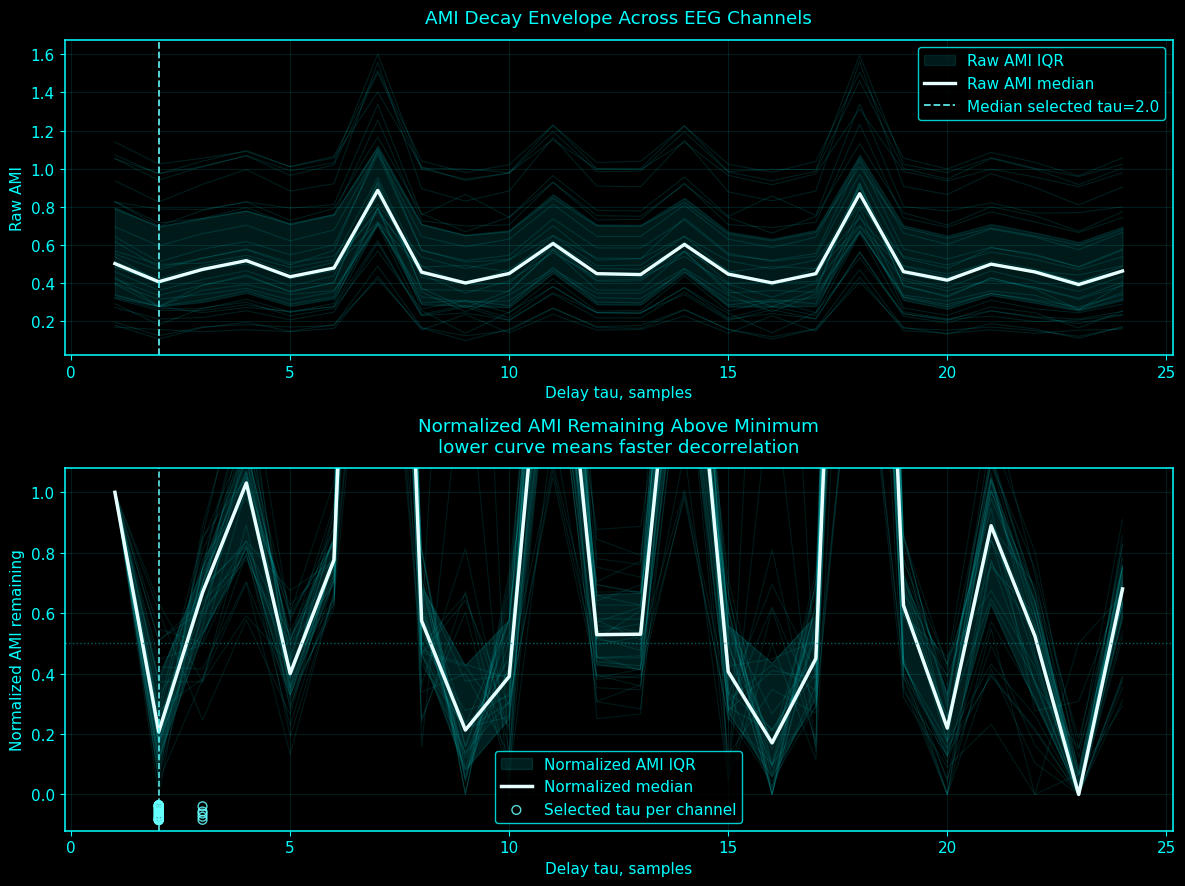

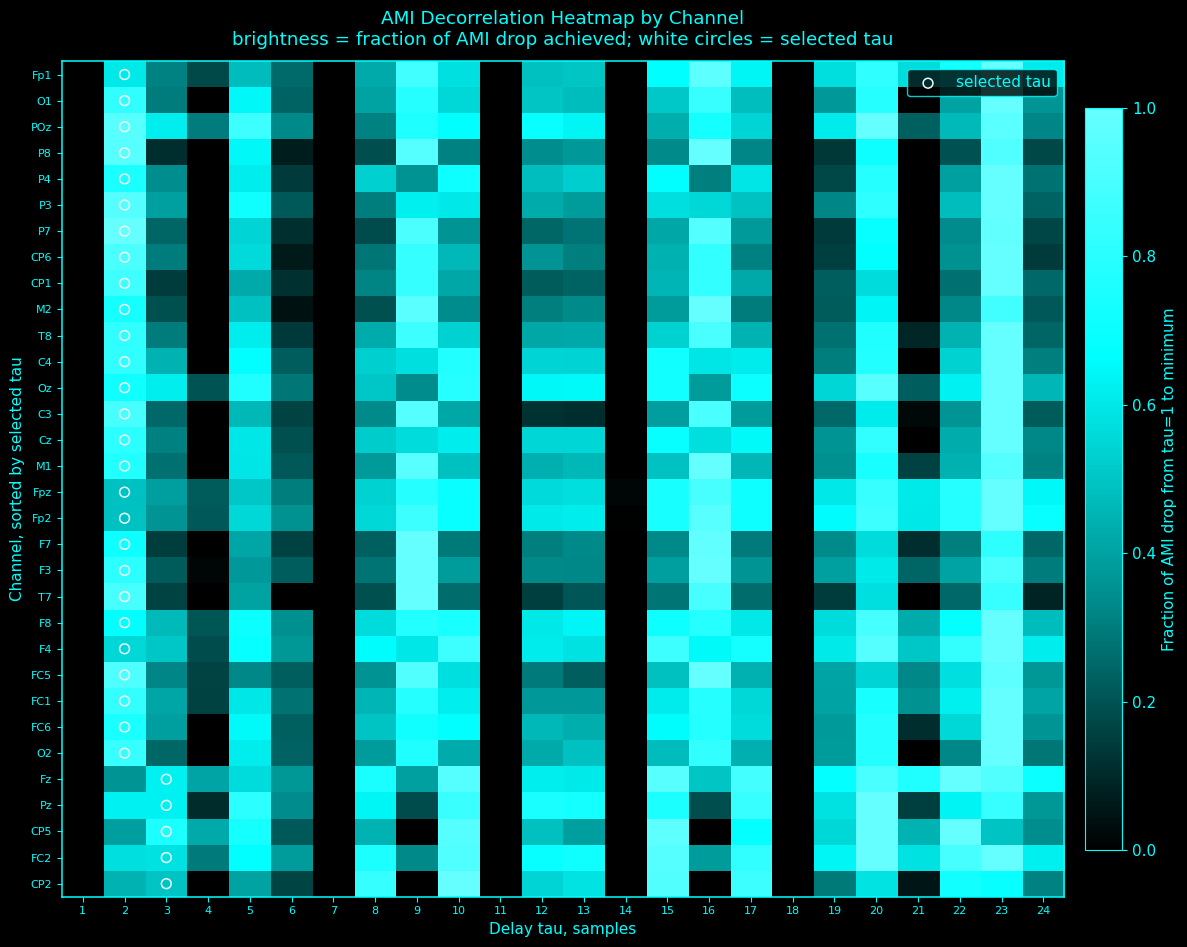

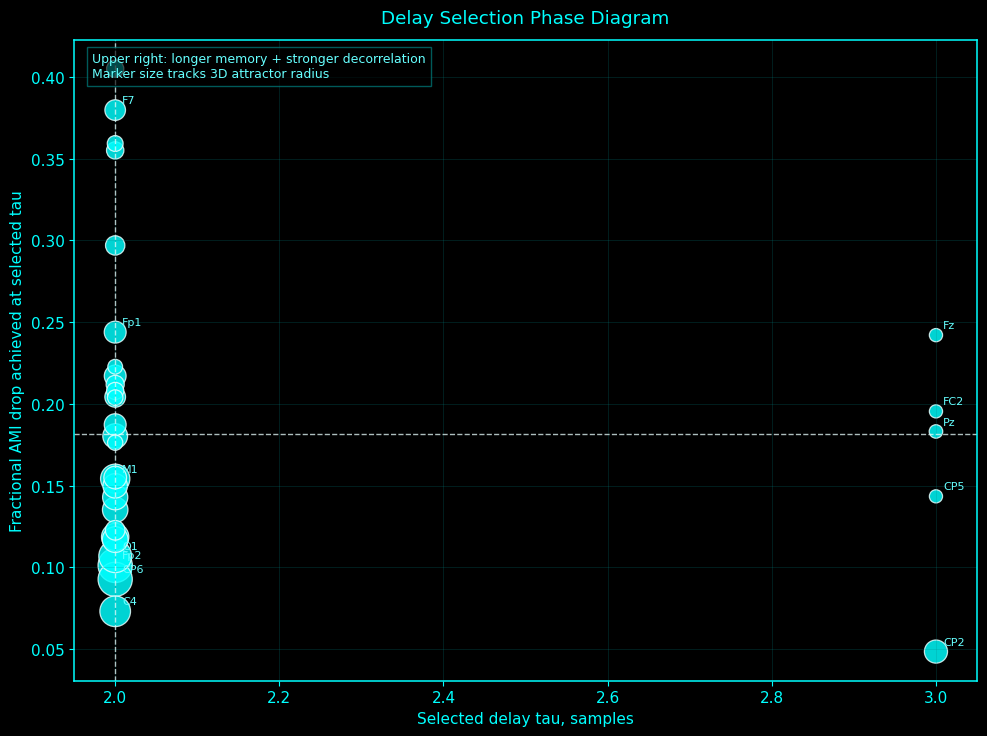

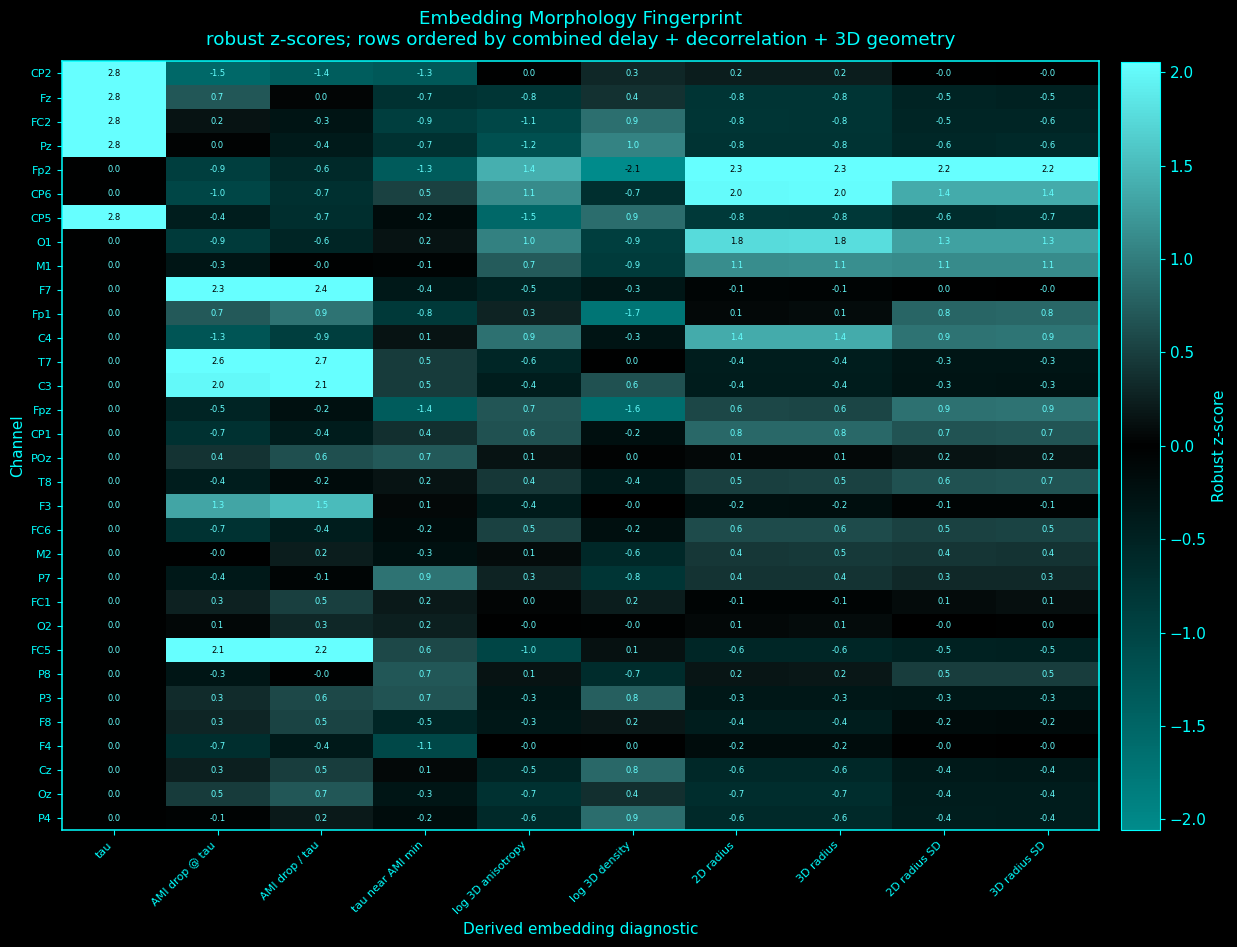

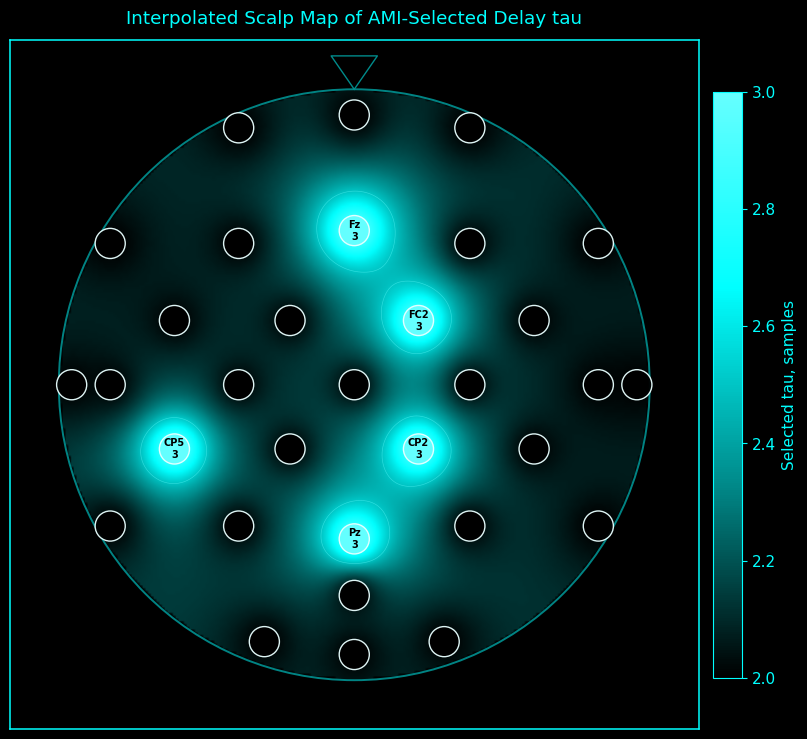

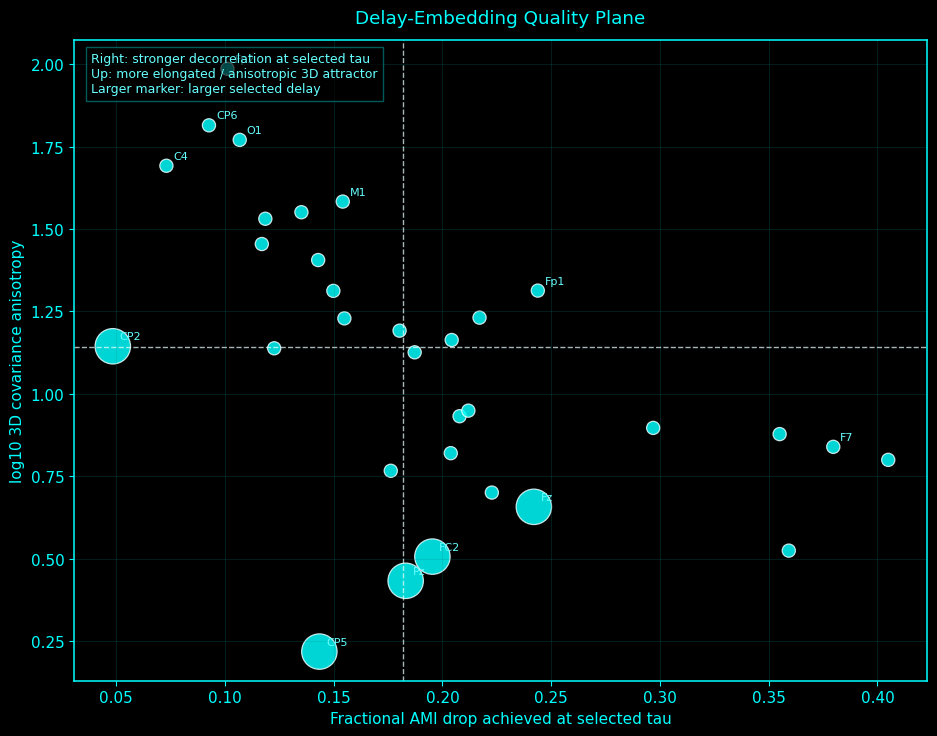

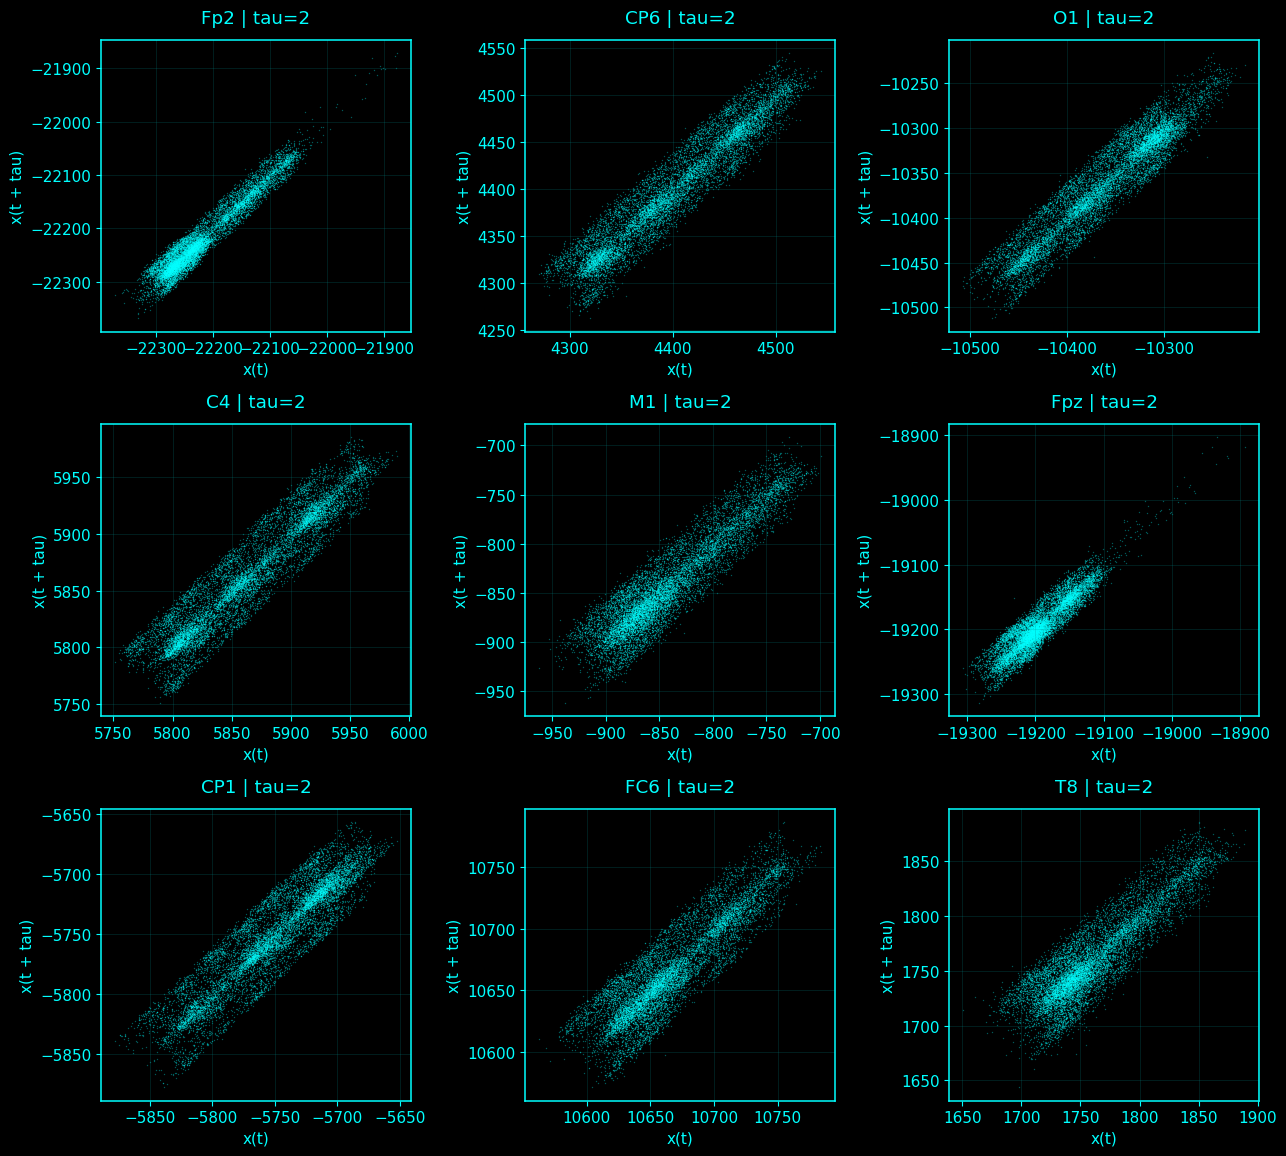

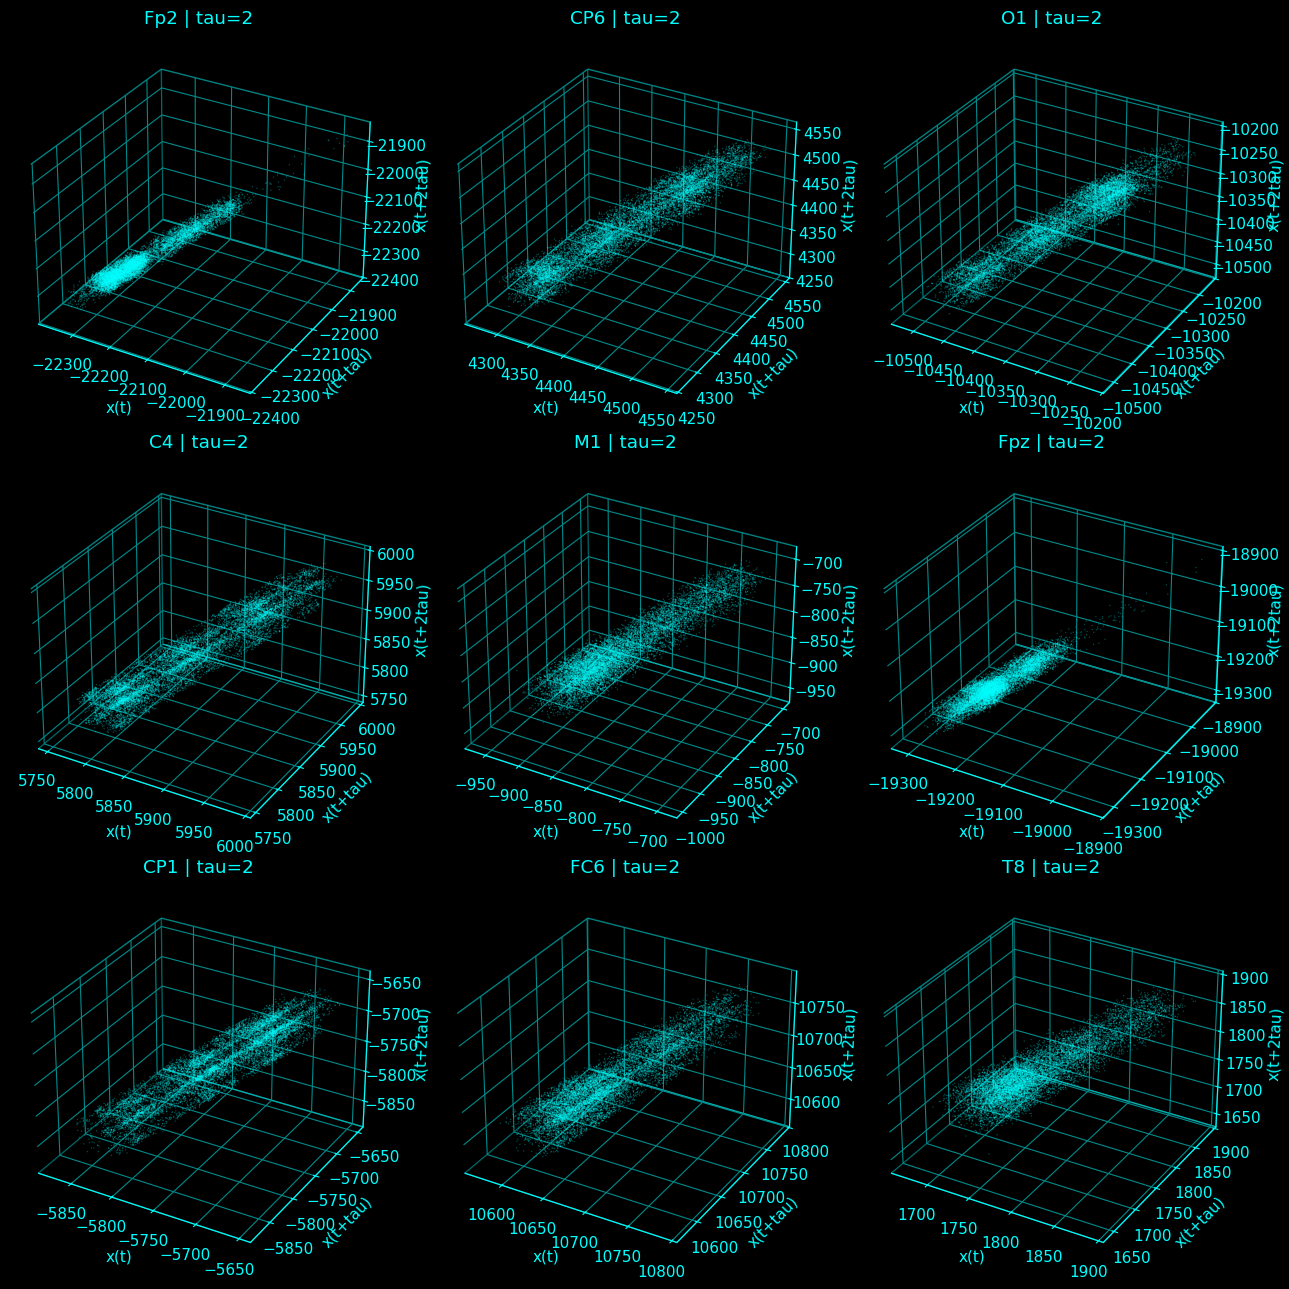

Zipped: /home/a/projects/Complete-Neural-Signal-Analysis/2d_embedded_data_fast.zip
Zipped: /home/a/projects/Complete-Neural-Signal-Analysis/3d_embedded_data_fast.zip

EXPERT DELAY EMBEDDING 2D/3D SUMMARY
FAST_OPTION: fast
Channels embedded: 32
Mean tau: 2.156
Median tau: 2.000
Min tau: 2
Max tau: 3
Mean 3D anisotropy: 20.5358
Total elapsed: 0.44 min

Top 12 channels by delay-embedding interest score:
channel  tau  ami_fractional_drop_to_tau  ami_tau_closeness_to_min  3d_cov_anisotropy  3d_mean_radius  delay_embedding_interest_score hemisphere           region
    CP2    3                    0.048486                  0.497560          13.950416       51.505716                        0.533003      right central_temporal
     Fz    3                    0.242044                  0.626918           4.550107       28.116921                        0.530349    midline          frontal
    FC2    3                    0.195412                  0.585601           3.214628       28.066939         

In [2]:
import os
import glob
import time
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from numpy.lib.stride_tricks import sliding_window_view

try:
    from IPython.display import display
    _HAVE_IPYTHON_DISPLAY = True
except Exception:
    display = None
    _HAVE_IPYTHON_DISPLAY = False


base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

embedding_root_dir = os.path.join(base_dir, "embedding_data")
embedding_2d_dir = os.path.join(embedding_root_dir, "2dembedding_data")
embedding_3d_dir = os.path.join(embedding_root_dir, "3dembedding_data")

results_dir = os.path.join(base_dir, "results", "delay_embedding_2d3d_expert_fast")
plots_directory = os.path.join(base_dir, "plots", "delay_embedding_2d3d_expert_fast")
per_channel_2d_dir = os.path.join(plots_directory, "per_channel_2d")
per_channel_3d_dir = os.path.join(plots_directory, "per_channel_3d")
gallery_dir = os.path.join(plots_directory, "galleries")
diagnostic_dir = os.path.join(plots_directory, "diagnostics")

for dir_path in [
    embedding_root_dir,
    embedding_2d_dir,
    embedding_3d_dir,
    results_dir,
    plots_directory,
    per_channel_2d_dir,
    per_channel_3d_dir,
    gallery_dir,
    diagnostic_dir,
]:
    os.makedirs(dir_path, exist_ok=True)


FAST_OPTION = "fast"

if FAST_OPTION == "ultra":
    max_delay = 16
    subsample_factor = 25
    n_bins = 32
    delay_rule = "first_local_min"
    binning_mode = "equal_width"
    plot_max_points = 5000
    gallery_top_n = 6
    run_fnn = False
    max_dim = 8
    fnn_R = 10.0
    fnn_max_points = 600
    fnn_channel_top_n = 0
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 170

elif FAST_OPTION == "fast":
    max_delay = 24
    subsample_factor = 12
    n_bins = 48
    delay_rule = "first_local_min"
    binning_mode = "equal_width"
    plot_max_points = 10000
    gallery_top_n = 9
    run_fnn = False
    max_dim = 10
    fnn_R = 10.0
    fnn_max_points = 900
    fnn_channel_top_n = 0
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 190

elif FAST_OPTION == "balanced":
    max_delay = 40
    subsample_factor = 8
    n_bins = 64
    delay_rule = "first_local_min"
    binning_mode = "quantile"
    plot_max_points = 15000
    gallery_top_n = 12
    run_fnn = True
    max_dim = 14
    fnn_R = 10.0
    fnn_max_points = 1200
    fnn_channel_top_n = 12
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 220

elif FAST_OPTION == "full":
    max_delay = 60
    subsample_factor = 5
    n_bins = 80
    delay_rule = "first_local_min"
    binning_mode = "quantile"
    plot_max_points = 25000
    gallery_top_n = 16
    run_fnn = True
    max_dim = 20
    fnn_R = 10.0
    fnn_max_points = 2000
    fnn_channel_top_n = None
    save_individual_plots = True
    show_individual_plots = False
    show_summary_plots = True
    dpi_save = 240

else:
    raise ValueError("FAST_OPTION must be one of: 'ultra', 'fast', 'balanced', 'full'.")


sampling_rate = 1000
start_time = 814.571
end_time = 921.515
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

emb_dim_2d = 2
emb_dim_3d = 3

SHOW_PLOTS_IN_NOTEBOOK = True
SAVE_PLOTS_TO_DISK = True
ZIP_EMBEDDINGS = True
SAVE_FULL_EMBEDDINGS = True
STANDARDIZE_BEFORE_EMBEDDING = False

RANDOM_SEED = 0
rng = np.random.default_rng(RANDOM_SEED)

eeg_channel_names = [
    "Fp1", "Fpz", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2", "FC6",
    "M1", "T7", "C3", "Cz", "C4", "T8", "M2", "CP5", "CP1", "CP2", "CP6",
    "P7", "P3", "Pz", "P4", "P8", "POz", "O1", "Oz", "O2"
]

left_channels = ["Fp1", "F7", "F3", "FC5", "FC1", "M1", "T7", "C3", "CP5", "CP1", "P7", "P3", "O1"]
right_channels = ["Fp2", "F8", "F4", "FC2", "FC6", "M2", "T8", "C4", "CP2", "CP6", "P8", "P4", "O2"]
midline_channels = ["Fpz", "Fz", "Cz", "Pz", "POz", "Oz"]

electrode_xy = {
    "Fp1": (-0.45, 1.00), "Fpz": (0.00, 1.05), "Fp2": (0.45, 1.00),
    "F7": (-0.95, 0.55), "F3": (-0.45, 0.55), "Fz": (0.00, 0.60), "F4": (0.45, 0.55), "F8": (0.95, 0.55),
    "FC5": (-0.70, 0.25), "FC1": (-0.25, 0.25), "FC2": (0.25, 0.25), "FC6": (0.70, 0.25),
    "M1": (-1.10, 0.00), "T7": (-0.95, 0.00), "C3": (-0.45, 0.00), "Cz": (0.00, 0.00), "C4": (0.45, 0.00), "T8": (0.95, 0.00), "M2": (1.10, 0.00),
    "CP5": (-0.70, -0.25), "CP1": (-0.25, -0.25), "CP2": (0.25, -0.25), "CP6": (0.70, -0.25),
    "P7": (-0.95, -0.55), "P3": (-0.45, -0.55), "Pz": (0.00, -0.60), "P4": (0.45, -0.55), "P8": (0.95, -0.55),
    "POz": (0.00, -0.82), "O1": (-0.35, -1.00), "Oz": (0.00, -1.05), "O2": (0.35, -1.00),
}

ACCENT = "#00FFFF"
ACCENT_SOFT = "#66FFFF"
ACCENT_DIM = "#008B8B"
WHITE = "#E8FFFF"
BLACK = "#000000"

CYAN_SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "cyan_sequential",
    [BLACK, ACCENT_DIM, ACCENT, ACCENT_SOFT],
    N=256,
)

CYAN_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "cyan_diverging",
    [ACCENT_DIM, BLACK, ACCENT_SOFT],
    N=256,
)

plt.rcParams.update({
    "figure.facecolor": BLACK,
    "axes.facecolor": BLACK,
    "savefig.facecolor": BLACK,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT_DIM,
    "grid.alpha": 0.25,
    "legend.facecolor": BLACK,
    "legend.edgecolor": ACCENT,
    "legend.labelcolor": ACCENT,
    "font.size": 11,
})


def style_ax(ax, title=None, xlabel=None, ylabel=None, grid=True):
    ax.set_facecolor(BLACK)

    for spine in ax.spines.values():
        spine.set_color(ACCENT)
        spine.set_linewidth(1.1)

    ax.tick_params(axis="x", colors=ACCENT, labelcolor=ACCENT)
    ax.tick_params(axis="y", colors=ACCENT, labelcolor=ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if grid:
        ax.grid(True, alpha=0.22, color=ACCENT_DIM, linewidth=0.7)
    else:
        ax.grid(False)


def style_3d_ax(ax, title=None, xlabel=None, ylabel=None, zlabel=None):
    ax.set_facecolor(BLACK)
    ax.xaxis.pane.set_facecolor(BLACK)
    ax.yaxis.pane.set_facecolor(BLACK)
    ax.zaxis.pane.set_facecolor(BLACK)
    ax.xaxis.pane.set_edgecolor(ACCENT)
    ax.yaxis.pane.set_edgecolor(ACCENT)
    ax.zaxis.pane.set_edgecolor(ACCENT)
    ax.tick_params(colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.zaxis.label.set_color(ACCENT)

    if title is not None:
        ax.set_title(title, color=ACCENT, pad=12)

    if xlabel is not None:
        ax.set_xlabel(xlabel, color=ACCENT)

    if ylabel is not None:
        ax.set_ylabel(ylabel, color=ACCENT)

    if zlabel is not None:
        ax.set_zlabel(zlabel, color=ACCENT)


def save_fig(fig, path, show=True):
    fig.tight_layout()

    if SAVE_PLOTS_TO_DISK and path is not None:
        fig.savefig(path, dpi=dpi_save, bbox_inches="tight", facecolor=BLACK)

    if SHOW_PLOTS_IN_NOTEBOOK and show and _HAVE_IPYTHON_DISPLAY:
        display(fig)
    elif SHOW_PLOTS_IN_NOTEBOOK and show:
        plt.show()

    plt.close(fig)


def short_label(x, max_len=24):
    x = str(x)
    return x if len(x) <= max_len else x[:max_len - 1] + "…"


def ensure_time_channel_layout(EEG_data, channel_names):
    X = np.asarray(EEG_data, dtype=float)

    if X.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {X.shape}")

    n_expected = len(channel_names)

    if X.shape[1] == n_expected:
        return X, channel_names

    if X.shape[0] == n_expected:
        return X.T, channel_names

    if X.shape[1] > n_expected:
        return X[:, :n_expected], channel_names

    if X.shape[0] > n_expected:
        return X.T[:, :n_expected], channel_names

    if X.shape[1] < n_expected:
        return X, channel_names[:X.shape[1]]

    if X.shape[0] < n_expected:
        return X.T, channel_names[:X.shape[0]]

    raise ValueError(f"Unexpected EEG shape: {X.shape}")


def safe_nan_to_num_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    x = np.where(np.isfinite(x), x, np.nan)

    if np.any(~np.isfinite(x)):
        med = np.nanmedian(x)

        if not np.isfinite(med):
            med = 0.0

        x = np.nan_to_num(x, nan=med, posinf=med, neginf=med)

    return x


def standardize_1d(x):
    x = safe_nan_to_num_1d(x)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def digitize_equal_width(x, n_bins=64):
    x = standardize_1d(x)
    xmin, xmax = np.min(x), np.max(x)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        return np.zeros_like(x, dtype=np.int32)

    edges = np.linspace(xmin, xmax, n_bins + 1)
    xb = np.digitize(x, edges[1:-1], right=False).astype(np.int32)
    xb = np.clip(xb, 0, n_bins - 1)

    return xb


def digitize_quantile(x, n_bins=64):
    x = standardize_1d(x)

    if np.std(x) < 1e-12:
        return np.zeros_like(x, dtype=np.int32)

    edges = np.quantile(x, np.linspace(0, 1, n_bins + 1))
    edges = np.unique(edges)

    if len(edges) <= 2:
        return digitize_equal_width(x, n_bins=n_bins)

    xb = np.digitize(x, edges[1:-1], right=False).astype(np.int32)
    xb = np.clip(xb, 0, n_bins - 1)

    return xb


def bin_signal(x, n_bins=64, mode="equal_width"):
    if mode == "equal_width":
        return digitize_equal_width(x, n_bins=n_bins)

    if mode == "quantile":
        return digitize_quantile(x, n_bins=n_bins)

    raise ValueError("binning_mode must be 'equal_width' or 'quantile'.")


def average_mutual_information_from_binned(xb, max_delay=20, n_bins=64):
    xb = np.asarray(xb, dtype=np.int32)
    N = len(xb)
    ami = np.full(max_delay, np.nan, dtype=float)

    for tau in range(1, max_delay + 1):
        if tau >= N:
            continue

        x1 = xb[:-tau]
        x2 = xb[tau:]

        joint_idx = x1 * n_bins + x2
        joint = np.bincount(
            joint_idx,
            minlength=n_bins * n_bins
        ).reshape(n_bins, n_bins).astype(float)

        total = joint.sum()

        if total <= 0:
            continue

        pxy = joint / total
        px = pxy.sum(axis=1, keepdims=True)
        py = pxy.sum(axis=0, keepdims=True)
        denom = px @ py

        mask = (pxy > 0) & (denom > 0)

        ami[tau - 1] = float(np.sum(pxy[mask] * np.log(pxy[mask] / denom[mask])))

    return ami


def first_local_minimum(y):
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(y)

    if not np.any(finite):
        return 0

    for i in range(1, len(y) - 1):
        if np.isfinite(y[i - 1]) and np.isfinite(y[i]) and np.isfinite(y[i + 1]):
            if y[i] < y[i - 1] and y[i] <= y[i + 1]:
                return int(i)

    return int(np.nanargmin(y))


def determine_delay(data, max_delay=20, subsample_factor=10, n_bins=64, rule="first_local_min", binning_mode="equal_width"):
    xs = np.asarray(data, dtype=float)[::subsample_factor]
    xb = bin_signal(xs, n_bins=n_bins, mode=binning_mode)
    ami = average_mutual_information_from_binned(xb, max_delay=max_delay, n_bins=n_bins)

    if rule == "first_local_min":
        idx = first_local_minimum(ami)
    elif rule == "global_min":
        idx = int(np.nanargmin(ami))
    else:
        raise ValueError(f"Unknown delay_rule: {rule}")

    tau = idx + 1

    return tau, ami


def delay_embedding(data, emb_dim, delay):
    x = np.asarray(data, dtype=float).reshape(-1)

    if STANDARDIZE_BEFORE_EMBEDDING:
        x = standardize_1d(x)
    else:
        x = safe_nan_to_num_1d(x)

    span = (emb_dim - 1) * delay + 1
    M = len(x) - span + 1

    if M <= 0:
        return None

    win = sliding_window_view(x, span)
    emb = win[:, ::delay]

    if emb.shape[1] != emb_dim:
        emb = emb[:, :emb_dim]

    return np.asarray(emb, dtype=float)


def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)

    if rng is None:
        rng = np.random.default_rng()

    n = len(X)

    if max_points is None or n <= max_points:
        return X, np.arange(n)

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx], idx


def embedding_geometry_metrics(X2, X3):
    X2 = np.asarray(X2, dtype=float)
    X3 = np.asarray(X3, dtype=float)

    out = {}

    for name, X in [("2d", X2), ("3d", X3)]:
        if X is None or len(X) < 3:
            out[f"{name}_x_range"] = np.nan
            out[f"{name}_y_range"] = np.nan
            out[f"{name}_z_range"] = np.nan
            out[f"{name}_bbox_volume"] = np.nan
            out[f"{name}_density_bbox"] = np.nan
            out[f"{name}_cov_anisotropy"] = np.nan
            out[f"{name}_mean_radius"] = np.nan
            out[f"{name}_std_radius"] = np.nan
            continue

        Xc = X - np.mean(X, axis=0, keepdims=True)
        ranges = np.max(X, axis=0) - np.min(X, axis=0)

        bbox = float(np.prod(np.maximum(ranges, 1e-12)))
        density = float(len(X) / bbox)

        cov = np.cov(Xc.T)
        eig = np.linalg.eigvalsh(cov)
        eig = np.sort(np.maximum(eig, 1e-12))
        anis = float(eig[-1] / eig[0])

        radius = np.sqrt(np.sum(Xc ** 2, axis=1))

        out[f"{name}_x_range"] = float(ranges[0]) if len(ranges) > 0 else np.nan
        out[f"{name}_y_range"] = float(ranges[1]) if len(ranges) > 1 else np.nan
        out[f"{name}_z_range"] = float(ranges[2]) if len(ranges) > 2 else np.nan
        out[f"{name}_bbox_volume"] = bbox
        out[f"{name}_density_bbox"] = density
        out[f"{name}_cov_anisotropy"] = anis
        out[f"{name}_mean_radius"] = float(np.mean(radius))
        out[f"{name}_std_radius"] = float(np.std(radius))

    return out


def nearest_neighbor_indices_bruteforce(X, chunk_size=256):
    X = np.asarray(X, dtype=float)
    n = len(X)

    nn_idx = np.full(n, -1, dtype=int)
    nn_dist = np.full(n, np.nan, dtype=float)

    for start in range(0, n, chunk_size):
        end = min(n, start + chunk_size)
        chunk = X[start:end]

        d2 = np.sum((chunk[:, None, :] - X[None, :, :]) ** 2, axis=2)

        for local_i, global_i in enumerate(range(start, end)):
            d2[local_i, global_i] = np.inf

        idx = np.argmin(d2, axis=1)
        dist = np.sqrt(d2[np.arange(end - start), idx])

        nn_idx[start:end] = idx
        nn_dist[start:end] = dist

    return nn_idx, nn_dist


def false_nearest_neighbors_manual(data, max_dim, delay, R=10.0, max_points=1200, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    x = safe_nan_to_num_1d(data)
    fnn = np.full(max_dim, np.nan, dtype=float)
    sample_counts = np.zeros(max_dim, dtype=int)

    for d in range(1, max_dim):
        Xd = delay_embedding(x, d, delay)
        Xd1 = delay_embedding(x, d + 1, delay)

        if Xd is None or Xd1 is None:
            continue

        M = min(len(Xd), len(Xd1))
        Xd = Xd[:M]
        Xd1 = Xd1[:M]

        if M < 10:
            continue

        if max_points is not None and M > max_points:
            idx = np.sort(rng.choice(M, size=max_points, replace=False))
            Xs = Xd[idx]
            Xs1 = Xd1[idx]
        else:
            Xs = Xd
            Xs1 = Xd1

        nn_idx, dist_d = nearest_neighbor_indices_bruteforce(Xs)
        valid = (nn_idx >= 0) & np.isfinite(dist_d)

        if np.sum(valid) < 5:
            continue

        extra_coord_diff = np.abs(Xs1[:, -1] - Xs1[nn_idx, -1])
        ratio = extra_coord_diff / (dist_d + 1e-12)

        fnn[d - 1] = float(np.mean(ratio[valid] > R))
        sample_counts[d - 1] = int(np.sum(valid))

    return fnn, sample_counts


def add_channel_metadata(df):
    df = df.copy()
    hemispheres = []
    regions = []

    for ch in df["channel"]:
        if ch in left_channels:
            hemispheres.append("left")
        elif ch in right_channels:
            hemispheres.append("right")
        elif ch in midline_channels:
            hemispheres.append("midline")
        else:
            hemispheres.append("unknown")

        if ch.startswith("Fp"):
            regions.append("frontal_polar")
        elif ch.startswith("F") or ch.startswith("FC"):
            regions.append("frontal")
        elif ch.startswith("C") or ch.startswith("T") or ch.startswith("M"):
            regions.append("central_temporal")
        elif ch.startswith("CP") or ch.startswith("P"):
            regions.append("parietal")
        elif ch.startswith("PO") or ch.startswith("O"):
            regions.append("occipital")
        else:
            regions.append("unknown")

    df["hemisphere"] = hemispheres
    df["region"] = regions

    return df


def _safe_numeric_array(x):
    x = np.asarray(x, dtype=float)
    x = np.where(np.isfinite(x), x, np.nan)
    return x


def _robust_minmax(x, lo=3, hi=97):
    x = _safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    a = np.nanpercentile(finite, lo)
    b = np.nanpercentile(finite, hi)

    if not np.isfinite(a) or not np.isfinite(b) or b <= a:
        return np.zeros_like(x, dtype=float)

    return np.clip((x - a) / (b - a + 1e-12), 0, 1)


def _robust_z(x):
    x = _safe_numeric_array(x)
    finite = x[np.isfinite(x)]

    if finite.size == 0:
        return np.zeros_like(x, dtype=float)

    med = np.nanmedian(finite)
    q25 = np.nanpercentile(finite, 25)
    q75 = np.nanpercentile(finite, 75)
    iqr = q75 - q25

    if not np.isfinite(iqr) or iqr <= 1e-12:
        sd = np.nanstd(finite) + 1e-12
        return (x - med) / sd

    return (x - med) / (iqr + 1e-12)


def _ami_matrix_from_store(ami_store):
    channels = list(ami_store.keys())

    if len(channels) == 0:
        return channels, np.empty((0, 0), dtype=float)

    max_len = max(len(np.asarray(v).reshape(-1)) for v in ami_store.values())
    M = np.full((len(channels), max_len), np.nan, dtype=float)

    for i, ch in enumerate(channels):
        vals = np.asarray(ami_store[ch], dtype=float).reshape(-1)
        M[i, :len(vals)] = vals

    return channels, M


def _add_delay_quality_columns(df):
    df = df.copy()

    for c in ["ami_first", "ami_at_tau", "ami_min", "ami_last"]:
        if c not in df.columns:
            df[c] = np.nan

    df["ami_fractional_drop_to_tau"] = (
        (df["ami_first"] - df["ami_at_tau"])
        / (np.abs(df["ami_first"]) + 1e-12)
    )

    df["ami_fractional_drop_to_min"] = (
        (df["ami_first"] - df["ami_min"])
        / (np.abs(df["ami_first"]) + 1e-12)
    )

    df["tau_selection_efficiency"] = (
        df["ami_fractional_drop_to_tau"]
        / (df["tau"].astype(float) + 1e-12)
    )

    df["ami_tau_closeness_to_min"] = 1.0 - (
        np.abs(df["ami_at_tau"] - df["ami_min"])
        / (np.abs(df["ami_first"] - df["ami_min"]) + 1e-12)
    )

    df["ami_tau_closeness_to_min"] = df["ami_tau_closeness_to_min"].clip(-1, 1)

    if "3d_cov_anisotropy" in df.columns:
        df["log10_3d_anisotropy"] = np.log10(np.maximum(df["3d_cov_anisotropy"].astype(float), 1e-12))
    else:
        df["log10_3d_anisotropy"] = np.nan

    if "3d_density_bbox" in df.columns:
        df["log10_3d_density"] = np.log10(np.maximum(df["3d_density_bbox"].astype(float), 1e-12))
    else:
        df["log10_3d_density"] = np.nan

    df["delay_embedding_interest_score"] = (
        0.35 * _robust_minmax(df["tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["ami_fractional_drop_to_tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["log10_3d_anisotropy"].to_numpy(dtype=float))
        + 0.15 * _robust_minmax(df.get("3d_mean_radius", pd.Series(np.nan, index=df.index)).to_numpy(dtype=float))
    )

    return df


def plot_2d_embedding(X2, channel_name, tau, path, show=False):
    X2_plot, _ = subsample_rows(X2, max_points=plot_max_points, rng=rng)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BLACK)

    ax.scatter(
        X2_plot[:, 0],
        X2_plot[:, 1],
        s=1.0,
        color=ACCENT,
        alpha=0.38,
        linewidths=0,
    )

    style_ax(
        ax,
        title=f"2D Phase Space Reconstruction | {channel_name} | tau={tau}",
        xlabel="x(t)",
        ylabel=f"x(t + {tau})",
        grid=True,
    )

    save_fig(fig, path, show=show)

    return path


def plot_3d_embedding(X3, channel_name, tau, path, show=False):
    X3_plot, _ = subsample_rows(X3, max_points=plot_max_points, rng=rng)

    fig = plt.figure(figsize=(8, 6), facecolor=BLACK)
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(
        X3_plot[:, 0],
        X3_plot[:, 1],
        X3_plot[:, 2],
        s=1.0,
        color=ACCENT,
        alpha=0.32,
        linewidths=0,
    )

    style_3d_ax(
        ax,
        title=f"3D Phase Space Reconstruction | {channel_name} | tau={tau}",
        xlabel="x(t)",
        ylabel=f"x(t + {tau})",
        zlabel=f"x(t + {2 * tau})",
    )

    save_fig(fig, path, show=show)

    return path


def plot_ami_curves_all(ami_store, tau_df):
    if len(ami_store) == 0:
        return None

    channels, M = _ami_matrix_from_store(ami_store)

    if M.size == 0:
        return None

    delays = np.arange(1, M.shape[1] + 1)
    M_norm = np.full_like(M, np.nan, dtype=float)

    for i in range(M.shape[0]):
        row = M[i].copy()
        finite = row[np.isfinite(row)]

        if finite.size < 3:
            continue

        first_val = row[0]
        min_val = np.nanmin(row)
        denom = first_val - min_val

        if not np.isfinite(denom) or abs(denom) < 1e-12:
            continue

        M_norm[i] = (row - min_val) / (denom + 1e-12)

    raw_median = np.nanmedian(M, axis=0)
    raw_q25 = np.nanpercentile(M, 25, axis=0)
    raw_q75 = np.nanpercentile(M, 75, axis=0)

    norm_median = np.nanmedian(M_norm, axis=0)
    norm_q25 = np.nanpercentile(M_norm, 25, axis=0)
    norm_q75 = np.nanpercentile(M_norm, 75, axis=0)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 9),
        facecolor=BLACK,
        gridspec_kw={"height_ratios": [1.0, 1.15]},
    )

    ax = axes[0]

    for i in range(M.shape[0]):
        ax.plot(
            delays,
            M[i],
            color=ACCENT,
            alpha=0.12,
            linewidth=0.8,
        )

    ax.fill_between(
        delays,
        raw_q25,
        raw_q75,
        color=ACCENT,
        alpha=0.10,
        label="Raw AMI IQR",
    )

    ax.plot(
        delays,
        raw_median,
        color=WHITE,
        linewidth=2.4,
        label="Raw AMI median",
    )

    if not tau_df.empty and "tau" in tau_df.columns:
        med_tau = float(np.nanmedian(tau_df["tau"]))
        ax.axvline(
            med_tau,
            color=ACCENT_SOFT,
            linestyle="--",
            linewidth=1.3,
            alpha=0.90,
            label=f"Median selected tau={med_tau:.1f}",
        )

    style_ax(
        ax,
        title="AMI Decay Envelope Across EEG Channels",
        xlabel="Delay tau, samples",
        ylabel="Raw AMI",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    ax = axes[1]

    for i in range(M_norm.shape[0]):
        ax.plot(
            delays,
            M_norm[i],
            color=ACCENT,
            alpha=0.10,
            linewidth=0.8,
        )

    ax.fill_between(
        delays,
        norm_q25,
        norm_q75,
        color=ACCENT,
        alpha=0.12,
        label="Normalized AMI IQR",
    )

    ax.plot(
        delays,
        norm_median,
        color=WHITE,
        linewidth=2.5,
        label="Normalized median",
    )

    if not tau_df.empty and "tau" in tau_df.columns:
        tau_vals = tau_df["tau"].to_numpy(dtype=float)
        tau_vals = tau_vals[np.isfinite(tau_vals)]

        if tau_vals.size:
            jitter_y = -0.06 + 0.025 * np.sin(np.arange(len(tau_vals)))
            ax.scatter(
                tau_vals,
                jitter_y,
                s=40,
                facecolors="none",
                edgecolors=ACCENT_SOFT,
                linewidths=1.0,
                alpha=0.85,
                label="Selected tau per channel",
            )

            ax.axvline(
                np.nanmedian(tau_vals),
                color=ACCENT_SOFT,
                linestyle="--",
                linewidth=1.2,
                alpha=0.90,
            )

    ax.axhline(0.5, color=ACCENT_DIM, linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_ylim(-0.12, 1.08)

    style_ax(
        ax,
        title="Normalized AMI Remaining Above Minimum\nlower curve means faster decorrelation",
        xlabel="Delay tau, samples",
        ylabel="Normalized AMI remaining",
    )

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(diagnostic_dir, f"01_ami_decay_diagnostic_envelope_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_ami_heatmap(ami_store, tau_df):
    if len(ami_store) == 0:
        return None

    channels, M = _ami_matrix_from_store(ami_store)

    if M.size == 0:
        return None

    tau_map = {}

    if not tau_df.empty and "channel" in tau_df.columns and "tau" in tau_df.columns:
        tau_map = dict(zip(tau_df["channel"], tau_df["tau"]))

    M_drop = np.full_like(M, np.nan, dtype=float)

    for i in range(M.shape[0]):
        row = M[i].copy()
        finite = row[np.isfinite(row)]

        if finite.size < 3:
            continue

        first_val = row[0]
        min_val = np.nanmin(row)
        denom = first_val - min_val

        if not np.isfinite(denom) or abs(denom) < 1e-12:
            continue

        M_drop[i] = 1.0 - ((row - min_val) / (denom + 1e-12))

    order = np.arange(len(channels))

    if len(tau_map):
        order = np.argsort([tau_map.get(ch, np.inf) for ch in channels])

    channels_ord = [channels[i] for i in order]
    M_ord = M_drop[order]

    fig_height = min(10.5, max(7.0, 0.30 * len(channels_ord)))
    fig, ax = plt.subplots(figsize=(12, fig_height))

    im = ax.imshow(
        M_ord,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(M_ord.shape[1]))
    ax.set_xticklabels(np.arange(1, M_ord.shape[1] + 1), color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(channels_ord)))
    ax.set_yticklabels(channels_ord, color=ACCENT, fontsize=8)

    selected_tau_x = []
    selected_tau_y = []

    for yi, ch in enumerate(channels_ord):
        tau = tau_map.get(ch, None)

        if tau is not None and np.isfinite(tau):
            selected_tau_x.append(float(tau) - 1.0)
            selected_tau_y.append(float(yi))

    if len(selected_tau_x):
        ax.scatter(
            selected_tau_x,
            selected_tau_y,
            s=50,
            facecolors="none",
            edgecolors=WHITE,
            linewidths=1.1,
            label="selected tau",
        )

    for yi in range(M_ord.shape[0]):
        row = M_ord[yi]

        if np.any(np.isfinite(row)):
            best_x = int(np.nanargmax(row))
            ax.scatter(
                best_x,
                yi,
                s=16,
                color=ACCENT_SOFT,
                alpha=0.80,
            )

    style_ax(
        ax,
        title=(
            "AMI Decorrelation Heatmap by Channel\n"
            "brightness = fraction of AMI drop achieved; white circles = selected tau"
        ),
        xlabel="Delay tau, samples",
        ylabel="Channel, sorted by selected tau",
        grid=False,
    )

    if len(selected_tau_x):
        leg = ax.legend(loc="upper right", frameon=True)
        for text in leg.get_texts():
            text.set_color(ACCENT)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Fraction of AMI drop from tau=1 to minimum", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"02_ami_decorrelation_landscape_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_tau_ranking(tau_df):
    if tau_df.empty:
        return None

    df = _add_delay_quality_columns(tau_df)

    df = df[
        np.isfinite(df["tau"])
        & np.isfinite(df["ami_fractional_drop_to_tau"])
    ].copy()

    if df.empty:
        return None

    df = df.sort_values("delay_embedding_interest_score", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7.5))

    size_metric = df.get("3d_mean_radius", pd.Series(1.0, index=df.index)).to_numpy(dtype=float)
    size_metric = _robust_minmax(size_metric)
    sizes = 90 + 520 * size_metric

    x = df["tau"].to_numpy(dtype=float)
    y = df["ami_fractional_drop_to_tau"].to_numpy(dtype=float)

    ax.scatter(
        x,
        y,
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        alpha=0.83,
    )

    med_tau = np.nanmedian(x)
    med_drop = np.nanmedian(y)

    ax.axvline(med_tau, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)
    ax.axhline(med_drop, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.75)

    top = df.head(12)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["tau"], row["ami_fractional_drop_to_tau"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    ax.text(
        0.02,
        0.98,
        "Upper right: longer memory + stronger decorrelation\nMarker size tracks 3D attractor radius",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=ACCENT_SOFT,
        fontsize=9,
        bbox=dict(facecolor=BLACK, edgecolor=ACCENT_DIM, alpha=0.65),
    )

    style_ax(
        ax,
        title="Delay Selection Phase Diagram",
        xlabel="Selected delay tau, samples",
        ylabel="Fractional AMI drop achieved at selected tau",
    )

    path = os.path.join(diagnostic_dir, f"03_delay_selection_phase_diagram_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_embedding_geometry_heatmap(summary_df):
    if summary_df.empty:
        return None

    df = _add_delay_quality_columns(summary_df)

    candidate_metrics = [
        ("tau", "tau"),
        ("ami_fractional_drop_to_tau", "AMI drop @ tau"),
        ("tau_selection_efficiency", "AMI drop / tau"),
        ("ami_tau_closeness_to_min", "tau near AMI min"),
        ("log10_3d_anisotropy", "log 3D anisotropy"),
        ("log10_3d_density", "log 3D density"),
        ("2d_mean_radius", "2D radius"),
        ("3d_mean_radius", "3D radius"),
        ("2d_std_radius", "2D radius SD"),
        ("3d_std_radius", "3D radius SD"),
    ]

    metric_cols = [c for c, _ in candidate_metrics if c in df.columns]
    labels = [lab for c, lab in candidate_metrics if c in df.columns]

    if len(metric_cols) == 0:
        return None

    M = df[metric_cols].to_numpy(dtype=float)
    Z = np.zeros_like(M, dtype=float)

    for j in range(M.shape[1]):
        Z[:, j] = _robust_z(M[:, j])

    df["_ordering_score"] = (
        0.35 * _robust_minmax(df["tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["ami_fractional_drop_to_tau"].to_numpy(dtype=float))
        + 0.25 * _robust_minmax(df["log10_3d_anisotropy"].to_numpy(dtype=float))
        + 0.15 * _robust_minmax(df.get("3d_mean_radius", pd.Series(np.nan, index=df.index)).to_numpy(dtype=float))
    )

    order = np.argsort(df["_ordering_score"].to_numpy(dtype=float))[::-1]
    df_ord = df.iloc[order].copy()
    Z_ord = Z[order]

    if np.any(np.isfinite(Z_ord)):
        vmax = np.nanpercentile(np.abs(Z_ord[np.isfinite(Z_ord)]), 95)
    else:
        vmax = 1.0

    vmax = max(vmax, 1e-6)

    fig_height = min(10.5, max(7.0, 0.30 * len(df_ord)))
    fig, ax = plt.subplots(figsize=(12.5, fig_height))

    im = ax.imshow(
        Z_ord,
        aspect="auto",
        interpolation="nearest",
        cmap=CYAN_DIVERGING_CMAP,
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", color=ACCENT, fontsize=8)

    ax.set_yticks(np.arange(len(df_ord)))
    ax.set_yticklabels(df_ord["channel"], color=ACCENT, fontsize=8)

    for i in range(Z_ord.shape[0]):
        for j in range(Z_ord.shape[1]):
            val = Z_ord[i, j]

            if np.isfinite(val):
                ax.text(
                    j,
                    i,
                    f"{val:.1f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=BLACK if abs(val) > 0.85 * vmax else ACCENT_SOFT,
                )

    style_ax(
        ax,
        title=(
            "Embedding Morphology Fingerprint\n"
            "robust z-scores; rows ordered by combined delay + decorrelation + 3D geometry"
        ),
        xlabel="Derived embedding diagnostic",
        ylabel="Channel",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Robust z-score", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"04_embedding_morphology_fingerprint_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_tau_topography(tau_df):
    if tau_df.empty:
        return None

    df = tau_df.copy()
    df = df[np.isfinite(df["tau"])]

    xs = []
    ys = []
    vals = []
    labels = []

    for _, row in df.iterrows():
        ch = row["channel"]

        if ch in electrode_xy:
            x, y = electrode_xy[ch]
            xs.append(x)
            ys.append(y)
            vals.append(float(row["tau"]))
            labels.append(ch)

    if len(vals) == 0:
        return None

    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    vals = np.asarray(vals, dtype=float)

    grid_n = 220
    gx = np.linspace(-1.18, 1.18, grid_n)
    gy = np.linspace(-1.18, 1.18, grid_n)
    GX, GY = np.meshgrid(gx, gy)

    mask = GX ** 2 + GY ** 2 <= 1.15 ** 2

    Z_num = np.zeros_like(GX, dtype=float)
    Z_den = np.zeros_like(GX, dtype=float)

    for x, y, v in zip(xs, ys, vals):
        d2 = (GX - x) ** 2 + (GY - y) ** 2
        w = 1.0 / (d2 + 0.025 ** 2)
        Z_num += w * v
        Z_den += w

    Z = Z_num / (Z_den + 1e-12)
    Z[~mask] = np.nan

    fig, ax = plt.subplots(figsize=(8.2, 8.2))

    finite = vals[np.isfinite(vals)]
    vmin = np.nanmin(finite) if finite.size else 0
    vmax = np.nanmax(finite) if finite.size else 1

    im = ax.imshow(
        Z,
        extent=[gx.min(), gx.max(), gy.min(), gy.max()],
        origin="lower",
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        interpolation="bilinear",
    )

    contour_levels = np.unique(np.round(np.linspace(vmin, vmax, min(7, max(3, int(vmax - vmin + 1)))), 2))

    if len(contour_levels) >= 2:
        ax.contour(
            GX,
            GY,
            Z,
            levels=contour_levels,
            colors=ACCENT_SOFT,
            linewidths=0.45,
            alpha=0.45,
        )

    head = plt.Circle((0, 0), 1.15, color=ACCENT_DIM, fill=False, linewidth=1.4, alpha=0.95)
    ax.add_patch(head)

    ax.plot(
        [0.0, -0.09, 0.09, 0.0],
        [1.15, 1.28, 1.28, 1.15],
        color=ACCENT_DIM,
        linewidth=1.0,
    )

    ax.scatter(
        xs,
        ys,
        c=vals,
        s=470,
        cmap=CYAN_SEQUENTIAL_CMAP,
        vmin=vmin,
        vmax=vmax,
        edgecolors=WHITE,
        linewidths=1.0,
        alpha=0.96,
        zorder=4,
    )

    for x, y, ch, v in zip(xs, ys, labels, vals):
        ax.text(
            x,
            y,
            f"{ch}\n{int(v)}",
            ha="center",
            va="center",
            color=BLACK,
            fontsize=7,
            fontweight="bold",
            zorder=5,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.34, 1.34)
    ax.set_ylim(-1.34, 1.34)
    ax.set_xticks([])
    ax.set_yticks([])

    style_ax(
        ax,
        title="Interpolated Scalp Map of AMI-Selected Delay tau",
        xlabel="",
        ylabel="",
        grid=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.040, pad=0.02)
    cbar.ax.yaxis.set_tick_params(color=ACCENT)
    plt.setp(cbar.ax.get_yticklabels(), color=ACCENT)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.set_label("Selected tau, samples", color=ACCENT)

    path = os.path.join(diagnostic_dir, f"05_interpolated_tau_topographic_map_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_delay_vs_geometry(summary_df):
    if summary_df.empty:
        return None

    df = _add_delay_quality_columns(summary_df)

    required = ["ami_fractional_drop_to_tau", "log10_3d_anisotropy", "tau"]

    if any(c not in df.columns for c in required):
        return None

    df = df[
        np.isfinite(df["ami_fractional_drop_to_tau"])
        & np.isfinite(df["log10_3d_anisotropy"])
        & np.isfinite(df["tau"])
    ].copy()

    if df.empty:
        return None

    x = df["ami_fractional_drop_to_tau"].to_numpy(dtype=float)
    y = df["log10_3d_anisotropy"].to_numpy(dtype=float)
    tau = df["tau"].to_numpy(dtype=float)

    size_metric = _robust_minmax(tau)
    sizes = 90 + 560 * size_metric

    fig, ax = plt.subplots(figsize=(9.5, 7.5))

    ax.scatter(
        x,
        y,
        s=sizes,
        c=ACCENT,
        edgecolors=WHITE,
        linewidths=0.9,
        alpha=0.84,
    )

    x_med = np.nanmedian(x)
    y_med = np.nanmedian(y)

    ax.axvline(x_med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.72)
    ax.axhline(y_med, color=WHITE, linestyle="--", linewidth=1.0, alpha=0.72)

    top = df.sort_values("delay_embedding_interest_score", ascending=False).head(12)

    for _, row in top.iterrows():
        ax.annotate(
            row["channel"],
            (row["ami_fractional_drop_to_tau"], row["log10_3d_anisotropy"]),
            xytext=(5, 5),
            textcoords="offset points",
            color=ACCENT_SOFT,
            fontsize=8,
        )

    ax.text(
        0.02,
        0.98,
        "Right: stronger decorrelation at selected tau\nUp: more elongated / anisotropic 3D attractor\nLarger marker: larger selected delay",
        transform=ax.transAxes,
        ha="left",
        va="top",
        color=ACCENT_SOFT,
        fontsize=9,
        bbox=dict(facecolor=BLACK, edgecolor=ACCENT_DIM, alpha=0.65),
    )

    style_ax(
        ax,
        title="Delay-Embedding Quality Plane",
        xlabel="Fractional AMI drop achieved at selected tau",
        ylabel="log10 3D covariance anisotropy",
    )

    path = os.path.join(diagnostic_dir, f"06_delay_embedding_quality_plane_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_2d_embedding_gallery(summary_df):
    if summary_df.empty:
        return None

    df = summary_df.copy()

    if "3d_cov_anisotropy" in df.columns:
        df = df.sort_values("3d_cov_anisotropy", ascending=False)
    else:
        df = df.sort_values("tau", ascending=False)

    df = df.head(gallery_top_n)

    if df.empty:
        return None

    n = len(df)
    ncols_gallery = 3
    nrows = int(math.ceil(n / ncols_gallery))

    fig, axes = plt.subplots(nrows, ncols_gallery, figsize=(13, 3.9 * nrows), squeeze=False)
    fig.patch.set_facecolor(BLACK)

    for ax in axes.ravel():
        ax.set_facecolor(BLACK)
        ax.axis("off")

    for ax, (_, row) in zip(axes.ravel(), df.iterrows()):
        ax.axis("on")

        path = row.get("embedding_2d_path", "")

        if not isinstance(path, str) or not os.path.exists(path):
            ax.text(
                0.5,
                0.5,
                "Missing 2D embedding",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color=ACCENT,
            )
            style_ax(ax, title=str(row["channel"]))
            continue

        X2 = np.load(path)
        X2p, _ = subsample_rows(X2, max_points=plot_max_points, rng=rng)

        ax.scatter(
            X2p[:, 0],
            X2p[:, 1],
            s=1.0,
            color=ACCENT,
            alpha=0.35,
            linewidths=0,
        )

        style_ax(
            ax,
            title=f"{row['channel']} | tau={int(row['tau'])}",
            xlabel="x(t)",
            ylabel=f"x(t + tau)",
            grid=True,
        )

    path = os.path.join(gallery_dir, f"07_2d_embedding_gallery_top_channels_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_3d_embedding_gallery(summary_df):
    if summary_df.empty:
        return None

    df = summary_df.copy()

    if "3d_cov_anisotropy" in df.columns:
        df = df.sort_values("3d_cov_anisotropy", ascending=False)
    else:
        df = df.sort_values("tau", ascending=False)

    df = df.head(gallery_top_n)

    if df.empty:
        return None

    n = len(df)
    ncols_gallery = 3
    nrows = int(math.ceil(n / ncols_gallery))

    fig = plt.figure(figsize=(13, 4.3 * nrows), facecolor=BLACK)

    for i, (_, row) in enumerate(df.iterrows(), start=1):
        ax = fig.add_subplot(nrows, ncols_gallery, i, projection="3d")

        path = row.get("embedding_3d_path", "")

        if not isinstance(path, str) or not os.path.exists(path):
            ax.text2D(
                0.5,
                0.5,
                "Missing 3D embedding",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color=ACCENT,
            )
            style_3d_ax(ax, title=str(row["channel"]))
            continue

        X3 = np.load(path)
        X3p, _ = subsample_rows(X3, max_points=plot_max_points, rng=rng)

        ax.scatter(
            X3p[:, 0],
            X3p[:, 1],
            X3p[:, 2],
            s=1.0,
            color=ACCENT,
            alpha=0.30,
            linewidths=0,
        )

        style_3d_ax(
            ax,
            title=f"{row['channel']} | tau={int(row['tau'])}",
            xlabel="x(t)",
            ylabel="x(t+tau)",
            zlabel="x(t+2tau)",
        )

    path = os.path.join(gallery_dir, f"08_3d_embedding_gallery_top_channels_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def plot_fnn_curves(fnn_df):
    if fnn_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(10, 7))

    for ch, sub in fnn_df.groupby("channel"):
        sub = sub.sort_values("dimension")
        ax.plot(
            sub["dimension"],
            sub["fnn_fraction"],
            color=ACCENT,
            alpha=0.28,
            linewidth=1.0,
        )

    grouped = fnn_df.groupby("dimension")["fnn_fraction"].agg(["mean", "median", "std"]).reset_index()

    ax.plot(
        grouped["dimension"],
        grouped["mean"],
        color=WHITE,
        linewidth=2.4,
        marker="o",
        label="Mean FNN",
    )

    ax.plot(
        grouped["dimension"],
        grouped["median"],
        color=ACCENT_SOFT,
        linewidth=1.8,
        marker="s",
        linestyle="--",
        label="Median FNN",
    )

    ax.fill_between(
        grouped["dimension"],
        grouped["mean"] - grouped["std"],
        grouped["mean"] + grouped["std"],
        color=ACCENT,
        alpha=0.10,
        label="±1 SD",
    )

    style_ax(
        ax,
        title=f"False Nearest Neighbors Diagnostic | {FAST_OPTION}",
        xlabel="Embedding dimension",
        ylabel="FNN fraction",
    )

    ax.set_ylim(-0.03, 1.03)

    leg = ax.legend(loc="best", frameon=True)
    for text in leg.get_texts():
        text.set_color(ACCENT)

    path = os.path.join(diagnostic_dir, f"09_fnn_curves_{FAST_OPTION}.png")
    save_fig(fig, path, show=show_summary_plots)

    return path


def zip_embeddings(dir_path, zip_name):
    zip_path = os.path.join(base_dir, zip_name)

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
        for file in sorted(os.listdir(dir_path)):
            full = os.path.join(dir_path, file)

            if os.path.isfile(full) and file.endswith(".npy"):
                zipf.write(full, arcname=file)

    return zip_path


def save_summary_text(summary_df, fnn_df, txt_path):
    with open(txt_path, "w") as f:
        f.write("Expert Delay Embedding 2D/3D Reconstruction Summary\n")
        f.write("===================================================\n\n")
        f.write(f"base_dir: {base_dir}\n")
        f.write(f"eeg_path: {eeg_path}\n")
        f.write(f"FAST_OPTION: {FAST_OPTION}\n")
        f.write(f"sampling_rate: {sampling_rate}\n")
        f.write(f"segment_sec: [{start_time}, {end_time}]\n")
        f.write(f"max_delay: {max_delay}\n")
        f.write(f"subsample_factor: {subsample_factor}\n")
        f.write(f"n_bins: {n_bins}\n")
        f.write(f"binning_mode: {binning_mode}\n")
        f.write(f"delay_rule: {delay_rule}\n")
        f.write(f"run_fnn: {run_fnn}\n")
        f.write(f"max_dim: {max_dim}\n")
        f.write(f"fnn_R: {fnn_R}\n")
        f.write(f"fnn_max_points: {fnn_max_points}\n\n")

        if not summary_df.empty:
            f.write("Per-channel delay and embedding summary:\n")

            for _, row in summary_df.iterrows():
                f.write(
                    f"{row['channel']}: "
                    f"tau={row['tau']}, "
                    f"AMI_min={row['ami_min']:.6g}, "
                    f"2D_shape={row['embedding_2d_shape']}, "
                    f"3D_shape={row['embedding_3d_shape']}, "
                    f"3D_anisotropy={row['3d_cov_anisotropy']:.6g}, "
                    f"region={row.get('region', 'NA')}, "
                    f"hemisphere={row.get('hemisphere', 'NA')}\n"
                )

        if not fnn_df.empty:
            f.write("\nFNN summary by dimension:\n")
            grouped = fnn_df.groupby("dimension")["fnn_fraction"].agg(["mean", "median", "std", "count"]).reset_index()

            for _, row in grouped.iterrows():
                f.write(
                    f"d={int(row['dimension'])}: "
                    f"mean={row['mean']:.6g}, "
                    f"median={row['median']:.6g}, "
                    f"std={row['std']:.6g}, "
                    f"n={int(row['count'])}\n"
                )


start_all = time.perf_counter()

print("Running expert delay embedding 2D/3D reconstruction", flush=True)
print(f"FAST_OPTION: {FAST_OPTION}", flush=True)
print(f"EEG path: {eeg_path}", flush=True)
print(f"max_delay={max_delay}, subsample_factor={subsample_factor}, n_bins={n_bins}, binning={binning_mode}", flush=True)
print(f"run_fnn={run_fnn}", flush=True)

EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data, channel_names = ensure_time_channel_layout(EEG_data, eeg_channel_names)

start_index = max(0, start_index)
end_index = min(EEG_data.shape[0], end_index)

if end_index <= start_index:
    raise ValueError(f"Invalid segment indices: start={start_index}, end={end_index}, data length={EEG_data.shape[0]}")

filtered_EEG_data = EEG_data[start_index:end_index, :len(channel_names)]

print(f"Loaded EEG full shape: {EEG_data.shape}", flush=True)
print(f"Loaded EEG segment: {filtered_EEG_data.shape}", flush=True)
print(f"Segment: [{start_time}, {end_time}] sec", flush=True)

tau_rows = []
ami_store = {}
fnn_rows = []
plot_paths = []

for ch_idx, channel_name in enumerate(channel_names, start=1):
    t0 = time.perf_counter()

    try:
        channel_data = filtered_EEG_data[:, ch_idx - 1].astype(float)

        optimal_delay, ami_values = determine_delay(
            channel_data,
            max_delay=max_delay,
            subsample_factor=subsample_factor,
            n_bins=n_bins,
            rule=delay_rule,
            binning_mode=binning_mode,
        )

        embedded_data_2d = delay_embedding(channel_data, emb_dim_2d, optimal_delay)
        embedded_data_3d = delay_embedding(channel_data, emb_dim_3d, optimal_delay)

        if embedded_data_2d is None or embedded_data_3d is None:
            print(f"Skipping {channel_name}: embedding failed for tau={optimal_delay}", flush=True)
            continue

        emb2_path = os.path.join(embedding_2d_dir, f"2dembedded_{channel_name}.npy")
        emb3_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")

        if SAVE_FULL_EMBEDDINGS:
            np.save(emb2_path, embedded_data_2d)
            np.save(emb3_path, embedded_data_3d)

        geom = embedding_geometry_metrics(embedded_data_2d, embedded_data_3d)

        ami_finite = ami_values[np.isfinite(ami_values)]
        ami_min = float(np.nanmin(ami_values)) if ami_finite.size else np.nan
        ami_at_tau = float(ami_values[optimal_delay - 1]) if 0 <= optimal_delay - 1 < len(ami_values) else np.nan

        row = {
            "channel": channel_name,
            "tau": int(optimal_delay),
            "ami_min": ami_min,
            "ami_at_tau": ami_at_tau,
            "ami_first": float(ami_values[0]) if len(ami_values) else np.nan,
            "ami_last": float(ami_values[-1]) if len(ami_values) else np.nan,
            "ami_drop_first_to_tau": float(ami_values[0] - ami_at_tau) if len(ami_values) and np.isfinite(ami_at_tau) else np.nan,
            "n_samples_segment": int(len(channel_data)),
            "embedding_2d_n_points": int(len(embedded_data_2d)),
            "embedding_3d_n_points": int(len(embedded_data_3d)),
            "embedding_2d_shape": str(tuple(embedded_data_2d.shape)),
            "embedding_3d_shape": str(tuple(embedded_data_3d.shape)),
            "embedding_2d_path": emb2_path,
            "embedding_3d_path": emb3_path,
        }

        row.update(geom)

        tau_rows.append(row)
        ami_store[channel_name] = ami_values

        if save_individual_plots:
            p2 = os.path.join(per_channel_2d_dir, f"2D_{channel_name}_{FAST_OPTION}.png")
            p3 = os.path.join(per_channel_3d_dir, f"3D_{channel_name}_{FAST_OPTION}.png")

            plot_paths.append(plot_2d_embedding(
                embedded_data_2d,
                channel_name,
                optimal_delay,
                p2,
                show=show_individual_plots,
            ))

            plot_paths.append(plot_3d_embedding(
                embedded_data_3d,
                channel_name,
                optimal_delay,
                p3,
                show=show_individual_plots,
            ))

        if run_fnn:
            run_this_fnn = True

            if fnn_channel_top_n is not None and len(fnn_rows) > 0:
                channels_with_fnn = len(set(r["channel"] for r in fnn_rows))
                run_this_fnn = channels_with_fnn < fnn_channel_top_n

            if run_this_fnn:
                fnn_vals, fnn_counts = false_nearest_neighbors_manual(
                    channel_data,
                    max_dim=max_dim,
                    delay=optimal_delay,
                    R=fnn_R,
                    max_points=fnn_max_points,
                    rng=rng,
                )

                for d_idx, val in enumerate(fnn_vals, start=1):
                    fnn_rows.append({
                        "channel": channel_name,
                        "dimension": d_idx,
                        "fnn_fraction": float(val) if np.isfinite(val) else np.nan,
                        "sample_count": int(fnn_counts[d_idx - 1]) if d_idx - 1 < len(fnn_counts) else 0,
                        "tau": int(optimal_delay),
                    })

        elapsed = time.perf_counter() - t0

        print(
            f"[{ch_idx:02d}/{len(channel_names)}] {channel_name:>3s} | "
            f"tau={optimal_delay:2d} | AMImin={ami_min:.5g} | "
            f"2D={embedded_data_2d.shape} | 3D={embedded_data_3d.shape} | "
            f"3D anis={geom['3d_cov_anisotropy']:.3g} | {elapsed:.2f}s",
            flush=True,
        )

    except Exception as e:
        elapsed = time.perf_counter() - t0
        print(f"[{ch_idx:02d}/{len(channel_names)}] ERROR {channel_name}: {type(e).__name__}: {e} | {elapsed:.2f}s", flush=True)


tau_df = pd.DataFrame(tau_rows)

if tau_df.empty:
    raise RuntimeError("No delay embeddings were computed. Check EEG path, data shape, and segment indices.")

tau_df = add_channel_metadata(tau_df)
tau_df = _add_delay_quality_columns(tau_df)

fnn_df = pd.DataFrame(fnn_rows)

tau_csv_path = os.path.join(embedding_root_dir, f"taus_2d3d_summary_{FAST_OPTION}.csv")
tau_npy_path = os.path.join(embedding_root_dir, f"taus_2d3d_summary_{FAST_OPTION}.npy")
ami_npz_path = os.path.join(embedding_root_dir, f"ami_curves_2d3d_{FAST_OPTION}.npz")
fnn_csv_path = os.path.join(results_dir, f"false_nearest_neighbors_{FAST_OPTION}.csv")
summary_txt_path = os.path.join(results_dir, f"delay_embedding_2d3d_summary_{FAST_OPTION}.txt")

tau_df.to_csv(tau_csv_path, index=False)
np.save(tau_npy_path, {r["channel"]: int(r["tau"]) for r in tau_rows}, allow_pickle=True)

np.savez_compressed(
    ami_npz_path,
    **{f"{ch}_ami": vals for ch, vals in ami_store.items()}
)

if not fnn_df.empty:
    fnn_df.to_csv(fnn_csv_path, index=False)

save_summary_text(tau_df, fnn_df, summary_txt_path)

print("\nSaved tau CSV:", tau_csv_path, flush=True)
print("Saved tau NPY:", tau_npy_path, flush=True)
print("Saved AMI curves:", ami_npz_path, flush=True)

if not fnn_df.empty:
    print("Saved FNN CSV:", fnn_csv_path, flush=True)

print("Saved summary TXT:", summary_txt_path, flush=True)

print("\nGenerating expert summary plots...", flush=True)

plot_paths.append(plot_ami_curves_all(ami_store, tau_df))
plot_paths.append(plot_ami_heatmap(ami_store, tau_df))
plot_paths.append(plot_tau_ranking(tau_df))
plot_paths.append(plot_embedding_geometry_heatmap(tau_df))
plot_paths.append(plot_tau_topography(tau_df))
plot_paths.append(plot_delay_vs_geometry(tau_df))
plot_paths.append(plot_2d_embedding_gallery(tau_df))
plot_paths.append(plot_3d_embedding_gallery(tau_df))

if not fnn_df.empty:
    plot_paths.append(plot_fnn_curves(fnn_df))

plot_paths = [p for p in plot_paths if p is not None]

zip_paths = []

if ZIP_EMBEDDINGS:
    zip_paths.append(zip_embeddings(embedding_2d_dir, f"2d_embedded_data_{FAST_OPTION}.zip"))
    zip_paths.append(zip_embeddings(embedding_3d_dir, f"3d_embedded_data_{FAST_OPTION}.zip"))

    for zp in zip_paths:
        print(f"Zipped: {zp}", flush=True)

elapsed_all = time.perf_counter() - start_all

print("\n" + "=" * 92)
print("EXPERT DELAY EMBEDDING 2D/3D SUMMARY")
print("=" * 92)
print(f"FAST_OPTION: {FAST_OPTION}")
print(f"Channels embedded: {len(tau_df)}")
print(f"Mean tau: {tau_df['tau'].mean():.3f}")
print(f"Median tau: {tau_df['tau'].median():.3f}")
print(f"Min tau: {tau_df['tau'].min()}")
print(f"Max tau: {tau_df['tau'].max()}")
print(f"Mean 3D anisotropy: {tau_df['3d_cov_anisotropy'].mean():.6g}")
print(f"Total elapsed: {elapsed_all / 60:.2f} min")

print("\nTop 12 channels by delay-embedding interest score:")
cols = [
    "channel",
    "tau",
    "ami_fractional_drop_to_tau",
    "ami_tau_closeness_to_min",
    "3d_cov_anisotropy",
    "3d_mean_radius",
    "delay_embedding_interest_score",
    "hemisphere",
    "region",
]
cols = [c for c in cols if c in tau_df.columns]
print(tau_df.sort_values("delay_embedding_interest_score", ascending=False)[cols].head(12).to_string(index=False))

print("\nTop 12 channels by selected tau:")
cols_tau = [
    "channel",
    "tau",
    "ami_min",
    "ami_drop_first_to_tau",
    "ami_fractional_drop_to_tau",
    "3d_cov_anisotropy",
    "3d_mean_radius",
    "hemisphere",
    "region",
]
cols_tau = [c for c in cols_tau if c in tau_df.columns]
print(tau_df.sort_values("tau", ascending=False)[cols_tau].head(12).to_string(index=False))

print("\nTop 12 channels by 3D embedding anisotropy:")
print(tau_df.sort_values("3d_cov_anisotropy", ascending=False)[cols_tau].head(12).to_string(index=False))

print("\nRegional delay summary:")
regional_summary = (
    tau_df.groupby("region")
    .agg(
        mean_tau=("tau", "mean"),
        std_tau=("tau", "std"),
        mean_ami_min=("ami_min", "mean"),
        mean_ami_drop_fraction=("ami_fractional_drop_to_tau", "mean"),
        mean_3d_anisotropy=("3d_cov_anisotropy", "mean"),
        mean_interest_score=("delay_embedding_interest_score", "mean"),
        n=("channel", "count"),
    )
    .reset_index()
)
print(regional_summary.to_string(index=False))

print("\nSaved outputs:")
print(f"Tau CSV: {tau_csv_path}")
print(f"Tau NPY: {tau_npy_path}")
print(f"AMI NPZ: {ami_npz_path}")

if not fnn_df.empty:
    print(f"FNN CSV: {fnn_csv_path}")

print(f"Summary TXT: {summary_txt_path}")

for zp in zip_paths:
    print(f"ZIP: {zp}")

print("\nSaved plots:")
for p in plot_paths:
    print(p)

print("\nAll processes completed successfully.")

### 4D to 10D space reconstructions

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view

# -----------------------------
# CONFIG
# -----------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
embedding_out_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")
os.makedirs(embedding_out_dir, exist_ok=True)

eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Delay estimation settings
max_delay = 20
subsample_factor = 10
n_bins = 64
delay_rule = "first_local_min"   # "first_local_min" or "global_min"

# Embedding dimensions
emb_dims = list(range(4, 11))  # 4..10 inclusive

# -----------------------------
# LOAD EEG DATA
# -----------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)

if EEG_data.ndim != 2:
    raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

# Handle either (time, channels) or (channels, time)
if EEG_data.shape[1] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[start_index:end_index, :]
elif EEG_data.shape[0] == len(eeg_channel_names):
    filtered_EEG_data = EEG_data[:, start_index:end_index].T
else:
    raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

print(f"Loaded EEG segment: {filtered_EEG_data.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")

# -----------------------------
# AMI / DELAY ESTIMATION
# -----------------------------
def standardize_1d(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def digitize_equal_width(x, n_bins=64):
    """
    Equal-width binning after standardization.
    Returns integer bin IDs in [0, n_bins-1].
    """
    x = standardize_1d(x)
    xmin, xmax = np.min(x), np.max(x)

    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax <= xmin:
        return np.zeros_like(x, dtype=np.int32)

    edges = np.linspace(xmin, xmax, n_bins + 1)
    xb = np.digitize(x, edges[1:-1], right=False).astype(np.int32)
    xb = np.clip(xb, 0, n_bins - 1)
    return xb

def average_mutual_information_from_binned(xb, max_delay=20, n_bins=64):
    """
    Fast AMI using joint histograms via bincount.
    """
    xb = np.asarray(xb, dtype=np.int32)
    ami = np.full(max_delay, np.nan, dtype=float)

    for tau in range(1, max_delay + 1):
        x1 = xb[:-tau]
        x2 = xb[tau:]

        joint_idx = x1 * n_bins + x2
        joint = np.bincount(joint_idx, minlength=n_bins * n_bins).reshape(n_bins, n_bins).astype(float)

        total = joint.sum()
        if total <= 0:
            continue

        pxy = joint / total
        px = pxy.sum(axis=1, keepdims=True)
        py = pxy.sum(axis=0, keepdims=True)

        prod = px @ py
        mask = pxy > 0
        ami[tau - 1] = np.sum(pxy[mask] * np.log(pxy[mask] / prod[mask]))

    return ami

def first_local_minimum(y):
    y = np.asarray(y, dtype=float)
    for i in range(1, len(y) - 1):
        if np.isfinite(y[i-1]) and np.isfinite(y[i]) and np.isfinite(y[i+1]):
            if y[i] < y[i-1] and y[i] <= y[i+1]:
                return i
    return int(np.nanargmin(y))

def determine_delay(data, max_delay=20, subsample_factor=10, n_bins=64, rule="first_local_min"):
    xs = np.asarray(data, dtype=float)[::subsample_factor]
    xb = digitize_equal_width(xs, n_bins=n_bins)
    ami = average_mutual_information_from_binned(xb, max_delay=max_delay, n_bins=n_bins)

    if rule == "first_local_min":
        idx = first_local_minimum(ami)
    elif rule == "global_min":
        idx = int(np.nanargmin(ami))
    else:
        raise ValueError(f"Unknown rule: {rule}")

    tau = idx + 1
    return tau, ami

# -----------------------------
# DELAY EMBEDDING
# -----------------------------
def delay_embedding(data, emb_dim, delay):
    """
    Fast delay embedding using sliding_window_view.
    """
    x = np.asarray(data, dtype=float)
    span = (emb_dim - 1) * delay + 1
    M = len(x) - span + 1

    if M <= 0:
        return None

    win = sliding_window_view(x, span)
    emb = win[:, ::delay]
    return np.asarray(emb, dtype=float)

# -----------------------------
# MAIN LOOP: GENERATE 4D..10D
# -----------------------------
taus = {}
ami_store = {}
summary_rows = []

for ch_idx, channel_name in enumerate(eeg_channel_names):
    channel_data = filtered_EEG_data[:, ch_idx].astype(float)

    tau, ami_values = determine_delay(
        channel_data,
        max_delay=max_delay,
        subsample_factor=subsample_factor,
        n_bins=n_bins,
        rule=delay_rule
    )

    taus[channel_name] = tau
    ami_store[channel_name] = ami_values

    print(f"\n{channel_name:>3s} | tau={tau}")

    for emb_dim in emb_dims:
        embedded = delay_embedding(channel_data, emb_dim, tau)

        if embedded is None:
            print(f"  Skipping {channel_name} (m={emb_dim}): too short for tau={tau}")
            continue

        out_path = os.path.join(embedding_out_dir, f"{emb_dim}dembedded_{channel_name}.npy")
        np.save(out_path, embedded)

        summary_rows.append({
            "channel": channel_name,
            "tau": tau,
            "emb_dim": emb_dim,
            "n_points": embedded.shape[0],
            "ambient_dim": embedded.shape[1],
            "file": os.path.basename(out_path)
        })

        print(f"  Saved {emb_dim}D: {channel_name} | tau={tau} | shape={embedded.shape}")

print("\nEmbedding generation (4D..10D) completed.")

# -----------------------------
# SAVE TAUS FOR REPRODUCIBILITY
# -----------------------------
taus_npy_path = os.path.join(embedding_out_dir, "taus_4to10.npy")
np.save(taus_npy_path, taus, allow_pickle=True)

taus_csv_path = os.path.join(embedding_out_dir, "taus_4to10.csv")
pd.DataFrame(
    [{"channel": ch, "tau": tau} for ch, tau in taus.items()]
).to_csv(taus_csv_path, index=False)

print(f"Saved taus dict to: {taus_npy_path}")
print(f"Saved taus CSV to: {taus_csv_path}")

# -----------------------------
# SAVE AMI CURVES
# -----------------------------
ami_npz_path = os.path.join(embedding_out_dir, "ami_curves_4to10.npz")
np.savez(
    ami_npz_path,
    **{f"{ch}_ami": vals for ch, vals in ami_store.items()}
)
print(f"Saved AMI curves to: {ami_npz_path}")

# -----------------------------
# SAVE GENERATION SUMMARY
# -----------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv_path = os.path.join(embedding_out_dir, "embedding_generation_summary_4to10.csv")
summary_df.to_csv(summary_csv_path, index=False)
print(f"Saved summary CSV to: {summary_csv_path}")

# -----------------------------
# ZIP OUTPUTS
# -----------------------------
zip_path = os.path.join(base_dir, "embedded_data_4to10.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zipf:
    for fname in sorted(os.listdir(embedding_out_dir)):
        full_path = os.path.join(embedding_out_dir, fname)
        if os.path.isfile(full_path):
            zipf.write(full_path, arcname=fname)

print(f"Zipped 4D..10D embeddings to: {zip_path}")

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import os

# Define directories
base_dir = '/home/a/projects/Complete-Neural-Signal-Analysis'

# Load EEG data
EEG_data = np.load(os.path.join(base_dir, 'eeg_data_with_channels.npy'), allow_pickle=True)

sampling_rate = 1000  # Hz
start_time, end_time = 814.571, 921.515  # Data without stimulation occurring
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)
filtered_EEG_data = EEG_data[start_index:end_index, :]

import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Define the min_samples value you plan to use with UMAP
min_samples = 10

# Load EEG data (the following is an example path, replace with the actual path to your EEG data)
EEG_data = filtered_EEG_data

# EEG channel names
eeg_channel_names = ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
                     'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
                     'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2']

# Create a figure for plotting
plt.figure(figsize=(14, 8))

# Loop through all channels and plot the elbow plot for each
for channel_index, channel_name in enumerate(eeg_channel_names):
    # Select the data for the current channel
    channel_data = EEG_data[:, channel_index].reshape(-1, 1)  # Reshape for NearestNeighbors
    
    neighbors = NearestNeighbors(n_neighbors=min_samples).fit(channel_data)
    distances, indices = neighbors.kneighbors(channel_data)

    # Sort the distances
    distances = np.sort(distances[:, min_samples-1], axis=0)

    # Plotting the elbow plot for the first 1000 points of the current channel
    plt.plot(distances[:1000], label=channel_name)

plt.xlabel('Point')
plt.ylabel('Distance to 10th nearest neighbor')
plt.title('Sorted distances to 10th nearest neighbor for all channels')
plt.legend(loc='upper right')  # Adjust the legend location so it doesn't overlap the lines
plt.show()

### UMAP and t-SNE

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_3d_dir = os.path.join(base_dir, "embedding_data", "3dembedding_data")
plots_dir = os.path.join(base_dir, "plots", "tsne_umap_from_3d")
embeddings_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_from_3d")

os.makedirs(plots_dir, exist_ok=True)
os.makedirs(embeddings_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# UMAP parameters
n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42

# t-SNE parameters
n_components_tsne = 2
perplexity_tsne = 30
random_state_tsne = 42

# Speed controls
# UMAP uses full data
# t-SNE uses a reproducible 10k-point subsample
tsne_max_points = 10000

# Plotting controls
# UMAP plot may still be subsampled for faster plotting only
plot_max_points_umap = 15000

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

rng = np.random.default_rng(42)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()

    n = len(X)
    if max_points is None or n <= max_points:
        return X

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

# -------------------------------------------------------
# MANIFOLD METHODS
# -------------------------------------------------------
def apply_umap(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state,
        transform_seed=random_state,
        low_memory=True
    )
    return reducer.fit_transform(data)

def apply_tsne(data, n_components=2, perplexity=30, random_state=42):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        method="barnes_hut",
        angle=0.5
    )
    return tsne.fit_transform(data)

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
summary_rows = []

for channel_name in eeg_channel_names:
    data_path = os.path.join(embedding_3d_dir, f"3dembedded_{channel_name}.npy")

    if not os.path.exists(data_path):
        print(f"Missing file for {channel_name}: {data_path}")
        continue

    channel_data_3d = np.load(data_path)
    channel_data_3d = np.asarray(channel_data_3d, dtype=float)

    if channel_data_3d.ndim != 2 or channel_data_3d.shape[1] != 3:
        print(f"Skipping {channel_name}: expected shape (N, 3), got {channel_data_3d.shape}")
        continue

    # Standardize before manifold learning
    X = standardize_columns(channel_data_3d)

    print(f"\nProcessing {channel_name} | full shape={X.shape}")

    # -------------------------
    # UMAP on full data
    # -------------------------
    t0 = time.perf_counter()
    umap_embedding = apply_umap(
        X,
        n_components=n_components_umap,
        n_neighbors=n_neighbors_umap,
        min_dist=min_dist_umap,
        random_state=random_state_umap
    )
    umap_time = time.perf_counter() - t0

    # -------------------------
    # t-SNE on 10k-point subsample
    # -------------------------
    X_tsne = subsample_rows(X, max_points=tsne_max_points, rng=rng)

    t0 = time.perf_counter()
    tsne_embedding = apply_tsne(
        X_tsne,
        n_components=n_components_tsne,
        perplexity=perplexity_tsne,
        random_state=random_state_tsne
    )
    tsne_time = time.perf_counter() - t0

    # -------------------------
    # SAVE EMBEDDINGS
    # -------------------------
    umap_path = os.path.join(embeddings_dir, f"umap_embedding_{channel_name}.npy")
    tsne_path = os.path.join(embeddings_dir, f"tsne_embedding_{channel_name}.npy")

    np.save(umap_path, umap_embedding)
    np.save(tsne_path, tsne_embedding)

    # -------------------------
    # PLOT UMAP (subsample for plotting only)
    # -------------------------
    umap_plot = subsample_rows(umap_embedding, max_points=plot_max_points_umap, rng=rng)

    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)
    ax.scatter(
        umap_plot[:, 0], umap_plot[:, 1],
        s=5, color=ACCENT
    )
    ax.set_title(f"UMAP for {channel_name} | n={X.shape[0]}")
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"UMAP_{channel_name}.png"), dpi=150, bbox_inches="tight")
    plt.close()

    # -------------------------
    # PLOT t-SNE (already subsampled to 10k)
    # -------------------------
    fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
    style_ax(ax)
    ax.scatter(
        tsne_embedding[:, 0], tsne_embedding[:, 1],
        s=5, color=ACCENT
    )
    ax.set_title(f"t-SNE for {channel_name} | n={X_tsne.shape[0]}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, f"tSNE_{channel_name}.png"), dpi=150, bbox_inches="tight")
    plt.close()

    summary_rows.append({
        "channel": channel_name,
        "n_points_full": X.shape[0],
        "n_points_used_for_umap": X.shape[0],
        "n_points_used_for_tsne": X_tsne.shape[0],
        "umap_time_sec": umap_time,
        "tsne_time_sec": tsne_time,
        "umap_file": os.path.basename(umap_path),
        "tsne_file": os.path.basename(tsne_path),
    })

    print(
        f"Saved {channel_name} | "
        f"UMAP: {umap_embedding.shape} in {umap_time:.2f}s | "
        f"t-SNE: {tsne_embedding.shape} in {tsne_time:.2f}s"
    )

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
if len(summary_rows) > 0:
    summary_df = pd.DataFrame(summary_rows)
    summary_csv = os.path.join(embeddings_dir, "tsne_umap_summary.csv")
    summary_df.to_csv(summary_csv, index=False)
    print(f"\nSaved summary CSV: {summary_csv}")

print("\nAll processes completed successfully.")


Processing Fp1 | full shape=(106936, 3)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Fp1 | UMAP: (106936, 2) in 65.38s | t-SNE: (10000, 2) in 10.63s

Processing Fpz | full shape=(106936, 3)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Fpz | UMAP: (106936, 2) in 53.00s | t-SNE: (10000, 2) in 10.91s

Processing Fp2 | full shape=(106936, 3)


...

Saved O1 | UMAP: (106936, 2) in 52.19s | t-SNE: (10000, 2) in 10.53s

Processing Oz | full shape=(106940, 3)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Oz | UMAP: (106940, 2) in 44.11s | t-SNE: (10000, 2) in 10.10s

Processing O2 | full shape=(106936, 3)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved O2 | UMAP: (106936, 2) in 62.04s | t-SNE: (10000, 2) in 10.42s

Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_from_3d/tsne_umap_summary.csv

All processes completed successfully.


### 4D to 10D TMAP and t-SNE

In [2]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap.umap_ as umap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

embedding_in_dir = os.path.join(base_dir, "embedding_data", "embeddings_4to10")
embeddings_out_dir = os.path.join(base_dir, "embedding_data", "tsne_umap_4to10")
plots_out_dir = os.path.join(base_dir, "plots", "tsne_umap_4to10")

os.makedirs(embeddings_out_dir, exist_ok=True)
os.makedirs(plots_out_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

emb_dims = list(range(4, 11))  # 4..10 inclusive

# UMAP parameters
n_components_umap = 2
n_neighbors_umap = 15
min_dist_umap = 0.1
random_state_umap = 42

# t-SNE parameters
n_components_tsne = 2
perplexity_tsne = 30
random_state_tsne = 42

# For speed:
# - full embeddings are still computed on all rows by default
# - only plotting is subsampled
plot_max_points = 15000

# If runtime becomes too large, set compute_max_points to an integer like 15000 or 20000.
# Keeping it None preserves full fidelity for the manifold computation.
compute_max_points = None

# Plot style
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

rng = np.random.default_rng(42)

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.grid(True, alpha=0.20, color=ACCENT)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def standardize_columns(X):
    X = np.asarray(X, dtype=float)
    mu = np.mean(X, axis=0, keepdims=True)
    sd = np.std(X, axis=0, keepdims=True) + 1e-12
    return (X - mu) / sd

def subsample_rows(X, max_points=15000, rng=None):
    X = np.asarray(X)
    if rng is None:
        rng = np.random.default_rng()

    n = len(X)
    if max_points is None or n <= max_points:
        return X

    idx = np.sort(rng.choice(n, size=max_points, replace=False))
    return X[idx]

def apply_umap(data, n_components=2, n_neighbors=15, min_dist=0.1, random_state=42):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="euclidean",
        random_state=random_state,
        transform_seed=random_state,
        low_memory=True
    )
    return reducer.fit_transform(data)

def apply_tsne(data, n_components=2, perplexity=30, random_state=42):
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        method="barnes_hut",
        angle=0.5
    )
    return tsne.fit_transform(data)

# -------------------------------------------------------
# MAIN LOOP
# -------------------------------------------------------
summary_rows = []

for emb_dim in emb_dims:
    print(f"\n==================== m = {emb_dim} ====================")

    for channel_name in eeg_channel_names:
        in_path = os.path.join(embedding_in_dir, f"{emb_dim}dembedded_{channel_name}.npy")

        if not os.path.exists(in_path):
            print(f"Missing: {in_path}")
            continue

        X = np.load(in_path)
        X = np.asarray(X, dtype=float)

        if X.ndim != 2 or X.shape[1] != emb_dim:
            print(f"Skipping {channel_name}, m={emb_dim}: expected (*,{emb_dim}), got {X.shape}")
            continue

        # standardize before manifold learning
        X_std = standardize_columns(X)

        # optional compute-time subsample
        X_compute = subsample_rows(X_std, max_points=compute_max_points, rng=rng)

        print(f"Processing {channel_name} | m={emb_dim} | full={X.shape} | compute={X_compute.shape}")

        # -------------------------
        # UMAP
        # -------------------------
        t0 = time.perf_counter()
        umap_embedding = apply_umap(
            X_compute,
            n_components=n_components_umap,
            n_neighbors=n_neighbors_umap,
            min_dist=min_dist_umap,
            random_state=random_state_umap
        )
        umap_time = time.perf_counter() - t0

        # -------------------------
        # t-SNE
        # -------------------------
        t0 = time.perf_counter()
        tsne_embedding = apply_tsne(
            X_compute,
            n_components=n_components_tsne,
            perplexity=perplexity_tsne,
            random_state=random_state_tsne
        )
        tsne_time = time.perf_counter() - t0

        # -------------------------
        # SAVE EMBEDDINGS
        # -------------------------
        umap_file = f"umap_m{emb_dim}_{channel_name}.npy"
        tsne_file = f"tsne_m{emb_dim}_{channel_name}.npy"

        umap_path = os.path.join(embeddings_out_dir, umap_file)
        tsne_path = os.path.join(embeddings_out_dir, tsne_file)

        np.save(umap_path, umap_embedding)
        np.save(tsne_path, tsne_embedding)

        # -------------------------
        # SUBSAMPLE FOR PLOTTING ONLY
        # -------------------------
        umap_plot = subsample_rows(umap_embedding, max_points=plot_max_points, rng=rng)
        tsne_plot = subsample_rows(tsne_embedding, max_points=plot_max_points, rng=rng)

        # -------------------------
        # UMAP PLOT
        # -------------------------
        fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
        style_ax(ax)
        ax.scatter(
            umap_plot[:, 0], umap_plot[:, 1],
            s=5, color=ACCENT
        )
        ax.set_title(f"UMAP | {channel_name} | m={emb_dim}")
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        plt.tight_layout()
        plt.savefig(
            os.path.join(plots_out_dir, f"UMAP_m{emb_dim}_{channel_name}.png"),
            dpi=150,
            bbox_inches="tight"
        )
        plt.close()

        # -------------------------
        # t-SNE PLOT
        # -------------------------
        fig, ax = plt.subplots(figsize=(8, 6), facecolor=BG)
        style_ax(ax)
        ax.scatter(
            tsne_plot[:, 0], tsne_plot[:, 1],
            s=5, color=ACCENT
        )
        ax.set_title(f"t-SNE | {channel_name} | m={emb_dim}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2")
        plt.tight_layout()
        plt.savefig(
            os.path.join(plots_out_dir, f"tSNE_m{emb_dim}_{channel_name}.png"),
            dpi=150,
            bbox_inches="tight"
        )
        plt.close()

        summary_rows.append({
            "channel": channel_name,
            "emb_dim": emb_dim,
            "n_points_full": X.shape[0],
            "n_points_used_for_compute": X_compute.shape[0],
            "ambient_dim": X.shape[1],
            "umap_time_sec": umap_time,
            "tsne_time_sec": tsne_time,
            "umap_file": umap_file,
            "tsne_file": tsne_file,
        })

        print(
            f"Saved {channel_name} | m={emb_dim} | "
            f"UMAP {umap_embedding.shape} in {umap_time:.2f}s | "
            f"t-SNE {tsne_embedding.shape} in {tsne_time:.2f}s"
        )

# -------------------------------------------------------
# SAVE SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame(summary_rows)
summary_csv = os.path.join(embeddings_out_dir, "tsne_umap_4to10_summary.csv")
summary_df.to_csv(summary_csv, index=False)

print(f"\nSaved summary CSV: {summary_csv}")
print("Done.")


==================== m = 4 ====================
Processing Fp1 | m=4 | full=(106932, 4) | compute=(106932, 4)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Fp1 | m=4 | UMAP (106932, 2) in 59.74s | t-SNE (106932, 2) in 136.58s
Processing Fpz | m=4 | full=(106932, 4) | compute=(106932, 4)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Fpz | m=4 | UMAP (106932, 2) in 46.26s | t-SNE (106932, 2) in 136.25s
Processing Fp2 | m=4 | full=(106932, 4) | compute=(106932, 4)


...

Saved O1 | m=10 | UMAP (106908, 2) in 42.17s | t-SNE (106908, 2) in 133.52s
Processing Oz | m=10 | full=(106926, 10) | compute=(106926, 10)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Oz | m=10 | UMAP (106926, 2) in 43.61s | t-SNE (106926, 2) in 141.30s
Processing O2 | m=10 | full=(106908, 10) | compute=(106908, 10)


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved O2 | m=10 | UMAP (106908, 2) in 37.02s | t-SNE (106908, 2) in 147.43s

Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/embedding_data/tsne_umap_4to10/tsne_umap_4to10_summary.csv
Done.


### Riemannian geometry


<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis utilizes Riemannian geometry to process and visualize EEG data. By computing covariance matrices for segmented EEG epochs and determining their Riemannian mean, we can gain insights into the underlying brain dynamics.</p>
        <h2>Data Segmentation</h2>
        <p>The continuous EEG data is segmented into fixed-length epochs to facilitate subsequent analysis.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Number of epochs} = \left\lfloor \frac{\text{Total samples}}{\text{Samples per epoch}} \right\rfloor
        \]
        where \(\text{Samples per epoch} = \text{Window size} \times \text{Sampling rate}\).</p>
        <h2>Covariance Matrices</h2>
        <p>For each epoch, a covariance matrix is computed to capture the statistical dependencies between different EEG channels.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{C} = \frac{1}{N-1} (\mathbf{X} - \mathbf{\bar{X}}) (\mathbf{X} - \mathbf{\bar{X}})^T
        \]
        where \(\mathbf{X}\) is the data matrix for an epoch, \(N\) is the number of samples, and \(\mathbf{\bar{X}}\) is the mean vector.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Riemannian Mean</h2>
        <p>The Riemannian mean of the covariance matrices provides a robust average that respects the manifold structure of symmetric positive-definite matrices.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{C}_{\text{mean}} = \arg \min_{\mathbf{C}} \sum_{i} \delta^2(\mathbf{C}, \mathbf{C}_i)
        \]
        where \(\delta\) is the Riemannian distance between covariance matrices.</p>
        <h2>Visualization</h2>
        <p>The Riemannian mean of the covariance matrices is visualized as a heatmap. A custom colormap is used to enhance the visual representation.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Compute the covariance matrices for each epoch.</li>
            <li>Calculate the Riemannian mean of these covariance matrices.</li>
            <li>Visualize the Riemannian mean using a heatmap with a custom colormap.</li>
        </ul>
        <h2>Custom Colormap</h2>
        <p>A custom colormap ranging from yellow to red is used to represent the magnitude of the covariance values.</p>
        <p><strong>Colors:</strong></p>
        \[
        \text{Colors} = \{(1, 1, 0), (1, 0.5, 0), (1, 0, 0)\}
        \]
        <h2>Plot Customization</h2>
        <p>The plot aesthetics are customized with a black background, red labels, and a red grid for enhanced visual appeal.</p>
        <h2>Conclusion</h2>
        <p>This methodology leverages Riemannian geometry to provide a nuanced analysis of EEG data, capturing complex inter-channel dependencies and presenting them in an informative visual format.</p>
    </div>
</div>


Loaded EEG segment shape: (106944, 32)
Segment: [814.571, 921.515] sec
Segmented EEG shape (epochs, channels, timepoints): (106, 32, 1000)
Covariance matrices shape: (106, 32, 32)
Iteration 01 | tangent Fro norm = 2.882808e+00
Iteration 02 | tangent Fro norm = 1.282943e-01
Iteration 03 | tangent Fro norm = 1.055107e-02
Iteration 04 | tangent Fro norm = 1.216718e-03
Iteration 05 | tangent Fro norm = 1.920605e-04
Iteration 06 | tangent Fro norm = 3.435660e-05
Iteration 07 | tangent Fro norm = 6.390986e-06
Iteration 08 | tangent Fro norm = 1.210713e-06
Iteration 09 | tangent Fro norm = 2.324567e-07
Iteration 10 | tangent Fro norm = 4.518800e-08

Riemannian mean computed.
Iterations used: 10
Final update norm: 4.518800009482308e-08


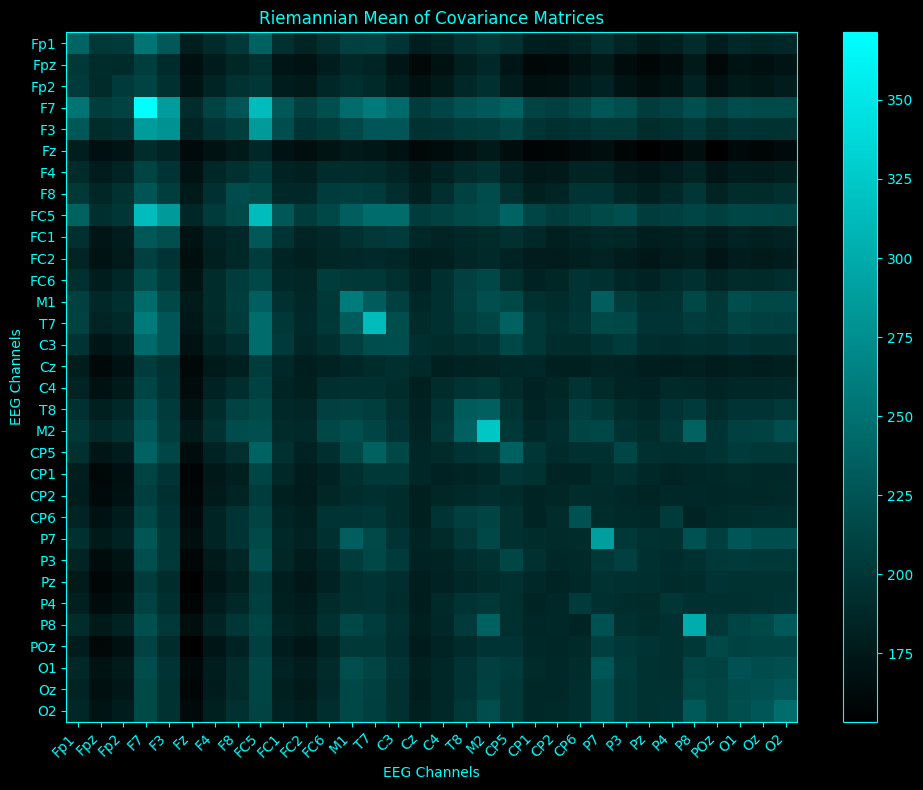

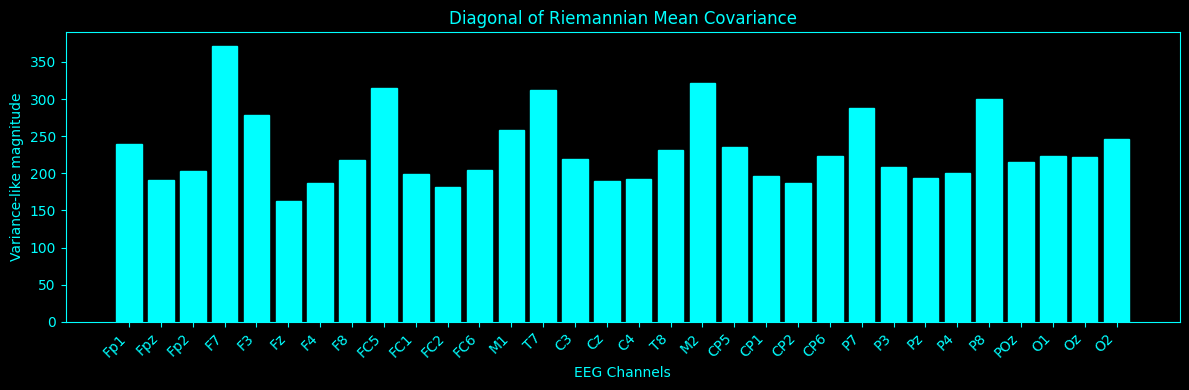


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/riemannian_covariance_results.npz
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/riemannian_covariance_summary.txt
Saved heatmap: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_mean_heatmap.png
Saved diagonal plot: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_mean_diagonal.png


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

window_size_sec = 1.0
samples_per_window = int(window_size_sec * sampling_rate)

# Small diagonal regularization so covariances stay SPD
cov_reg = 1e-6

# Riemannian mean settings
max_iter = 50
tol = 1e-7

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE HELPER
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD MATRIX HELPERS (OWN MATH)
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

# -------------------------------------------------------
# DATA HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(EEG_data, n_channels_expected):
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

    if EEG_data.shape[1] == n_channels_expected:
        return EEG_data
    elif EEG_data.shape[0] == n_channels_expected:
        return EEG_data.T
    else:
        raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

def segment_data(EEG_data_tc, samples_per_window):
    """
    EEG_data_tc shape: (time, channels)
    Returns: (epochs, channels, timepoints)
    """
    total_samples, n_channels = EEG_data_tc.shape
    n_windows = total_samples // samples_per_window

    if n_windows < 1:
        raise ValueError("Not enough samples for even one full window.")

    trimmed = EEG_data_tc[:n_windows * samples_per_window]
    segmented = trimmed.reshape(n_windows, samples_per_window, n_channels)
    segmented = np.transpose(segmented, (0, 2, 1))
    return segmented

def compute_cov_matrices(segmented_data, reg=1e-6):
    """
    segmented_data shape: (epochs, channels, timepoints)
    returns covariance matrices: (epochs, channels, channels)
    """
    epochs, n_channels, n_time = segmented_data.shape

    # center each epoch/channel along time axis
    X = segmented_data - np.mean(segmented_data, axis=2, keepdims=True)

    # vectorized covariance
    covs = np.matmul(X, np.transpose(X, (0, 2, 1))) / max(n_time - 1, 1)

    # regularize
    eye = np.eye(n_channels)[None, :, :]
    covs = covs + reg * eye

    # enforce symmetry
    covs = 0.5 * (covs + np.transpose(covs, (0, 2, 1)))
    return covs

# -------------------------------------------------------
# RIEMANNIAN MEAN (AFFINE-INVARIANT / KARCHER MEAN)
# -------------------------------------------------------
def compute_riemannian_mean(cov_matrices, max_iter=50, tol=1e-7, verbose=True):
    """
    Affine-invariant Riemannian mean of SPD matrices.

    cov_matrices shape: (n_mats, n, n)
    """
    cov_matrices = np.asarray(cov_matrices, dtype=float)
    n_mats, n, _ = cov_matrices.shape

    # initialize with arithmetic mean
    G = symmetrize(np.mean(cov_matrices, axis=0))

    for it in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)

        for C in cov_matrices:
            inner = G_invsqrt @ C @ G_invsqrt
            tangent_sum += logm_spd(inner)

        tangent_mean = tangent_sum / n_mats
        update_norm = np.linalg.norm(tangent_mean, ord="fro")

        if verbose:
            print(f"Iteration {it+1:02d} | tangent Fro norm = {update_norm:.6e}")

        if update_norm < tol:
            break

        G = G_sqrt @ expm_sym(tangent_mean) @ G_sqrt
        G = symmetrize(G)

    return G, it + 1, update_norm

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_data = EEG_data[start_index:end_index, :]

print(f"Loaded EEG segment shape: {EEG_data.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# SEGMENT INTO EPOCHS
# -------------------------------------------------------
segmented_EEG_data = segment_data(EEG_data, samples_per_window=samples_per_window)
print(f"Segmented EEG shape (epochs, channels, timepoints): {segmented_EEG_data.shape}")

# -------------------------------------------------------
# COVARIANCE MATRICES
# -------------------------------------------------------
cov_matrices = compute_cov_matrices(segmented_EEG_data, reg=cov_reg)
print(f"Covariance matrices shape: {cov_matrices.shape}")

# -------------------------------------------------------
# RIEMANNIAN MEAN
# -------------------------------------------------------
riemannian_mean, n_iter_used, final_update_norm = compute_riemannian_mean(
    cov_matrices,
    max_iter=max_iter,
    tol=tol,
    verbose=True
)

print("\nRiemannian mean computed.")
print("Iterations used:", n_iter_used)
print("Final update norm:", final_update_norm)

# -------------------------------------------------------
# SAVE NUMERICAL OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_covariance_results.npz")
np.savez(
    npz_path,
    cov_matrices=cov_matrices,
    riemannian_mean=riemannian_mean,
    segmented_shape=np.array(segmented_EEG_data.shape),
    start_time=start_time,
    end_time=end_time,
    sampling_rate=sampling_rate,
    window_size_sec=window_size_sec,
    cov_reg=cov_reg,
    n_iter_used=n_iter_used,
    final_update_norm=final_update_norm
)

summary_txt = os.path.join(out_dir, "riemannian_covariance_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Mean of EEG Covariance Matrices\n")
    f.write("=========================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"Samples per window: {samples_per_window}\n")
    f.write(f"Epoch shape: {segmented_EEG_data.shape}\n")
    f.write(f"Covariance tensor shape: {cov_matrices.shape}\n")
    f.write(f"Cov regularization: {cov_reg}\n")
    f.write(f"Riemannian mean iterations used: {n_iter_used}\n")
    f.write(f"Final update norm: {final_update_norm:.8e}\n")

# -------------------------------------------------------
# CUSTOM CYAN COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: RIEMANNIAN MEAN HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
style_ax(ax)

# plot magnitude so the cyan colormap makes visual sense
im = ax.imshow(np.abs(riemannian_mean), cmap=custom_cmap, aspect="auto")

ax.set_title("Riemannian Mean of Covariance Matrices")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_yticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
ax.set_yticklabels(eeg_channel_names, color=ACCENT)
ax.set_xlabel("EEG Channels")
ax.set_ylabel("EEG Channels")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

heatmap_path = os.path.join(plots_dir, "riemannian_mean_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DIAGONAL CHANNEL VARIANCES
# -------------------------------------------------------
diag_vals = np.diag(riemannian_mean)

fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.bar(np.arange(len(eeg_channel_names)), diag_vals, color=ACCENT, edgecolor=ACCENT)
ax.set_title("Diagonal of Riemannian Mean Covariance")
ax.set_xlabel("EEG Channels")
ax.set_ylabel("Variance-like magnitude")
ax.set_xticks(np.arange(len(eeg_channel_names)))
ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)

diag_plot_path = os.path.join(plots_dir, "riemannian_mean_diagonal.png")
plt.tight_layout()
plt.savefig(diag_plot_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved heatmap: {heatmap_path}")
print(f"Saved diagonal plot: {diag_plot_path}")

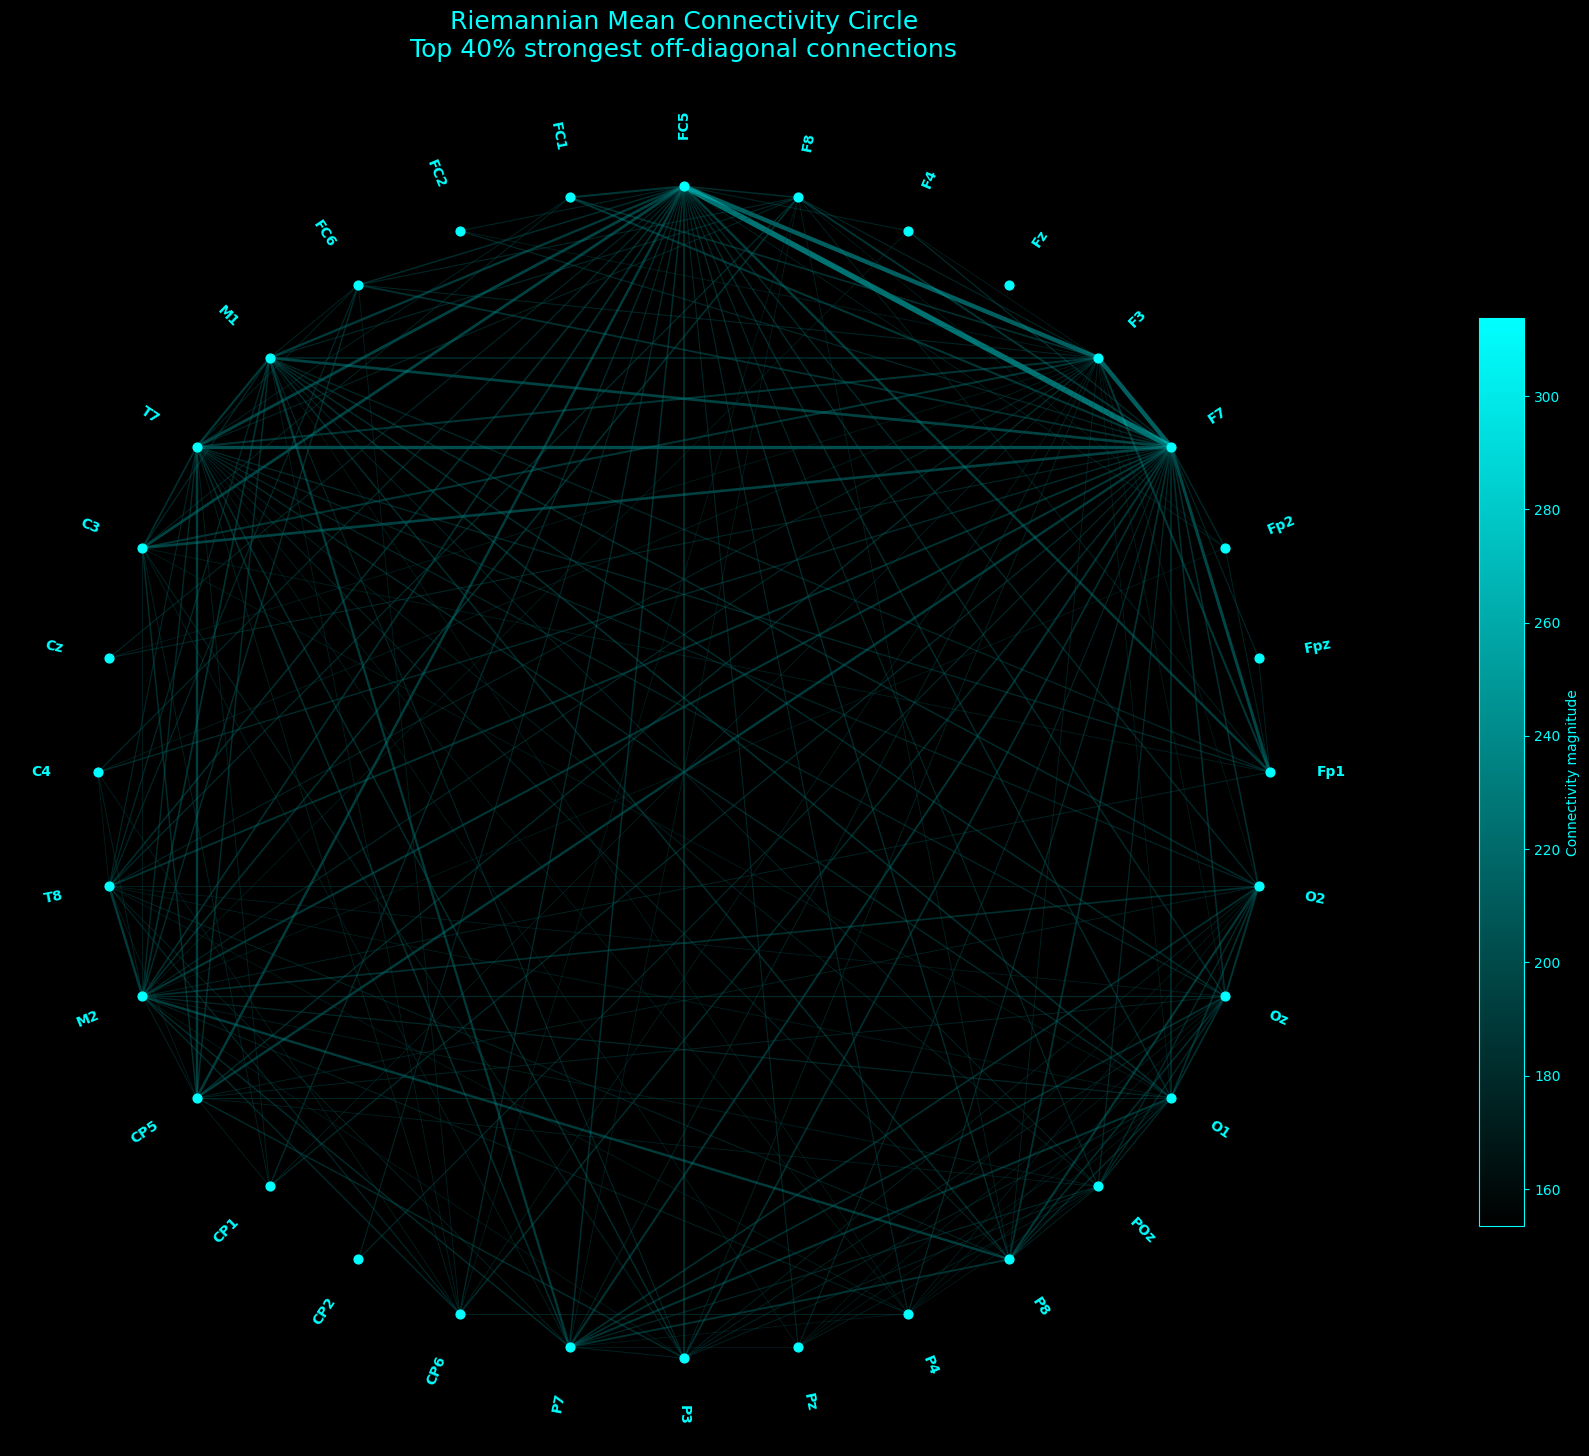

Saved connectivity circle plot to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_connectivity_circle.png


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
plots_dir = os.path.join(base_dir, "riemannian_covariance_analysis", "plots")
os.makedirs(plots_dir, exist_ok=True)

# Keep same plot style as your recent work
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
})

# -------------------------------------------------------
# INPUT CHECK
# -------------------------------------------------------
if "riemannian_mean" not in globals():
    raise ValueError("riemannian_mean is not defined. Run the Riemannian covariance block first.")

if "eeg_channel_names" not in globals():
    raise ValueError("eeg_channel_names is not defined.")

riemannian_mean = np.asarray(riemannian_mean, dtype=float)

if riemannian_mean.ndim != 2 or riemannian_mean.shape[0] != riemannian_mean.shape[1]:
    raise ValueError(f"riemannian_mean must be square, got shape {riemannian_mean.shape}")

if riemannian_mean.shape[0] != len(eeg_channel_names):
    raise ValueError(
        f"Mismatch: riemannian_mean has size {riemannian_mean.shape[0]} "
        f"but eeg_channel_names has length {len(eeg_channel_names)}"
    )

# -------------------------------------------------------
# PARAMETERS
# -------------------------------------------------------
# Percentile threshold on OFF-DIAGONAL connectivity magnitudes
percentile_threshold = 60

# Visual scaling
min_linewidth = 0.5
max_linewidth = 4.0
line_alpha = 0.45
label_radius = 1.08
node_radius = 1.0

# Cyan-style connectivity colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "connectivity_cmap",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)],
    N=256
)

# -------------------------------------------------------
# PREP CONNECTIVITY
# -------------------------------------------------------
# Use magnitude of pairwise covariance-like connectivity for visualization
C = np.abs(riemannian_mean).copy()

# Ignore diagonal for thresholding and line plotting
n_channels = C.shape[0]
upper_i, upper_j = np.triu_indices(n_channels, k=1)
upper_vals = C[upper_i, upper_j]

if len(upper_vals) == 0:
    raise ValueError("No off-diagonal values found in riemannian_mean.")

threshold = np.percentile(upper_vals, percentile_threshold)

# Normalize only using off-diagonal values
vmin = np.min(upper_vals)
vmax = np.max(upper_vals)
if np.isclose(vmax, vmin):
    vmax = vmin + 1e-12

normalize = mcolors.Normalize(vmin=vmin, vmax=vmax)

# Channel angles on circle
angles = np.linspace(0, 2 * np.pi, n_channels, endpoint=False)

# -------------------------------------------------------
# FIGURE
# -------------------------------------------------------
fig = plt.figure(figsize=(16, 16), facecolor=BG)
ax = fig.add_subplot(111, polar=True)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Make the circle clean
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
ax.spines["polar"].set_visible(False)
ax.set_rlim(0, 1.15)

# -------------------------------------------------------
# PLOT CONNECTIONS
# -------------------------------------------------------
for i, j, strength in zip(upper_i, upper_j, upper_vals):
    if strength < threshold:
        continue

    # normalize line width above threshold
    frac = (strength - threshold) / (vmax - threshold + 1e-12)
    linewidth = min_linewidth + frac * (max_linewidth - min_linewidth)
    color = cmap(normalize(strength))

    ax.plot(
        [angles[i], angles[j]],
        [node_radius, node_radius],
        color=color,
        linewidth=linewidth,
        alpha=line_alpha,
        zorder=1
    )

# -------------------------------------------------------
# PLOT NODES
# -------------------------------------------------------
ax.scatter(
    angles,
    np.full(n_channels, node_radius),
    s=40,
    color=ACCENT,
    edgecolors=ACCENT,
    zorder=3
)

# -------------------------------------------------------
# LABELS
# -------------------------------------------------------
for angle, label in zip(angles, eeg_channel_names):
    angle_deg = np.degrees(angle)

    # Flip labels on left side for readability
    if 90 < angle_deg < 270:
        rotation = angle_deg + 180
        ha = "right"
    else:
        rotation = angle_deg
        ha = "left"

    ax.text(
        angle,
        label_radius,
        label,
        color=ACCENT,
        fontsize=10,
        fontweight="bold",
        ha=ha,
        va="center",
        rotation=rotation,
        rotation_mode="anchor",
        zorder=4
    )

# -------------------------------------------------------
# TITLE
# -------------------------------------------------------
ax.set_title(
    f"Riemannian Mean Connectivity Circle\nTop {100 - percentile_threshold:.0f}% strongest off-diagonal connections",
    color=ACCENT,
    fontsize=18,
    pad=30
)

# -------------------------------------------------------
# COLORBAR
# -------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.08, fraction=0.03)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for tick in cbar.ax.get_yticklabels():
    tick.set_color(ACCENT)
cbar.set_label("Connectivity magnitude", color=ACCENT)

# -------------------------------------------------------
# SAVE + SHOW
# -------------------------------------------------------
save_path = os.path.join(plots_dir, "riemannian_connectivity_circle.png")
plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved connectivity circle plot to: {save_path}")

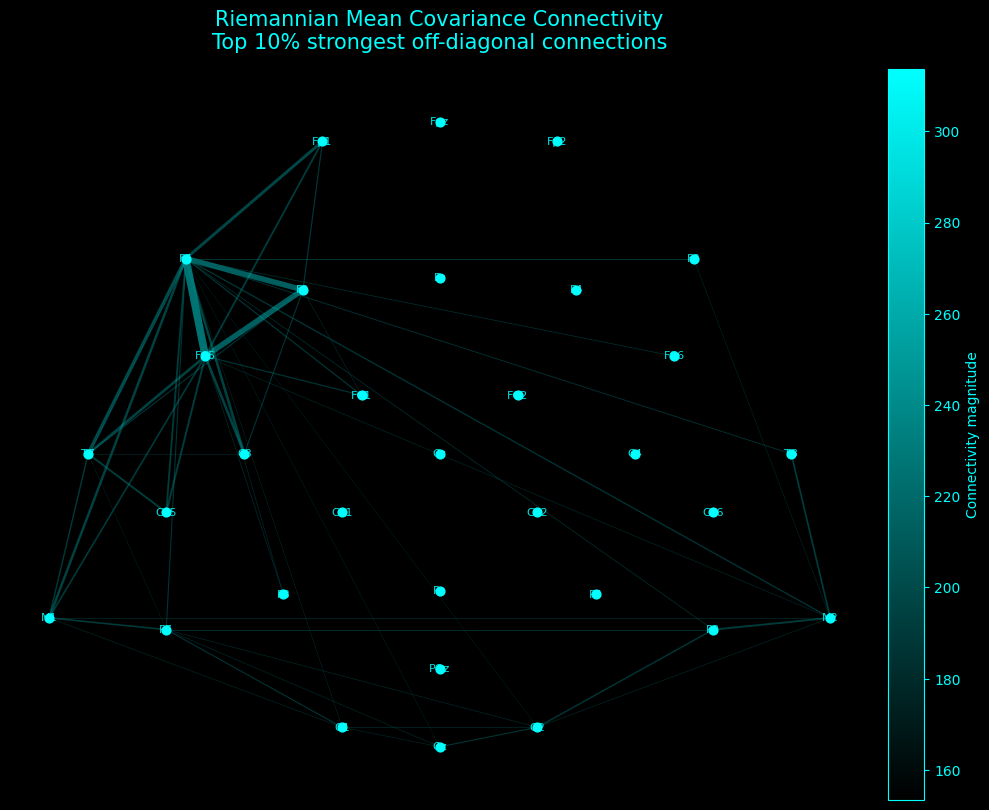

Saved topographic connectivity plot to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_covariance_analysis/plots/riemannian_connectivity_topography.png


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
plots_dir = os.path.join(base_dir, "riemannian_covariance_analysis", "plots")
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
})

# -------------------------------------------------------
# INPUT CHECK
# -------------------------------------------------------
if "riemannian_mean" not in globals():
    raise ValueError("riemannian_mean is not defined. Run the Riemannian covariance block first.")

if "eeg_channel_names" not in globals():
    raise ValueError("eeg_channel_names is not defined.")

riemannian_mean = np.asarray(riemannian_mean, dtype=float)

if riemannian_mean.ndim != 2 or riemannian_mean.shape[0] != riemannian_mean.shape[1]:
    raise ValueError(f"riemannian_mean must be square, got shape {riemannian_mean.shape}")

if riemannian_mean.shape[0] != len(eeg_channel_names):
    raise ValueError(
        f"Mismatch: riemannian_mean has size {riemannian_mean.shape[0]} "
        f"but eeg_channel_names has length {len(eeg_channel_names)}"
    )

# -------------------------------------------------------
# CHANNEL COORDINATES
# -------------------------------------------------------
channel_coords = {
    'Fp1': (-0.3, 0.95), 'Fpz': (0.0, 1.0), 'Fp2': (0.3, 0.95),
    'F7': (-0.65, 0.65), 'F3': (-0.35, 0.57), 'Fz': (0.0, 0.6), 'F4': (0.35, 0.57), 'F8': (0.65, 0.65),
    'FC5': (-0.6, 0.4), 'FC1': (-0.2, 0.3), 'FC2': (0.2, 0.3), 'FC6': (0.6, 0.4),
    'T7': (-0.9, 0.15), 'C3': (-0.5, 0.15), 'Cz': (0.0, 0.15), 'C4': (0.5, 0.15), 'T8': (0.9, 0.15),
    'CP5': (-0.7, 0.0), 'CP1': (-0.25, 0.0), 'CP2': (0.25, 0.0), 'CP6': (0.7, 0.0),
    'P7': (-0.7, -0.3), 'P3': (-0.4, -0.21), 'Pz': (0.0, -0.2), 'P4': (0.4, -0.21), 'P8': (0.7, -0.3),
    'POz': (0.0, -0.4),
    'O1': (-0.25, -0.55), 'Oz': (0.0, -0.6), 'O2': (0.25, -0.55),
    'M1': (-1.0, -0.27), 'M2': (1.0, -0.27)
}

# -------------------------------------------------------
# PARAMETERS
# -------------------------------------------------------
# Keep only strongest off-diagonal connections
percentile_threshold = 90

min_linewidth = 0.25
max_linewidth = 5.5
line_alpha = 0.45
node_size = 40
label_fontsize = 8

# Colormap
cmap = mcolors.LinearSegmentedColormap.from_list(
    "connectivity_cmap",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)],
    N=256
)

# -------------------------------------------------------
# PREP CONNECTIVITY
# -------------------------------------------------------
C = np.abs(riemannian_mean).copy()

# Use only channel pairs whose coordinates exist
valid_indices = [i for i, ch in enumerate(eeg_channel_names) if ch in channel_coords]
valid_names = [eeg_channel_names[i] for i in valid_indices]

if len(valid_indices) < 2:
    raise ValueError("Not enough valid channels with defined coordinates.")

# Build list of valid off-diagonal pair strengths
pair_info = []
for a, i in enumerate(valid_indices):
    for b, j in enumerate(valid_indices):
        if i < j:
            pair_info.append((i, j, eeg_channel_names[i], eeg_channel_names[j], C[i, j]))

pair_strengths = np.array([p[4] for p in pair_info], dtype=float)

if len(pair_strengths) == 0:
    raise ValueError("No valid channel pairs available for plotting.")

threshold = np.percentile(pair_strengths, percentile_threshold)

vmin = np.min(pair_strengths)
vmax = np.max(pair_strengths)
if np.isclose(vmax, vmin):
    vmax = vmin + 1e-12

normalize = mcolors.Normalize(vmin=vmin, vmax=vmax)

# -------------------------------------------------------
# FIGURE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# -------------------------------------------------------
# PLOT CONNECTIONS
# -------------------------------------------------------
for i, j, ch1, ch2, strength in pair_info:
    if strength < threshold:
        continue

    frac = (strength - threshold) / (vmax - threshold + 1e-12)
    linewidth = min_linewidth + frac * (max_linewidth - min_linewidth)
    color = cmap(normalize(strength))

    x1, y1 = channel_coords[ch1]
    x2, y2 = channel_coords[ch2]

    ax.plot(
        [x1, x2],
        [y1, y2],
        alpha=line_alpha,
        linewidth=linewidth,
        color=color,
        linestyle='-',
        zorder=1
    )

# -------------------------------------------------------
# PLOT NODES
# -------------------------------------------------------
for ch in valid_names:
    x, y = channel_coords[ch]
    ax.scatter(
        x, y,
        s=node_size,
        color=ACCENT,
        edgecolors=ACCENT,
        zorder=3
    )

# -------------------------------------------------------
# PLOT LABELS
# -------------------------------------------------------
for ch in valid_names:
    x, y = channel_coords[ch]
    ax.text(
        x, y,
        ch,
        ha='center',
        va='center',
        color=ACCENT,
        fontsize=label_fontsize,
        alpha=0.9,
        zorder=4
    )

# -------------------------------------------------------
# AXIS / TITLE
# -------------------------------------------------------
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(
    f"Riemannian Mean Covariance Connectivity\nTop {100 - percentile_threshold:.0f}% strongest off-diagonal connections",
    color=ACCENT,
    size=15,
    pad=30
)

# -------------------------------------------------------
# COLORBAR
# -------------------------------------------------------
sm = plt.cm.ScalarMappable(cmap=cmap, norm=normalize)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, pad=0.02, fraction=0.04)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.yaxis.label.set_color(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for tick in cbar.ax.get_yticklabels():
    tick.set_color(ACCENT)
cbar.set_label("Connectivity magnitude", color=ACCENT)

# -------------------------------------------------------
# SAVE + SHOW
# -------------------------------------------------------
save_path = os.path.join(plots_dir, "riemannian_connectivity_topography.png")
plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"Saved topographic connectivity plot to: {save_path}")

### Riemann Curvature Tensor on the SPD Covariance Manifold

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis computes a reduced <strong>Riemann curvature tensor</strong> for the manifold of symmetric positive definite (SPD) covariance matrices derived from EEG epochs. The covariance matrices are first summarized by their affine-invariant Riemannian mean, and then the local geometry around that mean is studied through curvature. Because the full tangent space is very large, the code projects the problem into a <strong>data-driven reduced tangent basis</strong> obtained from the dominant singular vectors of the EEG covariance variation.</p>
        <h2>Geometric Setting</h2>
        <p>The covariance matrices live on the SPD manifold, not in ordinary Euclidean space. The code uses the <strong>affine-invariant Riemannian metric</strong>, which is standard for covariance geometry because it respects the intrinsic structure of SPD matrices.</p>
        <p><strong>Whitened tangent coordinates:</strong></p>
        \[
        X_i = \log\!\left(P^{-1/2} C_i P^{-1/2}\right)
        \]
        <p>where \(C_i\) is the covariance matrix of epoch \(i\), and \(P\) is the Riemannian mean. This maps each covariance matrix into the tangent space at the mean in identity coordinates.</p>
        <h2>Reduced Tangent Basis</h2>
        <p>The tangent vectors are vectorized using a symmetric-matrix encoding that preserves the Frobenius inner product. After centering these tangent vectors, singular value decomposition (SVD) is applied to identify the dominant modes of covariance variation.</p>
        <p><strong>SVD:</strong></p>
        \[
        T = U \Sigma V^\top
        \]
        <p>The first \(k\) right-singular vectors define the reduced tangent basis used for curvature calculations. This makes the tensor tractable while preserving the most meaningful directions of variation in the EEG covariance data.</p>
        <h2>Riemann Curvature Tensor</h2>
        <p>For the SPD manifold with the affine-invariant metric, the curvature at the identity takes a closed form in terms of matrix commutators.</p>
        <p><strong>Curvature operator:</strong></p>
        \[
        R(X,Y)Z = -\frac{1}{4}\, [[X,Y],Z]
        \]
        <p>where the commutator is</p>
        \[
        [X,Y] = XY - YX
        \]
        <p>The reduced tensor components are then computed in the data-driven basis \(\{B_a\}\):</p>
        \[
        R_{abcd} = \langle R(B_a,B_b)B_c,\; B_d\rangle
        \]
        <p>with the Frobenius inner product</p>
        \[
        \langle A,B\rangle = \mathrm{tr}(A^\top B)
        \]
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Sectional Curvature</h2>
        <p>The code also computes the sectional curvature between pairs of orthonormal tangent directions. This tells us how sharply the SPD covariance manifold bends in each two-dimensional plane of the reduced tangent space.</p>
        <p><strong>Sectional curvature:</strong></p>
        \[
        K(X,Y) = \langle R(X,Y)Y,\; X\rangle
        \]
        <p>For the affine-invariant SPD manifold, sectional curvature is typically non-positive, so negative values indicate saddle-like intrinsic geometry. This is useful for understanding the local organization of EEG covariance states.</p>
        <h2>Implementation Details</h2>
        <p>The code follows these steps:</p>
        <ul>
            <li>Load the previously computed EEG covariance matrices and their Riemannian mean.</li>
            <li>Map each covariance matrix into the tangent space at the mean using the matrix logarithm.</li>
            <li>Vectorize and center the tangent vectors.</li>
            <li>Use SVD to obtain the top \(k\) reduced tangent directions.</li>
            <li>Compute the reduced Riemann curvature tensor \(R_{abcd}\).</li>
            <li>Compute the sectional curvature matrix \(K_{ab}\).</li>
            <li>Summarize and visualize the curvature structure.</li>
        </ul>
        <h2>Outputs and Visualizations</h2>
        <p>The code generates several outputs:</p>
        <ul>
            <li><strong>Reduced curvature tensor</strong> saved in an NPZ file.</li>
            <li><strong>Sectional curvature heatmap</strong> showing curvature between basis directions.</li>
            <li><strong>Mean sectional curvature bar plot</strong> summarizing how curved each dominant direction is on average.</li>
            <li><strong>SVD singular values plot</strong> showing how much covariance variation is captured by each reduced tangent direction.</li>
            <li><strong>CSV and TXT summaries</strong> describing global curvature statistics.</li>
        </ul>
        <h2>Interpretation</h2>
        <p>This analysis does not just measure covariance strength; it measures the <strong>intrinsic geometry of covariance variation</strong>. If the reduced tangent basis shows strongly negative sectional curvature, that means nearby EEG covariance states diverge in a saddle-like manner on the SPD manifold. If the curvature is weak, the local manifold is closer to flat in those directions.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a geometric description of EEG covariance dynamics by computing a reduced Riemann curvature tensor on the SPD manifold. Instead of treating covariance matrices as ordinary Euclidean points, it studies them as points on a curved manifold and quantifies how that manifold bends around the Riemannian mean. This gives a deeper characterization of the structure of EEG covariance organization than simple averaging alone.</p>
    </div>
</div>

Loaded covariance tensor: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Full tangent dimension: 528
Using reduced tangent basis dimension: 8

Reduced-basis curvature summary:
   basis_index  svd_singular_value  self_norm  \
0            0           15.132345        1.0   
1            1            9.509011        1.0   
2            2            7.507333        1.0   
3            3            6.012405        1.0   
4            4            5.661071        1.0   
5            5            5.268066        1.0   
6            6            5.090050        1.0   
7            7            4.991946        1.0   

   mean_sectional_curvature_vs_others  min_sectional_curvature_vs_others  \
0                           -0.012562                          -0.024685   
1                           -0.005284                          -0.006262   
2                           -0.010631                          -0.017261   
3                           -0.013264                          -0.022162   
4 

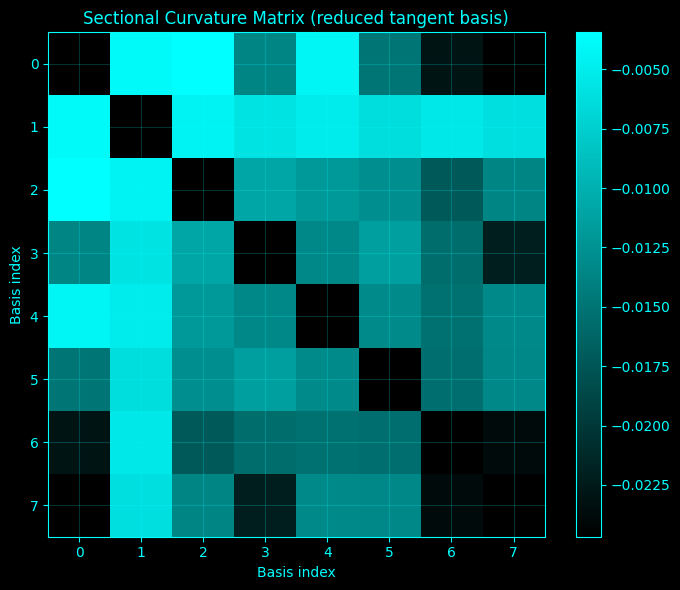

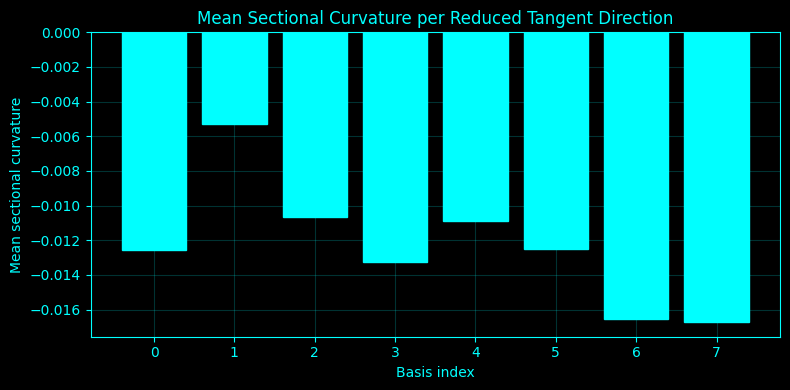

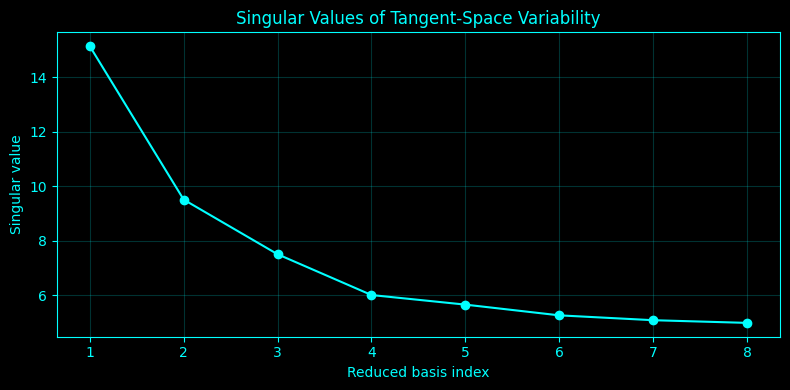


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/riemann_curvature_tensor_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemann_curvature_tensor_analysis/plots


In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemann_curvature_tensor_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Reduced tangent subspace dimension
top_k = 8

# Numerical floor
eps = 1e-12

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def fro_inner(A, B):
    return float(np.sum(A * B))

def fro_norm(A):
    return float(np.sqrt(max(fro_inner(A, A), 0.0)))

def commutator(A, B):
    return A @ B - B @ A

# -------------------------------------------------------
# SYMMETRIC VECTORIZATION (ISOMETRIC FOR FROBENIUS NORM)
# -------------------------------------------------------
def symmat_to_vec(S):
    """
    Vectorize a symmetric matrix with sqrt(2) weighting on off-diagonals
    so Euclidean inner product matches Frobenius inner product.
    """
    S = symmetrize(np.asarray(S, dtype=float))
    n = S.shape[0]
    vals = []
    for i in range(n):
        vals.append(S[i, i])
    for i in range(n):
        for j in range(i + 1, n):
            vals.append(np.sqrt(2.0) * S[i, j])
    return np.asarray(vals, dtype=float)

def vec_to_symmat(v, n):
    S = np.zeros((n, n), dtype=float)
    idx = 0
    for i in range(n):
        S[i, i] = v[idx]
        idx += 1
    for i in range(n):
        for j in range(i + 1, n):
            val = v[idx] / np.sqrt(2.0)
            S[i, j] = val
            S[j, i] = val
            idx += 1
    return S

# -------------------------------------------------------
# LOG MAP TO IDENTITY COORDINATES
# -------------------------------------------------------
def whiten_to_identity_tangent(C, P_invsqrt):
    """
    Identity-coordinate tangent:
      X = log(P^{-1/2} C P^{-1/2})
    """
    inner = P_invsqrt @ C @ P_invsqrt
    return symmetrize(logm_spd(inner))

# -------------------------------------------------------
# AFFINE-INVARIANT CURVATURE ON SPD
# -------------------------------------------------------
def riemann_curvature_at_identity(X, Y, Z):
    """
    For SPD manifold with affine-invariant metric:
        R(X, Y)Z = -1/4 [[X, Y], Z]
    at the identity, where X,Y,Z are symmetric tangent matrices.
    """
    return -0.25 * commutator(commutator(X, Y), Z)

def sectional_curvature_orthonormal(X, Y):
    """
    For orthonormal X,Y in identity coordinates:
        K(X,Y) = <R(X,Y)Y, X>
    """
    Rxyy = riemann_curvature_at_identity(X, Y, Y)
    return fro_inner(Rxyy, X)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean code first."
    )

data = np.load(riem_npz_path, allow_pickle=True)
cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
P = np.asarray(data["riemannian_mean"], dtype=float)

n_epochs, n_channels, _ = cov_matrices.shape
print(f"Loaded covariance tensor: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {P.shape}")

# -------------------------------------------------------
# BUILD DATA-DRIVEN TANGENT SUBSPACE
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(P)

# Tangent coordinates at identity
tangent_vecs = []
for i in range(n_epochs):
    Xi = whiten_to_identity_tangent(cov_matrices[i], P_invsqrt)
    tangent_vecs.append(symmat_to_vec(Xi))

T = np.stack(tangent_vecs, axis=0)   # shape: (epochs, tangent_dim_full)
T = T - np.mean(T, axis=0, keepdims=True)

full_tangent_dim = T.shape[1]
k_eff = min(top_k, n_epochs, full_tangent_dim)

# SVD for orthonormal basis directions
U, Svals, Vt = np.linalg.svd(T, full_matrices=False)
basis_vecs = Vt[:k_eff]  # rows are orthonormal in Euclidean coords

basis_mats = [vec_to_symmat(basis_vecs[i], n_channels) for i in range(k_eff)]

print(f"Full tangent dimension: {full_tangent_dim}")
print(f"Using reduced tangent basis dimension: {k_eff}")

# -------------------------------------------------------
# CURVATURE TENSOR IN REDUCED BASIS
# -------------------------------------------------------
# Tensor components:
#   R[a,b,c,d] = < R(B_a, B_b) B_c , B_d >
R_tensor = np.zeros((k_eff, k_eff, k_eff, k_eff), dtype=float)

for a in range(k_eff):
    for b in range(k_eff):
        for c in range(k_eff):
            Rab_c = riemann_curvature_at_identity(basis_mats[a], basis_mats[b], basis_mats[c])
            for d in range(k_eff):
                R_tensor[a, b, c, d] = fro_inner(Rab_c, basis_mats[d])

# -------------------------------------------------------
# SECTIONAL CURVATURE MATRIX
# -------------------------------------------------------
K_sec = np.full((k_eff, k_eff), np.nan, dtype=float)

for a in range(k_eff):
    for b in range(k_eff):
        if a == b:
            K_sec[a, b] = np.nan
        else:
            K_sec[a, b] = sectional_curvature_orthonormal(basis_mats[a], basis_mats[b])

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
rows = []
for a in range(k_eff):
    row = {
        "basis_index": a,
        "svd_singular_value": float(Svals[a]) if a < len(Svals) else np.nan,
        "self_norm": fro_norm(basis_mats[a]),
        "mean_sectional_curvature_vs_others": float(np.nanmean(K_sec[a])),
        "min_sectional_curvature_vs_others": float(np.nanmin(K_sec[a])),
        "max_sectional_curvature_vs_others": float(np.nanmax(K_sec[a])),
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

global_summary = {
    "k_eff": k_eff,
    "n_epochs": n_epochs,
    "n_channels": n_channels,
    "full_tangent_dim": full_tangent_dim,
    "mean_sectional_curvature": float(np.nanmean(K_sec)),
    "min_sectional_curvature": float(np.nanmin(K_sec)),
    "max_sectional_curvature": float(np.nanmax(K_sec)),
    "fraction_negative_sectional_curvature": float(np.mean(K_sec[np.isfinite(K_sec)] < 0)),
}

print("\nReduced-basis curvature summary:")
print(summary_df)
print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemann_curvature_tensor_results.npz")
np.savez(
    npz_path,
    riemannian_mean=P,
    cov_matrices_shape=np.array(cov_matrices.shape),
    basis_vectors=basis_vecs,
    basis_matrices=np.stack(basis_mats, axis=0),
    singular_values=Svals[:k_eff],
    R_tensor=R_tensor,
    sectional_curvature=K_sec,
    top_k_used=k_eff
)

summary_csv = os.path.join(out_dir, "riemann_curvature_tensor_summary.csv")
summary_df.to_csv(summary_csv, index=False)

global_txt = os.path.join(out_dir, "riemann_curvature_tensor_summary.txt")
with open(global_txt, "w") as f:
    f.write("Riemann Curvature Tensor on the SPD Covariance Manifold\n")
    f.write("=====================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Full tangent dimension: {full_tangent_dim}\n")
    f.write(f"Reduced basis dimension: {k_eff}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SECTIONAL CURVATURE HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

# show magnitude but keep signs in text summary
im = ax.imshow(K_sec, cmap=custom_cmap, aspect="auto")
ax.set_title("Sectional Curvature Matrix (reduced tangent basis)")
ax.set_xlabel("Basis index")
ax.set_ylabel("Basis index")
ax.set_xticks(np.arange(k_eff))
ax.set_yticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)
ax.set_yticklabels(np.arange(k_eff), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

heatmap_path = os.path.join(plots_dir, "sectional_curvature_heatmap.png")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: MEAN SECTIONAL CURVATURE PER BASIS DIRECTION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(k_eff),
    summary_df["mean_sectional_curvature_vs_others"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean Sectional Curvature per Reduced Tangent Direction")
ax.set_xlabel("Basis index")
ax.set_ylabel("Mean sectional curvature")
ax.set_xticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)

bar_path = os.path.join(plots_dir, "mean_sectional_curvature_per_basis.png")
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: SINGULAR VALUES OF TANGENT VARIATION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    np.arange(1, k_eff + 1),
    Svals[:k_eff],
    marker="o",
    color=ACCENT
)
ax.set_title("Singular Values of Tangent-Space Variability")
ax.set_xlabel("Reduced basis index")
ax.set_ylabel("Singular value")

sv_path = os.path.join(plots_dir, "tangent_svd_singular_values.png")
plt.tight_layout()
plt.savefig(sv_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {global_txt}")
print(f"Saved plots to: {plots_dir}")

### Riemannian Distance Landscape Across EEG Covariance Epochs

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Segment: [814.571, 921.515] sec
Window size: 1.0 sec

Global Riemannian distance summary:
n_epochs: 106
n_channels: 32
segment_start_sec: 814.571
segment_end_sec: 921.515
window_size_sec: 1.0
mean_distance: 3.474116426816656
std_distance: 0.8659323020733664
min_distance: 2.580624259571224
max_distance: 8.08029750296199
median_distance: 3.238975676518984
q10_distance: 2.869886046598256
q90_distance: 4.080990224374581
mean_speed_abs: 0.6507877701351907
max_speed_abs: 4.645610548984998
farthest_epoch_index: 4
nearest_epoch_index: 11


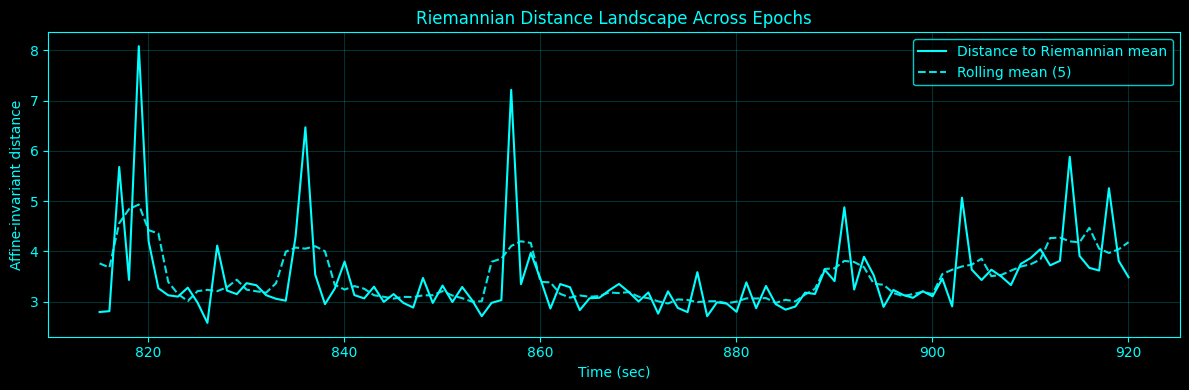

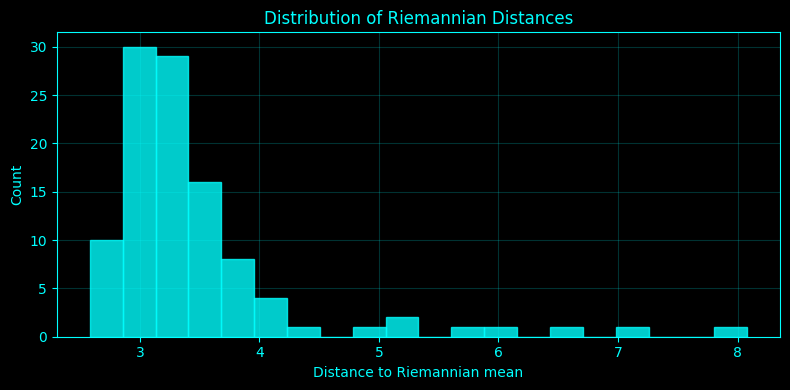

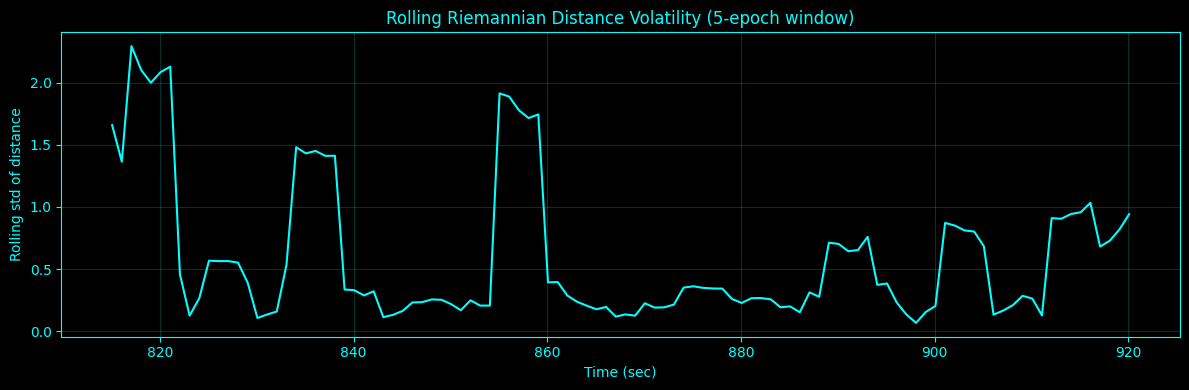

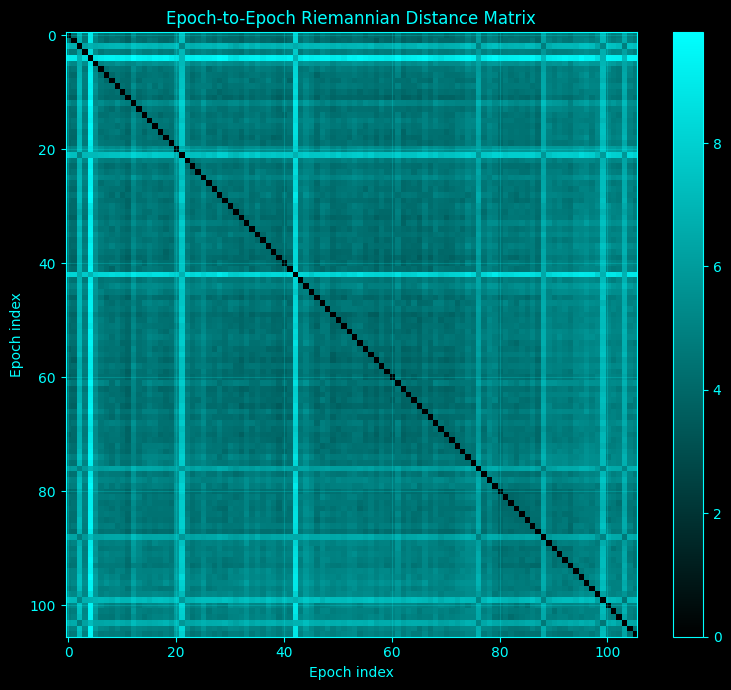

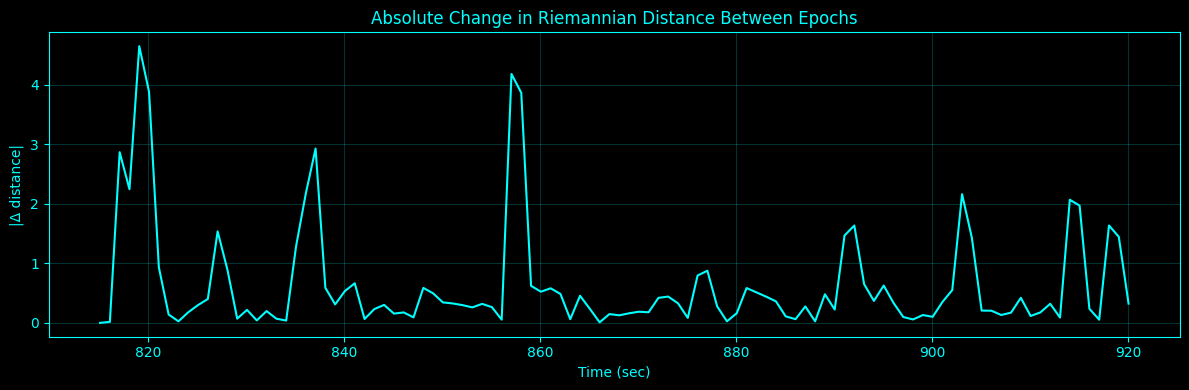


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/riemannian_distance_landscape_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_distance_landscape/plots


In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemannian_distance_landscape")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

rolling_window = 5   # epochs
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    """
    d_R(C, P) = || log(P^{-1/2} C P^{-1/2}) ||_F
    """
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))

    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)

    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
sampling_rate = float(data["sampling_rate"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")
print(f"Window size: {window_size_sec} sec")

# -------------------------------------------------------
# DISTANCE TO RIEMANNIAN MEAN
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

distances = np.zeros(n_epochs, dtype=float)
for i in range(n_epochs):
    distances[i] = affine_invariant_distance(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)

# Epoch timing
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

# Basic derived quantities
distance_z = (distances - np.mean(distances)) / (np.std(distances) + 1e-12)
distance_delta = np.diff(distances, prepend=distances[0])
distance_speed = np.abs(distance_delta)

# Rolling stats via pandas for convenience
dist_s = pd.Series(distances)
rolling_mean = dist_s.rolling(rolling_window, center=True, min_periods=1).mean().to_numpy()
rolling_std = dist_s.rolling(rolling_window, center=True, min_periods=1).std().fillna(0.0).to_numpy()

# Pairwise epoch-to-epoch Riemannian distance matrix
epoch_distance_matrix = np.zeros((n_epochs, n_epochs), dtype=float)
for i in range(n_epochs):
    epoch_distance_matrix[i, i] = 0.0
    for j in range(i + 1, n_epochs):
        dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
        epoch_distance_matrix[i, j] = dij
        epoch_distance_matrix[j, i] = dij

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "distance_to_riemannian_mean": distances,
    "distance_zscore": distance_z,
    "distance_delta": distance_delta,
    "distance_speed_abs": distance_speed,
    "rolling_mean_distance": rolling_mean,
    "rolling_std_distance": rolling_std,
})

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "segment_start_sec": start_time,
    "segment_end_sec": end_time,
    "window_size_sec": window_size_sec,
    "mean_distance": float(np.mean(distances)),
    "std_distance": float(np.std(distances)),
    "min_distance": float(np.min(distances)),
    "max_distance": float(np.max(distances)),
    "median_distance": float(np.median(distances)),
    "q10_distance": float(np.quantile(distances, 0.10)),
    "q90_distance": float(np.quantile(distances, 0.90)),
    "mean_speed_abs": float(np.mean(distance_speed)),
    "max_speed_abs": float(np.max(distance_speed)),
    "farthest_epoch_index": int(np.argmax(distances)),
    "nearest_epoch_index": int(np.argmin(distances)),
}

print("\nGlobal Riemannian distance summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_distance_landscape_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    distances=distances,
    distance_z=distance_z,
    distance_delta=distance_delta,
    distance_speed=distance_speed,
    rolling_mean=rolling_mean,
    rolling_std=rolling_std,
    epoch_distance_matrix=epoch_distance_matrix,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    window_size_sec=window_size_sec,
    start_time=start_time,
    end_time=end_time,
)

summary_csv = os.path.join(out_dir, "riemannian_distance_landscape_summary.csv")
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_distance_landscape_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Distance Landscape Across Epochs\n")
    f.write("=========================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: DISTANCE LANDSCAPE OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, distances, color=ACCENT, linewidth=1.5, label="Distance to Riemannian mean")
ax.plot(epoch_center_time, rolling_mean, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.9, label=f"Rolling mean ({rolling_window})")

ax.set_title("Riemannian Distance Landscape Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Affine-invariant distance")
ax.legend()

plot1_path = os.path.join(plots_dir, "distance_landscape_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: HISTOGRAM OF DISTANCES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.hist(distances, bins=20, color=ACCENT, edgecolor=ACCENT, alpha=0.8)
ax.set_title("Distribution of Riemannian Distances")
ax.set_xlabel("Distance to Riemannian mean")
ax.set_ylabel("Count")

plot2_path = os.path.join(plots_dir, "distance_histogram.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: ROLLING STD / VOLATILITY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, rolling_std, color=ACCENT, linewidth=1.5)
ax.set_title(f"Rolling Riemannian Distance Volatility ({rolling_window}-epoch window)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Rolling std of distance")

plot3_path = os.path.join(plots_dir, "distance_volatility.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: EPOCH-TO-EPOCH DISTANCE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(epoch_distance_matrix, cmap=custom_cmap, aspect="auto")
ax.set_title("Epoch-to-Epoch Riemannian Distance Matrix")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Epoch index")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "epoch_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: DISTANCE SPEED
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, distance_speed, color=ACCENT, linewidth=1.5)
ax.set_title("Absolute Change in Riemannian Distance Between Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("|Δ distance|")

plot5_path = os.path.join(plots_dir, "distance_speed.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Geodesic Dispersion / Manifold Variance of EEG Covariance Epochs

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Segment: [814.571, 921.515] sec
Window size: 1.0 sec

Global geodesic dispersion summary:
n_epochs: 106
n_channels: 32
segment_start_sec: 814.571
segment_end_sec: 921.515
window_size_sec: 1.0
manifold_variance: 12.819323698851402
manifold_std: 3.580408314543385
mean_distance_to_mean: 3.474116426816656
std_distance_to_mean: 0.8659323020733664
mean_squared_distance_to_mean: 12.819323698851402
max_squared_distance_to_mean: 65.29120773637378
min_squared_distance_to_mean: 6.659621569087528
mean_pairwise_distance: 5.04765942277044
mean_pairwise_squared_distance: 26.63568934502598
most_dispersive_epoch_index: 4
least_dispersive_epoch_index: 11
max_variance_contribution: 0.04804893022718342


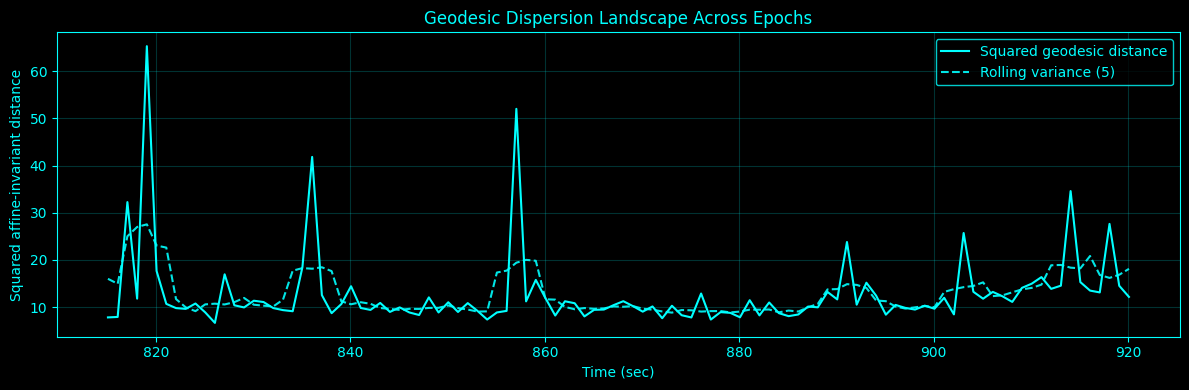

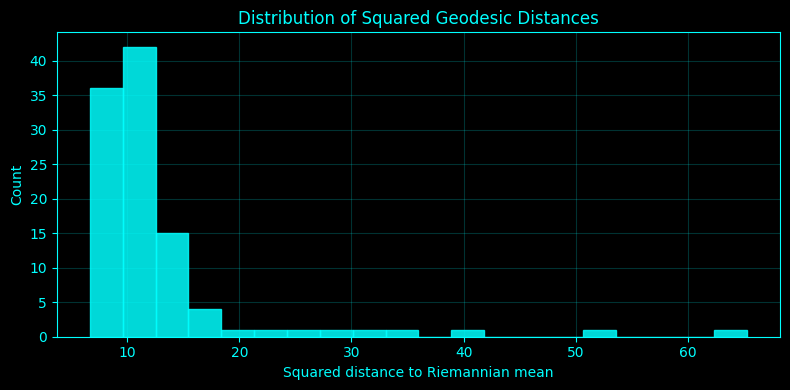

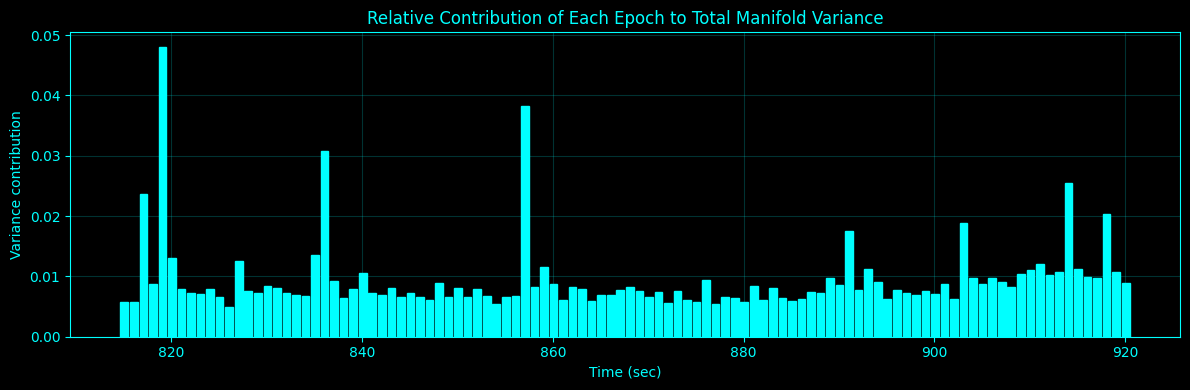

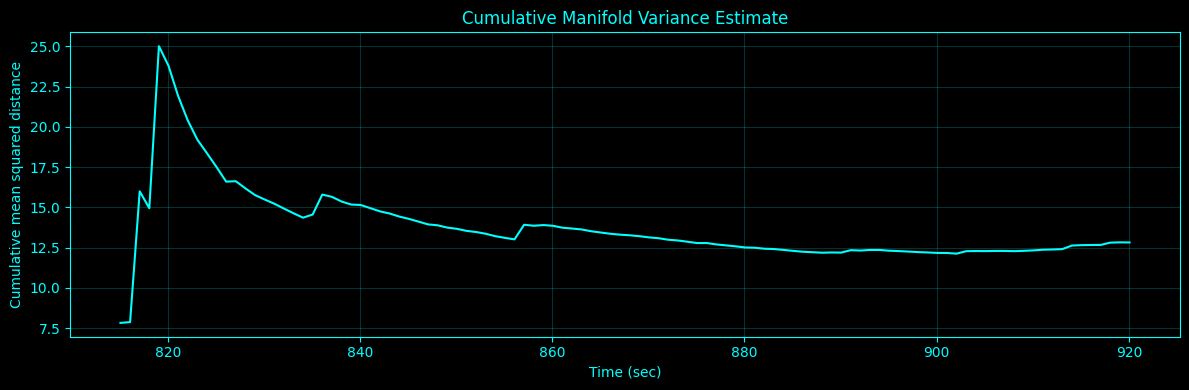

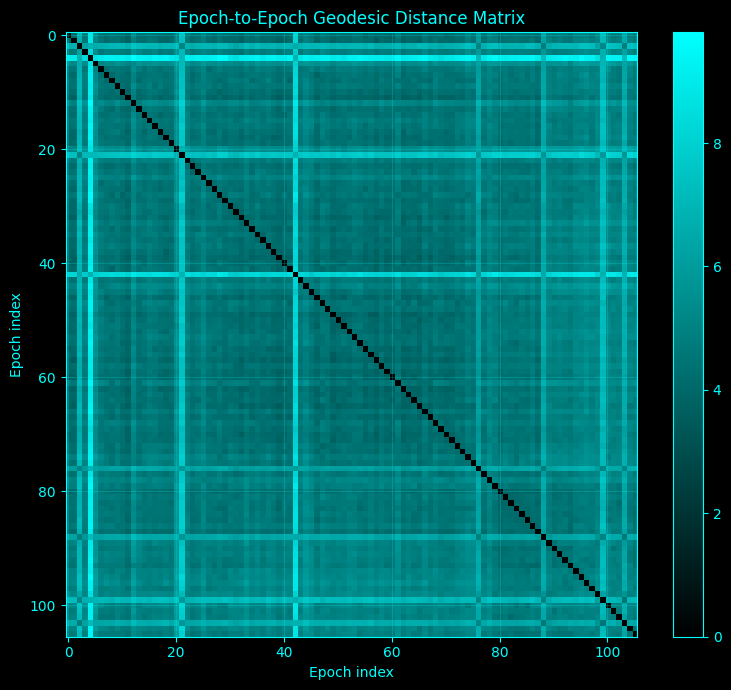


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_geodesic_dispersion
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_geodesic_dispersion/riemannian_geodesic_dispersion_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_geodesic_dispersion/riemannian_geodesic_dispersion_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_geodesic_dispersion/riemannian_geodesic_dispersion_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_geodesic_dispersion/plots


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "riemannian_geodesic_dispersion")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"

rolling_window = 5
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
sampling_rate = float(data["sampling_rate"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")
print(f"Segment: [{start_time}, {end_time}] sec")
print(f"Window size: {window_size_sec} sec")

# -------------------------------------------------------
# DISTANCES, SQUARED DISTANCES, DISPERSION
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

distances = np.zeros(n_epochs, dtype=float)
squared_distances = np.zeros(n_epochs, dtype=float)

for i in range(n_epochs):
    d = affine_invariant_distance(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)
    distances[i] = d
    squared_distances[i] = d ** 2

# Fréchet / manifold variance
manifold_variance = float(np.mean(squared_distances))
manifold_std = float(np.sqrt(manifold_variance))

# Epoch timing
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

# Relative contribution of each epoch to total variance
variance_contribution = squared_distances / (np.sum(squared_distances) + 1e-12)

# Rolling intrinsic dispersion
sq_s = pd.Series(squared_distances)
rolling_var = sq_s.rolling(rolling_window, center=True, min_periods=1).mean().to_numpy()
rolling_std = np.sqrt(np.maximum(rolling_var, 0.0))

# Cumulative dispersion profile
cumulative_var = np.cumsum(squared_distances) / np.arange(1, n_epochs + 1)

# Pairwise epoch distance matrix and pairwise average dispersion
epoch_distance_matrix = np.zeros((n_epochs, n_epochs), dtype=float)
for i in range(n_epochs):
    epoch_distance_matrix[i, i] = 0.0
    for j in range(i + 1, n_epochs):
        dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
        epoch_distance_matrix[i, j] = dij
        epoch_distance_matrix[j, i] = dij

upper_i, upper_j = np.triu_indices(n_epochs, k=1)
pairwise_distances = epoch_distance_matrix[upper_i, upper_j]
mean_pairwise_distance = float(np.mean(pairwise_distances))
mean_pairwise_squared_distance = float(np.mean(pairwise_distances ** 2))

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "distance_to_mean": distances,
    "squared_distance_to_mean": squared_distances,
    "variance_contribution": variance_contribution,
    "rolling_manifold_variance": rolling_var,
    "rolling_manifold_std": rolling_std,
    "cumulative_manifold_variance": cumulative_var,
})

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "segment_start_sec": start_time,
    "segment_end_sec": end_time,
    "window_size_sec": window_size_sec,
    "manifold_variance": manifold_variance,
    "manifold_std": manifold_std,
    "mean_distance_to_mean": float(np.mean(distances)),
    "std_distance_to_mean": float(np.std(distances)),
    "mean_squared_distance_to_mean": float(np.mean(squared_distances)),
    "max_squared_distance_to_mean": float(np.max(squared_distances)),
    "min_squared_distance_to_mean": float(np.min(squared_distances)),
    "mean_pairwise_distance": mean_pairwise_distance,
    "mean_pairwise_squared_distance": mean_pairwise_squared_distance,
    "most_dispersive_epoch_index": int(np.argmax(squared_distances)),
    "least_dispersive_epoch_index": int(np.argmin(squared_distances)),
    "max_variance_contribution": float(np.max(variance_contribution)),
}

print("\nGlobal geodesic dispersion summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_geodesic_dispersion_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    distances=distances,
    squared_distances=squared_distances,
    variance_contribution=variance_contribution,
    rolling_var=rolling_var,
    rolling_std=rolling_std,
    cumulative_var=cumulative_var,
    epoch_distance_matrix=epoch_distance_matrix,
    pairwise_distances=pairwise_distances,
    manifold_variance=manifold_variance,
    manifold_std=manifold_std,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    start_time=start_time,
    end_time=end_time,
    window_size_sec=window_size_sec,
)

summary_csv = os.path.join(out_dir, "riemannian_geodesic_dispersion_summary.csv")
summary_df.to_csv(summary_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_geodesic_dispersion_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Geodesic Dispersion / Manifold Variance on the SPD Covariance Manifold\n")
    f.write("====================================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SQUARED DISTANCE LANDSCAPE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, squared_distances, color=ACCENT, linewidth=1.5, label="Squared geodesic distance")
ax.plot(epoch_center_time, rolling_var, color=ACCENT, linestyle="--", linewidth=1.5, alpha=0.9, label=f"Rolling variance ({rolling_window})")

ax.set_title("Geodesic Dispersion Landscape Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Squared affine-invariant distance")
ax.legend()

plot1_path = os.path.join(plots_dir, "geodesic_dispersion_landscape.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: HISTOGRAM OF SQUARED DISTANCES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.hist(squared_distances, bins=20, color=ACCENT, edgecolor=ACCENT, alpha=0.85)
ax.set_title("Distribution of Squared Geodesic Distances")
ax.set_xlabel("Squared distance to Riemannian mean")
ax.set_ylabel("Count")

plot2_path = os.path.join(plots_dir, "squared_distance_histogram.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: VARIANCE CONTRIBUTION PER EPOCH
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.bar(epoch_center_time, variance_contribution, width=0.8 * window_size_sec, color=ACCENT, edgecolor=ACCENT)
ax.set_title("Relative Contribution of Each Epoch to Total Manifold Variance")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Variance contribution")

plot3_path = os.path.join(plots_dir, "variance_contribution_per_epoch.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: CUMULATIVE MANIFOLD VARIANCE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, cumulative_var, color=ACCENT, linewidth=1.5)
ax.set_title("Cumulative Manifold Variance Estimate")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Cumulative mean squared distance")

plot4_path = os.path.join(plots_dir, "cumulative_manifold_variance.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: EPOCH DISTANCE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(epoch_distance_matrix, cmap=custom_cmap, aspect="auto")
ax.set_title("Epoch-to-Epoch Geodesic Distance Matrix")
ax.set_xlabel("Epoch index")
ax.set_ylabel("Epoch index")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "epoch_geodesic_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {summary_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Tangent matrix tensor shape: (106, 32, 32)
Tangent vector matrix shape: (106, 528)

Tangent-space PCA summary:
   component_index  eigenvalue  explained_variance_ratio  \
0                1    2.180837                  0.168516   
1                2    0.861155                  0.066543   
2                3    0.536762                  0.041476   
3                4    0.344276                  0.026603   
4                5    0.305216                  0.023584   
5                6    0.264310                  0.020424   
6                7    0.246749                  0.019067   
7                8    0.237329                  0.018339   
8                9    0.224147                  0.017320   
9               10    0.205327                  0.015866   

   cumulative_explained_variance_ratio  
0                             0.168516  
1                             0.235059  
2                             

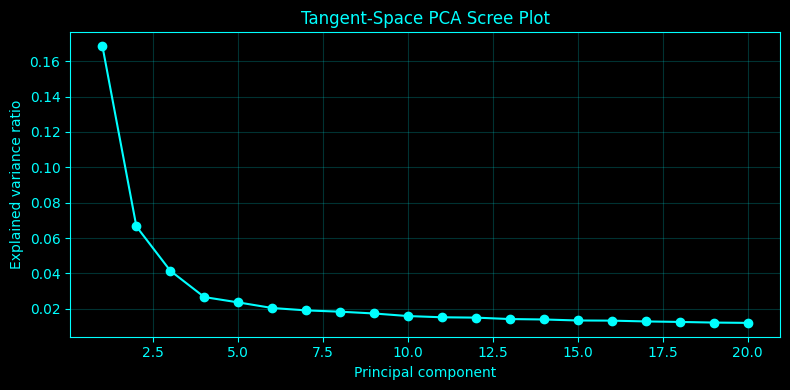

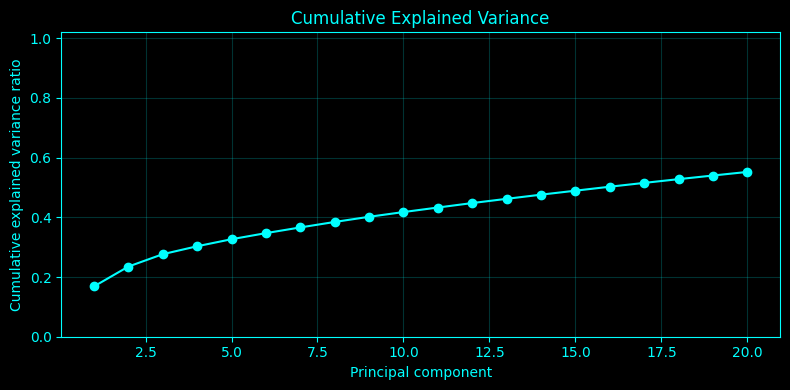

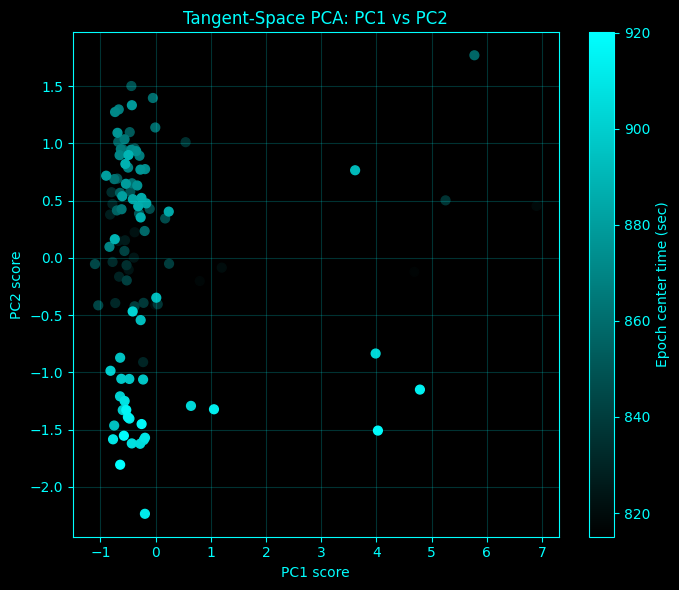

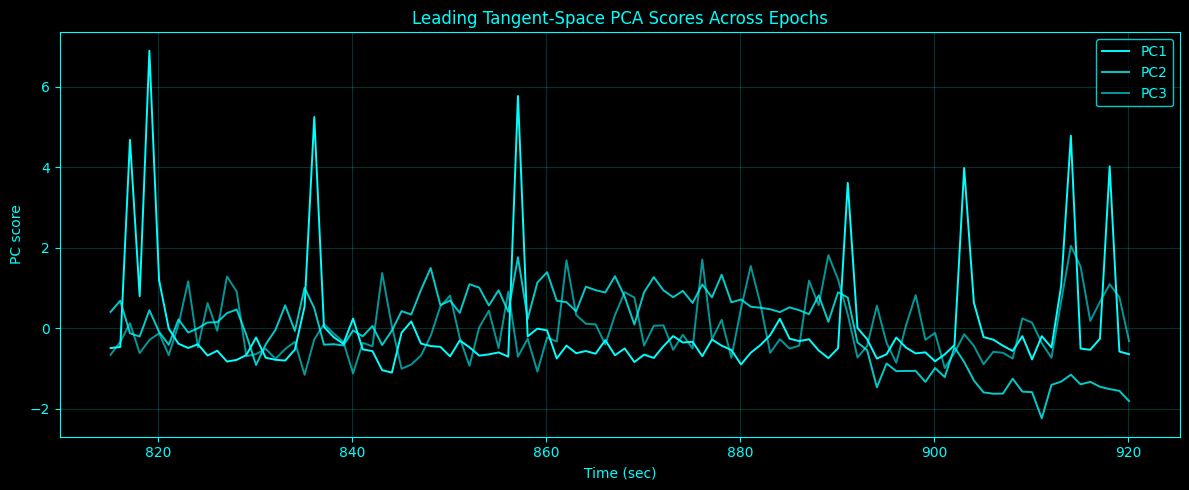


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/tangent_space_pca_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/tangent_space_pca_summary.csv
Saved scores CSV: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/tangent_space_pca_scores.csv
Saved top-loadings CSV: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/tangent_space_pca_top_loadings.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/tangent_space_pca_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/tangent_space_pca/plots


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "tangent_space_pca")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

n_components_to_save = 10
eps = 1e-12

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

# -------------------------------------------------------
# SYMMETRIC VECTORIZATION
# -------------------------------------------------------
def symmat_to_vec(S):
    """
    Frobenius-isometric vectorization for symmetric matrices.
    Diagonal entries unchanged, off-diagonal entries weighted by sqrt(2).
    """
    S = symmetrize(np.asarray(S, dtype=float))
    n = S.shape[0]
    vals = []

    for i in range(n):
        vals.append(S[i, i])

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(np.sqrt(2.0) * S[i, j])

    return np.asarray(vals, dtype=float)

def vec_to_symmat(v, n):
    S = np.zeros((n, n), dtype=float)
    idx = 0

    for i in range(n):
        S[i, i] = v[idx]
        idx += 1

    for i in range(n):
        for j in range(i + 1, n):
            val = v[idx] / np.sqrt(2.0)
            S[i, j] = val
            S[j, i] = val
            idx += 1

    return S

def upper_triangle_labels(channel_names):
    labels = []
    n = len(channel_names)

    for i in range(n):
        labels.append(f"{channel_names[i]}__{channel_names[i]}")

    for i in range(n):
        for j in range(i + 1, n):
            labels.append(f"{channel_names[i]}__{channel_names[j]}")

    return labels

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
sampling_rate = float(data["sampling_rate"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")

# -------------------------------------------------------
# MAP TO TANGENT SPACE AT THE RIEMANNIAN MEAN
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

tangent_mats = []
tangent_vecs = []

for i in range(n_epochs):
    inner = P_invsqrt @ cov_matrices[i] @ P_invsqrt
    Xi = logm_spd(inner)
    tangent_mats.append(Xi)
    tangent_vecs.append(symmat_to_vec(Xi))

tangent_mats = np.stack(tangent_mats, axis=0)   # (epochs, channels, channels)
X = np.stack(tangent_vecs, axis=0)              # (epochs, tangent_dim)

feature_labels = upper_triangle_labels(eeg_channel_names)

print(f"Tangent matrix tensor shape: {tangent_mats.shape}")
print(f"Tangent vector matrix shape: {X.shape}")

# -------------------------------------------------------
# CENTER + PCA BY SVD
# -------------------------------------------------------
X_mean = np.mean(X, axis=0, keepdims=True)
X_centered = X - X_mean

U, Svals, Vt = np.linalg.svd(X_centered, full_matrices=False)

# PCA quantities
scores = U * Svals[None, :]
components = Vt
eigenvalues = (Svals ** 2) / max(n_epochs - 1, 1)
explained_variance_ratio = eigenvalues / (np.sum(eigenvalues) + 1e-12)
cumulative_explained = np.cumsum(explained_variance_ratio)

k_eff = min(n_components_to_save, components.shape[0])

component_mats = np.stack(
    [vec_to_symmat(components[i], n_channels) for i in range(k_eff)],
    axis=0
)

# Epoch timing
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

# -------------------------------------------------------
# SUMMARIES
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "component_index": np.arange(1, len(eigenvalues) + 1),
    "eigenvalue": eigenvalues,
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance_ratio": cumulative_explained,
})

scores_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
})

for i in range(k_eff):
    scores_df[f"PC{i+1}_score"] = scores[:, i]

# Top-loading table
top_loading_rows = []
for comp_idx in range(k_eff):
    comp = components[comp_idx]
    abs_comp = np.abs(comp)
    order = np.argsort(abs_comp)[::-1]

    for rank in range(min(20, len(order))):
        j = order[rank]
        top_loading_rows.append({
            "component_index": comp_idx + 1,
            "rank": rank + 1,
            "feature": feature_labels[j] if j < len(feature_labels) else f"feature_{j}",
            "loading": float(comp[j]),
            "abs_loading": float(abs_comp[j]),
        })

top_loadings_df = pd.DataFrame(top_loading_rows)

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "tangent_dimension": int(X.shape[1]),
    "pc1_explained_variance_ratio": float(explained_variance_ratio[0]) if len(explained_variance_ratio) > 0 else np.nan,
    "pc2_explained_variance_ratio": float(explained_variance_ratio[1]) if len(explained_variance_ratio) > 1 else np.nan,
    "pc3_explained_variance_ratio": float(explained_variance_ratio[2]) if len(explained_variance_ratio) > 2 else np.nan,
    "variance_explained_by_first_5": float(cumulative_explained[min(4, len(cumulative_explained)-1)]) if len(cumulative_explained) > 0 else np.nan,
    "variance_explained_by_first_10": float(cumulative_explained[min(9, len(cumulative_explained)-1)]) if len(cumulative_explained) > 0 else np.nan,
}

print("\nTangent-space PCA summary:")
print(summary_df.head(10))
print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "tangent_space_pca_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    tangent_vectors=X,
    tangent_mean=X_mean,
    scores=scores,
    components=components,
    singular_values=Svals,
    eigenvalues=eigenvalues,
    explained_variance_ratio=explained_variance_ratio,
    cumulative_explained_variance_ratio=cumulative_explained,
    component_matrices=component_mats,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    window_size_sec=window_size_sec,
    start_time=start_time,
    end_time=end_time,
)

summary_csv = os.path.join(out_dir, "tangent_space_pca_summary.csv")
summary_df.to_csv(summary_csv, index=False)

scores_csv = os.path.join(out_dir, "tangent_space_pca_scores.csv")
scores_df.to_csv(scores_csv, index=False)

top_loadings_csv = os.path.join(out_dir, "tangent_space_pca_top_loadings.csv")
top_loadings_df.to_csv(top_loadings_csv, index=False)

summary_txt = os.path.join(out_dir, "tangent_space_pca_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Tangent-Space PCA at the Riemannian Mean\n")
    f.write("=======================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Tangent dimension: {X.shape[1]}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SCREE PLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

x = np.arange(1, min(20, len(eigenvalues)) + 1)
ax.plot(x, explained_variance_ratio[:len(x)], marker="o", color=ACCENT)
ax.set_title("Tangent-Space PCA Scree Plot")
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")

plot1_path = os.path.join(plots_dir, "tangent_pca_scree.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: CUMULATIVE EXPLAINED VARIANCE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(x, cumulative_explained[:len(x)], marker="o", color=ACCENT)
ax.set_title("Cumulative Explained Variance")
ax.set_xlabel("Principal component")
ax.set_ylabel("Cumulative explained variance ratio")
ax.set_ylim(0, 1.02)

plot2_path = os.path.join(plots_dir, "tangent_pca_cumulative_variance.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: PC1 VS PC2
# -------------------------------------------------------
if scores.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
    style_ax(ax)

    sc = ax.scatter(
        scores[:, 0],
        scores[:, 1],
        c=epoch_center_time,
        cmap=custom_cmap,
        s=40
    )
    ax.set_title("Tangent-Space PCA: PC1 vs PC2")
    ax.set_xlabel("PC1 score")
    ax.set_ylabel("PC2 score")

    cbar = plt.colorbar(sc, ax=ax)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)
    cbar.set_label("Epoch center time (sec)", color=ACCENT)

    plot3_path = os.path.join(plots_dir, "tangent_pca_pc1_vs_pc2.png")
    plt.tight_layout()
    plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

# -------------------------------------------------------
# PLOT 4: PC SCORES OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

n_plot_scores = min(3, scores.shape[1])
for i in range(n_plot_scores):
    ax.plot(epoch_center_time, scores[:, i], linewidth=1.4, label=f"PC{i+1}", color=ACCENT, alpha=1.0 - 0.2 * i)

ax.set_title("Leading Tangent-Space PCA Scores Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("PC score")
ax.legend()

plot4_path = os.path.join(plots_dir, "tangent_pca_scores_over_time.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: COMPONENT MATRIX HEATMAPS
# -------------------------------------------------------
for comp_idx in range(k_eff):
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(component_mats[comp_idx], cmap=custom_cmap, aspect="auto")
    ax.set_title(f"PC{comp_idx+1} Tangent Matrix")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(n_channels))
    ax.set_yticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(eeg_channel_names, color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    path = os.path.join(plots_dir, f"tangent_pca_component_matrix_PC{comp_idx+1}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved scores CSV: {scores_csv}")
print(f"Saved top-loadings CSV: {top_loadings_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)

Running Riemannian k-means for k=2

Running Riemannian k-means for k=3

Running Riemannian k-means for k=4

Running Riemannian k-means for k=5

Running Riemannian k-means for k=6

Best k selected by silhouette: 2
Best silhouette: 0.346235
Best inertia: 10.973547


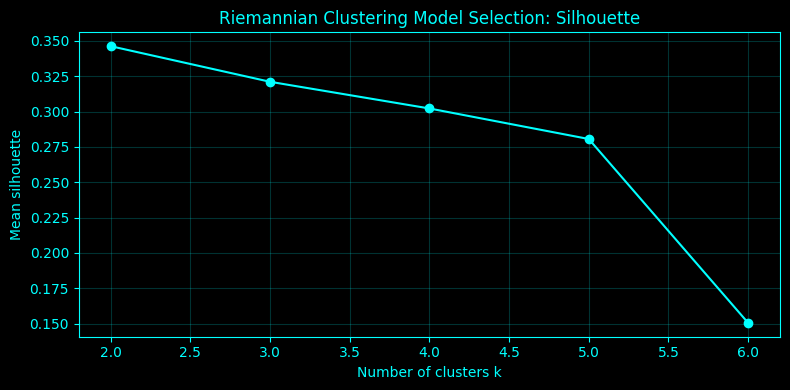

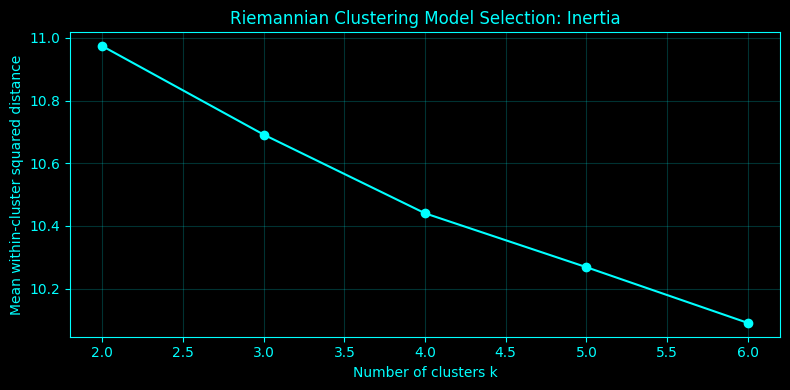

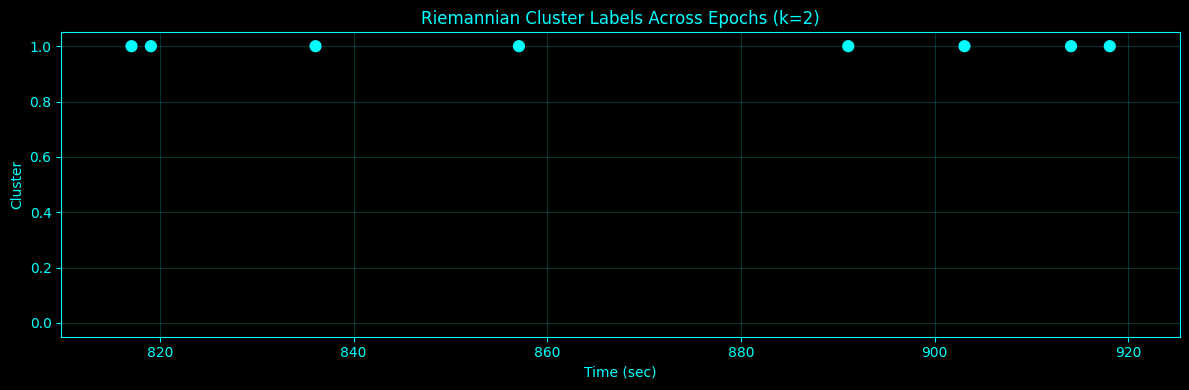

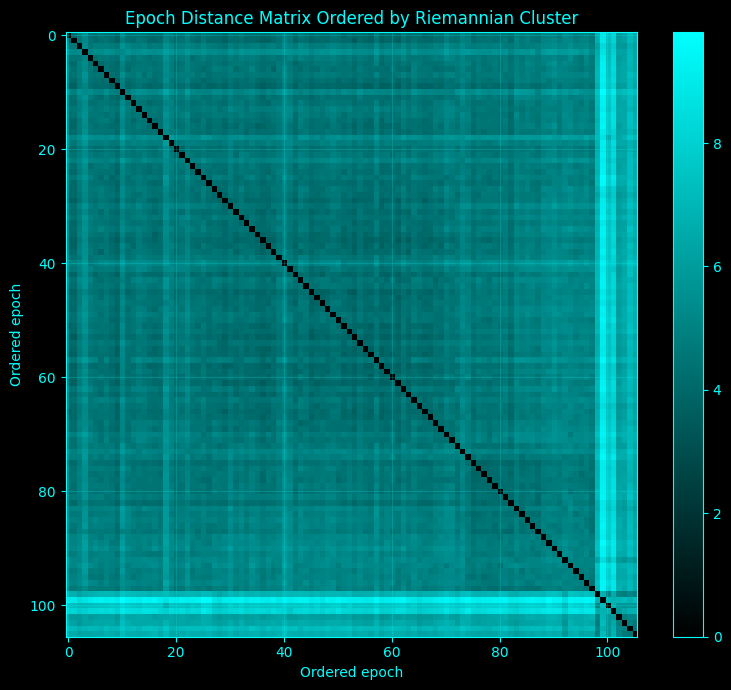

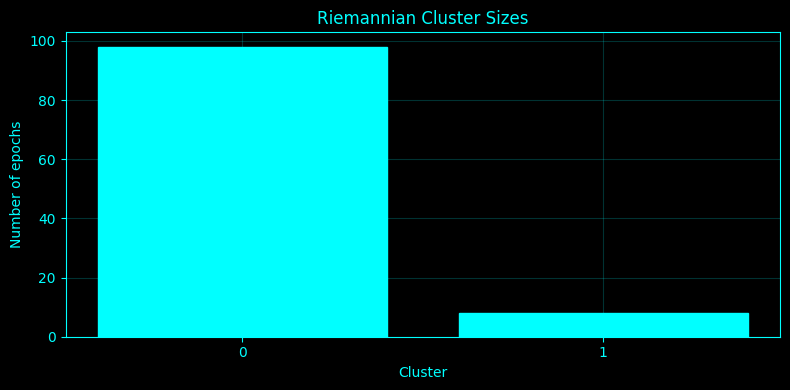

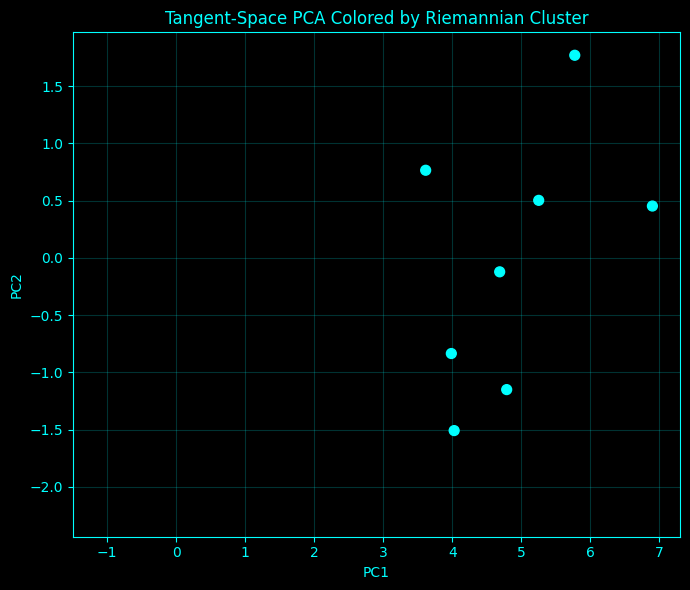


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/riemannian_clustering_results.npz
Saved model-selection CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/riemannian_clustering_model_selection.csv
Saved epoch CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/riemannian_clustering_epoch_assignments.csv
Saved cluster CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/riemannian_clustering_cluster_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/riemannian_clustering_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_clustering_covariance_states/plots


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

# Optional: if tangent-space PCA has already been run, we will use it for one plot
tangent_pca_dir = os.path.join(base_dir, "tangent_space_pca")
tangent_pca_npz_path = os.path.join(tangent_pca_dir, "tangent_space_pca_results.npz")

out_dir = os.path.join(base_dir, "riemannian_clustering_covariance_states")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Try multiple cluster counts and choose the best by silhouette
k_values = [2, 3, 4, 5, 6]
n_init = 5
max_iter = 30
tol_mean = 1e-7
tol_shift = 1e-5
random_seed = 42

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

rng = np.random.default_rng(random_seed)

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

def compute_riemannian_mean(cov_matrices, max_iter=50, tol=1e-7):
    cov_matrices = np.asarray(cov_matrices, dtype=float)
    n_mats, n, _ = cov_matrices.shape

    G = symmetrize(np.mean(cov_matrices, axis=0))

    for _ in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)
        for C in cov_matrices:
            inner = G_invsqrt @ C @ G_invsqrt
            tangent_sum += logm_spd(inner)

        tangent_mean = tangent_sum / n_mats
        update_norm = np.linalg.norm(tangent_mean, ord="fro")

        if update_norm < tol:
            break

        G = G_sqrt @ expm_sym(tangent_mean) @ G_sqrt
        G = symmetrize(G)

    return G

# -------------------------------------------------------
# DISTANCE MATRIX + CLUSTER METRICS
# -------------------------------------------------------
def pairwise_riemannian_distance_matrix(cov_matrices):
    n = len(cov_matrices)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        D[i, i] = 0.0
        for j in range(i + 1, n):
            dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
            D[i, j] = dij
            D[j, i] = dij
    return D

def silhouette_score_precomputed(labels, D):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    n = len(labels)

    if len(unique_labels) < 2:
        return np.nan, np.full(n, np.nan)

    sil = np.zeros(n, dtype=float)

    for i in range(n):
        same = (labels == labels[i])
        same[i] = False

        if np.sum(same) == 0:
            sil[i] = 0.0
            continue

        a_i = np.mean(D[i, same])

        b_i = np.inf
        for lab in unique_labels:
            if lab == labels[i]:
                continue
            other = (labels == lab)
            if np.sum(other) > 0:
                b_i = min(b_i, np.mean(D[i, other]))

        sil[i] = (b_i - a_i) / max(a_i, b_i, 1e-12)

    return float(np.mean(sil)), sil

def cluster_inertia(labels, dist_to_centers):
    labels = np.asarray(labels, dtype=int)
    return float(np.mean(dist_to_centers[np.arange(len(labels)), labels] ** 2))

# -------------------------------------------------------
# INITIALIZATION
# -------------------------------------------------------
def farthest_point_init_from_distance_matrix(D, k, rng):
    n = D.shape[0]
    first = int(rng.integers(0, n))
    chosen = [first]

    while len(chosen) < k:
        min_dist = np.min(D[:, chosen], axis=1)
        min_dist[chosen] = -np.inf
        nxt = int(np.argmax(min_dist))
        chosen.append(nxt)

    return np.array(chosen, dtype=int)

# -------------------------------------------------------
# RIEMANNIAN K-MEANS
# -------------------------------------------------------
def riemannian_kmeans(cov_matrices, D_pairwise, k, n_init=5, max_iter=30, tol_mean=1e-7, tol_shift=1e-5, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    n = len(cov_matrices)
    best = None

    for init_id in range(n_init):
        init_idx = farthest_point_init_from_distance_matrix(D_pairwise, k, rng)
        centers = np.stack([cov_matrices[idx].copy() for idx in init_idx], axis=0)

        labels_prev = None

        for it in range(max_iter):
            # assignment
            dist_to_centers = np.zeros((n, k), dtype=float)
            for c in range(k):
                P_invsqrt = invsqrtm_spd(centers[c])
                for i in range(n):
                    dist_to_centers[i, c] = affine_invariant_distance(cov_matrices[i], centers[c], P_invsqrt=P_invsqrt)

            labels = np.argmin(dist_to_centers, axis=1)

            # handle empty clusters by re-seeding with farthest points
            for c in range(k):
                if np.sum(labels == c) == 0:
                    current_min = np.min(dist_to_centers, axis=1)
                    idx_far = int(np.argmax(current_min))
                    centers[c] = cov_matrices[idx_far].copy()
                    labels[idx_far] = c

            # update centers
            new_centers = np.zeros_like(centers)
            center_shifts = np.zeros(k, dtype=float)

            for c in range(k):
                members = cov_matrices[labels == c]
                if len(members) == 1:
                    new_centers[c] = members[0]
                else:
                    new_centers[c] = compute_riemannian_mean(members, max_iter=50, tol=tol_mean)

                center_shifts[c] = affine_invariant_distance(centers[c], new_centers[c])

            centers = new_centers

            labels_unchanged = (labels_prev is not None) and np.array_equal(labels, labels_prev)
            max_shift = float(np.max(center_shifts))
            labels_prev = labels.copy()

            if labels_unchanged or max_shift < tol_shift:
                break

        # final assignment after convergence
        dist_to_centers = np.zeros((n, k), dtype=float)
        for c in range(k):
            P_invsqrt = invsqrtm_spd(centers[c])
            for i in range(n):
                dist_to_centers[i, c] = affine_invariant_distance(cov_matrices[i], centers[c], P_invsqrt=P_invsqrt)

        labels = np.argmin(dist_to_centers, axis=1)
        inertia = cluster_inertia(labels, dist_to_centers)
        silhouette_mean, silhouette_per_epoch = silhouette_score_precomputed(labels, D_pairwise)

        # inter-center distances
        center_distance_matrix = np.zeros((k, k), dtype=float)
        for i in range(k):
            for j in range(i + 1, k):
                dij = affine_invariant_distance(centers[i], centers[j])
                center_distance_matrix[i, j] = dij
                center_distance_matrix[j, i] = dij

        result = {
            "k": k,
            "labels": labels,
            "centers": centers,
            "dist_to_centers": dist_to_centers,
            "inertia": inertia,
            "silhouette_mean": silhouette_mean,
            "silhouette_per_epoch": silhouette_per_epoch,
            "center_distance_matrix": center_distance_matrix,
        }

        if (best is None) or (np.nan_to_num(result["silhouette_mean"], nan=-np.inf) > np.nan_to_num(best["silhouette_mean"], nan=-np.inf)):
            best = result

    return best

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)

cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")

# -------------------------------------------------------
# PAIRWISE DISTANCES BETWEEN EPOCH STATES
# -------------------------------------------------------
D_pairwise = pairwise_riemannian_distance_matrix(cov_matrices)

# -------------------------------------------------------
# MODEL SELECTION OVER k
# -------------------------------------------------------
model_rows = []
all_results = {}

for k in k_values:
    print(f"\nRunning Riemannian k-means for k={k}")
    res = riemannian_kmeans(
        cov_matrices,
        D_pairwise=D_pairwise,
        k=k,
        n_init=n_init,
        max_iter=max_iter,
        tol_mean=tol_mean,
        tol_shift=tol_shift,
        rng=rng
    )
    all_results[k] = res

    model_rows.append({
        "k": k,
        "inertia": res["inertia"],
        "silhouette_mean": res["silhouette_mean"],
    })

model_selection_df = pd.DataFrame(model_rows).sort_values("k").reset_index(drop=True)

# choose best k by silhouette
best_idx = int(np.nanargmax(model_selection_df["silhouette_mean"].values))
best_k = int(model_selection_df.loc[best_idx, "k"])
best_result = all_results[best_k]

labels = best_result["labels"]
centers = best_result["centers"]
dist_to_centers = best_result["dist_to_centers"]
silhouette_per_epoch = best_result["silhouette_per_epoch"]
center_distance_matrix = best_result["center_distance_matrix"]

print(f"\nBest k selected by silhouette: {best_k}")
print(f"Best silhouette: {best_result['silhouette_mean']:.6f}")
print(f"Best inertia: {best_result['inertia']:.6f}")

# -------------------------------------------------------
# PER-EPOCH SUMMARY
# -------------------------------------------------------
epoch_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "cluster": labels,
    "silhouette_value": silhouette_per_epoch,
    "distance_to_assigned_center": dist_to_centers[np.arange(n_epochs), labels],
})

for c in range(best_k):
    epoch_df[f"distance_to_center_{c}"] = dist_to_centers[:, c]

# -------------------------------------------------------
# CLUSTER SUMMARY
# -------------------------------------------------------
cluster_rows = []
for c in range(best_k):
    idx = np.where(labels == c)[0]
    members = cov_matrices[idx]

    dist_center_to_global = affine_invariant_distance(centers[c], riemannian_mean)

    if len(idx) > 1:
        member_pairwise = D_pairwise[np.ix_(idx, idx)]
        tri_i, tri_j = np.triu_indices(len(idx), k=1)
        within_mean_pairwise = float(np.mean(member_pairwise[tri_i, tri_j]))
    else:
        within_mean_pairwise = 0.0

    cluster_rows.append({
        "cluster": c,
        "n_epochs": int(len(idx)),
        "fraction_of_epochs": float(len(idx) / n_epochs),
        "mean_time_sec": float(np.mean(epoch_center_time[idx])) if len(idx) > 0 else np.nan,
        "min_time_sec": float(np.min(epoch_center_time[idx])) if len(idx) > 0 else np.nan,
        "max_time_sec": float(np.max(epoch_center_time[idx])) if len(idx) > 0 else np.nan,
        "mean_distance_to_center": float(np.mean(dist_to_centers[idx, c])) if len(idx) > 0 else np.nan,
        "distance_center_to_global_mean": float(dist_center_to_global),
        "mean_within_cluster_pairwise_distance": within_mean_pairwise,
        "mean_silhouette": float(np.mean(silhouette_per_epoch[idx])) if len(idx) > 0 else np.nan,
    })

cluster_summary_df = pd.DataFrame(cluster_rows).sort_values("cluster").reset_index(drop=True)

# -------------------------------------------------------
# OPTIONAL: LOAD TANGENT-SPACE PCA FOR VISUALIZATION
# -------------------------------------------------------
pc_scores = None
if os.path.exists(tangent_pca_npz_path):
    tpca = np.load(tangent_pca_npz_path, allow_pickle=True)
    scores = np.asarray(tpca["scores"], dtype=float)
    if scores.shape[0] == n_epochs and scores.shape[1] >= 2:
        pc_scores = scores[:, :2]

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "riemannian_clustering_results.npz")
np.savez(
    npz_path,
    cov_matrices_shape=np.array(cov_matrices.shape),
    riemannian_mean=riemannian_mean,
    pairwise_distance_matrix=D_pairwise,
    best_k=best_k,
    labels=labels,
    centers=centers,
    dist_to_centers=dist_to_centers,
    silhouette_per_epoch=silhouette_per_epoch,
    center_distance_matrix=center_distance_matrix,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    window_size_sec=window_size_sec,
    start_time=start_time,
    end_time=end_time,
)

model_csv = os.path.join(out_dir, "riemannian_clustering_model_selection.csv")
model_selection_df.to_csv(model_csv, index=False)

epoch_csv = os.path.join(out_dir, "riemannian_clustering_epoch_assignments.csv")
epoch_df.to_csv(epoch_csv, index=False)

cluster_csv = os.path.join(out_dir, "riemannian_clustering_cluster_summary.csv")
cluster_summary_df.to_csv(cluster_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_clustering_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Clustering of Covariance States\n")
    f.write("=========================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"k candidates: {k_values}\n")
    f.write(f"Selected k: {best_k}\n\n")
    f.write("Model-selection summary:\n")
    for _, row in model_selection_df.iterrows():
        f.write(
            f"  k={int(row['k'])}: inertia={row['inertia']:.6f}, "
            f"silhouette={row['silhouette_mean']:.6f}\n"
        )

    f.write("\nCluster summary:\n")
    for _, row in cluster_summary_df.iterrows():
        f.write(
            f"  cluster {int(row['cluster'])}: "
            f"n={int(row['n_epochs'])}, "
            f"frac={row['fraction_of_epochs']:.4f}, "
            f"mean_time={row['mean_time_sec']:.4f}, "
            f"mean_dist_to_center={row['mean_distance_to_center']:.6f}, "
            f"dist_center_to_global={row['distance_center_to_global_mean']:.6f}, "
            f"mean_silhouette={row['mean_silhouette']:.6f}\n"
        )

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: SILHOUETTE VS k
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    model_selection_df["k"].values,
    model_selection_df["silhouette_mean"].values,
    marker="o",
    color=ACCENT
)
ax.set_title("Riemannian Clustering Model Selection: Silhouette")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Mean silhouette")

plot1_path = os.path.join(plots_dir, "model_selection_silhouette.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: INERTIA VS k
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    model_selection_df["k"].values,
    model_selection_df["inertia"].values,
    marker="o",
    color=ACCENT
)
ax.set_title("Riemannian Clustering Model Selection: Inertia")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("Mean within-cluster squared distance")

plot2_path = os.path.join(plots_dir, "model_selection_inertia.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: CLUSTER LABELS OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.scatter(
    epoch_center_time,
    labels,
    c=labels,
    cmap=custom_cmap,
    s=60
)
ax.set_title(f"Riemannian Cluster Labels Across Epochs (k={best_k})")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Cluster")

plot3_path = os.path.join(plots_dir, "cluster_labels_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: PAIRWISE DISTANCE MATRIX ORDERED BY CLUSTER
# -------------------------------------------------------
order = np.lexsort((epoch_index, labels))
D_ordered = D_pairwise[np.ix_(order, order)]

fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(D_ordered, cmap=custom_cmap, aspect="auto")
ax.set_title("Epoch Distance Matrix Ordered by Riemannian Cluster")
ax.set_xlabel("Ordered epoch")
ax.set_ylabel("Ordered epoch")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot4_path = os.path.join(plots_dir, "ordered_epoch_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: CLUSTER SIZES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    cluster_summary_df["cluster"].values,
    cluster_summary_df["n_epochs"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Riemannian Cluster Sizes")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of epochs")
ax.set_xticks(cluster_summary_df["cluster"].values)

plot5_path = os.path.join(plots_dir, "cluster_sizes.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 6: PC1 VS PC2 COLORED BY CLUSTER (OPTIONAL)
# -------------------------------------------------------
if pc_scores is not None:
    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
    style_ax(ax)

    ax.scatter(
        pc_scores[:, 0],
        pc_scores[:, 1],
        c=labels,
        cmap=custom_cmap,
        s=50
    )
    ax.set_title("Tangent-Space PCA Colored by Riemannian Cluster")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

    plot6_path = os.path.join(plots_dir, "tangent_pca_colored_by_cluster.png")
    plt.tight_layout()
    plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved model-selection CSV: {model_csv}")
print(f"Saved epoch CSV: {epoch_csv}")
print(f"Saved cluster CSV: {cluster_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Geodesic Interpolation Between EEG Covariance States

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)

Selected endpoints:
  epoch A = 4, center time = 819.071 sec
  epoch B = 12, center time = 827.071 sec
  d(A,B) = 9.793891
  d(A,mean) = 8.080298
  d(B,mean) = 4.117115

Global interpolation summary:
endpoint_mode: farthest_pair
epoch_A_index: 4
epoch_B_index: 12
epoch_A_time_sec: 819.071
epoch_B_time_sec: 827.071
n_interp: 21
geodesic_distance_A_to_B: 9.79389129688672
midpoint_distance_to_mean: 4.103580632806325
A_distance_to_mean: 8.08029750296199
B_distance_to_mean: 4.117114717762404
max_abs_geodesic_error_A: 5.790923296444817e-13
max_abs_geodesic_error_B: 5.818769324558294e-13
mean_abs_offdiag_start: 288.83419858881996
mean_abs_offdiag_mid: 199.31787432854125
mean_abs_offdiag_end: 198.82814092895737


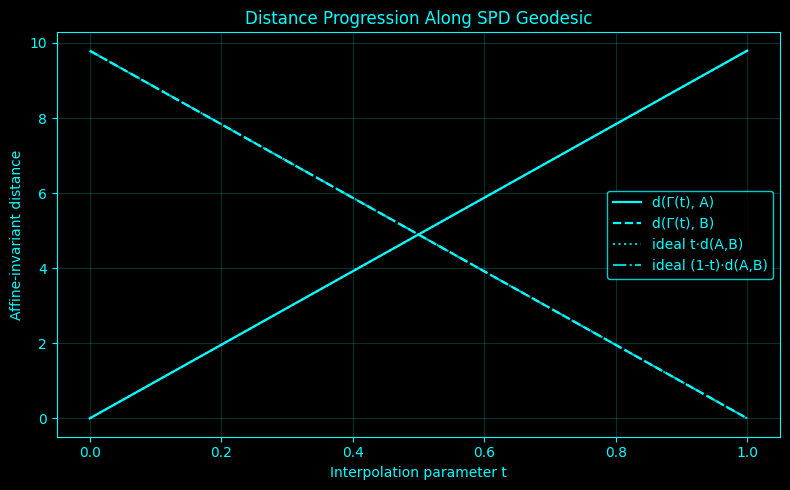

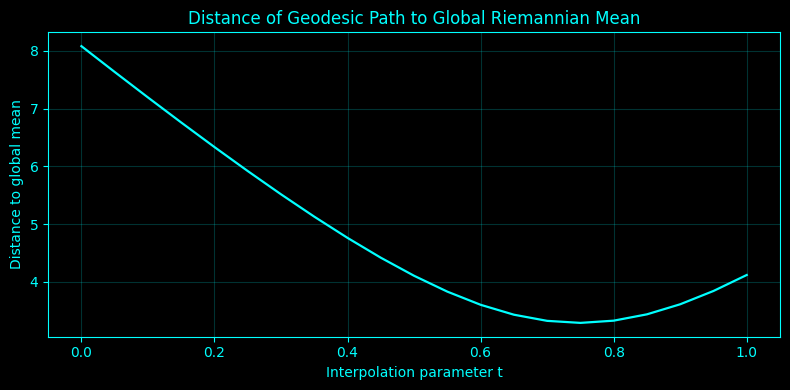

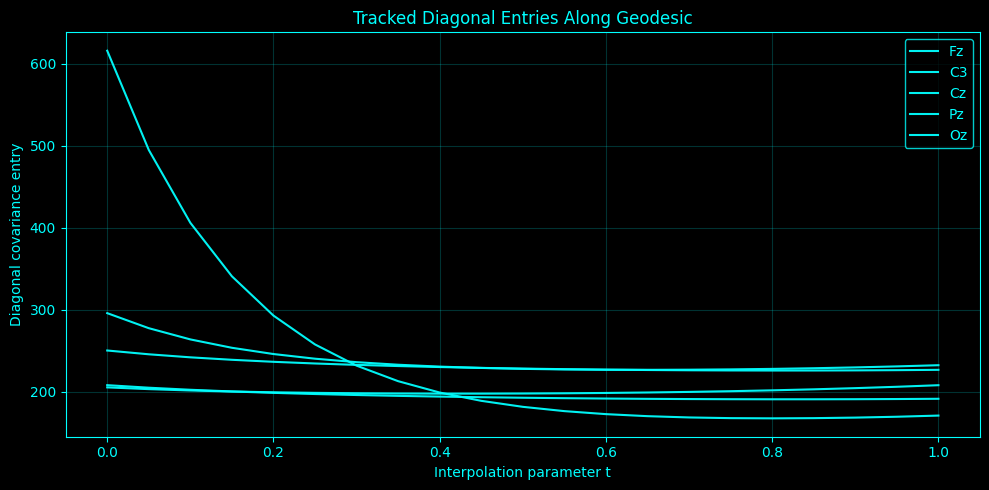

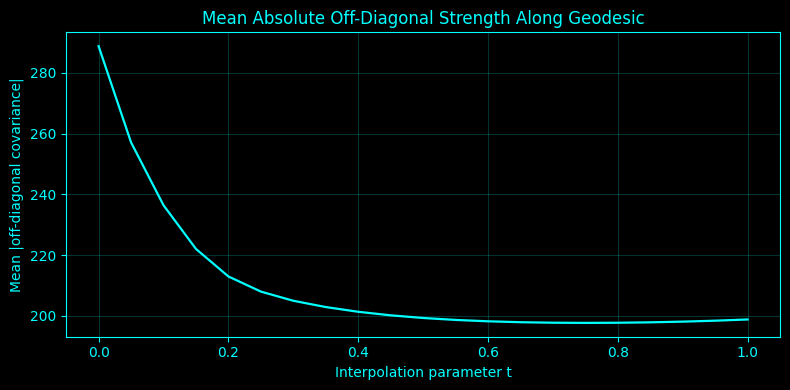


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/geodesic_interpolation_between_eeg_states
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/geodesic_interpolation_between_eeg_states/geodesic_interpolation_results.npz
Saved CSV: /home/a/projects/Complete-Neural-Signal-Analysis/geodesic_interpolation_between_eeg_states/geodesic_interpolation_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/geodesic_interpolation_between_eeg_states/geodesic_interpolation_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/geodesic_interpolation_between_eeg_states/plots


In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

out_dir = os.path.join(base_dir, "geodesic_interpolation_between_eeg_states")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

# Endpoint selection:
# "farthest_pair" or "nearest_vs_farthest_to_mean" or "manual"
endpoint_mode = "farthest_pair"
manual_epoch_a = 0
manual_epoch_b = 10

# Number of interpolation points, including endpoints
n_interp = 21

# A few diagonals to track explicitly
tracked_channels = ["Fz", "C3", "Cz", "Pz", "Oz"]

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def powm_spd(A, p):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (w ** p)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

def geodesic_spd(P, Q, t):
    """
    Affine-invariant geodesic:
    Γ(t) = P^{1/2} (P^{-1/2} Q P^{-1/2})^t P^{1/2}
    """
    P = symmetrize(np.asarray(P, dtype=float))
    Q = symmetrize(np.asarray(Q, dtype=float))

    P_sqrt = sqrtm_spd(P)
    P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ Q @ P_invsqrt
    inner_t = powm_spd(inner, t)
    G = P_sqrt @ inner_t @ P_sqrt
    return symmetrize(G)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)
cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")

# -------------------------------------------------------
# SELECT ENDPOINT STATES
# -------------------------------------------------------
# Distance to mean
P_invsqrt = invsqrtm_spd(riemannian_mean)
dist_to_mean = np.array([
    affine_invariant_distance(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)
    for i in range(n_epochs)
], dtype=float)

if endpoint_mode == "nearest_vs_farthest_to_mean":
    idx_a = int(np.argmin(dist_to_mean))
    idx_b = int(np.argmax(dist_to_mean))

elif endpoint_mode == "manual":
    idx_a = int(manual_epoch_a)
    idx_b = int(manual_epoch_b)
    if idx_a < 0 or idx_a >= n_epochs or idx_b < 0 or idx_b >= n_epochs or idx_a == idx_b:
        raise ValueError("Manual endpoint indices are invalid.")

elif endpoint_mode == "farthest_pair":
    idx_a, idx_b = 0, 1
    max_dist = -np.inf
    for i in range(n_epochs):
        Ci = cov_matrices[i]
        for j in range(i + 1, n_epochs):
            dij = affine_invariant_distance(Ci, cov_matrices[j])
            if dij > max_dist:
                max_dist = dij
                idx_a, idx_b = i, j
else:
    raise ValueError("endpoint_mode must be 'farthest_pair', 'nearest_vs_farthest_to_mean', or 'manual'.")

A = cov_matrices[idx_a]
B = cov_matrices[idx_b]

time_a = epoch_center_time[idx_a]
time_b = epoch_center_time[idx_b]

d_AB = affine_invariant_distance(A, B)
d_A_mean = affine_invariant_distance(A, riemannian_mean, P_invsqrt=P_invsqrt)
d_B_mean = affine_invariant_distance(B, riemannian_mean, P_invsqrt=P_invsqrt)

print("\nSelected endpoints:")
print(f"  epoch A = {idx_a}, center time = {time_a:.3f} sec")
print(f"  epoch B = {idx_b}, center time = {time_b:.3f} sec")
print(f"  d(A,B) = {d_AB:.6f}")
print(f"  d(A,mean) = {d_A_mean:.6f}")
print(f"  d(B,mean) = {d_B_mean:.6f}")

# -------------------------------------------------------
# GEODESIC INTERPOLATION
# -------------------------------------------------------
t_values = np.linspace(0.0, 1.0, n_interp)
geodesic_states = np.stack([geodesic_spd(A, B, t) for t in t_values], axis=0)

# Distances along the path
dist_to_A = np.array([affine_invariant_distance(G, A) for G in geodesic_states], dtype=float)
dist_to_B = np.array([affine_invariant_distance(G, B) for G in geodesic_states], dtype=float)
dist_to_mean_path = np.array([affine_invariant_distance(G, riemannian_mean, P_invsqrt=P_invsqrt) for G in geodesic_states], dtype=float)

# Geodesic consistency check: d(G_t, A) should be ~ t*d(A,B), d(G_t, B) ~ (1-t)*d(A,B)
ideal_to_A = t_values * d_AB
ideal_to_B = (1.0 - t_values) * d_AB
geodesic_error_A = dist_to_A - ideal_to_A
geodesic_error_B = dist_to_B - ideal_to_B

# Diagonal evolution
diag_path = np.stack([np.diag(G) for G in geodesic_states], axis=0)

tracked_indices = [eeg_channel_names.index(ch) for ch in tracked_channels if ch in eeg_channel_names]
tracked_channels_used = [eeg_channel_names[i] for i in tracked_indices]

# Off-diagonal magnitude summary
offdiag_strength = np.array([
    np.mean(np.abs(G[np.triu_indices(n_channels, k=1)]))
    for G in geodesic_states
], dtype=float)

# Midpoint
mid_idx = n_interp // 2
mid_state = geodesic_states[mid_idx]
mid_dist_to_mean = dist_to_mean_path[mid_idx]

# -------------------------------------------------------
# SUMMARY TABLES
# -------------------------------------------------------
interp_df = pd.DataFrame({
    "interp_index": np.arange(n_interp),
    "t": t_values,
    "distance_to_A": dist_to_A,
    "distance_to_B": dist_to_B,
    "ideal_distance_to_A": ideal_to_A,
    "ideal_distance_to_B": ideal_to_B,
    "geodesic_error_A": geodesic_error_A,
    "geodesic_error_B": geodesic_error_B,
    "distance_to_riemannian_mean": dist_to_mean_path,
    "mean_abs_offdiag_strength": offdiag_strength,
})

for idx, ch in zip(tracked_indices, tracked_channels_used):
    interp_df[f"diag_{ch}"] = diag_path[:, idx]

global_summary = {
    "endpoint_mode": endpoint_mode,
    "epoch_A_index": int(idx_a),
    "epoch_B_index": int(idx_b),
    "epoch_A_time_sec": float(time_a),
    "epoch_B_time_sec": float(time_b),
    "n_interp": int(n_interp),
    "geodesic_distance_A_to_B": float(d_AB),
    "midpoint_distance_to_mean": float(mid_dist_to_mean),
    "A_distance_to_mean": float(d_A_mean),
    "B_distance_to_mean": float(d_B_mean),
    "max_abs_geodesic_error_A": float(np.max(np.abs(geodesic_error_A))),
    "max_abs_geodesic_error_B": float(np.max(np.abs(geodesic_error_B))),
    "mean_abs_offdiag_start": float(offdiag_strength[0]),
    "mean_abs_offdiag_mid": float(offdiag_strength[mid_idx]),
    "mean_abs_offdiag_end": float(offdiag_strength[-1]),
}

print("\nGlobal interpolation summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "geodesic_interpolation_results.npz")
np.savez(
    npz_path,
    geodesic_states=geodesic_states,
    t_values=t_values,
    interp_index=np.arange(n_interp),
    idx_a=idx_a,
    idx_b=idx_b,
    time_a=time_a,
    time_b=time_b,
    dist_to_A=dist_to_A,
    dist_to_B=dist_to_B,
    ideal_to_A=ideal_to_A,
    ideal_to_B=ideal_to_B,
    geodesic_error_A=geodesic_error_A,
    geodesic_error_B=geodesic_error_B,
    dist_to_mean_path=dist_to_mean_path,
    diag_path=diag_path,
    offdiag_strength=offdiag_strength,
    riemannian_mean=riemannian_mean,
)

interp_csv = os.path.join(out_dir, "geodesic_interpolation_summary.csv")
interp_df.to_csv(interp_csv, index=False)

summary_txt = os.path.join(out_dir, "geodesic_interpolation_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Geodesic Interpolation Between EEG Covariance States\n")
    f.write("===================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: DISTANCE PROGRESSION ALONG GEODESIC
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

ax.plot(t_values, dist_to_A, color=ACCENT, linewidth=1.6, label="d(Γ(t), A)")
ax.plot(t_values, dist_to_B, color=ACCENT, linewidth=1.6, linestyle="--", label="d(Γ(t), B)")
ax.plot(t_values, ideal_to_A, color=ACCENT, linestyle=":", alpha=0.8, label="ideal t·d(A,B)")
ax.plot(t_values, ideal_to_B, color=ACCENT, linestyle="-.", alpha=0.8, label="ideal (1-t)·d(A,B)")

ax.set_title("Distance Progression Along SPD Geodesic")
ax.set_xlabel("Interpolation parameter t")
ax.set_ylabel("Affine-invariant distance")
ax.legend()

plot1_path = os.path.join(plots_dir, "distance_progression_along_geodesic.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DISTANCE TO GLOBAL RIEMANNIAN MEAN
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(t_values, dist_to_mean_path, color=ACCENT, linewidth=1.6)
ax.set_title("Distance of Geodesic Path to Global Riemannian Mean")
ax.set_xlabel("Interpolation parameter t")
ax.set_ylabel("Distance to global mean")

plot2_path = os.path.join(plots_dir, "distance_to_global_mean_along_geodesic.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: TRACKED CHANNEL VARIANCES ALONG GEODESIC
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5), facecolor=BG)
style_ax(ax)

for idx, ch in zip(tracked_indices, tracked_channels_used):
    ax.plot(t_values, diag_path[:, idx], linewidth=1.5, label=ch, color=ACCENT, alpha=0.95)

ax.set_title("Tracked Diagonal Entries Along Geodesic")
ax.set_xlabel("Interpolation parameter t")
ax.set_ylabel("Diagonal covariance entry")
ax.legend()

plot3_path = os.path.join(plots_dir, "tracked_diagonals_along_geodesic.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: OFF-DIAGONAL STRENGTH ALONG GEODESIC
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(t_values, offdiag_strength, color=ACCENT, linewidth=1.6)
ax.set_title("Mean Absolute Off-Diagonal Strength Along Geodesic")
ax.set_xlabel("Interpolation parameter t")
ax.set_ylabel("Mean |off-diagonal covariance|")

plot4_path = os.path.join(plots_dir, "offdiag_strength_along_geodesic.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: START / MID / END HEATMAPS
# -------------------------------------------------------
states_to_show = [
    ("Start A", geodesic_states[0]),
    ("Midpoint", geodesic_states[mid_idx]),
    ("End B", geodesic_states[-1]),
]

for title, M in states_to_show:
    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(np.abs(M), cmap=custom_cmap, aspect="auto")
    ax.set_title(f"{title} Covariance State")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")

    ax.set_xticks(np.arange(n_channels))
    ax.set_yticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(eeg_channel_names, color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    fname = title.lower().replace(" ", "_") + "_covariance_heatmap.png"
    out_path = os.path.join(plots_dir, fname)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved CSV: {interp_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Ricci Curvature and Scalar Curvature in the Reduced Tangent Basis

Loaded R tensor shape: (8, 8, 8, 8)
Loaded sectional curvature shape: (8, 8)
Reduced basis dimension: 8

Ricci / scalar curvature summary:
   basis_index  singular_value  ricci_diagonal  sectional_row_sum  \
0            0       15.132345       -0.087931          -0.087931   
1            1        9.509011       -0.036989          -0.036989   
2            2        7.507333       -0.074419          -0.074419   
3            3        6.012405       -0.092849          -0.092849   
4            4        5.661071       -0.076387          -0.076387   
5            5        5.268066       -0.087625          -0.087625   
6            6        5.090050       -0.115771          -0.115771   
7            7        4.991946       -0.117128          -0.117128   

   ricci_minus_sectional_row_sum  abs_directional_contribution  \
0                   1.387779e-17                      0.127603   
1                   6.938894e-18                      0.053677   
2                   0.000000e+00         

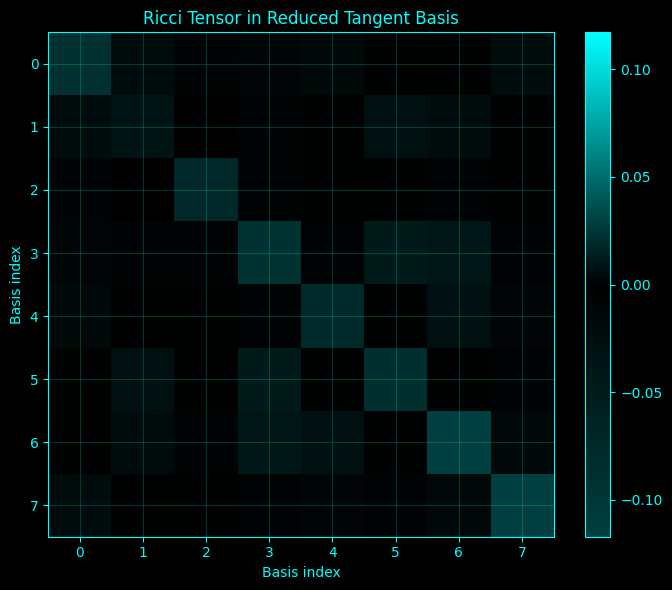

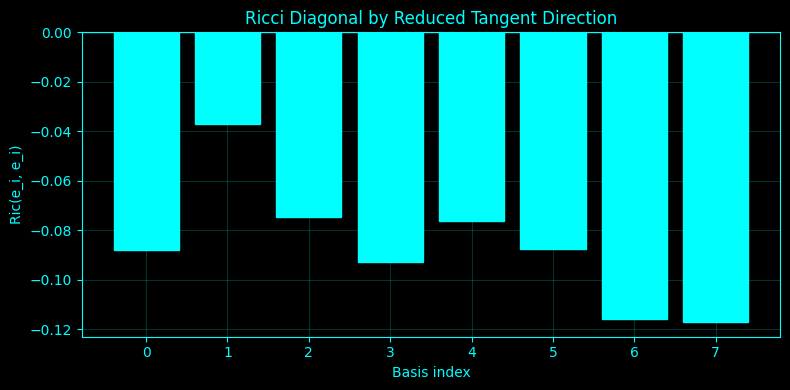

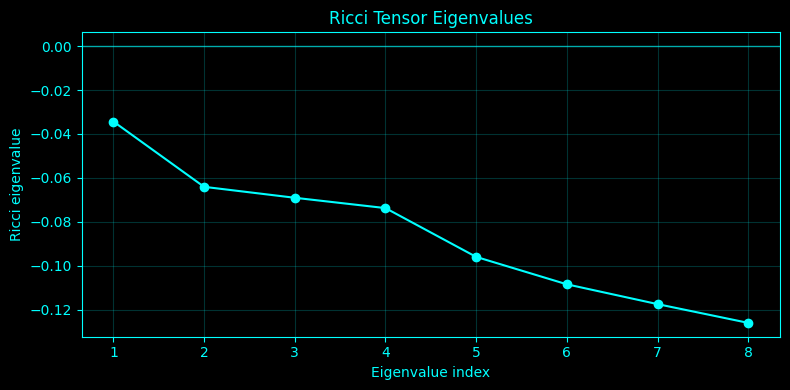

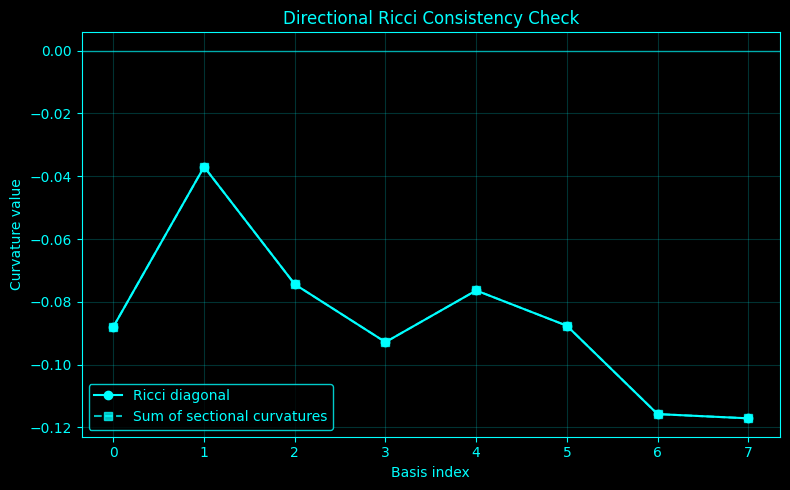

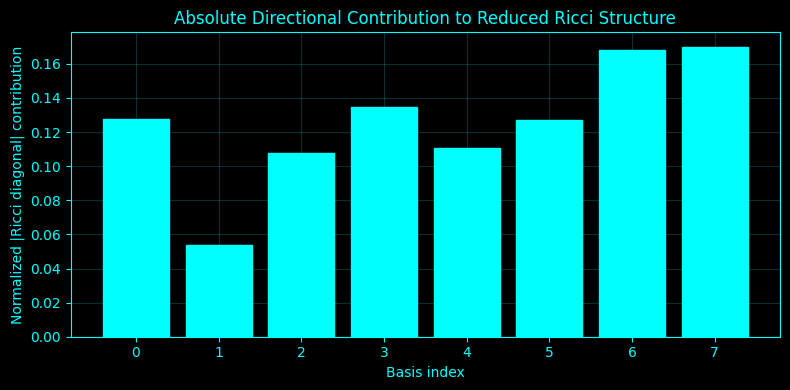


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis/ricci_scalar_curvature_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis/ricci_scalar_curvature_summary.csv
Saved eigenvalue CSV: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis/ricci_eigenvalues.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis/ricci_scalar_curvature_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/ricci_scalar_curvature_analysis/plots


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
curv_dir = os.path.join(base_dir, "riemann_curvature_tensor_analysis")
curv_npz_path = os.path.join(curv_dir, "riemann_curvature_tensor_results.npz")

out_dir = os.path.join(base_dir, "ricci_scalar_curvature_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def symmetrize(A):
    return 0.5 * (A + A.T)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(curv_npz_path):
    raise FileNotFoundError(
        f"Missing {curv_npz_path}. Run the reduced Riemann curvature tensor block first."
    )

data = np.load(curv_npz_path, allow_pickle=True)

R_tensor = np.asarray(data["R_tensor"], dtype=float)                 # shape: (k,k,k,k)
sectional_curvature = np.asarray(data["sectional_curvature"], dtype=float)
basis_vectors = np.asarray(data["basis_vectors"], dtype=float)
basis_matrices = np.asarray(data["basis_matrices"], dtype=float)
singular_values = np.asarray(data["singular_values"], dtype=float)
top_k_used = int(np.asarray(data["top_k_used"]).item())

k_eff = R_tensor.shape[0]

print(f"Loaded R tensor shape: {R_tensor.shape}")
print(f"Loaded sectional curvature shape: {sectional_curvature.shape}")
print(f"Reduced basis dimension: {k_eff}")

# -------------------------------------------------------
# RICCI TENSOR AND SCALAR CURVATURE
# -------------------------------------------------------
# Convention used previously:
# R[a,b,c,d] = < R(B_a, B_b) B_c , B_d >
#
# Ricci:
# Ric[b,c] = sum_a R[a,b,c,a]
#
# Scalar curvature:
# Scal = sum_b Ric[b,b]
ricci_tensor = np.einsum("abca->bc", R_tensor)
ricci_tensor = symmetrize(ricci_tensor)

scalar_curvature = float(np.trace(ricci_tensor))
ricci_diag = np.diag(ricci_tensor).copy()

# Ricci eigen-structure
ricci_eigvals, ricci_eigvecs = np.linalg.eigh(ricci_tensor)
order = np.argsort(ricci_eigvals)[::-1]
ricci_eigvals = ricci_eigvals[order]
ricci_eigvecs = ricci_eigvecs[:, order]

# Sectional-based directional Ricci check
# For orthonormal basis, Ric(e_i,e_i) = sum_j K(e_i,e_j)
sectional_row_sum = np.nansum(sectional_curvature, axis=1)
ricci_sectional_diag_error = ricci_diag - sectional_row_sum

# Absolute/relative directional contributions
abs_diag_sum = np.sum(np.abs(ricci_diag)) + eps
directional_abs_contrib = np.abs(ricci_diag) / abs_diag_sum

# -------------------------------------------------------
# SUMMARY TABLES
# -------------------------------------------------------
summary_rows = []
for i in range(k_eff):
    summary_rows.append({
        "basis_index": i,
        "singular_value": float(singular_values[i]) if i < len(singular_values) else np.nan,
        "ricci_diagonal": float(ricci_diag[i]),
        "sectional_row_sum": float(sectional_row_sum[i]),
        "ricci_minus_sectional_row_sum": float(ricci_sectional_diag_error[i]),
        "abs_directional_contribution": float(directional_abs_contrib[i]),
        "mean_sectional_curvature_vs_others": float(np.nanmean(sectional_curvature[i])),
        "min_sectional_curvature_vs_others": float(np.nanmin(sectional_curvature[i])),
        "max_sectional_curvature_vs_others": float(np.nanmax(sectional_curvature[i])),
    })

summary_df = pd.DataFrame(summary_rows)

eig_df = pd.DataFrame({
    "eigen_index": np.arange(1, k_eff + 1),
    "ricci_eigenvalue": ricci_eigvals
})

global_summary = {
    "k_eff": int(k_eff),
    "scalar_curvature": float(scalar_curvature),
    "mean_ricci_diagonal": float(np.mean(ricci_diag)),
    "min_ricci_diagonal": float(np.min(ricci_diag)),
    "max_ricci_diagonal": float(np.max(ricci_diag)),
    "n_positive_ricci_eigenvalues": int(np.sum(ricci_eigvals > 0)),
    "n_negative_ricci_eigenvalues": int(np.sum(ricci_eigvals < 0)),
    "min_ricci_eigenvalue": float(np.min(ricci_eigvals)),
    "max_ricci_eigenvalue": float(np.max(ricci_eigvals)),
    "mean_abs_diag_contribution": float(np.mean(directional_abs_contrib)),
    "max_abs_diag_contribution": float(np.max(directional_abs_contrib)),
    "ricci_sectional_consistency_rmse": float(np.sqrt(np.mean(ricci_sectional_diag_error ** 2))),
}

print("\nRicci / scalar curvature summary:")
print(summary_df)
print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "ricci_scalar_curvature_results.npz")
np.savez(
    npz_path,
    ricci_tensor=ricci_tensor,
    scalar_curvature=scalar_curvature,
    ricci_diagonal=ricci_diag,
    ricci_eigenvalues=ricci_eigvals,
    ricci_eigenvectors=ricci_eigvecs,
    sectional_row_sum=sectional_row_sum,
    ricci_sectional_diag_error=ricci_sectional_diag_error,
    directional_abs_contribution=directional_abs_contrib,
    singular_values=singular_values,
    basis_vectors=basis_vectors,
    basis_matrices=basis_matrices,
    R_tensor=R_tensor,
    sectional_curvature=sectional_curvature,
)

summary_csv = os.path.join(out_dir, "ricci_scalar_curvature_summary.csv")
summary_df.to_csv(summary_csv, index=False)

eig_csv = os.path.join(out_dir, "ricci_eigenvalues.csv")
eig_df.to_csv(eig_csv, index=False)

summary_txt = os.path.join(out_dir, "ricci_scalar_curvature_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Ricci Curvature and Scalar Curvature in the Reduced Tangent Basis\n")
    f.write("================================================================\n\n")
    f.write(f"Source NPZ: {curv_npz_path}\n")
    f.write(f"Reduced basis dimension: {k_eff}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAPS
# -------------------------------------------------------
cyan_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# Diverging but still within your black/cyan style:
# darker teal for negative, black near zero, bright cyan for positive
diverging_cmap = LinearSegmentedColormap.from_list(
    "teal_black_cyan",
    [
        (0.0, (0.0, 0.25, 0.25)),
        (0.5, (0.0, 0.0, 0.0)),
        (1.0, (0.0, 1.0, 1.0)),
    ]
)

ricci_absmax = max(np.max(np.abs(ricci_tensor)), eps)
ricci_norm = TwoSlopeNorm(vmin=-ricci_absmax, vcenter=0.0, vmax=ricci_absmax)

# -------------------------------------------------------
# PLOT 1: RICCI TENSOR HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(ricci_tensor, cmap=diverging_cmap, norm=ricci_norm, aspect="auto")
ax.set_title("Ricci Tensor in Reduced Tangent Basis")
ax.set_xlabel("Basis index")
ax.set_ylabel("Basis index")
ax.set_xticks(np.arange(k_eff))
ax.set_yticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)
ax.set_yticklabels(np.arange(k_eff), color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "ricci_tensor_heatmap.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: RICCI DIAGONAL
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(k_eff),
    ricci_diag,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.axhline(0.0, color=ACCENT, linewidth=1.0, alpha=0.6)
ax.set_title("Ricci Diagonal by Reduced Tangent Direction")
ax.set_xlabel("Basis index")
ax.set_ylabel("Ric(e_i, e_i)")
ax.set_xticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)

plot2_path = os.path.join(plots_dir, "ricci_diagonal_barplot.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: RICCI EIGENVALUES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    np.arange(1, k_eff + 1),
    ricci_eigvals,
    marker="o",
    color=ACCENT
)
ax.axhline(0.0, color=ACCENT, linewidth=1.0, alpha=0.6)
ax.set_title("Ricci Tensor Eigenvalues")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Ricci eigenvalue")

plot3_path = os.path.join(plots_dir, "ricci_eigenvalues.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: RICCI DIAGONAL VS SECTIONAL ROW SUM
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

ax.plot(np.arange(k_eff), ricci_diag, marker="o", color=ACCENT, label="Ricci diagonal")
ax.plot(np.arange(k_eff), sectional_row_sum, marker="s", color=ACCENT, linestyle="--", alpha=0.75, label="Sum of sectional curvatures")
ax.axhline(0.0, color=ACCENT, linewidth=1.0, alpha=0.6)
ax.set_title("Directional Ricci Consistency Check")
ax.set_xlabel("Basis index")
ax.set_ylabel("Curvature value")
ax.legend()

plot4_path = os.path.join(plots_dir, "ricci_vs_sectional_sum.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: ABSOLUTE DIRECTIONAL CONTRIBUTIONS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    np.arange(k_eff),
    directional_abs_contrib,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Absolute Directional Contribution to Reduced Ricci Structure")
ax.set_xlabel("Basis index")
ax.set_ylabel("Normalized |Ricci diagonal| contribution")
ax.set_xticks(np.arange(k_eff))
ax.set_xticklabels(np.arange(k_eff), color=ACCENT)

plot5_path = os.path.join(plots_dir, "ricci_directional_contributions.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved eigenvalue CSV: {eig_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Riemannian Barycenters for Channel Groups and Frequency Bands

Loaded EEG segment shape: (106944, 32)
Segmented EEG shape: (106, 32, 1000)


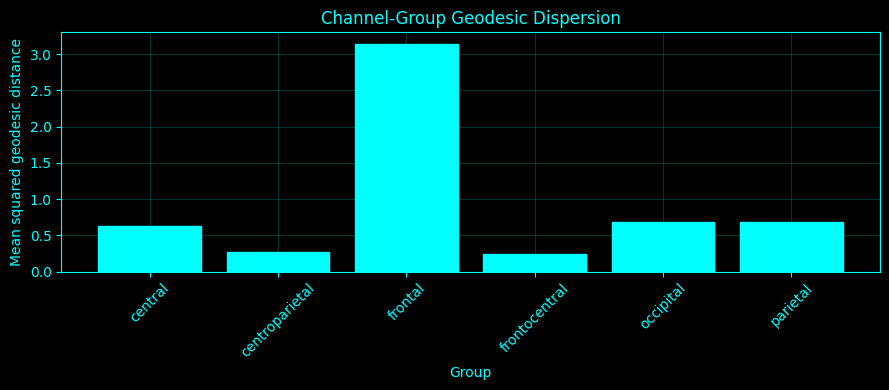

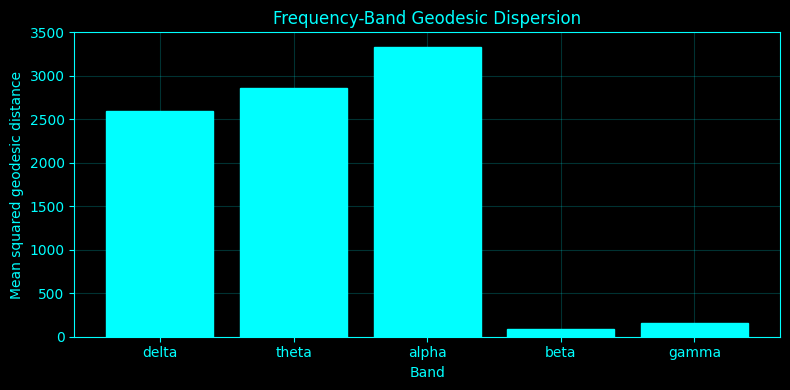

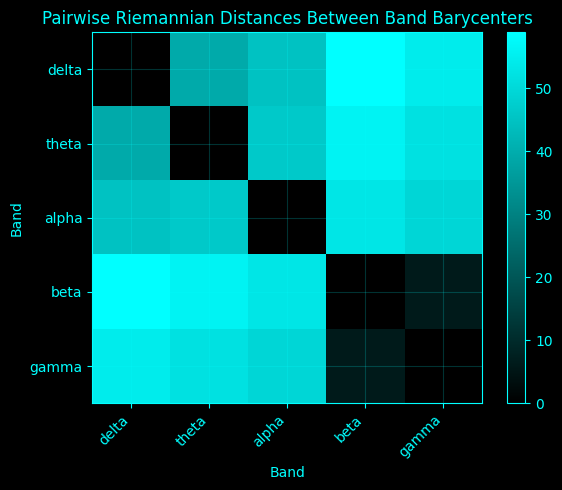


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis/riemannian_barycenters_results.npz
Saved group CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis/channel_group_barycenter_summary.csv
Saved band CSV: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis/frequency_band_barycenter_summary.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis/riemannian_barycenters_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/riemannian_barycenters_analysis/plots


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "riemannian_barycenters_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

window_size_sec = 1.0
samples_per_window = int(window_size_sec * sampling_rate)

cov_reg = 1e-6
max_iter_mean = 50
tol_mean = 1e-7
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

channel_groups = {
    "frontal":       ['Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    "frontocentral": ['FC5', 'FC1', 'FC2', 'FC6'],
    "central":       ['M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2'],
    "centroparietal":['CP5', 'CP1', 'CP2', 'CP6'],
    "parietal":      ['P7', 'P3', 'Pz', 'P4', 'P8'],
    "occipital":     ['POz', 'O1', 'Oz', 'O2'],
}

frequency_bands = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0),
    "gamma": (30.0, 45.0),
}

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def expm_sym(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    return (V * np.exp(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

def compute_riemannian_mean(cov_matrices, max_iter=50, tol=1e-7):
    cov_matrices = np.asarray(cov_matrices, dtype=float)
    n_mats, n, _ = cov_matrices.shape

    G = symmetrize(np.mean(cov_matrices, axis=0))

    for _ in range(max_iter):
        G_sqrt = sqrtm_spd(G)
        G_invsqrt = invsqrtm_spd(G)

        tangent_sum = np.zeros((n, n), dtype=float)
        for C in cov_matrices:
            inner = G_invsqrt @ C @ G_invsqrt
            tangent_sum += logm_spd(inner)

        tangent_mean = tangent_sum / n_mats
        update_norm = np.linalg.norm(tangent_mean, ord="fro")

        if update_norm < tol:
            break

        G = G_sqrt @ expm_sym(tangent_mean) @ G_sqrt
        G = symmetrize(G)

    return G

# -------------------------------------------------------
# EEG HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(EEG_data, n_channels_expected):
    EEG_data = np.asarray(EEG_data, dtype=float)

    if EEG_data.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {EEG_data.shape}")

    if EEG_data.shape[1] == n_channels_expected:
        return EEG_data
    elif EEG_data.shape[0] == n_channels_expected:
        return EEG_data.T
    else:
        raise ValueError(f"Unexpected EEG shape: {EEG_data.shape}")

def segment_data(EEG_data_tc, samples_per_window):
    total_samples, n_channels = EEG_data_tc.shape
    n_windows = total_samples // samples_per_window

    if n_windows < 1:
        raise ValueError("Not enough samples for one full window.")

    trimmed = EEG_data_tc[:n_windows * samples_per_window]
    segmented = trimmed.reshape(n_windows, samples_per_window, n_channels)
    segmented = np.transpose(segmented, (0, 2, 1))   # (epochs, channels, time)
    return segmented

def compute_cov_matrices(segmented_data, reg=1e-6):
    epochs, n_channels, n_time = segmented_data.shape
    X = segmented_data - np.mean(segmented_data, axis=2, keepdims=True)
    covs = np.matmul(X, np.transpose(X, (0, 2, 1))) / max(n_time - 1, 1)
    eye = np.eye(n_channels)[None, :, :]
    covs = covs + reg * eye
    covs = 0.5 * (covs + np.transpose(covs, (0, 2, 1)))
    return covs

def bandpass_epoch_rfft(epoch_ct, fs, f_low, f_high):
    """
    epoch_ct shape: (channels, time)
    """
    epoch_ct = np.asarray(epoch_ct, dtype=float)
    n_channels, n_time = epoch_ct.shape

    X = epoch_ct - np.mean(epoch_ct, axis=1, keepdims=True)
    F = np.fft.rfft(X, axis=1)
    freqs = np.fft.rfftfreq(n_time, d=1.0 / fs)

    mask = (freqs >= f_low) & (freqs <= f_high)
    F_filtered = F * mask[None, :]

    X_band = np.fft.irfft(F_filtered, n=n_time, axis=1)
    return X_band

def bandpass_segmented_data(segmented_data, fs, f_low, f_high):
    epochs, n_channels, n_time = segmented_data.shape
    out = np.zeros_like(segmented_data, dtype=float)

    for e in range(epochs):
        out[e] = bandpass_epoch_rfft(segmented_data[e], fs, f_low, f_high)

    return out

def geodesic_dispersion(covs, mean_cov):
    P_invsqrt = invsqrtm_spd(mean_cov)
    d2 = []
    for C in covs:
        d = affine_invariant_distance(C, mean_cov, P_invsqrt=P_invsqrt)
        d2.append(d * d)
    d2 = np.asarray(d2, dtype=float)
    return float(np.mean(d2)), d2

def safe_logdet_spd(A):
    A = symmetrize(A)
    w, _ = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return float(np.sum(np.log(w)))

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_data = EEG_data[start_index:end_index, :]

segmented_EEG = segment_data(EEG_data, samples_per_window=samples_per_window)
n_epochs = segmented_EEG.shape[0]
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded EEG segment shape: {EEG_data.shape}")
print(f"Segmented EEG shape: {segmented_EEG.shape}")

channel_to_idx = {ch: i for i, ch in enumerate(eeg_channel_names)}

# -------------------------------------------------------
# CHANNEL-GROUP BARYCENTERS
# -------------------------------------------------------
group_summary_rows = []
group_barycenters = {}
group_dispersion_profiles = {}

for group_name, group_channels in channel_groups.items():
    idxs = [channel_to_idx[ch] for ch in group_channels if ch in channel_to_idx]
    group_data = segmented_EEG[:, idxs, :]  # (epochs, group_channels, time)

    covs = compute_cov_matrices(group_data, reg=cov_reg)
    bary = compute_riemannian_mean(covs, max_iter=max_iter_mean, tol=tol_mean)
    disp, d2 = geodesic_dispersion(covs, bary)

    group_barycenters[group_name] = bary
    group_dispersion_profiles[group_name] = d2

    diag_mean = float(np.mean(np.diag(bary)))
    offdiag_vals = bary[np.triu_indices(len(idxs), k=1)]
    mean_abs_offdiag = float(np.mean(np.abs(offdiag_vals))) if len(offdiag_vals) > 0 else 0.0

    group_summary_rows.append({
        "group": group_name,
        "n_channels": len(idxs),
        "channels": ",".join(group_channels),
        "trace_barycenter": float(np.trace(bary)),
        "logdet_barycenter": safe_logdet_spd(bary),
        "mean_diag_barycenter": diag_mean,
        "mean_abs_offdiag_barycenter": mean_abs_offdiag,
        "geodesic_dispersion": disp,
        "max_epoch_squared_distance": float(np.max(d2)),
        "min_epoch_squared_distance": float(np.min(d2)),
    })

group_summary_df = pd.DataFrame(group_summary_rows).sort_values("group").reset_index(drop=True)

# -------------------------------------------------------
# FREQUENCY-BAND BARYCENTERS
# -------------------------------------------------------
band_summary_rows = []
band_barycenters = {}
band_dispersion_profiles = {}

for band_name, (f_low, f_high) in frequency_bands.items():
    band_data = bandpass_segmented_data(segmented_EEG, sampling_rate, f_low, f_high)
    covs = compute_cov_matrices(band_data, reg=cov_reg)
    bary = compute_riemannian_mean(covs, max_iter=max_iter_mean, tol=tol_mean)
    disp, d2 = geodesic_dispersion(covs, bary)

    band_barycenters[band_name] = bary
    band_dispersion_profiles[band_name] = d2

    diag_mean = float(np.mean(np.diag(bary)))
    offdiag_vals = bary[np.triu_indices(len(eeg_channel_names), k=1)]
    mean_abs_offdiag = float(np.mean(np.abs(offdiag_vals))) if len(offdiag_vals) > 0 else 0.0

    band_summary_rows.append({
        "band": band_name,
        "f_low": f_low,
        "f_high": f_high,
        "trace_barycenter": float(np.trace(bary)),
        "logdet_barycenter": safe_logdet_spd(bary),
        "mean_diag_barycenter": diag_mean,
        "mean_abs_offdiag_barycenter": mean_abs_offdiag,
        "geodesic_dispersion": disp,
        "max_epoch_squared_distance": float(np.max(d2)),
        "min_epoch_squared_distance": float(np.min(d2)),
    })

band_summary_df = pd.DataFrame(band_summary_rows).sort_values("f_low").reset_index(drop=True)

# -------------------------------------------------------
# PAIRWISE DISTANCES BETWEEN BAND BARYCENTERS
# -------------------------------------------------------
band_names = list(band_summary_df["band"].values)
n_bands = len(band_names)
band_distance_matrix = np.zeros((n_bands, n_bands), dtype=float)

for i in range(n_bands):
    for j in range(i + 1, n_bands):
        dij = affine_invariant_distance(
            band_barycenters[band_names[i]],
            band_barycenters[band_names[j]]
        )
        band_distance_matrix[i, j] = dij
        band_distance_matrix[j, i] = dij

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
save_dict = {
    "epoch_start_time": epoch_start_time,
    "epoch_center_time": epoch_center_time,
    "window_size_sec": window_size_sec,
    "start_time": start_time,
    "end_time": end_time,
    "band_distance_matrix": band_distance_matrix,
}

for group_name, bary in group_barycenters.items():
    save_dict[f"group_barycenter_{group_name}"] = bary
    save_dict[f"group_dispersion_profile_{group_name}"] = group_dispersion_profiles[group_name]

for band_name, bary in band_barycenters.items():
    save_dict[f"band_barycenter_{band_name}"] = bary
    save_dict[f"band_dispersion_profile_{band_name}"] = band_dispersion_profiles[band_name]

npz_path = os.path.join(out_dir, "riemannian_barycenters_results.npz")
np.savez_compressed(npz_path, **save_dict)

group_csv = os.path.join(out_dir, "channel_group_barycenter_summary.csv")
band_csv = os.path.join(out_dir, "frequency_band_barycenter_summary.csv")
group_summary_df.to_csv(group_csv, index=False)
band_summary_df.to_csv(band_csv, index=False)

summary_txt = os.path.join(out_dir, "riemannian_barycenters_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Riemannian Barycenters for Channel Groups and Frequency Bands\n")
    f.write("============================================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"Epochs: {n_epochs}\n\n")

    f.write("Channel-group barycenters:\n")
    for _, row in group_summary_df.iterrows():
        f.write(
            f"  {row['group']}: "
            f"n_channels={int(row['n_channels'])}, "
            f"trace={row['trace_barycenter']:.6f}, "
            f"logdet={row['logdet_barycenter']:.6f}, "
            f"mean_diag={row['mean_diag_barycenter']:.6f}, "
            f"mean_abs_offdiag={row['mean_abs_offdiag_barycenter']:.6f}, "
            f"dispersion={row['geodesic_dispersion']:.6f}\n"
        )

    f.write("\nFrequency-band barycenters:\n")
    for _, row in band_summary_df.iterrows():
        f.write(
            f"  {row['band']} [{row['f_low']:.1f},{row['f_high']:.1f}] Hz: "
            f"trace={row['trace_barycenter']:.6f}, "
            f"logdet={row['logdet_barycenter']:.6f}, "
            f"mean_diag={row['mean_diag_barycenter']:.6f}, "
            f"mean_abs_offdiag={row['mean_abs_offdiag_barycenter']:.6f}, "
            f"dispersion={row['geodesic_dispersion']:.6f}\n"
        )

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOTS: CHANNEL GROUPS
# -------------------------------------------------------
for group_name, bary in group_barycenters.items():
    group_channels = channel_groups[group_name]

    fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(np.abs(bary), cmap=custom_cmap, aspect="auto")
    ax.set_title(f"Channel-Group Barycenter: {group_name}")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")
    ax.set_xticks(np.arange(len(group_channels)))
    ax.set_yticks(np.arange(len(group_channels)))
    ax.set_xticklabels(group_channels, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(group_channels, color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    path = os.path.join(plots_dir, f"group_barycenter_{group_name}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()

# Group dispersion bar plot
fig, ax = plt.subplots(figsize=(9, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    group_summary_df["group"].values,
    group_summary_df["geodesic_dispersion"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Channel-Group Geodesic Dispersion")
ax.set_xlabel("Group")
ax.set_ylabel("Mean squared geodesic distance")
ax.tick_params(axis="x", rotation=45)

group_disp_path = os.path.join(plots_dir, "channel_group_dispersion.png")
plt.tight_layout()
plt.savefig(group_disp_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOTS: FREQUENCY BANDS
# -------------------------------------------------------
for band_name in band_names:
    bary = band_barycenters[band_name]

    fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
    style_ax(ax)

    im = ax.imshow(np.abs(bary), cmap=custom_cmap, aspect="auto")
    ax.set_title(f"Frequency-Band Barycenter: {band_name}")
    ax.set_xlabel("Channel")
    ax.set_ylabel("Channel")
    ax.set_xticks(np.arange(len(eeg_channel_names)))
    ax.set_yticks(np.arange(len(eeg_channel_names)))
    ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(eeg_channel_names, color=ACCENT)

    cbar = plt.colorbar(im, ax=ax)
    cbar.outline.set_edgecolor(ACCENT)
    cbar.ax.tick_params(color=ACCENT)
    for label in cbar.ax.get_yticklabels():
        label.set_color(ACCENT)

    path = os.path.join(plots_dir, f"band_barycenter_{band_name}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.close()

# Band dispersion bar plot
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    band_summary_df["band"].values,
    band_summary_df["geodesic_dispersion"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Frequency-Band Geodesic Dispersion")
ax.set_xlabel("Band")
ax.set_ylabel("Mean squared geodesic distance")

band_disp_path = os.path.join(plots_dir, "frequency_band_dispersion.png")
plt.tight_layout()
plt.savefig(band_disp_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Pairwise band barycenter distances
fig, ax = plt.subplots(figsize=(6, 5), facecolor=BG)
style_ax(ax)

im = ax.imshow(band_distance_matrix, cmap=custom_cmap, aspect="auto")
ax.set_title("Pairwise Riemannian Distances Between Band Barycenters")
ax.set_xlabel("Band")
ax.set_ylabel("Band")
ax.set_xticks(np.arange(n_bands))
ax.set_yticks(np.arange(n_bands))
ax.set_xticklabels(band_names, rotation=45, ha="right", color=ACCENT)
ax.set_yticklabels(band_names, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

band_dist_path = os.path.join(plots_dir, "band_barycenter_distance_matrix.png")
plt.tight_layout()
plt.savefig(band_dist_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved group CSV: {group_csv}")
print(f"Saved band CSV: {band_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Intrinsic Geodesic Network on the Covariance Manifold

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Loaded cached epoch-to-epoch distance matrix.

Intrinsic geodesic network summary:
n_epochs: 106
n_channels: 32
graph_mode: knn
graph_param_value: 6.0
n_components: 1
largest_component_size: 106
mean_degree: 10.283018867924529
mean_strength: 3.6203949045394843
mean_closeness: 0.1071190243055978
mean_clustering_coeff: 0.41963323247331114
spectral_gap: 0.06214488686925996
edge_density: 0.09793351302785264
mean_edge_weight: 0.35207510080842686
mean_shortest_path_finite: 9.586704755720914


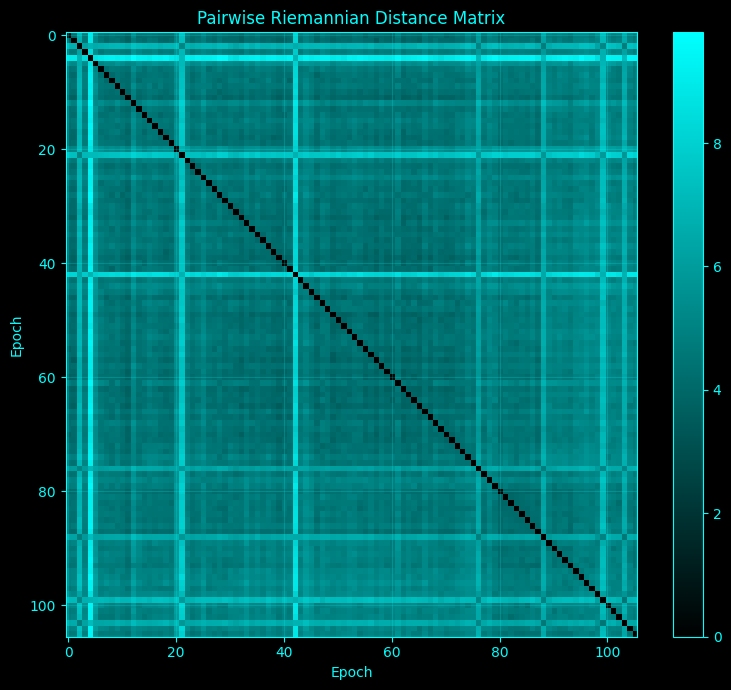

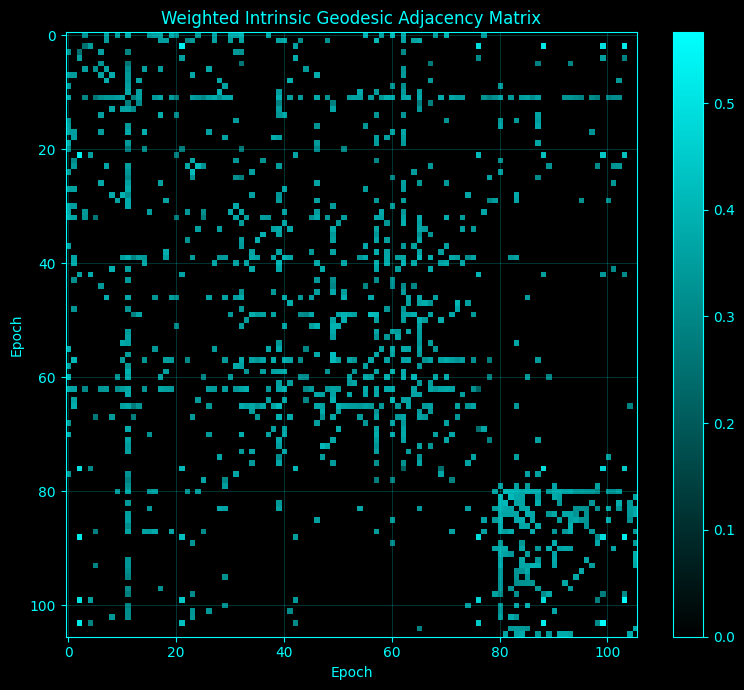

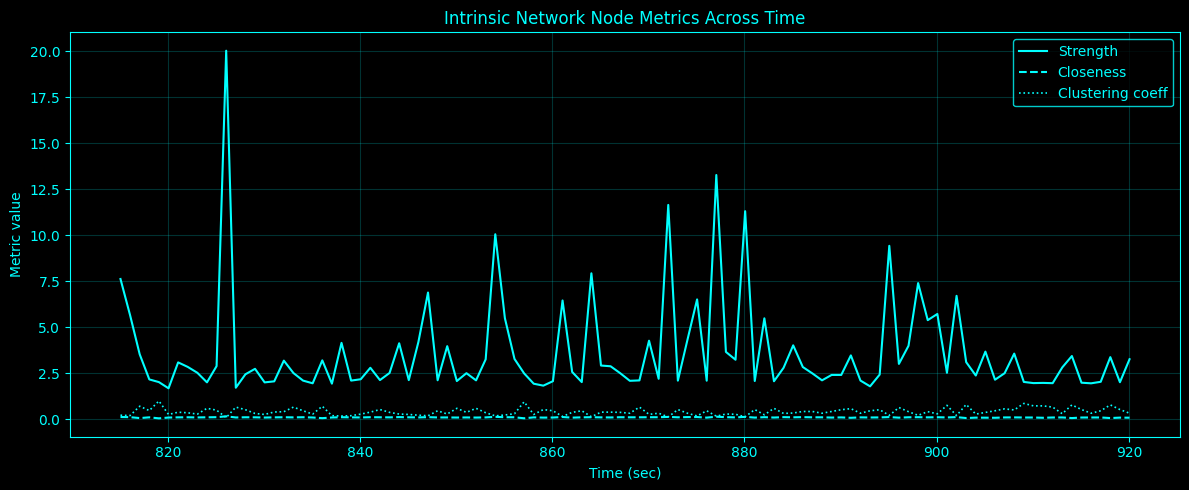

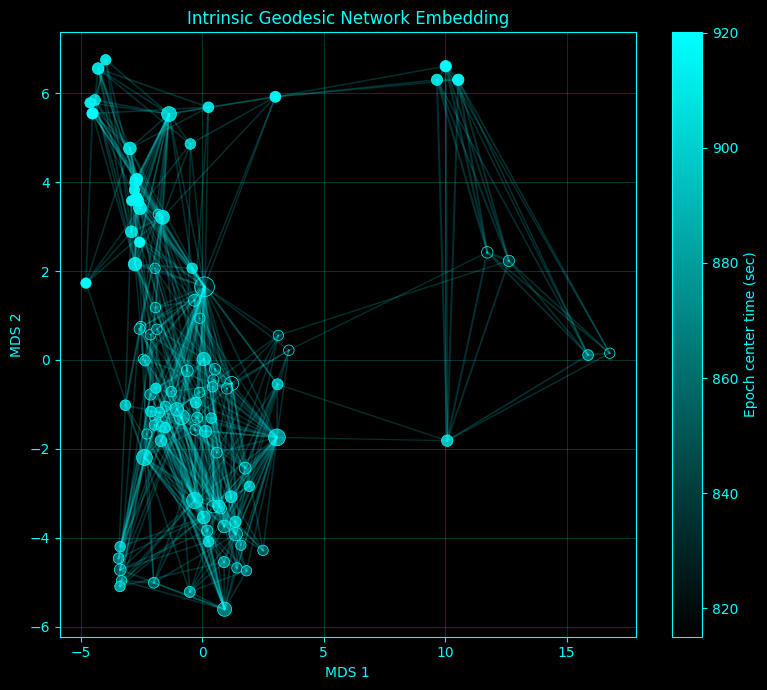

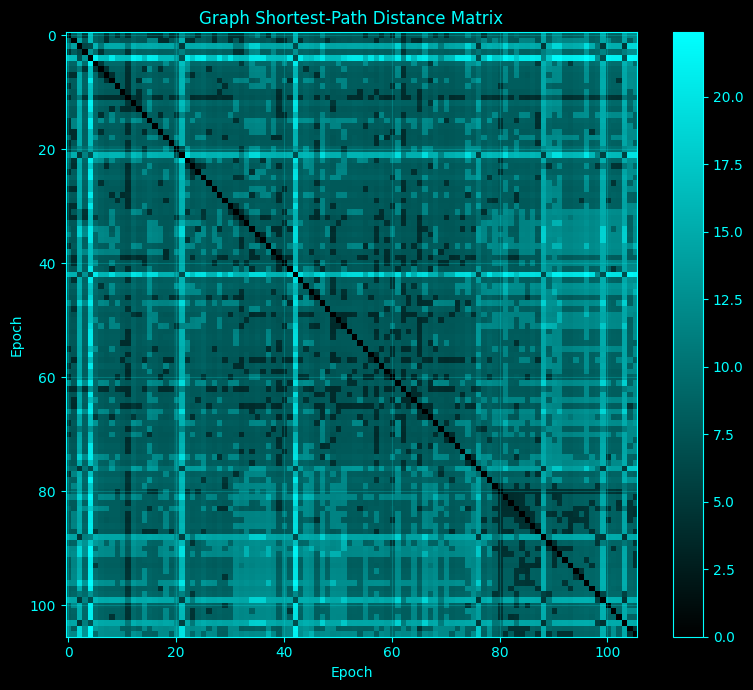

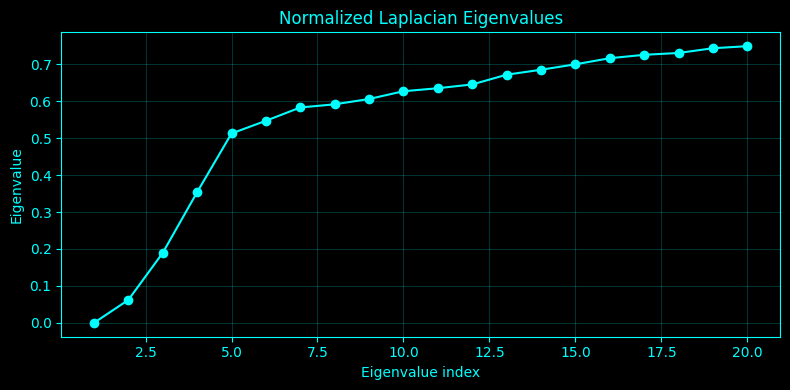


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network/intrinsic_geodesic_network_results.npz
Saved node CSV: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network/intrinsic_geodesic_network_nodes.csv
Saved component CSV: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network/intrinsic_geodesic_network_components.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network/intrinsic_geodesic_network_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/intrinsic_geodesic_network/plots


In [17]:
import os
import heapq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

# optional cached epoch-to-epoch distances from earlier block
dist_landscape_npz = os.path.join(
    base_dir,
    "riemannian_distance_landscape",
    "riemannian_distance_landscape_results.npz"
)

out_dir = os.path.join(base_dir, "intrinsic_geodesic_network")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Network construction
graph_mode = "knn"          # "knn" or "epsilon"
k_neighbors = 6
epsilon_percentile = 20     # only used if graph_mode == "epsilon"
use_local_scale_weights = True
mutual_knn_only = False     # if True, keep only mutual kNN edges

# Spectral / embedding
use_shortest_path_for_embedding = True

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

# -------------------------------------------------------
# DISTANCE MATRIX
# -------------------------------------------------------
def pairwise_riemannian_distance_matrix(cov_matrices):
    n = len(cov_matrices)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        D[i, i] = 0.0
        for j in range(i + 1, n):
            dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
            D[i, j] = dij
            D[j, i] = dij
    return D

# -------------------------------------------------------
# GRAPH BUILDING
# -------------------------------------------------------
def build_knn_graph(D, k=6, use_local_scale=True, mutual_only=False):
    n = D.shape[0]
    A = np.zeros((n, n), dtype=float)

    # exclude self, sort neighbors
    knn_idx = np.argsort(D, axis=1)[:, 1:k+1]
    sigma = D[np.arange(n), knn_idx[:, -1]].copy()
    sigma[sigma <= 0] = np.median(sigma[sigma > 0]) if np.any(sigma > 0) else 1.0

    knn_sets = [set(knn_idx[i].tolist()) for i in range(n)]

    for i in range(n):
        for j in knn_idx[i]:
            cond = (i in knn_sets[j]) if mutual_only else True
            if not cond:
                continue

            dij = D[i, j]
            if use_local_scale:
                wij = np.exp(-(dij ** 2) / (sigma[i] * sigma[j] + eps))
            else:
                sigma0 = np.median(sigma)
                wij = np.exp(-(dij ** 2) / (sigma0 ** 2 + eps))

            if wij > A[i, j]:
                A[i, j] = wij
                A[j, i] = wij

    np.fill_diagonal(A, 0.0)
    return A, sigma

def build_epsilon_graph(D, percentile=20, use_local_scale=True):
    n = D.shape[0]
    upper_i, upper_j = np.triu_indices(n, k=1)
    upper_vals = D[upper_i, upper_j]
    threshold = np.percentile(upper_vals, percentile)

    A = np.zeros((n, n), dtype=float)
    sigma0 = np.median(upper_vals[upper_vals > 0]) if np.any(upper_vals > 0) else 1.0

    for i in range(n):
        for j in range(i + 1, n):
            if D[i, j] <= threshold:
                if use_local_scale:
                    wij = np.exp(-(D[i, j] ** 2) / (sigma0 ** 2 + eps))
                else:
                    wij = 1.0
                A[i, j] = wij
                A[j, i] = wij

    np.fill_diagonal(A, 0.0)
    return A, threshold

# -------------------------------------------------------
# GRAPH METRICS
# -------------------------------------------------------
def connected_components_from_adjacency(A):
    n = A.shape[0]
    labels = -np.ones(n, dtype=int)
    comp_id = 0

    for start in range(n):
        if labels[start] != -1:
            continue
        stack = [start]
        labels[start] = comp_id

        while stack:
            u = stack.pop()
            nbrs = np.where(A[u] > 0)[0]
            for v in nbrs:
                if labels[v] == -1:
                    labels[v] = comp_id
                    stack.append(v)

        comp_id += 1

    sizes = np.array([np.sum(labels == c) for c in range(comp_id)], dtype=int)
    return labels, sizes

def local_clustering_coeff_unweighted(A):
    B = (A > 0).astype(int)
    n = B.shape[0]
    coeff = np.zeros(n, dtype=float)

    for i in range(n):
        nbrs = np.where(B[i] > 0)[0]
        k = len(nbrs)
        if k < 2:
            coeff[i] = 0.0
            continue

        sub = B[np.ix_(nbrs, nbrs)]
        edges = np.sum(sub) / 2.0
        coeff[i] = (2.0 * edges) / (k * (k - 1))

    return coeff

def dijkstra_all_pairs(edge_lengths):
    n = edge_lengths.shape[0]
    Dsp = np.full((n, n), np.inf, dtype=float)

    for src in range(n):
        dist = np.full(n, np.inf, dtype=float)
        dist[src] = 0.0
        pq = [(0.0, src)]

        while pq:
            d_u, u = heapq.heappop(pq)
            if d_u > dist[u]:
                continue

            nbrs = np.where(np.isfinite(edge_lengths[u]))[0]
            for v in nbrs:
                if u == v:
                    continue
                alt = d_u + edge_lengths[u, v]
                if alt < dist[v]:
                    dist[v] = alt
                    heapq.heappush(pq, (alt, v))

        Dsp[src] = dist

    return Dsp

def closeness_centrality_from_shortest_paths(Dsp):
    n = Dsp.shape[0]
    closeness = np.zeros(n, dtype=float)

    for i in range(n):
        reachable = np.isfinite(Dsp[i]) & (np.arange(n) != i)
        m = np.sum(reachable)
        if m == 0:
            closeness[i] = 0.0
        else:
            closeness[i] = m / (np.sum(Dsp[i, reachable]) + eps)

    return closeness

def normalized_laplacian(A):
    degree_strength = np.sum(A, axis=1)
    inv_sqrt = np.zeros_like(degree_strength)
    mask = degree_strength > 0
    inv_sqrt[mask] = 1.0 / np.sqrt(degree_strength[mask])

    Dm12 = np.diag(inv_sqrt)
    I = np.eye(A.shape[0])
    L = I - Dm12 @ A @ Dm12
    return symmetrize(L)

def classical_mds(D, n_components=2):
    D = np.asarray(D, dtype=float)
    n = D.shape[0]

    # replace inf with large finite value if needed
    finite_mask = np.isfinite(D)
    max_finite = np.max(D[finite_mask]) if np.any(finite_mask) else 1.0
    D = D.copy()
    D[~finite_mask] = 1.2 * max_finite

    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    B = symmetrize(B)

    w, V = np.linalg.eigh(B)
    order = np.argsort(w)[::-1]
    w = w[order]
    V = V[:, order]

    pos = w > eps
    w = w[pos][:n_components]
    V = V[:, pos][:, :n_components]

    if len(w) == 0:
        return np.zeros((n, n_components), dtype=float), np.zeros(n_components, dtype=float)

    X = V * np.sqrt(w)[None, :]
    if X.shape[1] < n_components:
        pad = np.zeros((n, n_components - X.shape[1]), dtype=float)
        X = np.hstack([X, pad])

    return X, w

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)
cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")

# -------------------------------------------------------
# LOAD OR COMPUTE PAIRWISE DISTANCES
# -------------------------------------------------------
if os.path.exists(dist_landscape_npz):
    ddata = np.load(dist_landscape_npz, allow_pickle=True)
    if "epoch_distance_matrix" in ddata and ddata["epoch_distance_matrix"].shape == (n_epochs, n_epochs):
        D_pairwise = np.asarray(ddata["epoch_distance_matrix"], dtype=float)
        print("Loaded cached epoch-to-epoch distance matrix.")
    else:
        D_pairwise = pairwise_riemannian_distance_matrix(cov_matrices)
        print("Computed pairwise Riemannian distance matrix.")
else:
    D_pairwise = pairwise_riemannian_distance_matrix(cov_matrices)
    print("Computed pairwise Riemannian distance matrix.")

# -------------------------------------------------------
# BUILD INTRINSIC NETWORK
# -------------------------------------------------------
if graph_mode == "knn":
    A, local_scale = build_knn_graph(
        D_pairwise,
        k=k_neighbors,
        use_local_scale=use_local_scale_weights,
        mutual_only=mutual_knn_only
    )
    graph_param_value = k_neighbors
elif graph_mode == "epsilon":
    A, threshold = build_epsilon_graph(
        D_pairwise,
        percentile=epsilon_percentile,
        use_local_scale=use_local_scale_weights
    )
    graph_param_value = threshold
else:
    raise ValueError("graph_mode must be 'knn' or 'epsilon'")

# edge lengths for graph geodesics: use intrinsic SPD distances on existing edges
edge_lengths = np.full_like(D_pairwise, np.inf)
mask_edges = A > 0
edge_lengths[mask_edges] = D_pairwise[mask_edges]
np.fill_diagonal(edge_lengths, 0.0)

# -------------------------------------------------------
# GRAPH METRICS
# -------------------------------------------------------
degree = np.sum(A > 0, axis=1).astype(int)
strength = np.sum(A, axis=1)
component_labels, component_sizes = connected_components_from_adjacency(A)
clustering_coeff = local_clustering_coeff_unweighted(A)

D_shortest = dijkstra_all_pairs(edge_lengths)
closeness = closeness_centrality_from_shortest_paths(D_shortest)

Lnorm = normalized_laplacian(A)
lap_eigvals, lap_eigvecs = np.linalg.eigh(Lnorm)
order = np.argsort(lap_eigvals)
lap_eigvals = lap_eigvals[order]
lap_eigvecs = lap_eigvecs[:, order]

spectral_gap = float(lap_eigvals[1] - lap_eigvals[0]) if len(lap_eigvals) > 1 else np.nan
fiedler_vector = lap_eigvecs[:, 1] if len(lap_eigvals) > 1 else np.zeros(n_epochs)

# -------------------------------------------------------
# EMBEDDING FOR VISUALIZATION
# -------------------------------------------------------
embedding_metric = D_shortest if use_shortest_path_for_embedding else D_pairwise
embed_2d, mds_eigs = classical_mds(embedding_metric, n_components=2)

# -------------------------------------------------------
# SUMMARY TABLES
# -------------------------------------------------------
node_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "degree": degree,
    "strength": strength,
    "closeness": closeness,
    "clustering_coeff": clustering_coeff,
    "component_label": component_labels,
    "fiedler_vector": fiedler_vector,
    "embed_x": embed_2d[:, 0],
    "embed_y": embed_2d[:, 1],
})

component_rows = []
for comp_id, comp_size in enumerate(component_sizes):
    idx = np.where(component_labels == comp_id)[0]
    component_rows.append({
        "component_label": comp_id,
        "size": int(comp_size),
        "fraction_of_nodes": float(comp_size / n_epochs),
        "mean_degree": float(np.mean(degree[idx])) if len(idx) else np.nan,
        "mean_strength": float(np.mean(strength[idx])) if len(idx) else np.nan,
        "mean_closeness": float(np.mean(closeness[idx])) if len(idx) else np.nan,
        "start_time_sec": float(np.min(epoch_center_time[idx])) if len(idx) else np.nan,
        "end_time_sec": float(np.max(epoch_center_time[idx])) if len(idx) else np.nan,
    })
component_df = pd.DataFrame(component_rows)

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "graph_mode": graph_mode,
    "graph_param_value": float(graph_param_value),
    "n_components": int(len(component_sizes)),
    "largest_component_size": int(np.max(component_sizes)),
    "mean_degree": float(np.mean(degree)),
    "mean_strength": float(np.mean(strength)),
    "mean_closeness": float(np.mean(closeness)),
    "mean_clustering_coeff": float(np.mean(clustering_coeff)),
    "spectral_gap": spectral_gap,
    "edge_density": float(np.sum(A > 0) / (n_epochs * (n_epochs - 1) + eps)),
    "mean_edge_weight": float(np.mean(A[A > 0])) if np.any(A > 0) else 0.0,
    "mean_shortest_path_finite": float(np.mean(D_shortest[np.isfinite(D_shortest) & (D_shortest > 0)])),
}

print("\nIntrinsic geodesic network summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "intrinsic_geodesic_network_results.npz")
np.savez(
    npz_path,
    pairwise_distance_matrix=D_pairwise,
    adjacency=A,
    edge_lengths=edge_lengths,
    shortest_path_matrix=D_shortest,
    degree=degree,
    strength=strength,
    closeness=closeness,
    clustering_coeff=clustering_coeff,
    component_labels=component_labels,
    component_sizes=component_sizes,
    laplacian_eigenvalues=lap_eigvals,
    laplacian_eigenvectors=lap_eigvecs,
    embed_2d=embed_2d,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    start_time=start_time,
    end_time=end_time,
    window_size_sec=window_size_sec,
)

node_csv = os.path.join(out_dir, "intrinsic_geodesic_network_nodes.csv")
component_csv = os.path.join(out_dir, "intrinsic_geodesic_network_components.csv")
summary_txt = os.path.join(out_dir, "intrinsic_geodesic_network_summary.txt")

node_df.to_csv(node_csv, index=False)
component_df.to_csv(component_csv, index=False)

with open(summary_txt, "w") as f:
    f.write("Intrinsic Geodesic Network on the Covariance Manifold\n")
    f.write("====================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"Graph mode: {graph_mode}\n")
    f.write(f"Graph parameter: {graph_param_value}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: PAIRWISE DISTANCE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(D_pairwise, cmap=custom_cmap, aspect="auto")
ax.set_title("Pairwise Riemannian Distance Matrix")
ax.set_xlabel("Epoch")
ax.set_ylabel("Epoch")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "pairwise_distance_matrix.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: ADJACENCY MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(A, cmap=custom_cmap, aspect="auto")
ax.set_title("Weighted Intrinsic Geodesic Adjacency Matrix")
ax.set_xlabel("Epoch")
ax.set_ylabel("Epoch")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "adjacency_matrix.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: NODE METRICS OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, strength, color=ACCENT, linewidth=1.5, label="Strength")
ax.plot(epoch_center_time, closeness, color=ACCENT, linewidth=1.5, linestyle="--", label="Closeness")
ax.plot(epoch_center_time, clustering_coeff, color=ACCENT, linewidth=1.2, linestyle=":", label="Clustering coeff")

ax.set_title("Intrinsic Network Node Metrics Across Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Metric value")
ax.legend()

plot3_path = os.path.join(plots_dir, "node_metrics_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: 2D EMBEDDING OF INTRINSIC NETWORK
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

# draw edges
ii, jj = np.where(np.triu(A > 0, k=1))
for i, j in zip(ii, jj):
    ax.plot(
        [embed_2d[i, 0], embed_2d[j, 0]],
        [embed_2d[i, 1], embed_2d[j, 1]],
        color=ACCENT,
        alpha=0.18,
        linewidth=0.5 + 2.0 * A[i, j]
    )

sc = ax.scatter(
    embed_2d[:, 0],
    embed_2d[:, 1],
    c=epoch_center_time,
    cmap=custom_cmap,
    s=40 + 160 * (strength / (np.max(strength) + eps)),
    edgecolors=ACCENT,
    linewidths=0.5
)

ax.set_title("Intrinsic Geodesic Network Embedding")
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Epoch center time (sec)", color=ACCENT)

plot4_path = os.path.join(plots_dir, "intrinsic_network_embedding.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: SHORTEST-PATH MATRIX
# -------------------------------------------------------
Dsp_plot = D_shortest.copy()
finite_mask = np.isfinite(Dsp_plot)
if np.any(finite_mask):
    Dsp_plot[~finite_mask] = np.max(Dsp_plot[finite_mask])

fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(Dsp_plot, cmap=custom_cmap, aspect="auto")
ax.set_title("Graph Shortest-Path Distance Matrix")
ax.set_xlabel("Epoch")
ax.set_ylabel("Epoch")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "shortest_path_matrix.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 6: LAPLACIAN EIGENVALUES
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4), facecolor=BG)
style_ax(ax)

n_plot = min(20, len(lap_eigvals))
ax.plot(np.arange(1, n_plot + 1), lap_eigvals[:n_plot], marker="o", color=ACCENT)
ax.set_title("Normalized Laplacian Eigenvalues")
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel("Eigenvalue")

plot6_path = os.path.join(plots_dir, "laplacian_eigenvalues.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved node CSV: {node_csv}")
print(f"Saved component CSV: {component_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Local Manifold Anisotropy of EEG Covariance States

Loaded covariance matrices: (106, 32, 32)
Loaded Riemannian mean: (32, 32)
Loaded cached epoch-to-epoch distance matrix.

Local manifold anisotropy summary:
   epoch_index  epoch_start_time_sec  epoch_center_time_sec   lambda1  \
0            0               814.571                815.071  1.650463   
1            1               815.571                816.071  1.648857   
2            2               816.571                817.071  4.513064   
3            3               817.571                818.071  2.014708   
4            4               818.571                819.071  5.073897   

    lambda2   lambda3  local_total_variance  anisotropy_ratio  top1_fraction  \
0  1.428239  1.359947              6.830657        167.907610       0.241626   
1  1.502916  1.282982              6.630872        174.416916       0.248664   
2  3.541428  2.434650             14.305563        242.878225       0.315476   
3  1.675198  1.333175              7.477285        194.368147       0.269444   
4  3

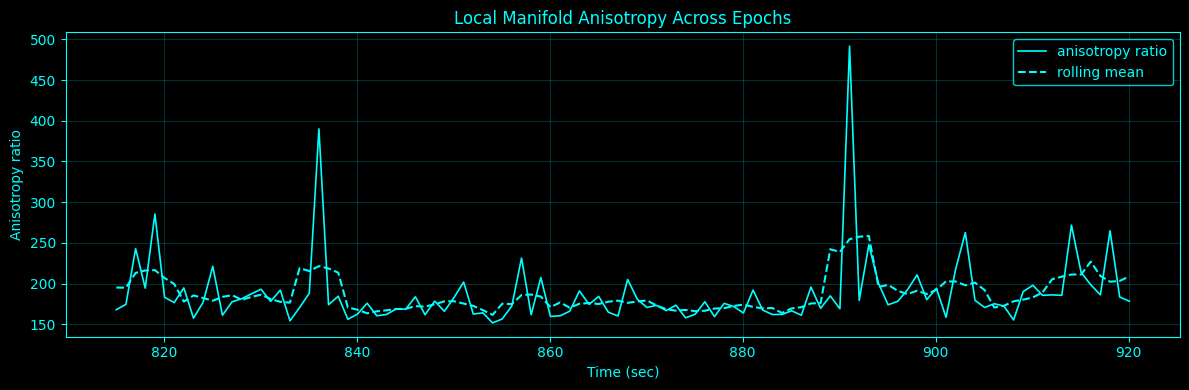

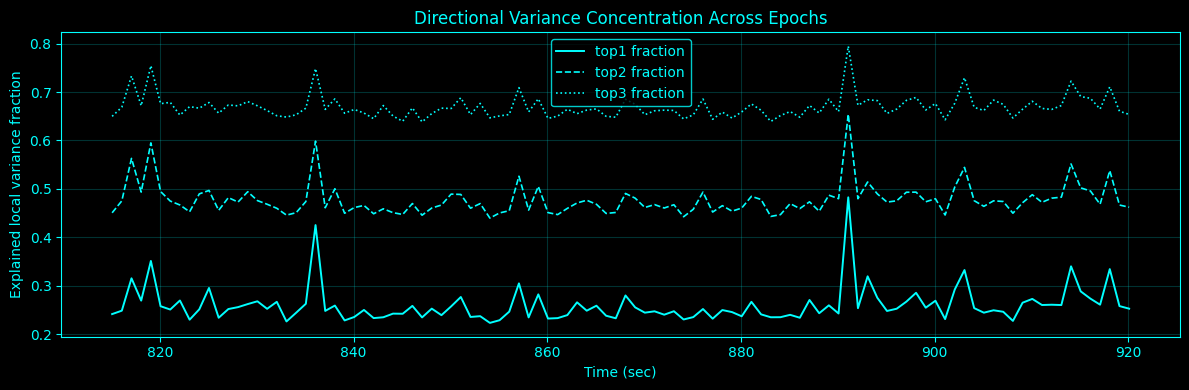

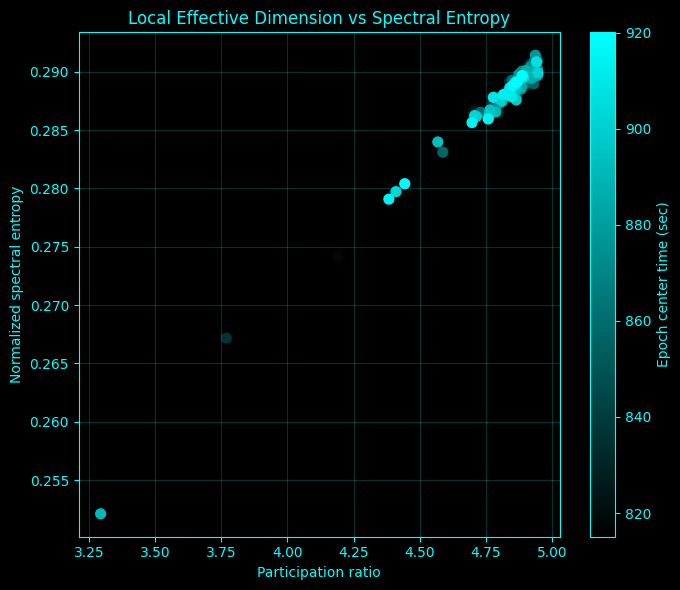

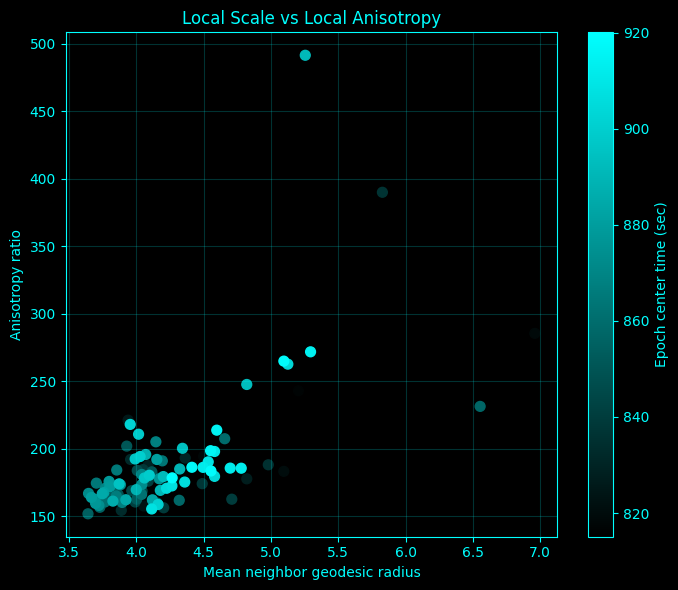

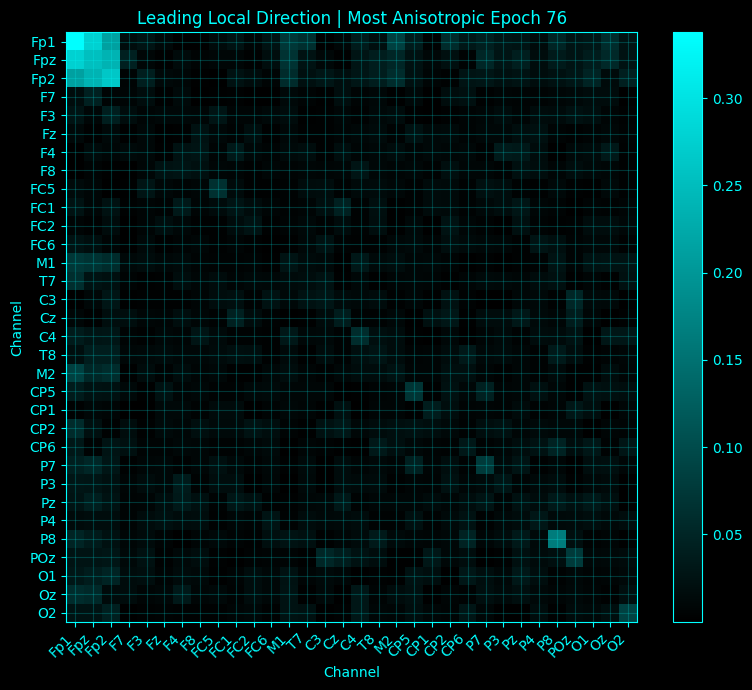


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy/local_manifold_anisotropy_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy/local_manifold_anisotropy_summary.csv
Saved loadings CSV: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy/local_anisotropy_top_epoch_channel_loadings.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy/local_manifold_anisotropy_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/local_manifold_anisotropy/plots


In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

# optional cached distances from earlier block
dist_landscape_npz = os.path.join(
    base_dir,
    "riemannian_distance_landscape",
    "riemannian_distance_landscape_results.npz"
)

out_dir = os.path.join(base_dir, "local_manifold_anisotropy")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# neighborhood size in the covariance manifold
k_neighbors = 6

# how many leading local directions to save as matrices
n_local_dirs_to_save = 3

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

def tangent_log_at_base(C, base, base_invsqrt=None):
    if base_invsqrt is None:
        base_invsqrt = invsqrtm_spd(base)
    inner = base_invsqrt @ C @ base_invsqrt
    return symmetrize(logm_spd(inner))

# -------------------------------------------------------
# SYMMETRIC VECTORIZATION
# -------------------------------------------------------
def symmat_to_vec(S):
    """
    Frobenius-isometric vectorization for symmetric matrices.
    """
    S = symmetrize(np.asarray(S, dtype=float))
    n = S.shape[0]
    vals = []

    for i in range(n):
        vals.append(S[i, i])

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(np.sqrt(2.0) * S[i, j])

    return np.asarray(vals, dtype=float)

def vec_to_symmat(v, n):
    S = np.zeros((n, n), dtype=float)
    idx = 0

    for i in range(n):
        S[i, i] = v[idx]
        idx += 1

    for i in range(n):
        for j in range(i + 1, n):
            val = v[idx] / np.sqrt(2.0)
            S[i, j] = val
            S[j, i] = val
            idx += 1

    return S

# -------------------------------------------------------
# DISTANCE MATRIX
# -------------------------------------------------------
def pairwise_riemannian_distance_matrix(cov_matrices):
    n = len(cov_matrices)
    D = np.zeros((n, n), dtype=float)
    for i in range(n):
        D[i, i] = 0.0
        for j in range(i + 1, n):
            dij = affine_invariant_distance(cov_matrices[i], cov_matrices[j])
            D[i, j] = dij
            D[j, i] = dij
    return D

# -------------------------------------------------------
# LOCAL ANISOTROPY METRICS
# -------------------------------------------------------
def safe_covariance(X):
    """
    X shape: (samples, features)
    """
    X = np.asarray(X, dtype=float)
    if X.shape[0] <= 1:
        return np.zeros((X.shape[1], X.shape[1]), dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(X.shape[0] - 1, 1)
    return symmetrize(C)

def normalized_spectral_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return 0.0
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    num = (np.sum(vals) ** 2)
    den = np.sum(vals ** 2) + eps
    return float(num / den)

def rolling_mean(x, window=5):
    return pd.Series(x).rolling(window, center=True, min_periods=1).mean().to_numpy()

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(
        f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first."
    )

data = np.load(riem_npz_path, allow_pickle=True)
cov_matrices = np.asarray(data["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(data["riemannian_mean"], dtype=float)

start_time = float(data["start_time"])
end_time = float(data["end_time"])
window_size_sec = float(data["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded Riemannian mean: {riemannian_mean.shape}")

# -------------------------------------------------------
# LOAD OR COMPUTE DISTANCES
# -------------------------------------------------------
if os.path.exists(dist_landscape_npz):
    ddata = np.load(dist_landscape_npz, allow_pickle=True)
    if "epoch_distance_matrix" in ddata and ddata["epoch_distance_matrix"].shape == (n_epochs, n_epochs):
        D_pairwise = np.asarray(ddata["epoch_distance_matrix"], dtype=float)
        print("Loaded cached epoch-to-epoch distance matrix.")
    else:
        D_pairwise = pairwise_riemannian_distance_matrix(cov_matrices)
        print("Computed pairwise Riemannian distance matrix.")
else:
    D_pairwise = pairwise_riemannian_distance_matrix(cov_matrices)
    print("Computed pairwise Riemannian distance matrix.")

# -------------------------------------------------------
# LOCAL MANIFOLD ANISOTROPY
# -------------------------------------------------------
feature_dim = n_channels * (n_channels + 1) // 2

local_dir_mats = np.zeros((n_epochs, n_local_dirs_to_save, n_channels, n_channels), dtype=float)
local_dir_eigvals = np.zeros((n_epochs, n_local_dirs_to_save), dtype=float)

summary_rows = []

for i in range(n_epochs):
    # nearest neighbors excluding self
    nbr_idx = np.argsort(D_pairwise[i])[1:k_neighbors + 1]
    neighbor_distances = D_pairwise[i, nbr_idx]

    base = cov_matrices[i]
    base_invsqrt = invsqrtm_spd(base)

    # tangent coordinates of neighbors around epoch i
    tangent_vecs = []
    for j in nbr_idx:
        Xij = tangent_log_at_base(cov_matrices[j], base, base_invsqrt=base_invsqrt)
        tangent_vecs.append(symmat_to_vec(Xij))

    tangent_vecs = np.stack(tangent_vecs, axis=0)  # (k_neighbors, tangent_dim)
    C_local = safe_covariance(tangent_vecs)

    eigvals, eigvecs = np.linalg.eigh(C_local)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    eigvals = np.maximum(eigvals, 0.0)
    total_var = float(np.sum(eigvals))

    lam1 = float(eigvals[0]) if len(eigvals) > 0 else 0.0
    lam2 = float(eigvals[1]) if len(eigvals) > 1 else 0.0
    lam3 = float(eigvals[2]) if len(eigvals) > 2 else 0.0
    tail_mean = float(np.mean(eigvals[1:])) if len(eigvals) > 1 else 0.0

    anisotropy_ratio = lam1 / (tail_mean + eps)
    top1_fraction = lam1 / (total_var + eps)
    top2_fraction = (lam1 + lam2) / (total_var + eps)
    top3_fraction = (lam1 + lam2 + lam3) / (total_var + eps)
    entropy_norm = normalized_spectral_entropy(eigvals)
    pr = participation_ratio(eigvals)

    # local geodesic scale
    local_radius_mean = float(np.mean(neighbor_distances))
    local_radius_std = float(np.std(neighbor_distances))
    local_radius_max = float(np.max(neighbor_distances))

    # save leading local direction matrices
    for p in range(min(n_local_dirs_to_save, eigvecs.shape[1])):
        local_dir_eigvals[i, p] = eigvals[p]
        local_dir_mats[i, p] = vec_to_symmat(eigvecs[:, p], n_channels)

    summary_rows.append({
        "epoch_index": i,
        "epoch_start_time_sec": float(epoch_start_time[i]),
        "epoch_center_time_sec": float(epoch_center_time[i]),
        "lambda1": lam1,
        "lambda2": lam2,
        "lambda3": lam3,
        "local_total_variance": total_var,
        "anisotropy_ratio": anisotropy_ratio,
        "top1_fraction": top1_fraction,
        "top2_fraction": top2_fraction,
        "top3_fraction": top3_fraction,
        "spectral_entropy_norm": entropy_norm,
        "participation_ratio": pr,
        "effective_dimension_fraction": pr / max(k_neighbors, 1),
        "local_radius_mean": local_radius_mean,
        "local_radius_std": local_radius_std,
        "local_radius_max": local_radius_max,
    })

summary_df = pd.DataFrame(summary_rows)

# rolling summaries
summary_df["anisotropy_ratio_roll"] = rolling_mean(summary_df["anisotropy_ratio"].values, window=5)
summary_df["top1_fraction_roll"] = rolling_mean(summary_df["top1_fraction"].values, window=5)
summary_df["participation_ratio_roll"] = rolling_mean(summary_df["participation_ratio"].values, window=5)
summary_df["spectral_entropy_norm_roll"] = rolling_mean(summary_df["spectral_entropy_norm"].values, window=5)

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "k_neighbors": int(k_neighbors),
    "mean_anisotropy_ratio": float(np.mean(summary_df["anisotropy_ratio"])),
    "max_anisotropy_ratio": float(np.max(summary_df["anisotropy_ratio"])),
    "min_anisotropy_ratio": float(np.min(summary_df["anisotropy_ratio"])),
    "mean_top1_fraction": float(np.mean(summary_df["top1_fraction"])),
    "mean_top2_fraction": float(np.mean(summary_df["top2_fraction"])),
    "mean_participation_ratio": float(np.mean(summary_df["participation_ratio"])),
    "mean_spectral_entropy_norm": float(np.mean(summary_df["spectral_entropy_norm"])),
    "most_anisotropic_epoch": int(summary_df["anisotropy_ratio"].idxmax()),
    "least_anisotropic_epoch": int(summary_df["anisotropy_ratio"].idxmin()),
    "mean_local_radius": float(np.mean(summary_df["local_radius_mean"])),
}

print("\nLocal manifold anisotropy summary:")
print(summary_df.head())
print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# CHANNEL LOADINGS FOR MOST ANISOTROPIC EPOCHS
# -------------------------------------------------------
top_epoch_ids = summary_df.sort_values("anisotropy_ratio", ascending=False)["epoch_index"].values[:5]

channel_loading_rows = []
for epoch_id in top_epoch_ids:
    M = local_dir_mats[epoch_id, 0]
    channel_abs_load = np.sum(np.abs(M), axis=1)
    for ch_idx in range(n_channels):
        channel_loading_rows.append({
            "epoch_index": int(epoch_id),
            "channel": ch_idx,
            "channel_name": f"ch_{ch_idx}",
            "abs_loading_sum": float(channel_abs_load[ch_idx]),
        })

channel_loadings_df = pd.DataFrame(channel_loading_rows)

# replace generic names with known EEG labels if dimension matches
if n_channels == 32:
    channel_loadings_df["channel_name"] = channel_loadings_df["channel"].map(
        {i: name for i, name in enumerate([
            'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
            'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
            'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
        ])}
    )

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "local_manifold_anisotropy_results.npz")
np.savez(
    npz_path,
    summary_columns=np.array(summary_df.columns, dtype=object),
    summary_values=summary_df.values,
    pairwise_distance_matrix=D_pairwise,
    local_dir_mats=local_dir_mats,
    local_dir_eigvals=local_dir_eigvals,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    k_neighbors=k_neighbors,
    start_time=start_time,
    end_time=end_time,
    window_size_sec=window_size_sec,
)

summary_csv = os.path.join(out_dir, "local_manifold_anisotropy_summary.csv")
summary_df.to_csv(summary_csv, index=False)

loadings_csv = os.path.join(out_dir, "local_anisotropy_top_epoch_channel_loadings.csv")
channel_loadings_df.to_csv(loadings_csv, index=False)

summary_txt = os.path.join(out_dir, "local_manifold_anisotropy_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Local Manifold Anisotropy of EEG Covariance States\n")
    f.write("=================================================\n\n")
    f.write(f"Source NPZ: {riem_npz_path}\n")
    f.write(f"Epochs: {n_epochs}\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Window size: {window_size_sec} sec\n")
    f.write(f"k_neighbors: {k_neighbors}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: ANISOTROPY OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    summary_df["epoch_center_time_sec"].values,
    summary_df["anisotropy_ratio"].values,
    color=ACCENT,
    linewidth=1.2,
    label="anisotropy ratio"
)
ax.plot(
    summary_df["epoch_center_time_sec"].values,
    summary_df["anisotropy_ratio_roll"].values,
    color=ACCENT,
    linestyle="--",
    linewidth=1.5,
    label="rolling mean"
)
ax.set_title("Local Manifold Anisotropy Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Anisotropy ratio")
ax.legend()

plot1_path = os.path.join(plots_dir, "anisotropy_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: TOP1 / TOP2 / TOP3 FRACTIONS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

t = summary_df["epoch_center_time_sec"].values
ax.plot(t, summary_df["top1_fraction"].values, color=ACCENT, linewidth=1.4, label="top1 fraction")
ax.plot(t, summary_df["top2_fraction"].values, color=ACCENT, linewidth=1.2, linestyle="--", label="top2 fraction")
ax.plot(t, summary_df["top3_fraction"].values, color=ACCENT, linewidth=1.2, linestyle=":", label="top3 fraction")

ax.set_title("Directional Variance Concentration Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Explained local variance fraction")
ax.legend()

plot2_path = os.path.join(plots_dir, "directional_variance_fractions.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: PARTICIPATION RATIO VS ENTROPY
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    summary_df["participation_ratio"].values,
    summary_df["spectral_entropy_norm"].values,
    c=summary_df["epoch_center_time_sec"].values,
    cmap=custom_cmap,
    s=50
)
ax.set_title("Local Effective Dimension vs Spectral Entropy")
ax.set_xlabel("Participation ratio")
ax.set_ylabel("Normalized spectral entropy")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Epoch center time (sec)", color=ACCENT)

plot3_path = os.path.join(plots_dir, "participation_vs_entropy.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: LOCAL ANISOTROPY VS LOCAL RADIUS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    summary_df["local_radius_mean"].values,
    summary_df["anisotropy_ratio"].values,
    c=summary_df["epoch_center_time_sec"].values,
    cmap=custom_cmap,
    s=50
)
ax.set_title("Local Scale vs Local Anisotropy")
ax.set_xlabel("Mean neighbor geodesic radius")
ax.set_ylabel("Anisotropy ratio")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Epoch center time (sec)", color=ACCENT)

plot4_path = os.path.join(plots_dir, "radius_vs_anisotropy.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: HEATMAP OF LEADING LOCAL DIRECTION FOR MOST ANISOTROPIC EPOCH
# -------------------------------------------------------
most_aniso_epoch = int(summary_df.loc[summary_df["anisotropy_ratio"].idxmax(), "epoch_index"])
M = local_dir_mats[most_aniso_epoch, 0]

fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(np.abs(M), cmap=custom_cmap, aspect="auto")
ax.set_title(f"Leading Local Direction | Most Anisotropic Epoch {most_aniso_epoch}")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")

if n_channels == 32:
    labels = [
        'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
        'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
        'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
    ]
    ax.set_xticks(np.arange(n_channels))
    ax.set_yticks(np.arange(n_channels))
    ax.set_xticklabels(labels, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(labels, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "leading_local_direction_most_anisotropic_epoch.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved loadings CSV: {loadings_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Parallel Transport of Local Anisotropy Directions Across Epochs

Loaded covariance matrices: (106, 32, 32)
Loaded local direction matrices: (106, 3, 32, 32)

Parallel-transported local anisotropy summary:
n_epochs: 106
n_channels: 32
direction_index: 0
reference_mode: global_mean
directional_coherence: 0.12051361912679573
mean_cosine_to_mean_direction: 0.12051361912699246
min_cosine_to_mean_direction: -0.19430740335056254
max_cosine_to_mean_direction: 0.44014609700946605
mean_consecutive_cosine: 0.11981347518327973
mean_consecutive_angle_deg: 83.08194572775145
max_drift_from_first_angle_deg: 110.99511263195697
mean_norm_preservation_error: 0.0820937208655303
max_norm_preservation_error: 0.29653931140373957


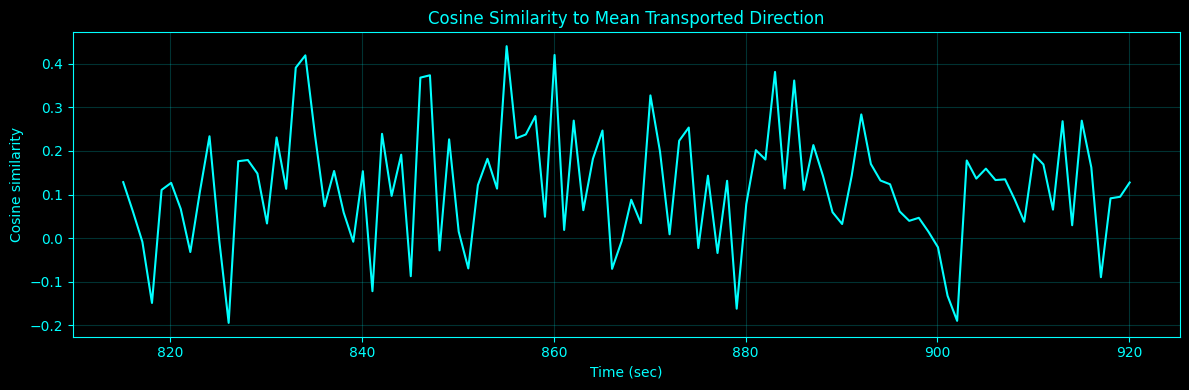

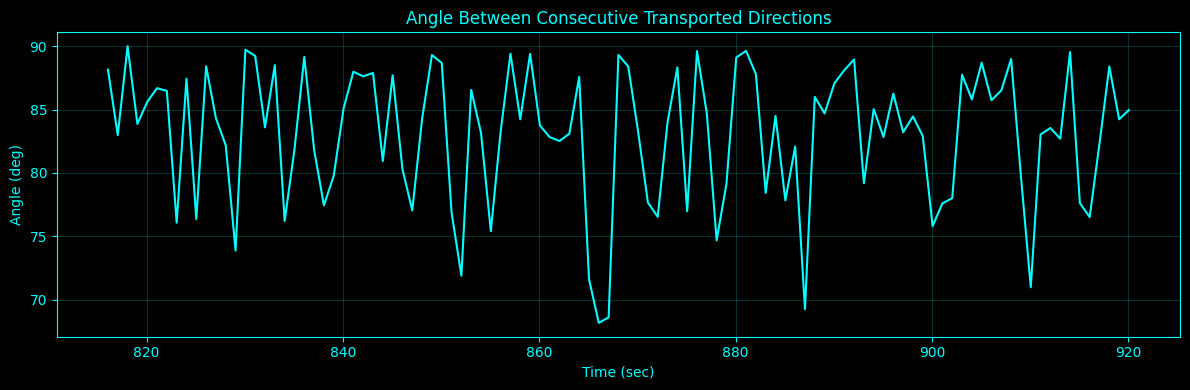

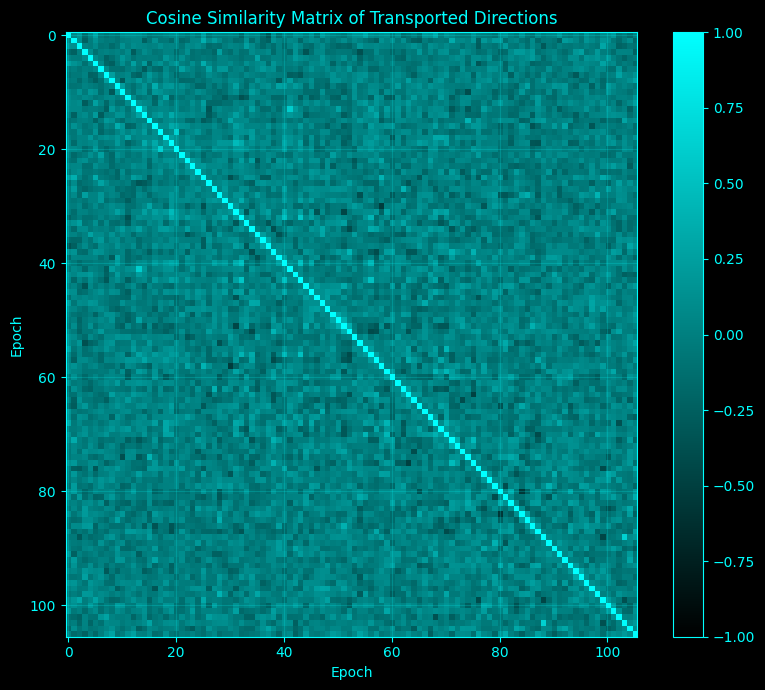

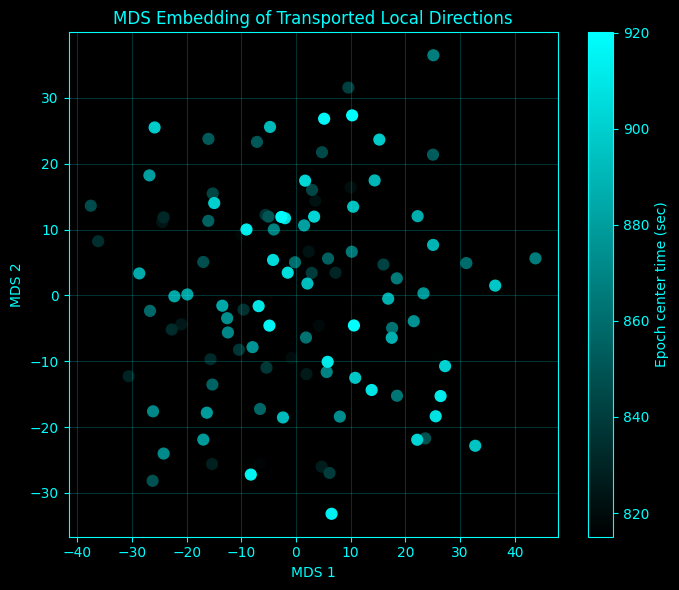

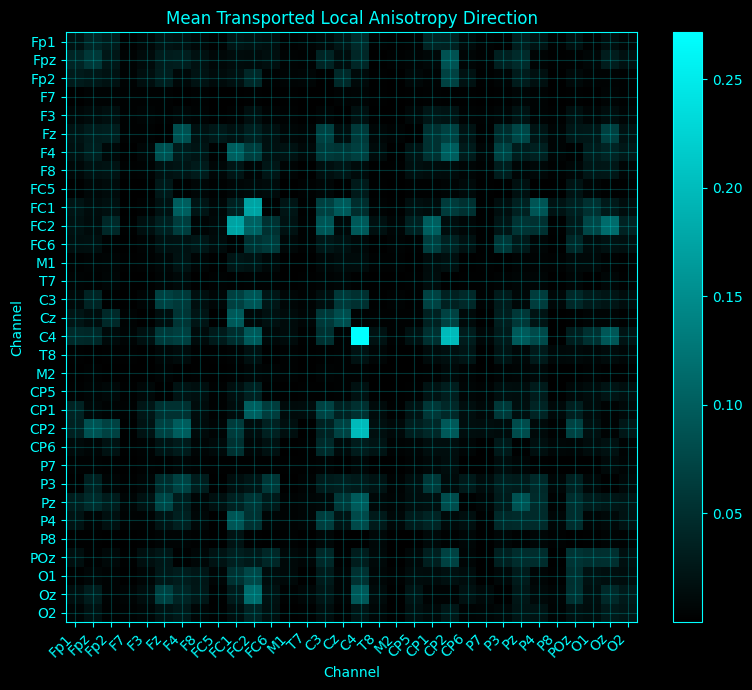

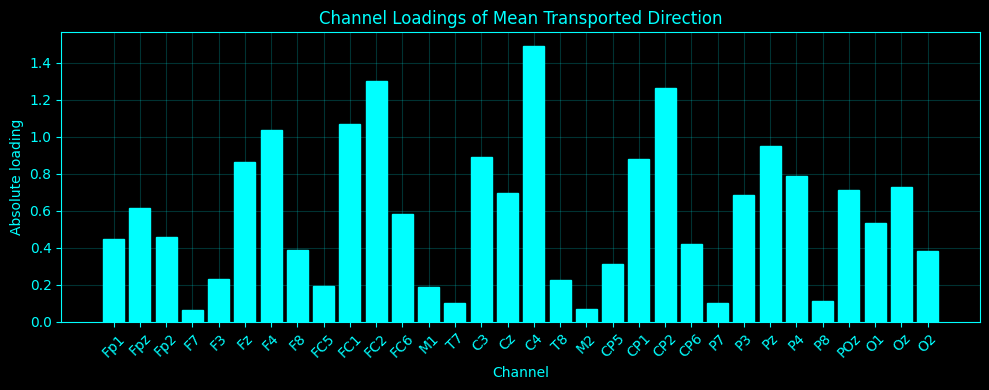


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy/parallel_transport_local_anisotropy_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy/parallel_transport_local_anisotropy_summary.csv
Saved channel CSV: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy/parallel_transport_mean_direction_channel_loadings.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy/parallel_transport_local_anisotropy_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/parallel_transport_local_anisotropy/plots


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

aniso_dir = os.path.join(base_dir, "local_manifold_anisotropy")
aniso_npz_path = os.path.join(aniso_dir, "local_manifold_anisotropy_results.npz")

out_dir = os.path.join(base_dir, "parallel_transport_local_anisotropy")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# Which local direction to transport:
# 0 = strongest local anisotropy direction
direction_index = 0

# Reference point for transport
reference_mode = "global_mean"   # "global_mean" or "first_epoch"

eps = 1e-12
ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def sqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.sqrt(w)) @ V.T

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    w, _ = np.linalg.eigh(symmetrize(inner))
    w = eig_clip(w, eps)
    return float(np.sqrt(np.sum(np.log(w) ** 2)))

# -------------------------------------------------------
# PARALLEL TRANSPORT ON SPD
# -------------------------------------------------------
def transport_operator(P, Q):
    """
    Affine-invariant parallel transport congruence operator.
    Tangent vector W at P is transported to Q by:
        W_Q = E W E^T
    where
        E = Q^{1/2} (Q^{-1/2} P Q^{-1/2})^{-1/2} Q^{-1/2}
    Equivalent stable form:
        E = Q^{1/2} (Q^{-1/2} P Q^{-1/2})^{-1/2} Q^{-1/2}
    """
    P = symmetrize(np.asarray(P, dtype=float))
    Q = symmetrize(np.asarray(Q, dtype=float))

    Q_sqrt = sqrtm_spd(Q)
    Q_invsqrt = invsqrtm_spd(Q)
    middle = Q_invsqrt @ P @ Q_invsqrt
    middle_inv_sqrt = invsqrtm_spd(middle)
    E = Q_sqrt @ middle_inv_sqrt @ Q_invsqrt
    return symmetrize(E)

def parallel_transport_tangent(W, P, Q):
    E = transport_operator(P, Q)
    return symmetrize(E @ W @ E.T)

def whiten_tangent_at_base(W, base):
    """
    Convert tangent matrix at 'base' into identity coordinates
    so Frobenius inner product matches the affine-invariant metric.
    """
    B_invsqrt = invsqrtm_spd(base)
    return symmetrize(B_invsqrt @ W @ B_invsqrt)

def normalize_fro(W):
    nrm = np.sqrt(np.sum(W * W))
    return W / (nrm + eps), float(nrm)

def fro_cosine(A, B):
    num = np.sum(A * B)
    den = np.sqrt(np.sum(A * A) * np.sum(B * B)) + eps
    return float(np.clip(num / den, -1.0, 1.0))

# -------------------------------------------------------
# CLASSICAL MDS
# -------------------------------------------------------
def classical_mds(D, n_components=2):
    D = np.asarray(D, dtype=float)
    finite_mask = np.isfinite(D)
    max_finite = np.max(D[finite_mask]) if np.any(finite_mask) else 1.0
    D = D.copy()
    D[~finite_mask] = 1.2 * max_finite

    n = D.shape[0]
    D2 = D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ D2 @ J
    B = symmetrize(B)

    w, V = np.linalg.eigh(B)
    order = np.argsort(w)[::-1]
    w = w[order]
    V = V[:, order]

    pos = w > eps
    w = w[pos][:n_components]
    V = V[:, pos][:, :n_components]

    if len(w) == 0:
        return np.zeros((n, n_components)), np.zeros(n_components)

    X = V * np.sqrt(w)[None, :]
    if X.shape[1] < n_components:
        X = np.hstack([X, np.zeros((n, n_components - X.shape[1]))])

    return X, w

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
if not os.path.exists(riem_npz_path):
    raise FileNotFoundError(f"Missing {riem_npz_path}. Run the Riemannian covariance mean block first.")

if not os.path.exists(aniso_npz_path):
    raise FileNotFoundError(f"Missing {aniso_npz_path}. Run the local manifold anisotropy block first.")

riem = np.load(riem_npz_path, allow_pickle=True)
aniso = np.load(aniso_npz_path, allow_pickle=True)

cov_matrices = np.asarray(riem["cov_matrices"], dtype=float)
global_mean = np.asarray(riem["riemannian_mean"], dtype=float)

epoch_start_time = np.asarray(aniso["epoch_start_time"], dtype=float)
epoch_center_time = np.asarray(aniso["epoch_center_time"], dtype=float)
local_dir_mats = np.asarray(aniso["local_dir_mats"], dtype=float)

n_epochs, n_channels, _ = cov_matrices.shape

if local_dir_mats.shape[0] != n_epochs:
    raise ValueError("Mismatch between local_dir_mats epochs and covariance epochs.")

if direction_index < 0 or direction_index >= local_dir_mats.shape[1]:
    raise ValueError("direction_index is out of range.")

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded local direction matrices: {local_dir_mats.shape}")

# -------------------------------------------------------
# CHOOSE REFERENCE POINT
# -------------------------------------------------------
if reference_mode == "global_mean":
    reference_point = global_mean
elif reference_mode == "first_epoch":
    reference_point = cov_matrices[0]
else:
    raise ValueError("reference_mode must be 'global_mean' or 'first_epoch'")

# -------------------------------------------------------
# TRANSPORT ALL LOCAL DIRECTIONS TO THE REFERENCE POINT
# -------------------------------------------------------
transported_raw = []
transported_white = []
transported_white_normed = []
raw_norms = []
transported_norms = []
transport_errors = []

for i in range(n_epochs):
    base = cov_matrices[i]
    W = local_dir_mats[i, direction_index]

    raw_white = whiten_tangent_at_base(W, base)
    _, raw_norm = normalize_fro(raw_white)

    W_trans = parallel_transport_tangent(W, base, reference_point)
    W_trans_white = whiten_tangent_at_base(W_trans, reference_point)
    W_trans_white_normed, transported_norm = normalize_fro(W_trans_white)

    transported_raw.append(W_trans)
    transported_white.append(W_trans_white)
    transported_white_normed.append(W_trans_white_normed)

    raw_norms.append(raw_norm)
    transported_norms.append(transported_norm)
    transport_errors.append(abs(raw_norm - transported_norm))

transported_raw = np.stack(transported_raw, axis=0)
transported_white = np.stack(transported_white, axis=0)
transported_white_normed = np.stack(transported_white_normed, axis=0)

raw_norms = np.asarray(raw_norms, dtype=float)
transported_norms = np.asarray(transported_norms, dtype=float)
transport_errors = np.asarray(transport_errors, dtype=float)

# -------------------------------------------------------
# SIGN ALIGNMENT FOR TEMPORAL CONSISTENCY
# -------------------------------------------------------
aligned_dirs = transported_white_normed.copy()

for i in range(1, n_epochs):
    c = fro_cosine(aligned_dirs[i - 1], aligned_dirs[i])
    if c < 0:
        aligned_dirs[i] *= -1.0

# mean transported direction
mean_direction = np.mean(aligned_dirs, axis=0)
mean_direction_normed, mean_direction_norm = normalize_fro(mean_direction)

# -------------------------------------------------------
# DIRECTIONAL SIMILARITY / ANGLE MATRICES
# -------------------------------------------------------
cosine_matrix = np.zeros((n_epochs, n_epochs), dtype=float)
angle_matrix_deg = np.zeros((n_epochs, n_epochs), dtype=float)

for i in range(n_epochs):
    for j in range(n_epochs):
        c = fro_cosine(aligned_dirs[i], aligned_dirs[j])
        cosine_matrix[i, j] = c
        angle_matrix_deg[i, j] = np.degrees(np.arccos(np.clip(c, -1.0, 1.0)))

# -------------------------------------------------------
# TEMPORAL DIRECTIONAL STABILITY METRICS
# -------------------------------------------------------
cos_to_mean = np.array([fro_cosine(aligned_dirs[i], mean_direction_normed) for i in range(n_epochs)], dtype=float)
angle_to_mean_deg = np.degrees(np.arccos(np.clip(cos_to_mean, -1.0, 1.0)))

consecutive_cos = np.full(n_epochs, np.nan, dtype=float)
consecutive_angle_deg = np.full(n_epochs, np.nan, dtype=float)

for i in range(1, n_epochs):
    c = fro_cosine(aligned_dirs[i - 1], aligned_dirs[i])
    consecutive_cos[i] = c
    consecutive_angle_deg[i] = np.degrees(np.arccos(np.clip(c, -1.0, 1.0)))

drift_from_first_cos = np.array([fro_cosine(aligned_dirs[0], aligned_dirs[i]) for i in range(n_epochs)], dtype=float)
drift_from_first_angle_deg = np.degrees(np.arccos(np.clip(drift_from_first_cos, -1.0, 1.0)))

# resultant coherence of transported directions
directional_coherence = float(np.sqrt(np.sum(mean_direction * mean_direction)))

# -------------------------------------------------------
# MDS EMBEDDING OF DIRECTIONAL ANGLES
# -------------------------------------------------------
embed_2d, embed_eigs = classical_mds(angle_matrix_deg, n_components=2)

# -------------------------------------------------------
# CHANNEL LOADINGS OF MEAN TRANSPORTED DIRECTION
# -------------------------------------------------------
channel_abs_loading = np.sum(np.abs(mean_direction_normed), axis=1)

channel_loading_df = pd.DataFrame({
    "channel_index": np.arange(n_channels),
    "channel_abs_loading": channel_abs_loading
})

if n_channels == 32:
    eeg_channel_names = [
        'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
        'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
        'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
    ]
    channel_loading_df["channel_name"] = eeg_channel_names
else:
    channel_loading_df["channel_name"] = [f"ch_{i}" for i in range(n_channels)]

# -------------------------------------------------------
# PER-EPOCH SUMMARY
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": np.arange(n_epochs),
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "raw_norm": raw_norms,
    "transported_norm": transported_norms,
    "norm_preservation_error": transport_errors,
    "cosine_to_mean_direction": cos_to_mean,
    "angle_to_mean_direction_deg": angle_to_mean_deg,
    "consecutive_cosine": consecutive_cos,
    "consecutive_angle_deg": consecutive_angle_deg,
    "drift_from_first_cosine": drift_from_first_cos,
    "drift_from_first_angle_deg": drift_from_first_angle_deg,
    "embed_x": embed_2d[:, 0],
    "embed_y": embed_2d[:, 1],
})

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "direction_index": int(direction_index),
    "reference_mode": reference_mode,
    "directional_coherence": directional_coherence,
    "mean_cosine_to_mean_direction": float(np.mean(cos_to_mean)),
    "min_cosine_to_mean_direction": float(np.min(cos_to_mean)),
    "max_cosine_to_mean_direction": float(np.max(cos_to_mean)),
    "mean_consecutive_cosine": float(np.nanmean(consecutive_cos)),
    "mean_consecutive_angle_deg": float(np.nanmean(consecutive_angle_deg)),
    "max_drift_from_first_angle_deg": float(np.max(drift_from_first_angle_deg)),
    "mean_norm_preservation_error": float(np.mean(transport_errors)),
    "max_norm_preservation_error": float(np.max(transport_errors)),
}

print("\nParallel-transported local anisotropy summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "parallel_transport_local_anisotropy_results.npz")
np.savez(
    npz_path,
    transported_raw=transported_raw,
    transported_white=transported_white,
    transported_white_normed=transported_white_normed,
    aligned_dirs=aligned_dirs,
    mean_direction=mean_direction_normed,
    cosine_matrix=cosine_matrix,
    angle_matrix_deg=angle_matrix_deg,
    consecutive_cos=consecutive_cos,
    consecutive_angle_deg=consecutive_angle_deg,
    drift_from_first_cos=drift_from_first_cos,
    drift_from_first_angle_deg=drift_from_first_angle_deg,
    cos_to_mean=cos_to_mean,
    angle_to_mean_deg=angle_to_mean_deg,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
    raw_norms=raw_norms,
    transported_norms=transported_norms,
    transport_errors=transport_errors,
    embed_2d=embed_2d,
    direction_index=direction_index,
)

summary_csv = os.path.join(out_dir, "parallel_transport_local_anisotropy_summary.csv")
summary_df.to_csv(summary_csv, index=False)

channel_csv = os.path.join(out_dir, "parallel_transport_mean_direction_channel_loadings.csv")
channel_loading_df.to_csv(channel_csv, index=False)

summary_txt = os.path.join(out_dir, "parallel_transport_local_anisotropy_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Parallel Transport of Local Anisotropy Directions Across Epochs\n")
    f.write("==============================================================\n\n")
    f.write(f"Source covariance NPZ: {riem_npz_path}\n")
    f.write(f"Source anisotropy NPZ: {aniso_npz_path}\n")
    f.write(f"direction_index: {direction_index}\n")
    f.write(f"reference_mode: {reference_mode}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: COSINE TO MEAN DIRECTION OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    epoch_center_time,
    cos_to_mean,
    color=ACCENT,
    linewidth=1.5
)
ax.set_title("Cosine Similarity to Mean Transported Direction")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Cosine similarity")

plot1_path = os.path.join(plots_dir, "cosine_to_mean_direction.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: CONSECUTIVE ANGLE OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(
    epoch_center_time,
    consecutive_angle_deg,
    color=ACCENT,
    linewidth=1.5
)
ax.set_title("Angle Between Consecutive Transported Directions")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Angle (deg)")

plot2_path = os.path.join(plots_dir, "consecutive_angle_over_time.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: DIRECTIONAL COSINE MATRIX
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(cosine_matrix, cmap=custom_cmap, aspect="auto", vmin=-1, vmax=1)
ax.set_title("Cosine Similarity Matrix of Transported Directions")
ax.set_xlabel("Epoch")
ax.set_ylabel("Epoch")

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot3_path = os.path.join(plots_dir, "direction_cosine_matrix.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: MDS EMBEDDING OF TRANSPORTED DIRECTIONS
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    embed_2d[:, 0],
    embed_2d[:, 1],
    c=epoch_center_time,
    cmap=custom_cmap,
    s=60
)
ax.set_title("MDS Embedding of Transported Local Directions")
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Epoch center time (sec)", color=ACCENT)

plot4_path = os.path.join(plots_dir, "mds_embedding_transported_directions.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: MEAN TRANSPORTED DIRECTION HEATMAP
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(np.abs(mean_direction_normed), cmap=custom_cmap, aspect="auto")
ax.set_title("Mean Transported Local Anisotropy Direction")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")

if n_channels == 32:
    ax.set_xticks(np.arange(n_channels))
    ax.set_yticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(eeg_channel_names, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "mean_transported_direction_heatmap.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 6: CHANNEL LOADINGS OF MEAN DIRECTION
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

ax.bar(
    channel_loading_df["channel_name"].values,
    channel_loading_df["channel_abs_loading"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Channel Loadings of Mean Transported Direction")
ax.set_xlabel("Channel")
ax.set_ylabel("Absolute loading")
ax.tick_params(axis="x", rotation=45)

plot6_path = os.path.join(plots_dir, "mean_direction_channel_loadings.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved channel CSV: {channel_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Curvature Hotspots on the Covariance Manifold


Loaded covariance matrices: (106, 32, 32)
Loaded reduced basis size: 8
Loaded Ricci tensor shape: (8, 8)

Curvature hotspot summary:
    epoch_index  epoch_center_time_sec  distance_to_mean  \
4             4                819.071          8.080298   
42           42                857.071          7.211893   
2             2                817.071          5.679086   
21           21                836.071          6.467290   
43           43                858.071          3.349050   
5             5                820.071          4.202906   
22           22                837.071          3.541038   
29           29                844.071          2.997557   
7             7                822.071          3.129430   
12           12                827.071          4.117115   

    ricci_directional_curvature  sectional_mixture_curvature  hotspot_index  
4                     -0.074650                    -0.013423       2.202618  
42                    -0.079442                   

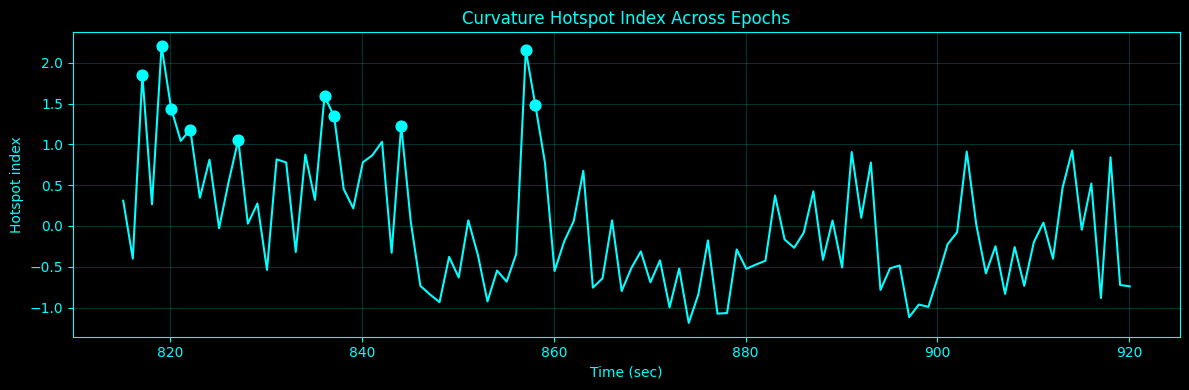

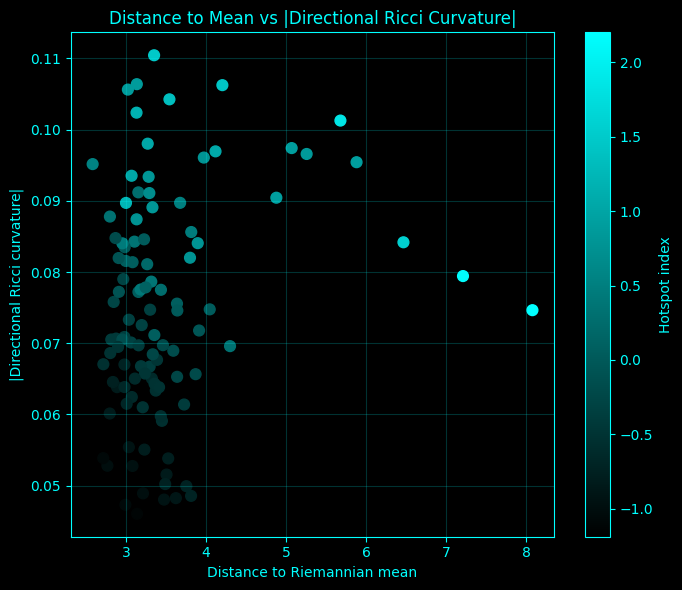

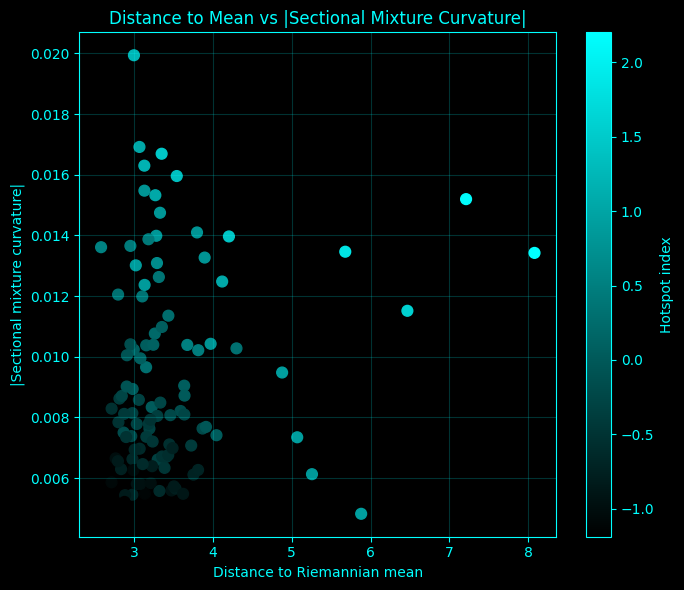

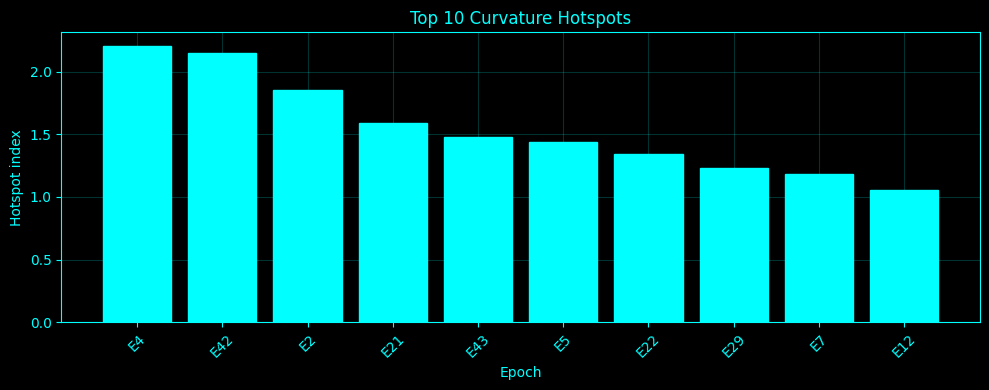

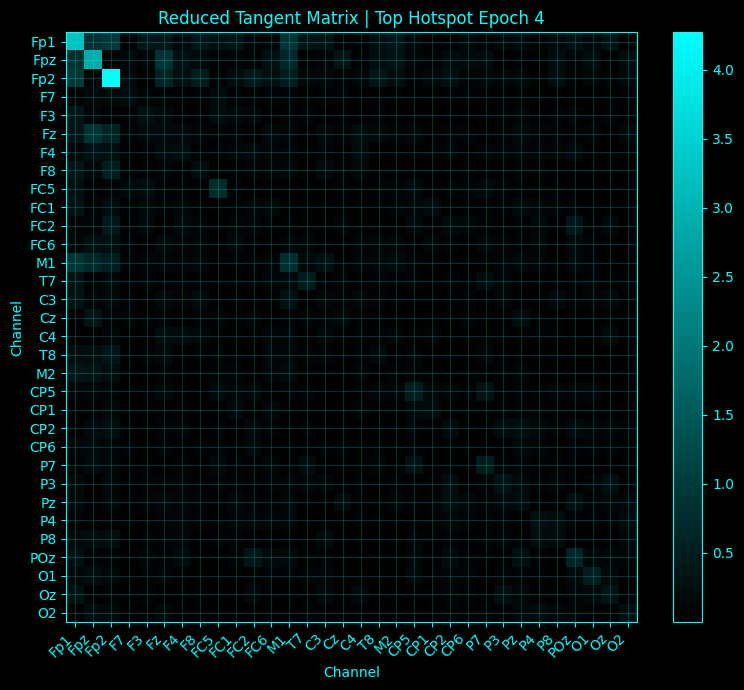


Saved outputs to: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold/curvature_hotspots_results.npz
Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold/curvature_hotspots_summary.csv
Saved hotspots CSV: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold/top_curvature_hotspots.csv
Saved TXT: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold/curvature_hotspots_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/curvature_hotspots_covariance_manifold/plots


In [20]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"

riem_dir = os.path.join(base_dir, "riemannian_covariance_analysis")
riem_npz_path = os.path.join(riem_dir, "riemannian_covariance_results.npz")

curv_dir = os.path.join(base_dir, "riemann_curvature_tensor_analysis")
curv_npz_path = os.path.join(curv_dir, "riemann_curvature_tensor_results.npz")

ricci_dir = os.path.join(base_dir, "ricci_scalar_curvature_analysis")
ricci_npz_path = os.path.join(ricci_dir, "ricci_scalar_curvature_results.npz")

out_dir = os.path.join(base_dir, "curvature_hotspots_covariance_manifold")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

top_n_hotspots = 10
eps = 1e-12

ACCENT = "cyan"
BG = "black"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# SPD HELPERS
# -------------------------------------------------------
def symmetrize(A):
    return 0.5 * (A + A.T)

def eig_clip(vals, eps=1e-12):
    vals = np.asarray(vals, dtype=float)
    vals[vals < eps] = eps
    return vals

def invsqrtm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def logm_spd(A):
    A = symmetrize(A)
    w, V = np.linalg.eigh(A)
    w = eig_clip(w, eps)
    return (V * np.log(w)) @ V.T

def affine_invariant_distance(C, P, P_invsqrt=None):
    C = symmetrize(np.asarray(C, dtype=float))
    P = symmetrize(np.asarray(P, dtype=float))
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    L = logm_spd(inner)
    return float(np.sqrt(np.sum(L * L)))

def tangent_log_at_mean(C, P, P_invsqrt=None):
    if P_invsqrt is None:
        P_invsqrt = invsqrtm_spd(P)
    inner = P_invsqrt @ C @ P_invsqrt
    return symmetrize(logm_spd(inner))

# -------------------------------------------------------
# SYMMETRIC VECTORIZATION
# -------------------------------------------------------
def symmat_to_vec(S):
    S = symmetrize(np.asarray(S, dtype=float))
    n = S.shape[0]
    vals = []

    for i in range(n):
        vals.append(S[i, i])

    for i in range(n):
        for j in range(i + 1, n):
            vals.append(np.sqrt(2.0) * S[i, j])

    return np.asarray(vals, dtype=float)

def vec_to_symmat(v, n):
    S = np.zeros((n, n), dtype=float)
    idx = 0

    for i in range(n):
        S[i, i] = v[idx]
        idx += 1

    for i in range(n):
        for j in range(i + 1, n):
            val = v[idx] / np.sqrt(2.0)
            S[i, j] = val
            S[j, i] = val
            idx += 1

    return S

def zscore(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + eps)

# -------------------------------------------------------
# LOAD DATA
# -------------------------------------------------------
for path in [riem_npz_path, curv_npz_path, ricci_npz_path]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing required file: {path}")

riem = np.load(riem_npz_path, allow_pickle=True)
curv = np.load(curv_npz_path, allow_pickle=True)
ricci = np.load(ricci_npz_path, allow_pickle=True)

cov_matrices = np.asarray(riem["cov_matrices"], dtype=float)
riemannian_mean = np.asarray(riem["riemannian_mean"], dtype=float)

basis_vectors = np.asarray(curv["basis_vectors"], dtype=float)              # (k_eff, full_dim)
basis_matrices = np.asarray(curv["basis_matrices"], dtype=float)            # (k_eff, n_channels, n_channels)
sectional_curvature = np.asarray(curv["sectional_curvature"], dtype=float)  # (k_eff, k_eff)

ricci_tensor = np.asarray(ricci["ricci_tensor"], dtype=float)               # (k_eff, k_eff)

start_time = float(riem["start_time"])
end_time = float(riem["end_time"])
window_size_sec = float(riem["window_size_sec"])

n_epochs, n_channels, _ = cov_matrices.shape
k_eff = basis_vectors.shape[0]

epoch_index = np.arange(n_epochs)
epoch_start_time = start_time + epoch_index * window_size_sec
epoch_center_time = epoch_start_time + 0.5 * window_size_sec

print(f"Loaded covariance matrices: {cov_matrices.shape}")
print(f"Loaded reduced basis size: {k_eff}")
print(f"Loaded Ricci tensor shape: {ricci_tensor.shape}")

# -------------------------------------------------------
# PROJECT EACH EPOCH INTO REDUCED CURVATURE BASIS
# -------------------------------------------------------
P_invsqrt = invsqrtm_spd(riemannian_mean)

tangent_vecs_full = []
reduced_coords = []
distance_to_mean = []

for i in range(n_epochs):
    Xi = tangent_log_at_mean(cov_matrices[i], riemannian_mean, P_invsqrt=P_invsqrt)
    xi = symmat_to_vec(Xi)
    ai = basis_vectors @ xi   # coordinates in reduced basis because basis_vectors are orthonormal rows

    tangent_vecs_full.append(xi)
    reduced_coords.append(ai)
    distance_to_mean.append(np.sqrt(np.sum(xi * xi)))

tangent_vecs_full = np.stack(tangent_vecs_full, axis=0)
reduced_coords = np.stack(reduced_coords, axis=0)
distance_to_mean = np.asarray(distance_to_mean, dtype=float)

# -------------------------------------------------------
# CURVATURE SCORES PER EPOCH
# -------------------------------------------------------
reduced_norm = np.sqrt(np.sum(reduced_coords ** 2, axis=1))

ricci_directional = np.zeros(n_epochs, dtype=float)
ricci_directional_abs = np.zeros(n_epochs, dtype=float)

sectional_mixture = np.zeros(n_epochs, dtype=float)
sectional_mixture_abs = np.zeros(n_epochs, dtype=float)

for i in range(n_epochs):
    a = reduced_coords[i]
    denom = float(np.dot(a, a)) + eps

    # directional Ricci curvature: a^T Ric a / ||a||^2
    r = float(a @ ricci_tensor @ a / denom)
    ricci_directional[i] = r
    ricci_directional_abs[i] = abs(r)

    # sectional mixture curvature using coordinate-pair energy weights
    num = 0.0
    den = 0.0
    for p in range(k_eff):
        for q in range(p + 1, k_eff):
            w = (a[p] ** 2) * (a[q] ** 2)
            num += w * sectional_curvature[p, q]
            den += w

    s = num / (den + eps)
    sectional_mixture[i] = s
    sectional_mixture_abs[i] = abs(s)

# how well the reduced basis captures each epoch tangent vector
reduced_capture_fraction = (reduced_norm ** 2) / (distance_to_mean ** 2 + eps)

# exploratory hotspot index
hotspot_index = (
    zscore(distance_to_mean) +
    zscore(ricci_directional_abs) +
    zscore(sectional_mixture_abs)
) / 3.0

# -------------------------------------------------------
# RECONSTRUCT REDUCED HOTSPOT DIRECTION MATRICES
# -------------------------------------------------------
reduced_recon_vecs = reduced_coords @ basis_vectors
reduced_recon_mats = np.stack(
    [vec_to_symmat(reduced_recon_vecs[i], n_channels) for i in range(n_epochs)],
    axis=0
)

# -------------------------------------------------------
# SUMMARY TABLE
# -------------------------------------------------------
summary_df = pd.DataFrame({
    "epoch_index": epoch_index,
    "epoch_start_time_sec": epoch_start_time,
    "epoch_center_time_sec": epoch_center_time,
    "distance_to_mean": distance_to_mean,
    "reduced_norm": reduced_norm,
    "reduced_capture_fraction": reduced_capture_fraction,
    "ricci_directional_curvature": ricci_directional,
    "ricci_directional_abs": ricci_directional_abs,
    "sectional_mixture_curvature": sectional_mixture,
    "sectional_mixture_abs": sectional_mixture_abs,
    "hotspot_index": hotspot_index,
})

summary_df["hotspot_rank"] = summary_df["hotspot_index"].rank(ascending=False, method="dense").astype(int)
hotspots_df = summary_df.sort_values("hotspot_index", ascending=False).head(top_n_hotspots).copy()

global_summary = {
    "n_epochs": int(n_epochs),
    "n_channels": int(n_channels),
    "k_eff": int(k_eff),
    "mean_distance_to_mean": float(np.mean(distance_to_mean)),
    "mean_reduced_capture_fraction": float(np.mean(reduced_capture_fraction)),
    "mean_abs_ricci_directional": float(np.mean(ricci_directional_abs)),
    "mean_abs_sectional_mixture": float(np.mean(sectional_mixture_abs)),
    "max_hotspot_index": float(np.max(hotspot_index)),
    "min_hotspot_index": float(np.min(hotspot_index)),
    "top_hotspot_epoch": int(hotspots_df.iloc[0]["epoch_index"]),
    "top_hotspot_time_sec": float(hotspots_df.iloc[0]["epoch_center_time_sec"]),
}

print("\nCurvature hotspot summary:")
print(hotspots_df[[
    "epoch_index",
    "epoch_center_time_sec",
    "distance_to_mean",
    "ricci_directional_curvature",
    "sectional_mixture_curvature",
    "hotspot_index"
]].head(top_n_hotspots))

print("\nGlobal summary:")
for k, v in global_summary.items():
    print(f"{k}: {v}")

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
npz_path = os.path.join(out_dir, "curvature_hotspots_results.npz")
np.savez(
    npz_path,
    reduced_coords=reduced_coords,
    distance_to_mean=distance_to_mean,
    reduced_norm=reduced_norm,
    reduced_capture_fraction=reduced_capture_fraction,
    ricci_directional=ricci_directional,
    ricci_directional_abs=ricci_directional_abs,
    sectional_mixture=sectional_mixture,
    sectional_mixture_abs=sectional_mixture_abs,
    hotspot_index=hotspot_index,
    reduced_recon_mats=reduced_recon_mats,
    epoch_start_time=epoch_start_time,
    epoch_center_time=epoch_center_time,
)

summary_csv = os.path.join(out_dir, "curvature_hotspots_summary.csv")
summary_df.to_csv(summary_csv, index=False)

hotspots_csv = os.path.join(out_dir, "top_curvature_hotspots.csv")
hotspots_df.to_csv(hotspots_csv, index=False)

summary_txt = os.path.join(out_dir, "curvature_hotspots_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Curvature Hotspots on the Covariance Manifold\n")
    f.write("============================================\n\n")
    f.write(f"Source covariance NPZ: {riem_npz_path}\n")
    f.write(f"Source curvature NPZ: {curv_npz_path}\n")
    f.write(f"Source Ricci NPZ: {ricci_npz_path}\n\n")
    for k, v in global_summary.items():
        f.write(f"{k}: {v}\n")

# -------------------------------------------------------
# COLORMAP
# -------------------------------------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "black_cyan",
    [(0.0, 0.0, 0.0), (0.0, 1.0, 1.0)]
)

# -------------------------------------------------------
# PLOT 1: HOTSPOT INDEX OVER TIME
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 4), facecolor=BG)
style_ax(ax)

ax.plot(epoch_center_time, hotspot_index, color=ACCENT, linewidth=1.5)
ax.scatter(
    hotspots_df["epoch_center_time_sec"].values,
    hotspots_df["hotspot_index"].values,
    color=ACCENT,
    s=60
)
ax.set_title("Curvature Hotspot Index Across Epochs")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Hotspot index")

plot1_path = os.path.join(plots_dir, "hotspot_index_over_time.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: DISTANCE VS ABS RICCI CURVATURE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    distance_to_mean,
    ricci_directional_abs,
    c=hotspot_index,
    cmap=custom_cmap,
    s=60
)
ax.set_title("Distance to Mean vs |Directional Ricci Curvature|")
ax.set_xlabel("Distance to Riemannian mean")
ax.set_ylabel("|Directional Ricci curvature|")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Hotspot index", color=ACCENT)

plot2_path = os.path.join(plots_dir, "distance_vs_abs_ricci.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: DISTANCE VS ABS SECTIONAL MIXTURE
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    distance_to_mean,
    sectional_mixture_abs,
    c=hotspot_index,
    cmap=custom_cmap,
    s=60
)
ax.set_title("Distance to Mean vs |Sectional Mixture Curvature|")
ax.set_xlabel("Distance to Riemannian mean")
ax.set_ylabel("|Sectional mixture curvature|")

cbar = plt.colorbar(sc, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)
cbar.set_label("Hotspot index", color=ACCENT)

plot3_path = os.path.join(plots_dir, "distance_vs_abs_sectional.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: TOP HOTSPOT BARPLOT
# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4), facecolor=BG)
style_ax(ax)

labels = [f"E{int(e)}" for e in hotspots_df["epoch_index"].values]
ax.bar(labels, hotspots_df["hotspot_index"].values, color=ACCENT, edgecolor=ACCENT)
ax.set_title(f"Top {top_n_hotspots} Curvature Hotspots")
ax.set_xlabel("Epoch")
ax.set_ylabel("Hotspot index")
ax.tick_params(axis="x", rotation=45)

plot4_path = os.path.join(plots_dir, "top_hotspots_barplot.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: HEATMAP OF TOP HOTSPOT REDUCED TANGENT MATRIX
# -------------------------------------------------------
top_epoch = int(hotspots_df.iloc[0]["epoch_index"])
top_mat = reduced_recon_mats[top_epoch]

fig, ax = plt.subplots(figsize=(8, 7), facecolor=BG)
style_ax(ax)

im = ax.imshow(np.abs(top_mat), cmap=custom_cmap, aspect="auto")
ax.set_title(f"Reduced Tangent Matrix | Top Hotspot Epoch {top_epoch}")
ax.set_xlabel("Channel")
ax.set_ylabel("Channel")

if n_channels == 32:
    eeg_channel_names = [
        'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
        'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
        'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
    ]
    ax.set_xticks(np.arange(n_channels))
    ax.set_yticks(np.arange(n_channels))
    ax.set_xticklabels(eeg_channel_names, rotation=45, ha="right", color=ACCENT)
    ax.set_yticklabels(eeg_channel_names, color=ACCENT)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "top_hotspot_reduced_tangent_matrix.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved outputs to: {out_dir}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary CSV: {summary_csv}")
print(f"Saved hotspots CSV: {hotspots_csv}")
print(f"Saved TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves calculating the Kaplan-Yorke dimension using pre-calculated Lyapunov exponents to determine the stability and structural properties of EEG signals from different channels. We detail the reasoning, methods, and formulas used in this process, including the application of the Soul Theorem to support our calculations.</p>
        <h2>Kaplan-Yorke Dimension Calculation</h2>
        <p>The Kaplan-Yorke dimension (also known as the Lyapunov dimension) provides a measure of the chaotic behavior of a dynamical system based on its Lyapunov exponents.</p>
        <p><strong>Formula:</strong></p>
        \[
        D_{KY} = j + \frac{\sum_{i=1}^j \lambda_i}{|\lambda_{j+1}|}
        \]
        where \(\lambda_i\) are the sorted Lyapunov exponents in descending order, and \(j\) is the largest integer such that the sum of the first \(j\) exponents is non-negative:
        \[
        \sum_{i=1}^j \lambda_i \geq 0 \quad \text{and} \quad \sum_{i=1}^{j+1} \lambda_i < 0
        \]
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Stability Analysis</h2>
        <p>Stability is determined by the sign of the largest Lyapunov exponent. A positive value indicates chaotic behavior, while all negative values suggest stability, and mixed signs indicate quasi-periodicity.</p>
        <p><strong>Criteria:</strong></p>
        <ul>
            <li><strong>Chaotic:</strong> Largest Lyapunov exponent \(> 0\)</li>
            <li><strong>Stable:</strong> All Lyapunov exponents \(< 0\)</li>
            <li><strong>Quasi-periodic:</strong> Mixed signs among Lyapunov exponents</li>
        </ul>
        <h2>Soul Theorem Application</h2>
        <p>The Soul Theorem is used to support our identification of stable regions within the phase space of the EEG signals. This theorem states that a dynamical system with a compact, convex phase space and continuous flow will contain a non-empty invariant set where stability can be evaluated.</p>
        <p>This is particularly useful in validating the fixed points and stable regions identified in our analysis, ensuring that the system's behavior is accurately represented.</p>
        <h2>Implementation and Results</h2>
        <p>We calculate the Kaplan-Yorke dimension and determine the stability for each EEG channel using pre-calculated Lyapunov exponents.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Sort the Lyapunov exponents in descending order.</li>
            <li>Calculate the Kaplan-Yorke dimension for each channel.</li>
            <li>Determine the stability based on the largest Lyapunov exponent.</li>
            <li>Apply the Soul Theorem to validate the stability regions.</li>
        </ul>
        <h2>Visualization</h2>
        <p>The Kaplan-Yorke dimension for each EEG channel is visualized using a bar plot, providing a clear comparison across channels.</p>
        <h2>Conclusion</h2>
        <p>This methodology provides a comprehensive analysis of EEG data by calculating the Kaplan-Yorke dimension and determining the stability of each channel, with the assurance of the Soul Theorem, offering insights into the dynamic behavior of the signals.</p>
    </div>
</div>


Using Lyapunov CSV:
/home/a/projects/Complete-Neural-Signal-Analysis/results/lyapunov_custom/lyap_spectrum_20260313_135116.csv

Detected exponent columns:
['Exp1', 'Exp2', 'Exp3', 'Exp4', 'Exp5', 'Exp6', 'Exp7', 'Exp8', 'Exp9', 'Exp10']

Kaplan-Yorke by embedding dimension:
   embedding_dimension  n_records   mean_ky    std_ky  mean_lmax  mean_sum_exp
0                    1        NaN       NaN       NaN        NaN           NaN
1                    2       32.0  2.000000  0.000000   1.991253      3.076867
2                    3       32.0  3.000000  0.000000   1.003579      1.124020
3                    4       32.0  3.702512  0.370441   0.618515     -0.132008
4                    5       32.0  4.014650  0.632227   0.438366     -1.033692
5                    6       32.0  4.169430  0.808321   0.330326     -1.832249
6                    7       32.0  4.406787  0.909280   0.281647     -2.475251
7                    8       32.0  4.650076  0.970486   0.247903     -3.043944
8             

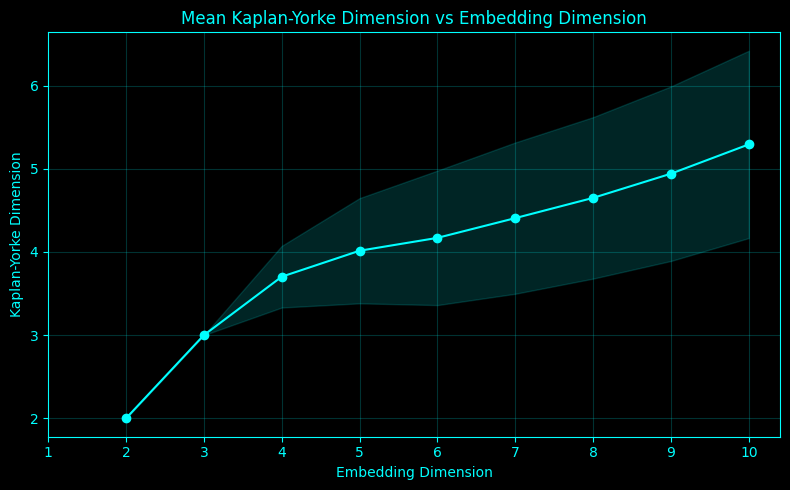

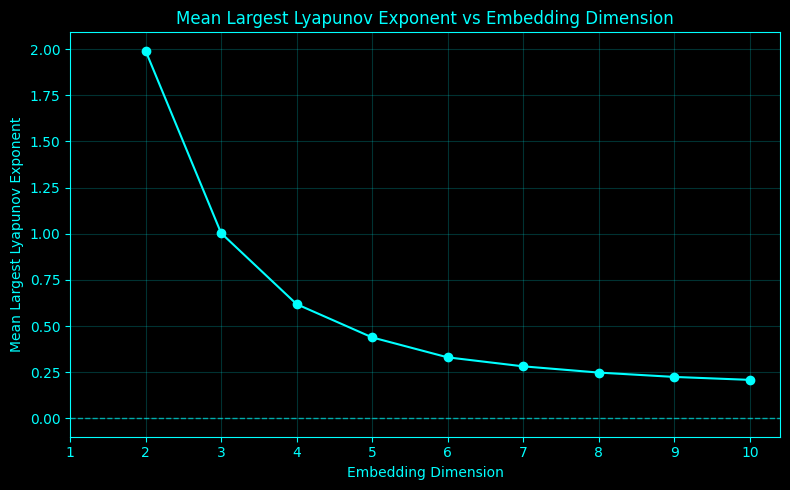

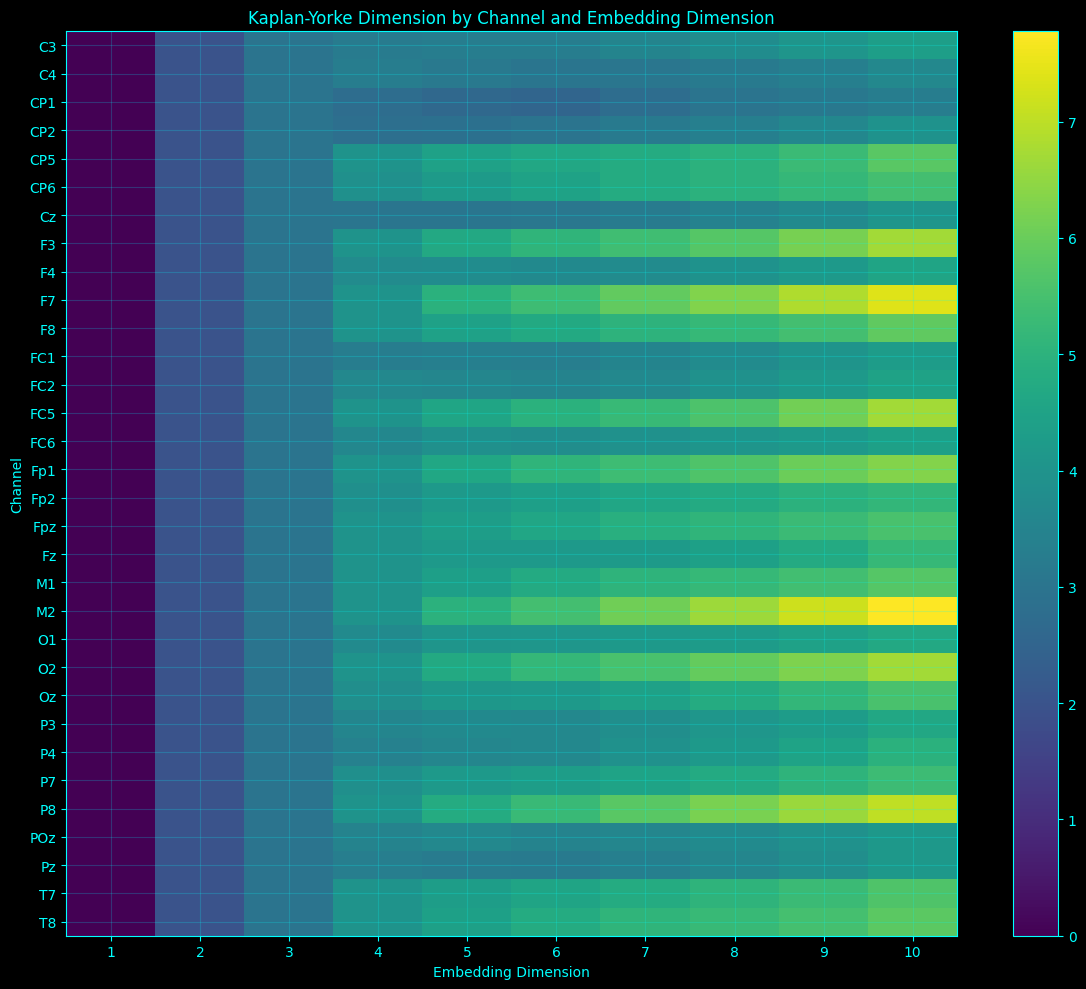

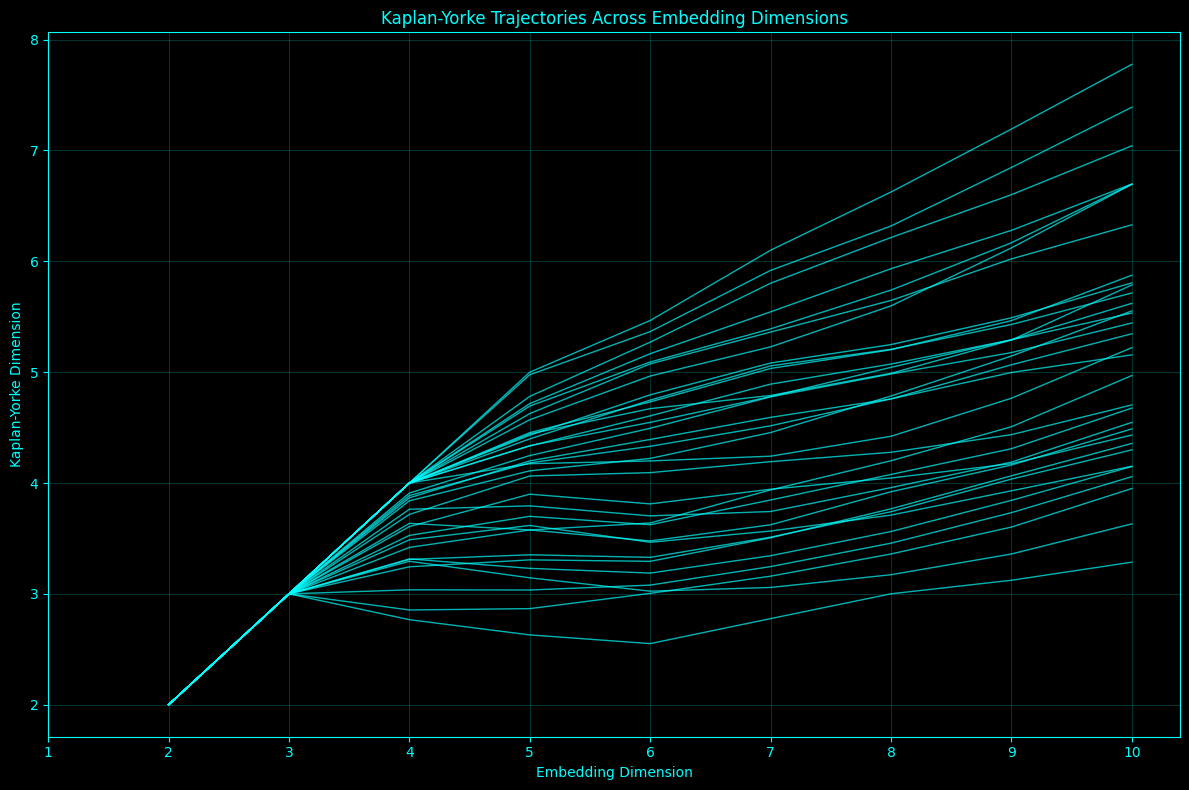


Saved per-file KY CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/kaplan_yorke_per_file.csv
Saved dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/kaplan_yorke_by_dimension.csv
Saved channel-dimension matrix CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/kaplan_yorke_channel_dimension_matrix.csv
Saved highest-dimension summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/kaplan_yorke_highest_available_dimension_per_channel.csv
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/kaplan_yorke_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/kaplan_yorke_from_lyapunov/plots


In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
lyap_dir = os.path.join(base_dir, "results", "lyapunov_custom")
out_dir = os.path.join(base_dir, "results", "kaplan_yorke_from_lyapunov")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def find_latest_lyapunov_csv(results_dir):
    csvs = sorted(glob.glob(os.path.join(results_dir, "lyap_spectrum_*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No lyap_spectrum_*.csv files found in: {results_dir}")
    return max(csvs, key=os.path.getmtime)

def infer_channel_from_stem(stem):
    stem = str(stem)
    if "dembedded_" in stem:
        return stem.split("dembedded_", 1)[1]
    return stem

def infer_embedding_dimension(row):
    # Prefer existing column if present
    if "embedding_dimension" in row.index and pd.notna(row["embedding_dimension"]):
        try:
            return int(row["embedding_dimension"])
        except Exception:
            pass

    stem = str(row["stem"])
    if "dembedded_" in stem:
        left = stem.split("dembedded_", 1)[0]
        try:
            return int(left)
        except Exception:
            pass

    if "state_dim" in row.index and pd.notna(row["state_dim"]):
        try:
            return int(row["state_dim"])
        except Exception:
            pass

    return np.nan

def get_exp_cols(df):
    exp_cols = [c for c in df.columns if str(c).startswith("Exp")]
    def exp_num(c):
        try:
            return int(str(c).replace("Exp", ""))
        except Exception:
            return 10**9
    return sorted(exp_cols, key=exp_num)

def row_exponents(row, exp_cols):
    vals = []
    for c in exp_cols:
        if c in row.index and pd.notna(row[c]):
            vals.append(float(row[c]))
    return np.asarray(vals, dtype=float)

def kaplan_yorke_dimension(lyapunov_exponents):
    """
    D_KY = j + (sum_{i=1}^j lambda_i)/|lambda_{j+1}|
    where j is the largest index such that cumulative sum >= 0.
    """
    exps = np.asarray(lyapunov_exponents, dtype=float)
    exps = exps[np.isfinite(exps)]

    if exps.size == 0:
        return np.nan

    exps = np.sort(exps)[::-1]
    csum = np.cumsum(exps)

    nonneg_idx = np.where(csum >= 0)[0]
    if nonneg_idx.size == 0:
        return 0.0

    j = int(nonneg_idx[-1])

    if j == len(exps) - 1:
        return float(len(exps))

    lam_next = exps[j + 1]
    if np.isclose(lam_next, 0.0):
        return float(j + 1)

    return float((j + 1) + csum[j] / (abs(lam_next) + eps))

def classify_stability(exps):
    exps = np.asarray(exps, dtype=float)
    exps = exps[np.isfinite(exps)]

    if exps.size == 0:
        return "Unknown"

    lmax = np.max(exps)
    if lmax > 0:
        return "Chaotic"
    if np.all(exps < 0):
        return "Stable"
    return "Quasi-periodic / Marginal"

# -------------------------------------------------------
# LOAD LATEST LYAPUNOV CSV
# -------------------------------------------------------
lyap_csv = find_latest_lyapunov_csv(lyap_dir)
df = pd.read_csv(lyap_csv)

print("Using Lyapunov CSV:")
print(lyap_csv)

if "status" in df.columns:
    df = df[df["status"] == "ok"].copy()

if df.empty:
    raise ValueError("No successful rows found in the Lyapunov CSV.")

exp_cols = get_exp_cols(df)
if not exp_cols:
    raise ValueError("No Exp columns found in the Lyapunov CSV.")

print("\nDetected exponent columns:")
print(exp_cols)

# -------------------------------------------------------
# BUILD KAPLAN-YORKE TABLE
# -------------------------------------------------------
records = []

for _, row in df.iterrows():
    stem = row["stem"] if "stem" in row.index else ""
    channel = infer_channel_from_stem(stem)
    emb_dim = infer_embedding_dimension(row)
    exps = row_exponents(row, exp_cols)

    if exps.size == 0:
        continue

    exps_sorted = np.sort(exps)[::-1]
    ky_dim = kaplan_yorke_dimension(exps_sorted)
    stability = classify_stability(exps_sorted)

    rec = {
        "file": row["file"] if "file" in row.index else "",
        "stem": stem,
        "channel": channel,
        "embedding_dimension": emb_dim,
        "state_dim": int(row["state_dim"]) if "state_dim" in row.index and pd.notna(row["state_dim"]) else np.nan,
        "n_samples": int(row["n_samples"]) if "n_samples" in row.index and pd.notna(row["n_samples"]) else np.nan,
        "steps_used": int(row["steps_used"]) if "steps_used" in row.index and pd.notna(row["steps_used"]) else np.nan,
        "n_exponents_used": int(exps_sorted.size),
        "largest_lyapunov_exponent": float(np.max(exps_sorted)),
        "smallest_lyapunov_exponent": float(np.min(exps_sorted)),
        "sum_lyapunov_exponents": float(np.sum(exps_sorted)),
        "kaplan_yorke_dimension": float(ky_dim),
        "stability": stability,
    }

    for i, val in enumerate(exps_sorted, start=1):
        rec[f"sorted_Exp{i}"] = float(val)

    records.append(rec)

ky_df = pd.DataFrame(records)

if ky_df.empty:
    raise ValueError("No Kaplan-Yorke records were produced.")

ky_df = ky_df.sort_values(["channel", "embedding_dimension"]).reset_index(drop=True)

# -------------------------------------------------------
# 1D..10D GRID
# -------------------------------------------------------
all_dims = list(range(1, 11))

# Mean KY per dimension
dim_summary_df = (
    ky_df.groupby("embedding_dimension", dropna=True)
    .agg(
        n_records=("kaplan_yorke_dimension", "count"),
        mean_ky=("kaplan_yorke_dimension", "mean"),
        std_ky=("kaplan_yorke_dimension", "std"),
        mean_lmax=("largest_lyapunov_exponent", "mean"),
        mean_sum_exp=("sum_lyapunov_exponents", "mean"),
    )
    .reset_index()
)

dim_summary_full = pd.DataFrame({"embedding_dimension": all_dims}).merge(
    dim_summary_df,
    on="embedding_dimension",
    how="left"
)

# Channel x embedding dimension matrix
ky_matrix = ky_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="kaplan_yorke_dimension",
    aggfunc="mean"
)

ky_matrix = ky_matrix.reindex(columns=all_dims)

# Largest exponent matrix too
lmax_matrix = ky_df.pivot_table(
    index="channel",
    columns="embedding_dimension",
    values="largest_lyapunov_exponent",
    aggfunc="mean"
).reindex(columns=all_dims)

# Longest available per channel
best_dim_df = ky_df.sort_values(
    ["channel", "embedding_dimension"]
).groupby("channel", as_index=False).tail(1)

# -------------------------------------------------------
# SAVE TABLES
# -------------------------------------------------------
ky_csv = os.path.join(out_dir, "kaplan_yorke_per_file.csv")
dim_csv = os.path.join(out_dir, "kaplan_yorke_by_dimension.csv")
matrix_csv = os.path.join(out_dir, "kaplan_yorke_channel_dimension_matrix.csv")
best_dim_csv = os.path.join(out_dir, "kaplan_yorke_highest_available_dimension_per_channel.csv")

ky_df.to_csv(ky_csv, index=False)
dim_summary_full.to_csv(dim_csv, index=False)
ky_matrix.to_csv(matrix_csv)
best_dim_df.to_csv(best_dim_csv, index=False)

summary_txt = os.path.join(out_dir, "kaplan_yorke_summary.txt")
with open(summary_txt, "w") as f:
    f.write("Kaplan-Yorke Dimension from Saved Lyapunov Spectra\n")
    f.write("=================================================\n\n")
    f.write(f"Source CSV: {lyap_csv}\n")
    f.write(f"Rows analyzed: {len(ky_df)}\n")
    f.write(f"Exponent columns used: {', '.join(exp_cols)}\n\n")

    f.write("Mean Kaplan-Yorke dimension by embedding dimension:\n")
    for _, row in dim_summary_full.iterrows():
        d = int(row["embedding_dimension"])
        nrec = row["n_records"]
        if pd.isna(nrec):
            f.write(f"  {d}D: no data\n")
        else:
            f.write(
                f"  {d}D: n={int(nrec)}, "
                f"mean_KY={row['mean_ky']:.6f}, "
                f"std_KY={0.0 if pd.isna(row['std_ky']) else row['std_ky']:.6f}, "
                f"mean_Lmax={row['mean_lmax']:.6f}, "
                f"mean_sum_exp={row['mean_sum_exp']:.6f}\n"
            )

# -------------------------------------------------------
# PRINT
# -------------------------------------------------------
print("\nKaplan-Yorke by embedding dimension:")
print(dim_summary_full)

print("\nSample of per-file/channel results:")
print(ky_df.head())

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# Plot 1: mean KY vs embedding dimension
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

mask = dim_summary_full["mean_ky"].notna().values
ax.plot(
    dim_summary_full.loc[mask, "embedding_dimension"].values,
    dim_summary_full.loc[mask, "mean_ky"].values,
    marker="o",
    color=ACCENT,
    linewidth=1.5
)

if dim_summary_full["std_ky"].notna().any():
    x = dim_summary_full.loc[mask, "embedding_dimension"].values
    y = dim_summary_full.loc[mask, "mean_ky"].values
    s = dim_summary_full.loc[mask, "std_ky"].fillna(0.0).values
    ax.fill_between(x, y - s, y + s, color=ACCENT, alpha=0.15)

ax.set_title("Mean Kaplan-Yorke Dimension vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Kaplan-Yorke Dimension")
ax.set_xticks(all_dims)

plot1_path = os.path.join(plots_dir, "mean_ky_vs_embedding_dimension.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 2: mean largest exponent vs embedding dimension
fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
style_ax(ax)

mask = dim_summary_full["mean_lmax"].notna().values
ax.plot(
    dim_summary_full.loc[mask, "embedding_dimension"].values,
    dim_summary_full.loc[mask, "mean_lmax"].values,
    marker="o",
    color=ACCENT,
    linewidth=1.5
)
ax.axhline(0.0, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6)
ax.set_title("Mean Largest Lyapunov Exponent vs Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Mean Largest Lyapunov Exponent")
ax.set_xticks(all_dims)

plot2_path = os.path.join(plots_dir, "mean_lmax_vs_embedding_dimension.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 3: channel x dimension heatmap of KY
fig, ax = plt.subplots(figsize=(12, 10), facecolor=BG)
style_ax(ax)

heat = ky_matrix.copy()
heat_vals = heat.values.astype(float)

# replace NaN only for plotting
plot_vals = np.where(np.isnan(heat_vals), 0.0, heat_vals)

im = ax.imshow(plot_vals, aspect="auto")
ax.set_title("Kaplan-Yorke Dimension by Channel and Embedding Dimension")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Channel")
ax.set_xticks(np.arange(len(all_dims)))
ax.set_xticklabels(all_dims)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)

cbar = plt.colorbar(im, ax=ax)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot3_path = os.path.join(plots_dir, "ky_heatmap_channel_by_dimension.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# Plot 4: one line per channel across dimensions
fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG)
style_ax(ax)

for ch in ky_matrix.index:
    y = ky_matrix.loc[ch].values.astype(float)
    x = np.array(all_dims, dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) >= 2:
        ax.plot(x[mask], y[mask], linewidth=1.0, alpha=0.7, color=ACCENT)

ax.set_title("Kaplan-Yorke Trajectories Across Embedding Dimensions")
ax.set_xlabel("Embedding Dimension")
ax.set_ylabel("Kaplan-Yorke Dimension")
ax.set_xticks(all_dims)

plot4_path = os.path.join(plots_dir, "ky_trajectories_across_dimensions.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved per-file KY CSV: {ky_csv}")
print(f"Saved dimension summary CSV: {dim_csv}")
print(f"Saved channel-dimension matrix CSV: {matrix_csv}")
print(f"Saved highest-dimension summary CSV: {best_dim_csv}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Minkowski space

### Temporal Signal Curvature Analysis of EEG Channels

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis involves normalizing EEG data and calculating its curvature. Curvature measures the rate of change in the direction of the EEG signal, providing insights into the dynamics and complexity of brain activity.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is first segmented to exclude stimulation periods, ensuring a focus on natural brain activity.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = \left[ \text{start\_index}, \text{end\_index} \right]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).</p>
        <h2>Normalization</h2>
        <p>The EEG data is normalized to have zero mean and unit variance to avoid numerical issues in subsequent calculations.</p>
        <p><strong>Formula:</strong></p>
        \[
        Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}
        \]
        where \(Z_{ij}\) is the normalized value, \(X_{ij}\) is the original EEG value, \(\mu_j\) is the mean, and \(\sigma_j\) is the standard deviation of channel \(j\).</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Curvature Calculation</h2>
        <p>Curvature is computed to quantify the rate of change in the direction of the EEG signal.</p>
        <p><strong>Formula:</strong></p>
        \[
        \kappa(t) = \frac{|\ddot{X}(t)|}{(1 + \dot{X}(t)^2)^{3/2}}
        \]
        where \(\dot{X}(t)\) is the first derivative (gradient) of the EEG signal, and \(\ddot{X}(t)\) is the second derivative.</p>
        <h2>Visualization</h2>
        <p>The results are visualized in a two-panel plot showing the normalized EEG data and the calculated curvature for each channel.</p>
        <p><strong>Steps:</strong></p>
        <ul>
            <li>Normalize the EEG data to zero mean and unit variance.</li>
            <li>Compute the curvature of the EEG data using the gradient and second gradient.</li>
            <li>Visualize the normalized EEG data and curvature in a two-panel plot.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology provides a detailed analysis of EEG data by examining the curvature, which highlights changes in the direction of the signal, offering insights into the complexity and dynamics of brain activity.</p>
    </div>
</div>


Loaded EEG segment: 106944 samples x 32 channels
Segment: [814.571, 921.515] sec


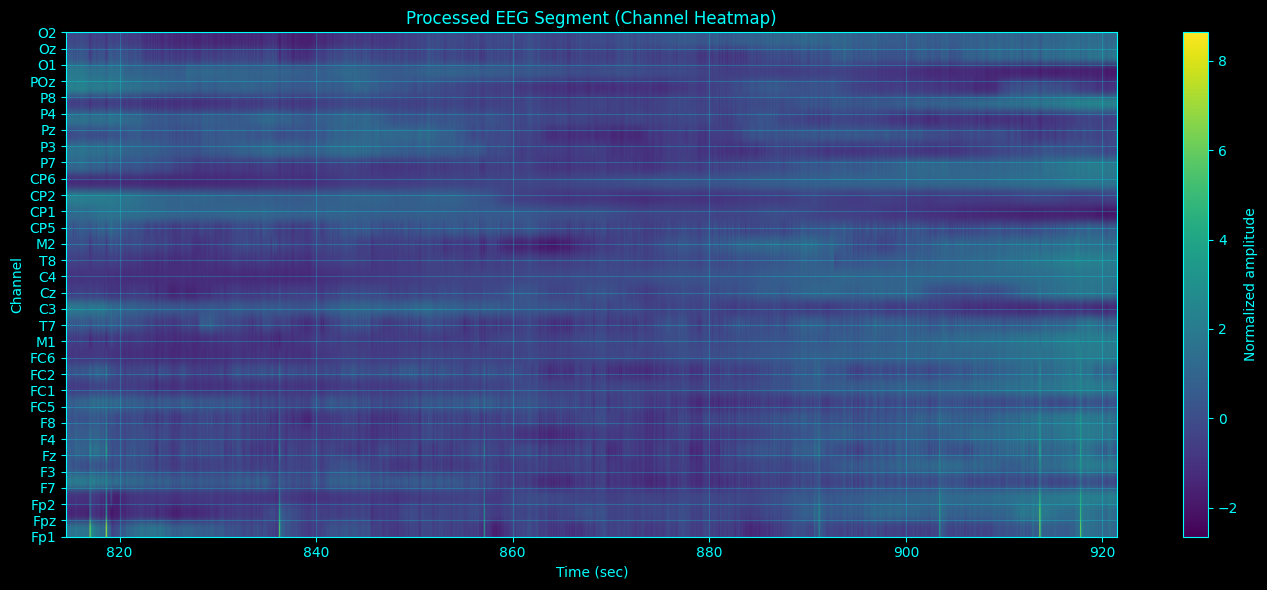

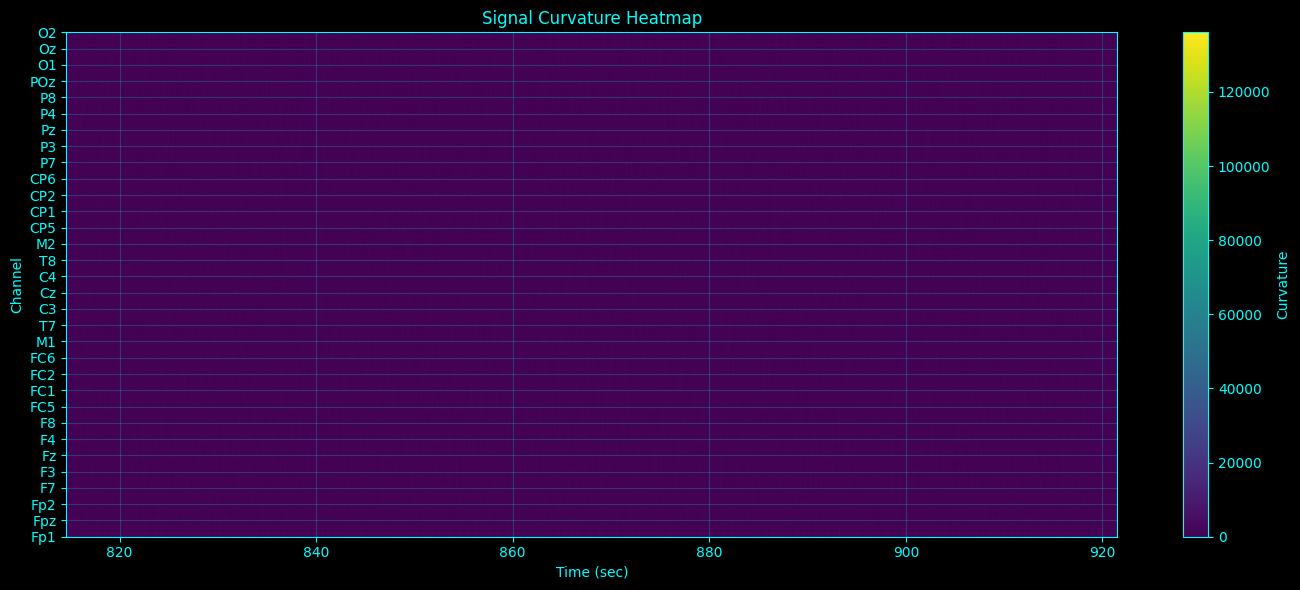

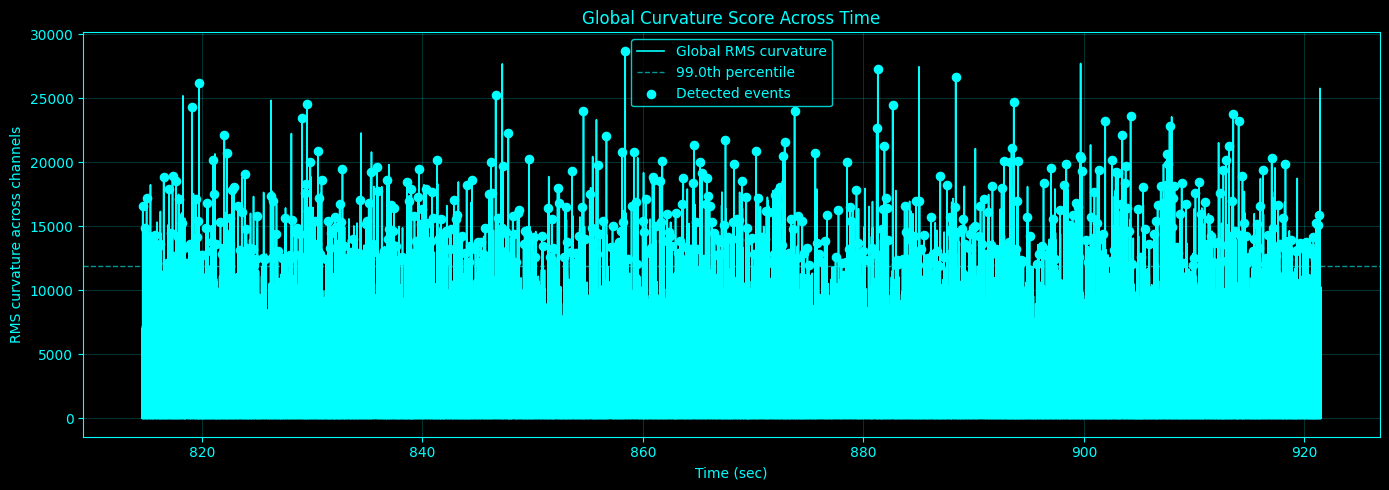

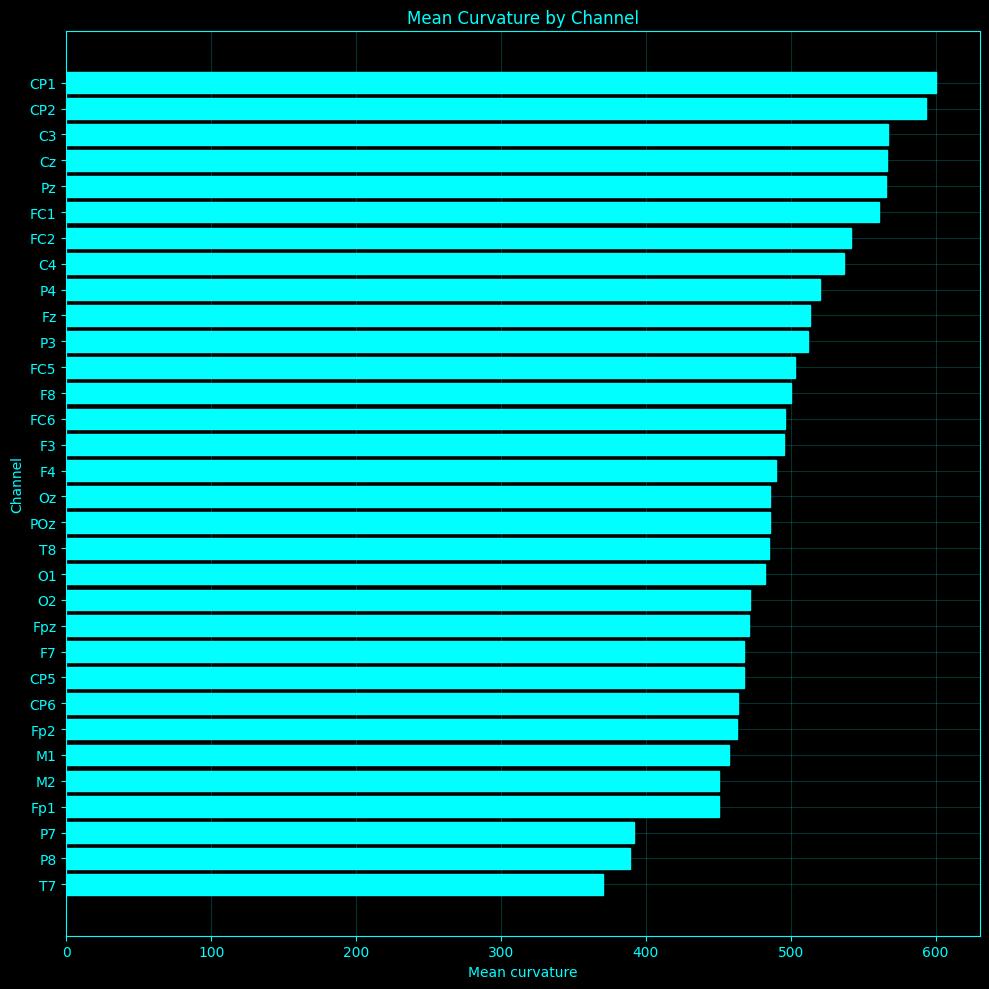

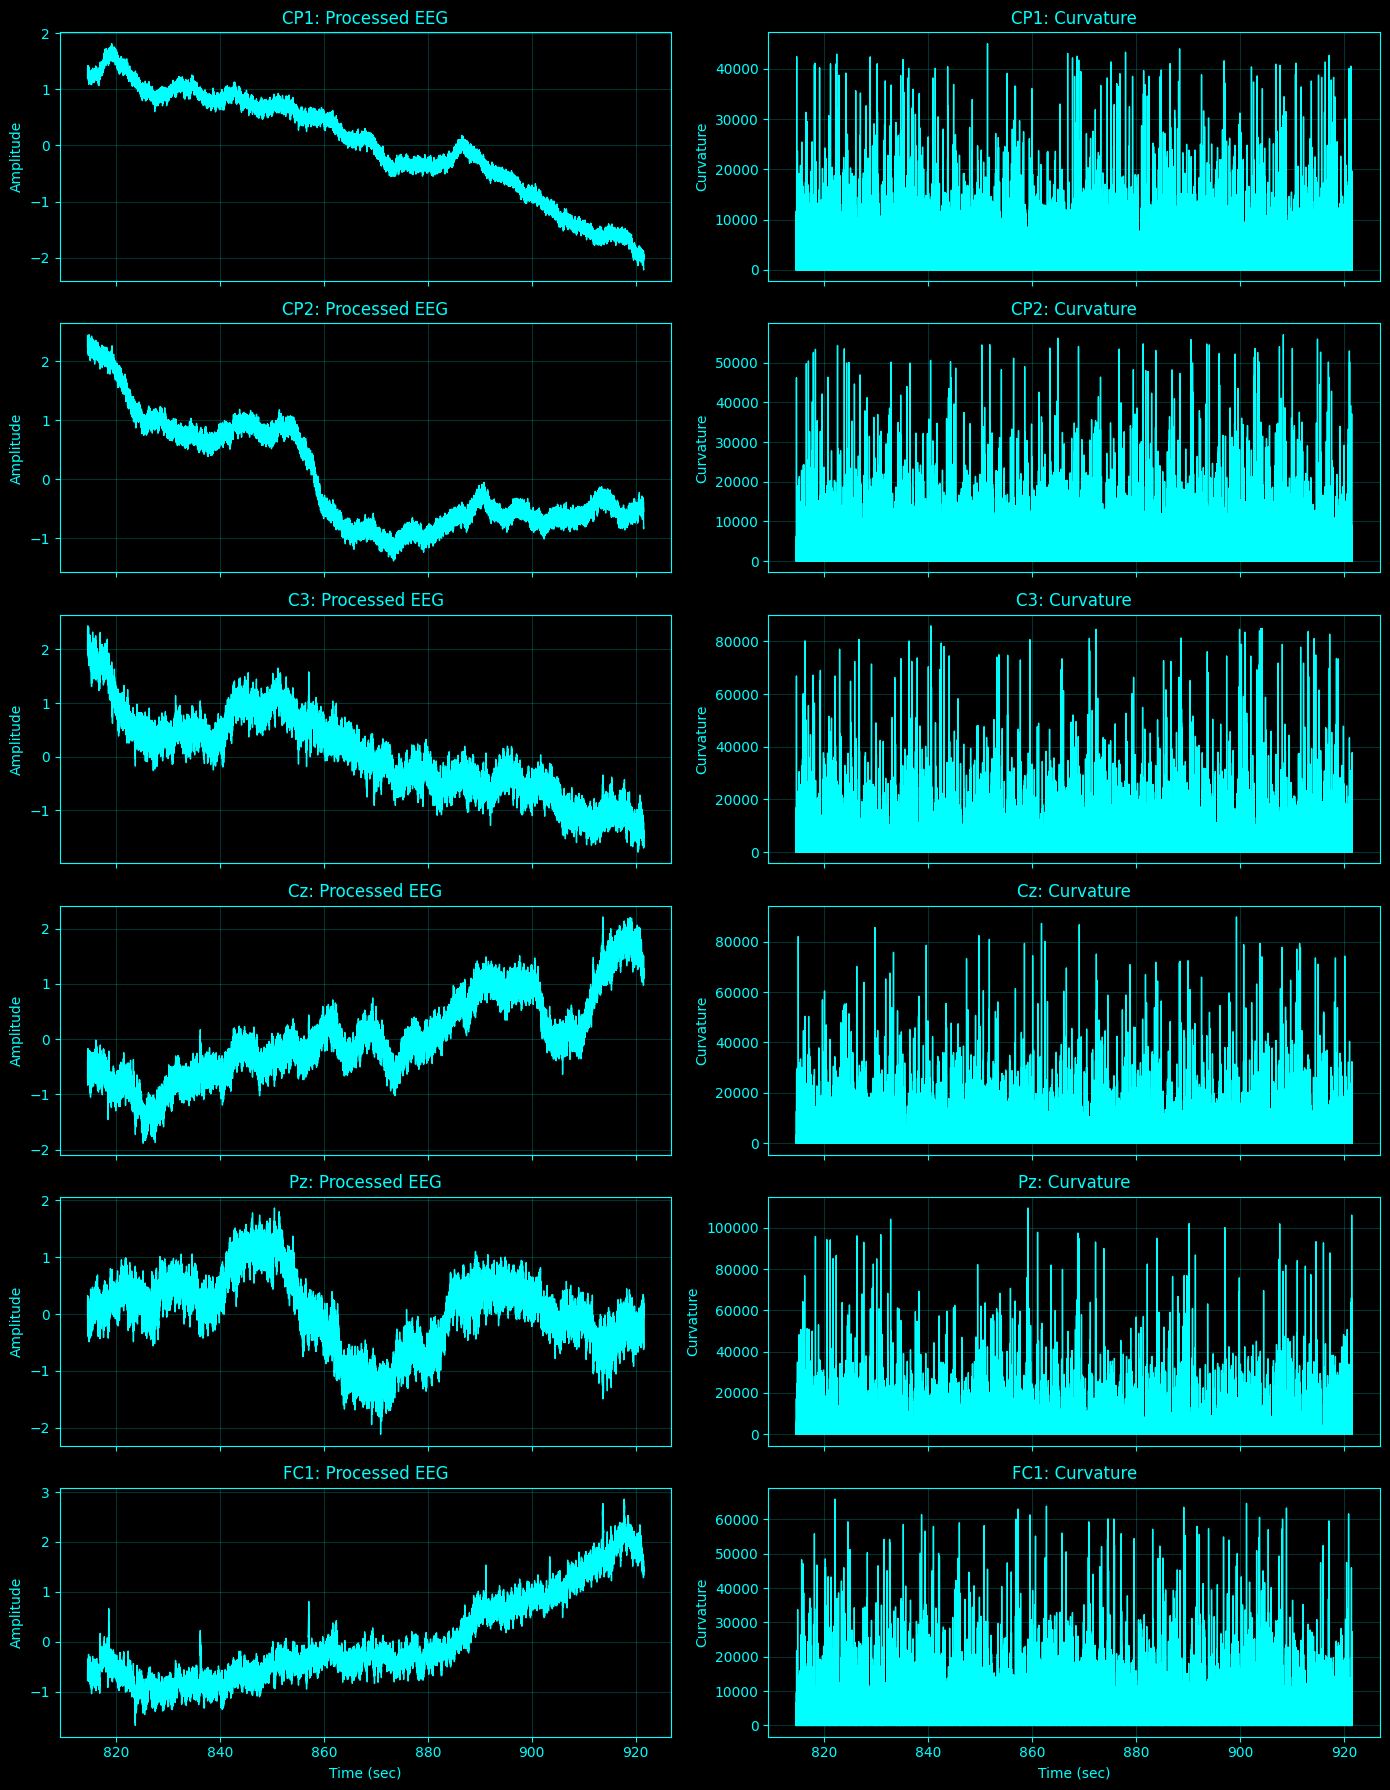


Saved summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/signal_curvature_channel_summary.csv
Saved time-series CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/signal_curvature_time_series.csv
Saved events CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/signal_curvature_global_events.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/signal_curvature_results.npz
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/signal_curvature_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/signal_curvature_analysis/plots


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "signal_curvature_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Smoothing before derivatives
apply_smoothing = True
smoothing_window_ms = 15  # odd window is enforced below

# Event detection
event_percentile = 99.0
min_event_separation_ms = 100

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def zscore_by_channel(x):
    mu = np.mean(x, axis=0, keepdims=True)
    sd = np.std(x, axis=0, keepdims=True)
    return (x - mu) / (sd + eps)

def moving_average_1d_reflect(x, window):
    if window <= 1:
        return x.copy()

    if window % 2 == 0:
        window += 1

    pad = window // 2
    xp = np.pad(x, (pad, pad), mode="reflect")
    kernel = np.ones(window, dtype=float) / window
    return np.convolve(xp, kernel, mode="valid")

def smooth_columns(x, window):
    if window <= 1:
        return x.copy()

    out = np.zeros_like(x, dtype=float)
    for j in range(x.shape[1]):
        out[:, j] = moving_average_1d_reflect(x[:, j], window)
    return out

def calculate_curvature(x, dt):
    """
    Curvature of the plane curve (t, x(t)):
        kappa(t) = |x''(t)| / (1 + x'(t)^2)^(3/2)
    Vectorized across channels.
    """
    dx = np.gradient(x, dt, axis=0)
    ddx = np.gradient(dx, dt, axis=0)

    curvature = np.abs(ddx) / np.power(1.0 + dx**2, 1.5)
    curvature = np.nan_to_num(curvature, nan=0.0, posinf=0.0, neginf=0.0)
    return curvature, dx, ddx

def count_peaks_above_threshold(x, threshold, min_sep_samples=1):
    """
    Count local maxima above threshold in 1D.
    """
    if len(x) < 3:
        return 0

    candidates = np.where(
        (x[1:-1] > x[:-2]) &
        (x[1:-1] >= x[2:]) &
        (x[1:-1] > threshold)
    )[0] + 1

    if len(candidates) == 0:
        return 0

    kept = [candidates[0]]
    for idx in candidates[1:]:
        if idx - kept[-1] >= min_sep_samples:
            kept.append(idx)

    return len(kept)

def detect_global_events(score, threshold, min_sep_samples=1):
    if len(score) < 3:
        return np.array([], dtype=int)

    candidates = np.where(
        (score[1:-1] > score[:-2]) &
        (score[1:-1] >= score[2:]) &
        (score[1:-1] > threshold)
    )[0] + 1

    if len(candidates) == 0:
        return np.array([], dtype=int)

    kept = [candidates[0]]
    for idx in candidates[1:]:
        if idx - kept[-1] >= min_sep_samples:
            kept.append(idx)

    return np.asarray(kept, dtype=int)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Segment: [{start_time}, {end_time}] sec")

# -------------------------------------------------------
# NORMALIZE + OPTIONAL SMOOTHING
# -------------------------------------------------------
normalized_EEG = zscore_by_channel(EEG_segment)

smoothing_window_samples = max(1, int(round(smoothing_window_ms * sampling_rate / 1000.0)))
if smoothing_window_samples % 2 == 0:
    smoothing_window_samples += 1

if apply_smoothing:
    processed_EEG = smooth_columns(normalized_EEG, smoothing_window_samples)
else:
    processed_EEG = normalized_EEG.copy()

# -------------------------------------------------------
# CURVATURE ANALYSIS
# -------------------------------------------------------
curvature, dx, ddx = calculate_curvature(processed_EEG, dt)

# Global curvature score across channels
global_curvature_mean = np.mean(curvature, axis=1)
global_curvature_rms = np.sqrt(np.mean(curvature**2, axis=1))
global_curvature_max = np.max(curvature, axis=1)

# Event detection on RMS global curvature
min_event_separation_samples = max(1, int(round(min_event_separation_ms * sampling_rate / 1000.0)))
global_threshold = np.percentile(global_curvature_rms, event_percentile)
global_event_idx = detect_global_events(
    global_curvature_rms,
    threshold=global_threshold,
    min_sep_samples=min_event_separation_samples
)

global_event_times = time_sec[global_event_idx] if len(global_event_idx) > 0 else np.array([])

# -------------------------------------------------------
# CHANNEL SUMMARIES
# -------------------------------------------------------
summary_rows = []

for ch in range(n_channels):
    channel_name = eeg_channel_names[ch]
    curv = curvature[:, ch]

    p95 = float(np.percentile(curv, 95))
    p99 = float(np.percentile(curv, 99))
    frac_hi95 = float(np.mean(curv > p95))
    frac_hi99 = float(np.mean(curv > p99))

    n_peaks = count_peaks_above_threshold(
        curv,
        threshold=p99,
        min_sep_samples=min_event_separation_samples
    )

    summary_rows.append({
        "channel": channel_name,
        "mean_curvature": float(np.mean(curv)),
        "median_curvature": float(np.median(curv)),
        "std_curvature": float(np.std(curv)),
        "rms_curvature": float(np.sqrt(np.mean(curv**2))),
        "max_curvature": float(np.max(curv)),
        "p95_curvature": p95,
        "p99_curvature": p99,
        "fraction_above_p95": frac_hi95,
        "fraction_above_p99": frac_hi99,
        "curvature_energy_mean": float(np.mean(curv**2)),
        "n_high_curvature_peaks": int(n_peaks),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("mean_curvature", ascending=False).reset_index(drop=True)

# Timewise dataframe
time_df = pd.DataFrame({
    "time_sec": time_sec,
    "global_curvature_mean": global_curvature_mean,
    "global_curvature_rms": global_curvature_rms,
    "global_curvature_max": global_curvature_max,
})

events_df = pd.DataFrame({
    "event_index": np.arange(len(global_event_idx)),
    "sample_index": global_event_idx,
    "time_sec": global_event_times,
    "global_curvature_rms": global_curvature_rms[global_event_idx] if len(global_event_idx) else np.array([]),
})

# -------------------------------------------------------
# SAVE RESULTS
# -------------------------------------------------------
summary_csv = os.path.join(out_dir, "signal_curvature_channel_summary.csv")
time_csv = os.path.join(out_dir, "signal_curvature_time_series.csv")
events_csv = os.path.join(out_dir, "signal_curvature_global_events.csv")
npz_path = os.path.join(out_dir, "signal_curvature_results.npz")
summary_txt = os.path.join(out_dir, "signal_curvature_summary.txt")

summary_df.to_csv(summary_csv, index=False)
time_df.to_csv(time_csv, index=False)
events_df.to_csv(events_csv, index=False)

np.savez_compressed(
    npz_path,
    time_sec=time_sec,
    normalized_EEG=normalized_EEG,
    processed_EEG=processed_EEG,
    dx=dx,
    ddx=ddx,
    curvature=curvature,
    global_curvature_mean=global_curvature_mean,
    global_curvature_rms=global_curvature_rms,
    global_curvature_max=global_curvature_max,
    global_event_idx=global_event_idx,
    global_event_times=global_event_times,
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
    sampling_rate=sampling_rate,
    start_time=start_time,
    end_time=end_time,
    apply_smoothing=apply_smoothing,
    smoothing_window_ms=smoothing_window_ms,
    smoothing_window_samples=smoothing_window_samples,
)

with open(summary_txt, "w") as f:
    f.write("Temporal Signal Curvature Analysis of EEG Channels\n")
    f.write("=================================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channels: {n_channels}\n")
    f.write(f"Apply smoothing: {apply_smoothing}\n")
    f.write(f"Smoothing window (ms): {smoothing_window_ms}\n")
    f.write(f"Smoothing window (samples): {smoothing_window_samples}\n")
    f.write(f"Global event percentile threshold: {event_percentile}\n")
    f.write(f"Detected global events: {len(global_event_idx)}\n\n")
    f.write("Top channels by mean curvature:\n")

    top_n = min(10, len(summary_df))
    for _, row in summary_df.head(top_n).iterrows():
        f.write(
            f"  {row['channel']}: "
            f"mean={row['mean_curvature']:.6f}, "
            f"rms={row['rms_curvature']:.6f}, "
            f"max={row['max_curvature']:.6f}, "
            f"peaks={int(row['n_high_curvature_peaks'])}\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) EEG heatmap
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    processed_EEG.T,
    aspect="auto",
    origin="lower",
    extent=[time_sec[0], time_sec[-1], 0, n_channels - 1]
)
ax.set_title("Processed EEG Segment (Channel Heatmap)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(n_channels))
ax.set_yticklabels(eeg_channel_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Normalized amplitude", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "processed_eeg_heatmap.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) Curvature heatmap
fig, ax = plt.subplots(figsize=(14, 6), facecolor=BG)
style_ax(ax)

im = ax.imshow(
    curvature.T,
    aspect="auto",
    origin="lower",
    extent=[time_sec[0], time_sec[-1], 0, n_channels - 1]
)
ax.set_title("Signal Curvature Heatmap")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Channel")
ax.set_yticks(np.arange(n_channels))
ax.set_yticklabels(eeg_channel_names)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Curvature", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "signal_curvature_heatmap.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Global curvature score with detected events
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
style_ax(ax)

ax.plot(time_sec, global_curvature_rms, color=ACCENT, linewidth=1.2, label="Global RMS curvature")
ax.axhline(global_threshold, color=ACCENT, linestyle="--", linewidth=1.0, alpha=0.6, label=f"{event_percentile}th percentile")

if len(global_event_idx) > 0:
    ax.scatter(
        time_sec[global_event_idx],
        global_curvature_rms[global_event_idx],
        color=ACCENT,
        s=35,
        zorder=5,
        label="Detected events"
    )

ax.set_title("Global Curvature Score Across Time")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("RMS curvature across channels")
ax.legend()

plot3_path = os.path.join(plots_dir, "global_curvature_score.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Mean curvature by channel
plot_df = summary_df.sort_values("mean_curvature", ascending=True)

fig, ax = plt.subplots(figsize=(10, 10), facecolor=BG)
style_ax(ax)

ax.barh(
    plot_df["channel"].values,
    plot_df["mean_curvature"].values,
    color=ACCENT,
    edgecolor=ACCENT
)
ax.set_title("Mean Curvature by Channel")
ax.set_xlabel("Mean curvature")
ax.set_ylabel("Channel")

plot4_path = os.path.join(plots_dir, "mean_curvature_by_channel.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Top 6 most curved channels: signal and curvature
top_channels = summary_df.head(min(6, len(summary_df)))["channel"].tolist()
top_indices = [eeg_channel_names.index(ch) for ch in top_channels]

fig, axes = plt.subplots(len(top_indices), 2, figsize=(14, 3 * len(top_indices)), facecolor=BG, sharex=True)
if len(top_indices) == 1:
    axes = np.array([axes])

for r, ch_idx in enumerate(top_indices):
    ax1, ax2 = axes[r]
    style_ax(ax1)
    style_ax(ax2)

    ch_name = eeg_channel_names[ch_idx]

    ax1.plot(time_sec, processed_EEG[:, ch_idx], color=ACCENT, linewidth=1.0)
    ax1.set_title(f"{ch_name}: Processed EEG")
    ax1.set_ylabel("Amplitude")

    ax2.plot(time_sec, curvature[:, ch_idx], color=ACCENT, linewidth=1.0)
    ax2.set_title(f"{ch_name}: Curvature")
    ax2.set_ylabel("Curvature")

axes[-1, 0].set_xlabel("Time (sec)")
axes[-1, 1].set_xlabel("Time (sec)")

plot5_path = os.path.join(plots_dir, "top_curvature_channels_signal_and_curvature.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved summary CSV: {summary_csv}")
print(f"Saved time-series CSV: {time_csv}")
print(f"Saved events CSV: {events_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### SO(2) Lie-Group Rotation Analysis of EEG Channel Pairs

<div style="font-size: 14px; font-family: 'Times New Roman', Times, serif; background-color: #181818; color: #D0D0D0; padding: 20px; border-radius: 8px; margin: 10px; display: flex; justify-content: space-between;">
    <!-- Column 1 -->
    <div style="width: 50%; margin-right: 20px;">
        <h2>Introduction</h2>
        <p>This analysis applies Lie group transformations to EEG data to explore the effects of such transformations on the signals. Lie groups are continuous groups of transformations that preserve the structure of the data, such as rotations and translations.</p>
        <h2>Data Preparation</h2>
        <p>The EEG data is segmented to exclude periods of stimulation, ensuring the analysis focuses on natural brain activity. The data is then normalized for consistent processing.</p>
        <p><strong>Formula:</strong></p>
        \[
        \text{Segment indices} = [\text{start\_index}, \text{end\_index}]
        \]
        where \(\text{start\_index} = \text{start\_time} \times \text{sampling\_rate}\) and \(\text{end\_index} = \text{end\_time} \times \text{sampling\_rate}\).
        \[
        \text{Normalized EEG Data} = \frac{\text{EEG Data} - \mu}{\sigma}
        \]
        where \(\mu\) is the mean and \(\sigma\) is the standard deviation of the EEG data.</p>
    </div>
    <!-- Column 2 -->
    <div style="width: 50%; margin-left: 20px;">
        <h2>Lie Group Transformations</h2>
        <p>We apply a Lie group transformation, specifically a rotation, to a subset of EEG channels. This transformation helps to explore the invariant properties of the EEG signals under continuous transformations.</p>
        <p><strong>Formula:</strong></p>
        \[
        \mathbf{R}(\theta) = \begin{bmatrix}
        \cos(\theta) & -\sin(\theta) \\
        \sin(\theta) & \cos(\theta)
        \end{bmatrix}
        \]
        where \(\theta\) is the rotation angle.</p>
        <p>The transformed data is then given by:</p>
        \[
        \text{Transformed Data} = \text{Original Data} \cdot \mathbf{R}(\theta)
        \]
        <h2>Visualization</h2>
        <p>The original and transformed EEG data are visualized to compare the effects of the Lie group transformation. We plot both the 2D and 3D representations of the data.</p>
        <h2>Steps:</h2>
        <ul>
            <li>Normalize the EEG data.</li>
            <li>Apply the Lie group transformation to a subset of channels.</li>
            <li>Plot the original and transformed data in 2D.</li>
            <li>Visualize the transformed data in 3D for better interpretation.</li>
        </ul>
        <h2>Conclusion</h2>
        <p>This methodology demonstrates the application of Lie group transformations to EEG data. By visualizing the transformed data, we can gain insights into the invariant properties and structural dynamics of the EEG signals.</p>
    </div>
</div>


Loaded EEG segment shape: (106944, 32)
Using channel pair: Fp1, Fp2
Main rotation angle: 45.00 deg


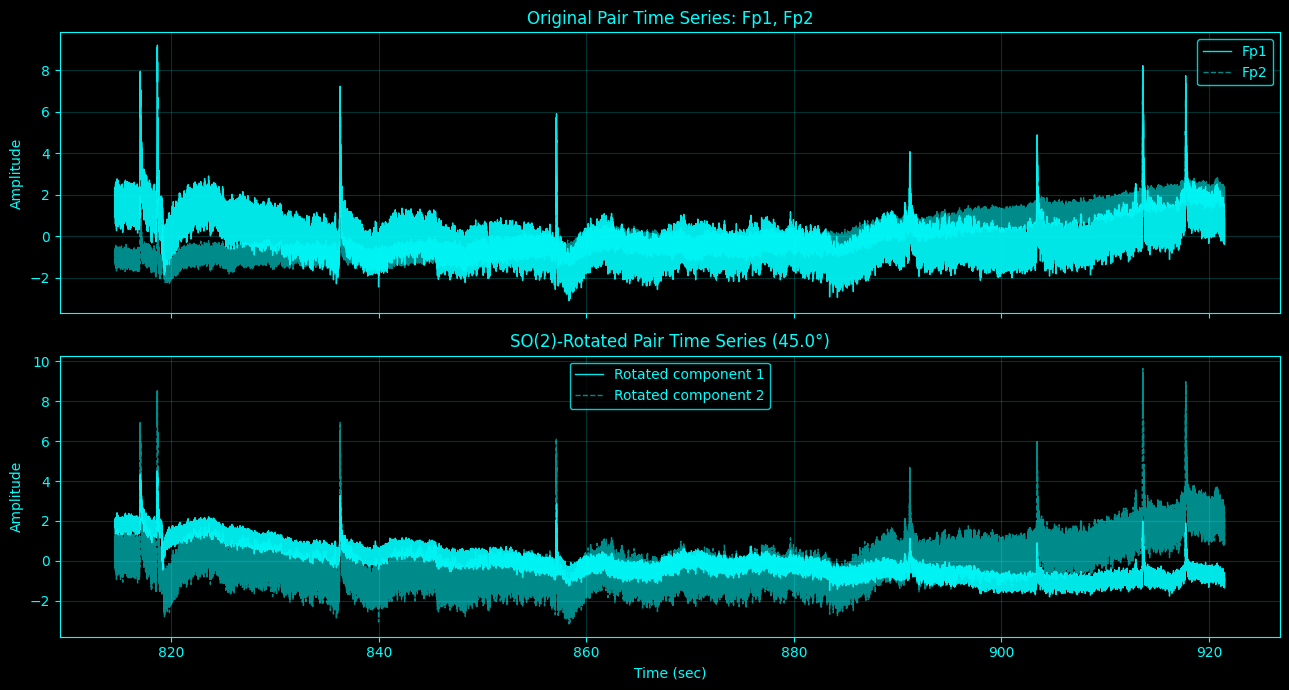

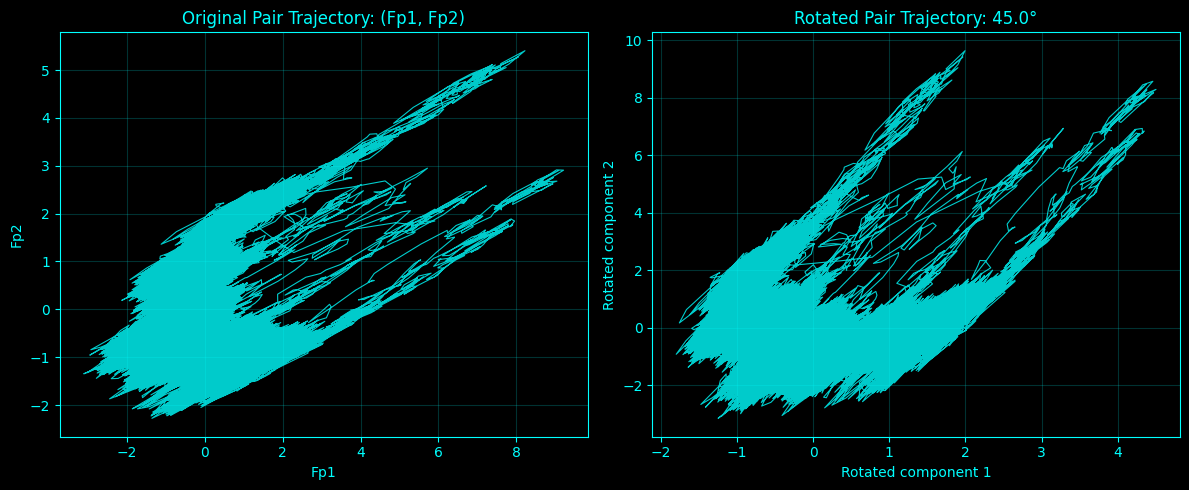

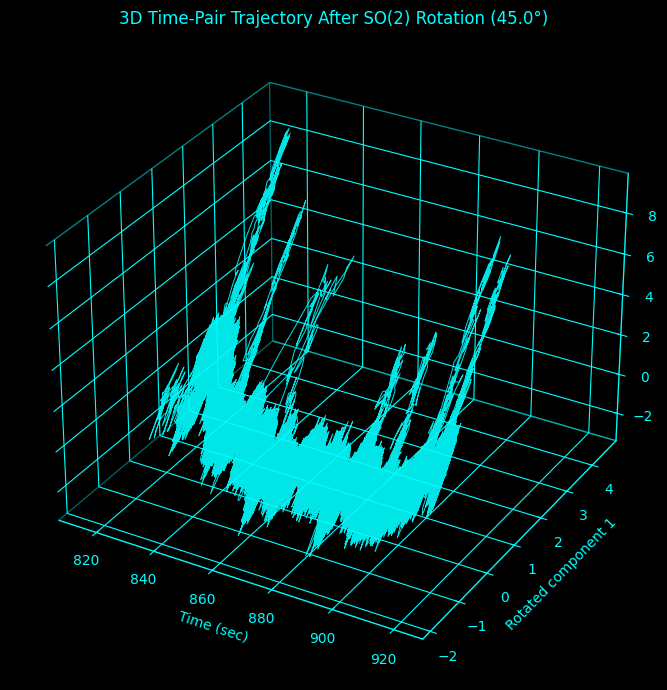

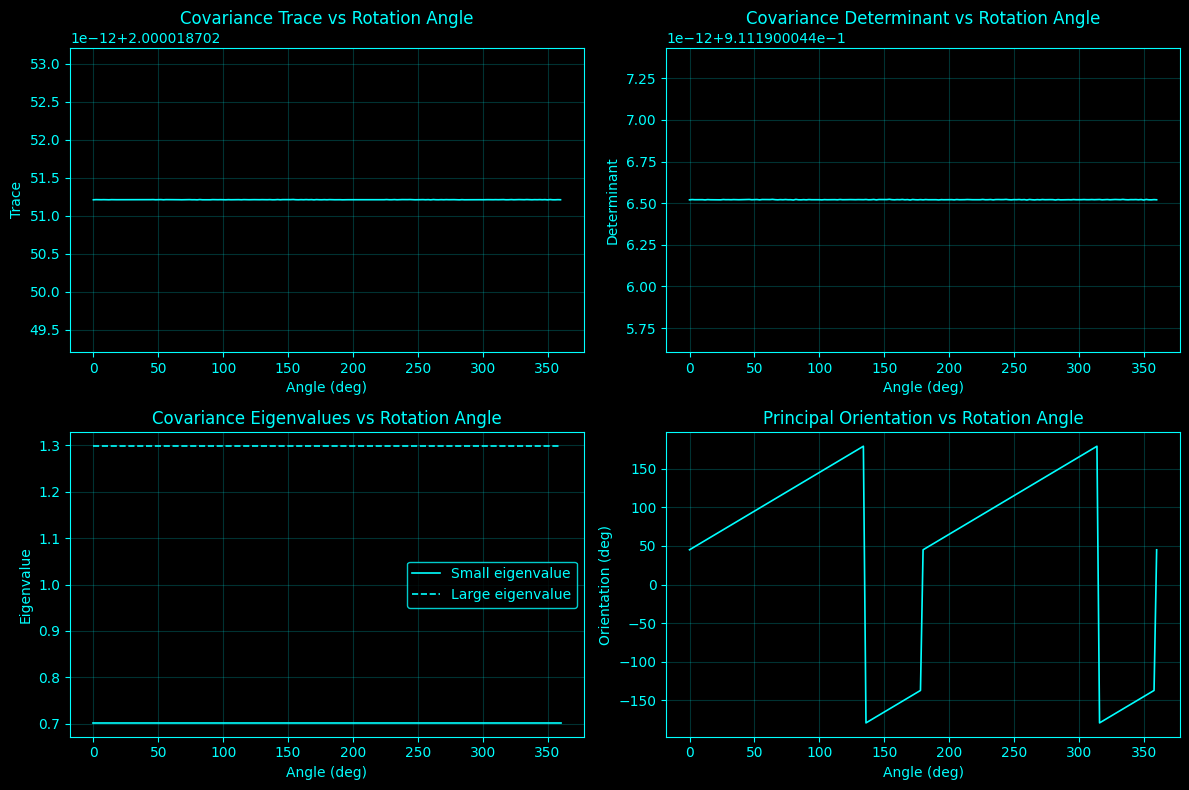

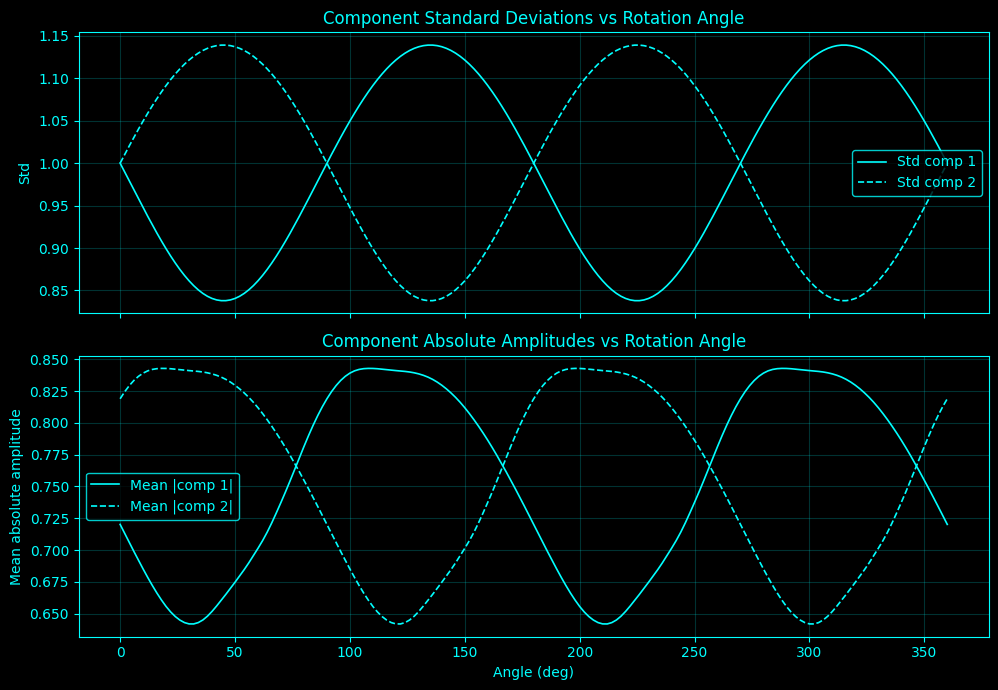


Saved main summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_main_rotation_summary.csv
Saved angle sweep CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_angle_sweep.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_results.npz
Saved summary TXT: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/lie_group_so2_summary.txt
Saved plots to: /home/a/projects/Complete-Neural-Signal-Analysis/results/lie_group_so2_channel_pair_analysis/plots


In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "lie_group_so2_channel_pair_analysis")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# Channel pair for the SO(2) action
channel_pair = ("Fp1", "Fp2")

# Main rotation angle for direct visualization
theta_main_deg = 45.0

# Sweep of angles to study invariants
n_theta = 181
theta_grid = np.linspace(0.0, 2.0 * np.pi, n_theta)

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def style_3d_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.xaxis.label.set_color(ACCENT)
    ax.yaxis.label.set_color(ACCENT)
    ax.zaxis.label.set_color(ACCENT)
    ax.title.set_color(ACCENT)
    try:
        ax.xaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.yaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.zaxis.pane.set_facecolor((0, 0, 0, 1))
        ax.xaxis.pane.set_edgecolor(ACCENT)
        ax.yaxis.pane.set_edgecolor(ACCENT)
        ax.zaxis.pane.set_edgecolor(ACCENT)
    except Exception:
        pass

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T
    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def zscore_by_channel(x):
    mu = np.mean(x, axis=0, keepdims=True)
    sd = np.std(x, axis=0, keepdims=True)
    return (x - mu) / (sd + eps)

def rotation_matrix(theta):
    c = np.cos(theta)
    s = np.sin(theta)
    return np.array([[c, -s], [s, c]], dtype=float)

def so2_transform(X, theta):
    """
    X shape: (time, 2)
    """
    R = rotation_matrix(theta)
    return X @ R.T

def pair_covariance(X):
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    return 0.5 * (C + C.T)

def pair_energy(X):
    return np.sum(X**2, axis=1)

def principal_orientation_deg(C):
    w, V = np.linalg.eigh(C)
    idx = np.argmax(w)
    v = V[:, idx]
    ang = np.degrees(np.arctan2(v[1], v[0]))
    return float(ang)

# -------------------------------------------------------
# LOAD EEG
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]
EEG_segment = zscore_by_channel(EEG_segment)

time_sec = start_time + np.arange(EEG_segment.shape[0]) * dt

ch1, ch2 = channel_pair
if ch1 not in eeg_channel_names or ch2 not in eeg_channel_names:
    raise ValueError(f"Channel pair {channel_pair} not found.")

idx1 = eeg_channel_names.index(ch1)
idx2 = eeg_channel_names.index(ch2)

X = EEG_segment[:, [idx1, idx2]]  # (time, 2)
theta_main = np.deg2rad(theta_main_deg)
Y = so2_transform(X, theta_main)

print(f"Loaded EEG segment shape: {EEG_segment.shape}")
print(f"Using channel pair: {ch1}, {ch2}")
print(f"Main rotation angle: {theta_main_deg:.2f} deg")

# -------------------------------------------------------
# MAIN GEOMETRIC QUANTITIES
# -------------------------------------------------------
C_X = pair_covariance(X)
C_Y = pair_covariance(Y)

eig_X = np.linalg.eigvalsh(C_X)
eig_Y = np.linalg.eigvalsh(C_Y)

energy_X = pair_energy(X)
energy_Y = pair_energy(Y)

radius_diff = np.abs(np.sqrt(energy_X) - np.sqrt(energy_Y))
energy_diff = np.abs(energy_X - energy_Y)

base_summary = {
    "channel_1": ch1,
    "channel_2": ch2,
    "theta_main_deg": float(theta_main_deg),
    "cov_trace_original": float(np.trace(C_X)),
    "cov_trace_rotated": float(np.trace(C_Y)),
    "cov_det_original": float(np.linalg.det(C_X)),
    "cov_det_rotated": float(np.linalg.det(C_Y)),
    "eigval1_original": float(eig_X[0]),
    "eigval2_original": float(eig_X[1]),
    "eigval1_rotated": float(eig_Y[0]),
    "eigval2_rotated": float(eig_Y[1]),
    "max_pointwise_energy_difference": float(np.max(energy_diff)),
    "mean_pointwise_energy_difference": float(np.mean(energy_diff)),
    "max_pointwise_radius_difference": float(np.max(radius_diff)),
    "mean_pointwise_radius_difference": float(np.mean(radius_diff)),
    "principal_orientation_original_deg": principal_orientation_deg(C_X),
    "principal_orientation_rotated_deg": principal_orientation_deg(C_Y),
}

# -------------------------------------------------------
# SWEEP ANGLE: INVARIANT / COVARIANT ANALYSIS
# -------------------------------------------------------
theta_rows = []

for theta in theta_grid:
    Z = so2_transform(X, theta)
    C = pair_covariance(Z)
    eig = np.linalg.eigvalsh(C)
    E = pair_energy(Z)

    theta_rows.append({
        "theta_rad": float(theta),
        "theta_deg": float(np.degrees(theta)),
        "cov_trace": float(np.trace(C)),
        "cov_det": float(np.linalg.det(C)),
        "eigval_small": float(eig[0]),
        "eigval_large": float(eig[1]),
        "principal_orientation_deg": principal_orientation_deg(C),
        "mean_energy": float(np.mean(E)),
        "mean_radius": float(np.mean(np.sqrt(E))),
        "mean_abs_amp_channel1": float(np.mean(np.abs(Z[:, 0]))),
        "mean_abs_amp_channel2": float(np.mean(np.abs(Z[:, 1]))),
        "std_channel1": float(np.std(Z[:, 0])),
        "std_channel2": float(np.std(Z[:, 1])),
    })

theta_df = pd.DataFrame(theta_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
summary_txt = os.path.join(out_dir, "lie_group_so2_summary.txt")
theta_csv = os.path.join(out_dir, "lie_group_so2_angle_sweep.csv")
base_csv = os.path.join(out_dir, "lie_group_so2_main_rotation_summary.csv")
npz_path = os.path.join(out_dir, "lie_group_so2_results.npz")

pd.DataFrame([base_summary]).to_csv(base_csv, index=False)
theta_df.to_csv(theta_csv, index=False)

np.savez_compressed(
    npz_path,
    time_sec=time_sec,
    X=X,
    Y=Y,
    C_X=C_X,
    C_Y=C_Y,
    theta_main_deg=theta_main_deg,
    theta_grid=theta_grid,
    eeg_channel_pair=np.array([ch1, ch2], dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("SO(2) Lie-Group Rotation Analysis of EEG Channel Pairs\n")
    f.write("=====================================================\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampling rate: {sampling_rate} Hz\n")
    f.write(f"Channel pair: {ch1}, {ch2}\n")
    f.write(f"Main rotation angle: {theta_main_deg:.6f} deg\n\n")
    f.write("Main-rotation invariants and covariants:\n")
    for k, v in base_summary.items():
        f.write(f"  {k}: {v}\n")

# -------------------------------------------------------
# PLOT 1: ORIGINAL VS ROTATED TIME SERIES
# -------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(13, 7), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(time_sec, X[:, 0], color=ACCENT, alpha=0.9, linewidth=1.0, label=ch1)
ax1.plot(time_sec, X[:, 1], color=ACCENT, alpha=0.55, linewidth=1.0, linestyle="--", label=ch2)
ax1.set_title(f"Original Pair Time Series: {ch1}, {ch2}")
ax1.set_ylabel("Amplitude")
ax1.legend()

ax2.plot(time_sec, Y[:, 0], color=ACCENT, alpha=0.9, linewidth=1.0, label="Rotated component 1")
ax2.plot(time_sec, Y[:, 1], color=ACCENT, alpha=0.55, linewidth=1.0, linestyle="--", label="Rotated component 2")
ax2.set_title(f"SO(2)-Rotated Pair Time Series ({theta_main_deg:.1f}°)")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Amplitude")
ax2.legend()

plot1_path = os.path.join(plots_dir, "original_vs_rotated_timeseries.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 2: CHANNEL-PAIR TRAJECTORY IN 2D PLANE
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(X[:, 0], X[:, 1], color=ACCENT, linewidth=0.8, alpha=0.8)
ax1.set_title(f"Original Pair Trajectory: ({ch1}, {ch2})")
ax1.set_xlabel(ch1)
ax1.set_ylabel(ch2)

ax2.plot(Y[:, 0], Y[:, 1], color=ACCENT, linewidth=0.8, alpha=0.8)
ax2.set_title(f"Rotated Pair Trajectory: {theta_main_deg:.1f}°")
ax2.set_xlabel("Rotated component 1")
ax2.set_ylabel("Rotated component 2")

plot2_path = os.path.join(plots_dir, "pair_plane_trajectory_original_vs_rotated.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 3: 3D TIME-PAIR TRAJECTORY
# -------------------------------------------------------
fig = plt.figure(figsize=(10, 7), facecolor=BG)
ax = fig.add_subplot(111, projection="3d")
style_3d_ax(ax)

ax.plot(time_sec, Y[:, 0], Y[:, 1], color=ACCENT, linewidth=0.7, alpha=0.9)
ax.set_title(f"3D Time-Pair Trajectory After SO(2) Rotation ({theta_main_deg:.1f}°)")
ax.set_xlabel("Time (sec)")
ax.set_ylabel("Rotated component 1")
ax.set_zlabel("Rotated component 2")

plot3_path = os.path.join(plots_dir, "time_pair_trajectory_3d_rotated.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 4: INVARIANTS ACROSS ROTATION ANGLE
# -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), facecolor=BG)
for ax in axes.ravel():
    style_ax(ax)

axes[0, 0].plot(theta_df["theta_deg"], theta_df["cov_trace"], color=ACCENT, linewidth=1.2)
axes[0, 0].set_title("Covariance Trace vs Rotation Angle")
axes[0, 0].set_xlabel("Angle (deg)")
axes[0, 0].set_ylabel("Trace")

axes[0, 1].plot(theta_df["theta_deg"], theta_df["cov_det"], color=ACCENT, linewidth=1.2)
axes[0, 1].set_title("Covariance Determinant vs Rotation Angle")
axes[0, 1].set_xlabel("Angle (deg)")
axes[0, 1].set_ylabel("Determinant")

axes[1, 0].plot(theta_df["theta_deg"], theta_df["eigval_small"], color=ACCENT, linewidth=1.2, label="Small eigenvalue")
axes[1, 0].plot(theta_df["theta_deg"], theta_df["eigval_large"], color=ACCENT, linewidth=1.2, linestyle="--", label="Large eigenvalue")
axes[1, 0].set_title("Covariance Eigenvalues vs Rotation Angle")
axes[1, 0].set_xlabel("Angle (deg)")
axes[1, 0].set_ylabel("Eigenvalue")
axes[1, 0].legend()

axes[1, 1].plot(theta_df["theta_deg"], theta_df["principal_orientation_deg"], color=ACCENT, linewidth=1.2)
axes[1, 1].set_title("Principal Orientation vs Rotation Angle")
axes[1, 1].set_xlabel("Angle (deg)")
axes[1, 1].set_ylabel("Orientation (deg)")

plot4_path = os.path.join(plots_dir, "invariants_and_orientation_vs_angle.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# -------------------------------------------------------
# PLOT 5: COMPONENT MIXING ACROSS ROTATION ANGLE
# -------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 7), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(theta_df["theta_deg"], theta_df["std_channel1"], color=ACCENT, linewidth=1.2, label="Std comp 1")
ax1.plot(theta_df["theta_deg"], theta_df["std_channel2"], color=ACCENT, linewidth=1.2, linestyle="--", label="Std comp 2")
ax1.set_title("Component Standard Deviations vs Rotation Angle")
ax1.set_ylabel("Std")
ax1.legend()

ax2.plot(theta_df["theta_deg"], theta_df["mean_abs_amp_channel1"], color=ACCENT, linewidth=1.2, label="Mean |comp 1|")
ax2.plot(theta_df["theta_deg"], theta_df["mean_abs_amp_channel2"], color=ACCENT, linewidth=1.2, linestyle="--", label="Mean |comp 2|")
ax2.set_title("Component Absolute Amplitudes vs Rotation Angle")
ax2.set_xlabel("Angle (deg)")
ax2.set_ylabel("Mean absolute amplitude")
ax2.legend()

plot5_path = os.path.join(plots_dir, "component_mixing_vs_angle.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved main summary CSV: {base_csv}")
print(f"Saved angle sweep CSV: {theta_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")

### Hermitian manifold / Kähler-form proxy